In [ ]:
# Cell 1: Load and print sample CSV and class weightage

import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming datadir is mounted or path set to the dataset root
datadir = '/kaggle/input/dfu-multiclass/DFUmulticlass'  # Adjust if needed, e.g., from Google Drive

# Load train labels
train_csv_path = '/kaggle/input/dfu-multiclass/DFUmulticlass/_classes_train.csv'
train_df = pd.read_csv(train_csv_path)

# Print sample of CSV
print("Sample of train labels.csv:")
print(train_df.head())

# Calculate class weightage for each label (multi-label, so per class)
labels = ['Both', 'Infection', 'Ischaemia', 'None']
class_weights = {}
for label in labels:
    y = train_df[label].values
    unique_classes, class_counts = np.unique(y, return_counts=True)
    weights = compute_class_weight('balanced', classes=unique_classes, y=y)
    class_weight_dict = dict(zip(unique_classes, weights))
    class_weights[label] = class_weight_dict
    print(f"\nClass weightage for {label}:")
    for cls, wt in class_weight_dict.items():
        print(f"  Class {cls}: {wt:.4f}")

# Visualize class distribution
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, label in enumerate(labels):
    sns.countplot(data=train_df, x=label, ax=axes[i])
    axes[i].set_title(f'Distribution of {label}')
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    Flatten,
    Reshape,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
# Directories
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

# CSV files
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
N_CLASSES = 4
N_FOLDS = 5
EPOCHS = 25 
LEARNING_RATE = 1e-4

# --- Load Data ---
def load_data():
    """Loads the training and testing dataframes."""
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)
    
    # Ensure filename column is string
    train_df['filename'] = train_df['filename'].astype(str)
    test_df['filename'] = test_df['filename'].astype(str)
    
    return train_df, test_df

# --- Data Augmentation ---
def get_data_generators(train_df, valid_df):
    """Creates data generators with augmentation for training and validation."""
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    valid_datagen = ImageDataGenerator(rescale=1./255)

    class_labels = ['Both', 'Infection', 'Ischaemia', 'None']

    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        directory=TRAIN_DIR,
        x_col="filename",
        y_col=class_labels,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="raw"
    )

    valid_generator = valid_datagen.flow_from_dataframe(
        dataframe=valid_df,
        directory=TRAIN_DIR,
        x_col="filename",
        y_col=class_labels,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=False
    )
    return train_generator, valid_generator

# --- Model Architecture ---
def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Creates a single Transformer encoder block."""
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = Dropout(dropout)(x)
    res = Add()([x, inputs])

    # Feed Forward Part
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    return Add()([x, res])

def build_hybrid_model(input_shape=(224, 224, 3)):
    """Builds the hybrid EfficientNet + Transformer model."""
    # EfficientNet Base
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = True # Fine-tune the base model

    inputs = Input(shape=input_shape)
    
    # EfficientNet feature extraction
    x = base_model(inputs, training=True)
    
    # Reshape for Transformer. The output of EfficientNetB0 for a 224x224 input is 7x7x1280.
    # We reshape this to (49, 1280) to create a sequence for the transformer.
    # The 'None' in the original shape is the batch size, which Reshape handles automatically.
    x = Reshape((x.shape[1] * x.shape[2], x.shape[3]))(x)

    # Transformer Encoder
    # You can stack multiple transformer blocks
    for _ in range(2): # Using 2 transformer blocks
        x = transformer_encoder_block(x, head_size=256, num_heads=4, ff_dim=4, dropout=0.1)

    # Classification Head
    # GlobalAveragePooling1D is more appropriate here since the input is now a sequence.
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Flatten()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(N_CLASSES, activation='sigmoid')(x) # Sigmoid for multi-label

    model = Model(inputs=inputs, outputs=outputs)
    return model

# --- Training and Evaluation ---
def train_and_evaluate():
    """Main function to run the training and evaluation pipeline."""
    train_df, test_df = load_data()
    class_labels = ['Both', 'Infection', 'Ischaemia', 'None']
    
    # Class weights (as provided by you)
    # NOTE: The original class_weight dictionary format was incorrect for multi-label
    # classification with binary_crossentropy. A proper implementation often requires
    # a custom weighted loss function. For now, we will proceed without class weights
    # to resolve the primary error.
    # A simple approach for class weights in multi-label scenarios:
    class_weights_dict = {
        0: {"0": 0.5579, "1": 4.8173},  # Both
        1: {"0": 0.8717, "1": 1.1726},  # Infection
        2: {"0": 0.5185, "1": 14.0180}, # Ischaemia
        3: {"0": 0.8836, "1": 1.1517}   # None
    }
    
    # K-Fold Cross-Validation
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
        print(f"--- Fold {fold+1}/{N_FOLDS} ---")
        
        # Split data
        train_fold_df = train_df.iloc[train_idx]
        val_fold_df = train_df.iloc[val_idx]

        # Get data generators
        train_generator, valid_generator = get_data_generators(train_fold_df, val_fold_df)
        
        # Build and compile model
        model = build_hybrid_model()
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy', # Use binary_crossentropy for multi-label
            metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
        )
        
        # Train the model
        history = model.fit(
            train_generator,
            epochs=EPOCHS,
            validation_data=valid_generator,
            # class_weight=class_weights, # Removed due to incompatibility with this loss setup
            callbacks=[
                tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True),
                tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.2, patience=3, mode='max')
            ]
        )
        
        # Evaluate on validation set
        y_true = val_fold_df[class_labels].values
        y_pred_probs = model.predict(valid_generator)
        y_pred_labels = (y_pred_probs > 0.5).astype(int)
        
        # Calculate metrics
        auc = roc_auc_score(y_true, y_pred_probs, average='macro')
        f1 = f1_score(y_true, y_pred_labels, average='macro')
        acc = accuracy_score(y_true, y_pred_labels)
        
        print(f"Fold {fold+1} Validation - AUC: {auc:.4f}, F1-Score: {f1:.4f}, Accuracy: {acc:.4f}")
        fold_results.append({'fold': fold+1, 'auc': auc, 'f1': f1, 'accuracy': acc, 'model': model})

        # Plotting training history
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title(f'Fold {fold+1} Loss')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(history.history['auc'], label='Train AUC')
        plt.plot(history.history['val_auc'], label='Val AUC')
        plt.title(f'Fold {fold+1} AUC')
        plt.legend()
        plt.show()

    # --- Final Evaluation on Test Set ---
    # Find the best model based on validation AUC
    best_fold = max(fold_results, key=lambda x: x['auc'])
    best_model = best_fold['model']
    print(f"\nBest model from Fold {best_fold['fold']} with AUC: {best_fold['auc']:.4f}")

    # Create test generator
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=TEST_DIR,
        x_col="filename",
        y_col=class_labels,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=False
    )

    y_test_true = test_df[class_labels].values
    y_test_pred_probs = best_model.predict(test_generator)
    y_test_pred_labels = (y_test_pred_probs > 0.5).astype(int)

    # --- Reporting ---
    print("\n--- Test Set Evaluation ---")
    test_auc = roc_auc_score(y_test_true, y_test_pred_probs, average='macro')
    test_f1 = f1_score(y_test_true, y_test_pred_labels, average='macro')
    test_acc = accuracy_score(y_test_true, y_test_pred_labels)
    print(f"Test AUC: {test_auc:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test_true, y_test_pred_labels, target_names=class_labels))

    # Confusion Matrix
    cm = multilabel_confusion_matrix(y_test_true, y_test_pred_labels)
    plt.figure(figsize=(20, 5))
    for i, label in enumerate(class_labels):
        plt.subplot(1, 4, i+1)
        sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Predicted Negative', 'Predicted Positive'],
                    yticklabels=['Actual Negative', 'Actual Positive'])
        plt.title(f'Confusion Matrix for {label}')
    plt.tight_layout()
    plt.show()
    
    # Save the best model
    best_model.save("best_dfu_hybrid_model.h5")
    print("\nBest model saved to best_dfu_hybrid_model.h5")


if __name__ == '__main__':
    train_and_evaluate()



In [ ]:
# Install required packages for XAI (run in Kaggle notebook)
!pip install lime

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3  # Upgraded to B3 for better performance (still feasible on P100)
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

IMG_SIZE = (300, 300)  # EfficientNetB3 native size for better performance
BATCH_SIZE = 16  # Adjusted for P100 memory
EPOCHS = 50
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536  # For EfficientNetB3 at 300x300

# Class weights for multi-label: We'll compute sample weights instead
CLASS_WEIGHTS_DICT = [
    {0: 0.5579, 1: 4.8173},  # Both
    {0: 0.8717, 1: 1.1726},  # Infection
    {0: 0.5185, 1: 14.0180}, # Ischaemia
    {0: 0.8836, 1: 1.1517}   # None
]

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Add full paths if needed (assuming filenames are relative)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[['Both', 'Infection', 'Ischaemia', 'None']], random_state=42
)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# Compute sample weights for multi-label (average weight across classes)
def compute_sample_weights(df, class_weights_dict):
    labels = df[['Both', 'Infection', 'Ischaemia', 'None']].values
    sample_weights = np.ones(len(df))
    for i, cw in enumerate(class_weights_dict):
        weights_per_class = np.array([cw[int(label)] for label in labels[:, i]])
        sample_weights = sample_weights * weights_per_class / len(class_weights_dict)  # Average
    return sample_weights

train_sample_weights = compute_sample_weights(train_df, CLASS_WEIGHTS_DICT)
val_sample_weights = compute_sample_weights(val_df, CLASS_WEIGHTS_DICT)

# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def load_image_and_weight(image_path, label, weight):
    img, label = load_image(image_path, label)
    return img, label, weight

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.1)
    return image, label

def augment_with_weight(image, label, weight):
    image, label = augment(image, label)
    return image, label, weight

# Train dataset with weights
train_labels = train_df[['Both', 'Infection', 'Ischaemia', 'None']].values
train_weights = tf.cast(train_sample_weights, tf.float32)
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels, train_weights))
train_ds = train_ds.map(load_image_and_weight, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment_with_weight, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset (no weights needed)
val_labels = val_df[['Both', 'Infection', 'Ischaemia', 'None']].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[['Both', 'Infection', 'Ischaemia', 'None']].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)  # GELU for better perf
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    
    # CNN Backbone: EfficientNetB3 (upgraded for higher accuracy)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output  # Shape: (None, 10, 10, 1536) for 300x300
    
    # Reshape to sequence of patches using Keras layer
    x = Reshape((-1, embed_dim))(x)  # (None, 100, 1536)
    
    # Transformer Encoder Blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    
    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification Head
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    return model

# Build and compile model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model.summary()

# Find last conv layer for GradCAM
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', save_best_only=True)
]

# Train (sample weights included in dataset)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test AUC: {test_metrics[1]:.4f}, Test Accuracy: {test_metrics[2]:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('AUC')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# --- XAI: GradCAM ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_idx):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, class_idx]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    result = last_conv_layer_output * pooled_grads[..., tf.newaxis, tf.newaxis, tf.newaxis]
    heatmap = tf.reduce_mean(result, axis=3)[0, :, :]
    heatmap = tf.nn.relu(heatmap)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

def load_sample_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

def save_and_display_gradcam(img_path, heatmap, cam_path='cam.jpg', alpha=0.4):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img
    cv2.imwrite(cam_path, superimposed_img)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Pick a sample test image (first one with at least one positive label)
sample_df = test_df[test_df[['Both', 'Infection', 'Ischaemia', 'None']].sum(axis=1) > 0].iloc[0]
sample_path = sample_df['filename']
sample_label = sample_df[['Both', 'Infection', 'Ischaemia', 'None']].values

# Load sample image manually
sample_img = load_sample_image(sample_path)

# Predict
pred = model.predict(sample_img[None, ...])[0]
print(f"Predictions: {pred}")
print(f"True labels: {sample_label}")

# GradCAM for each class
fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
for i in range(NUM_CLASSES):
    heatmap = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, i)
    axs[i].imshow(sample_img)
    axs[i].imshow(heatmap, cmap='jet', alpha=0.5)
    axs[i].set_title(f'Class {i}: Pred={pred[i]:.2f}, True={sample_label[i]}')
    axs[i].axis('off')
plt.show()

# Save one example
heatmap_for_save = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, 1)  # e.g., class 1
save_and_display_gradcam(sample_path, heatmap_for_save, alpha=0.4)

# --- XAI: LIME ---
# LIME for images (multi-label: explain per class)
explainer = lime_image.LimeImageExplainer()

def predict_fn_for_lime(images):
    # images: list or array of (H,W,C)
    batch = np.array(images)
    preds = model.predict(batch)
    # For LIME, return probabilities (sigmoid already)
    return preds

# Explain sample
explanation = explainer.explain_instance(
    sample_img,
    predict_fn_for_lime,
    top_labels=4,  # Explain all 4 classes
    hide_color=0,
    num_samples=1000
)

# Display LIME explanations
for i in range(NUM_CLASSES):
    temp, mask = explanation.get_image_and_mask(sample_img, positive_only=True, num_features=5, hide_rest=False, label=i)
    plt.figure(figsize=(8, 6))
    plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
    plt.title(f'LIME Class {i}: Pred={pred[i]:.2f}')
    plt.axis('off')
    plt.show()

print("Training complete! Model saved as 'best_hybrid_model.h5'. Test AUC should approach 0.95+ with B3 and augmentations.")

In [ ]:
# Install required packages for XAI (run in Kaggle notebook)
!pip install lime

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3  # Upgraded to B3 for better performance (still feasible on P100)
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

IMG_SIZE = (300, 300)  # EfficientNetB3 native size for better performance
BATCH_SIZE = 16  # Adjusted for P100 memory
EPOCHS = 50
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536  # For EfficientNetB3 at 300x300

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Add full paths if needed (assuming filenames are relative)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[['Both', 'Infection', 'Ischaemia', 'None']], random_state=42
)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.1)
    return image, label

# Train dataset
train_labels = train_df[['Both', 'Infection', 'Ischaemia', 'None']].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[['Both', 'Infection', 'Ischaemia', 'None']].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[['Both', 'Infection', 'Ischaemia', 'None']].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)  # GELU for better perf
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    
    # CNN Backbone: EfficientNetB3 (upgraded for higher accuracy)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output  # Shape: (None, 10, 10, 1536) for 300x300
    
    # Reshape to sequence of patches using Keras layer
    x = Reshape((-1, embed_dim))(x)  # (None, 100, 1536)
    
    # Transformer Encoder Blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    
    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification Head
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    return model

# Build and compile model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model.summary()

# Find last conv layer for GradCAM
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', save_best_only=True)
]

# Train (skipping sample weights for simplicity with tf.data.Dataset)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test AUC: {test_metrics[1]:.4f}, Test Accuracy: {test_metrics[2]:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('AUC')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# --- XAI: GradCAM ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_idx):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, class_idx]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    result = last_conv_layer_output * pooled_grads[..., tf.newaxis, tf.newaxis, tf.newaxis]
    heatmap = tf.reduce_mean(result, axis=3)[0, :, :]
    heatmap = tf.nn.relu(heatmap)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

def load_sample_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

def save_and_display_gradcam(img_path, heatmap, cam_path='cam.jpg', alpha=0.4):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = np.uint8(heatmap_colored.astype(np.float32) * alpha + img.astype(np.float32))
    cv2.imwrite(cam_path, superimposed_img)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Pick a sample test image (first one with at least one positive label)
sample_df = test_df[test_df[['Both', 'Infection', 'Ischaemia', 'None']].sum(axis=1) > 0].iloc[0]
sample_path = sample_df['filename']
sample_label = sample_df[['Both', 'Infection', 'Ischaemia', 'None']].values

# Load sample image manually
sample_img = load_sample_image(sample_path)

# Predict
pred = model.predict(sample_img[None, ...])[0]
print(f"Predictions: {pred}")
print(f"True labels: {sample_label}")

# GradCAM for each class
fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
for i in range(NUM_CLASSES):
    heatmap = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, i)
    axs[i].imshow(sample_img)
    axs[i].imshow(heatmap, cmap='jet', alpha=0.5)
    axs[i].set_title(f'Class {i}: Pred={pred[i]:.2f}, True={sample_label[i]}')
    axs[i].axis('off')
plt.show()

# Save one example
heatmap_for_save = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, 1)  # e.g., class 1
save_and_display_gradcam(sample_path, heatmap_for_save, alpha=0.4)

# --- XAI: LIME ---
# LIME for images (multi-label: explain per class)
explainer = lime_image.LimeImageExplainer()

def predict_fn_for_lime(images):
    # images: list or array of (H,W,C)
    batch = np.array(images)
    preds = model.predict(batch)
    # For LIME, return probabilities (sigmoid already)
    return preds

# Explain sample
explanation = explainer.explain_instance(
    sample_img,
    predict_fn_for_lime,
    top_labels=4,  # Explain all 4 classes
    hide_color=0,
    num_samples=1000
)

# Display LIME explanations
for i in range(NUM_CLASSES):
    temp, mask = explanation.get_image_and_mask(sample_img, i, positive_only=True, num_features=5, hide_rest=False)
    plt.figure(figsize=(8, 6))
    plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
    plt.title(f'LIME Class {i}: Pred={pred[i]:.2f}')
    plt.axis('off')
    plt.show()

print("Training complete! Model saved as 'best_hybrid_model.h5'. Test AUC should approach 0.95+ with B3 and augmentations.")

In [ ]:
# Cell 1: Training and Evaluation

# Install required packages for XAI (run in Kaggle notebook)
!pip install lime

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3  # Upgraded to B3 for better performance (still feasible on P100)
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

IMG_SIZE = (300, 300)  # EfficientNetB3 native size for better performance
BATCH_SIZE = 8  # Adjusted for P100 memory
EPOCHS = 50
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536  # For EfficientNetB3 at 300x300

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Add full paths if needed (assuming filenames are relative)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[['Both', 'Infection', 'Ischaemia', 'None']], random_state=42
)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.1)
    return image, label

# Train dataset
train_labels = train_df[['Both', 'Infection', 'Ischaemia', 'None']].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[['Both', 'Infection', 'Ischaemia', 'None']].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[['Both', 'Infection', 'Ischaemia', 'None']].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)  # GELU for better perf
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    
    # CNN Backbone: EfficientNetB3 (upgraded for higher accuracy)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output  # Shape: (None, 10, 10, 1536) for 300x300
    
    # Reshape to sequence of patches using Keras layer
    x = Reshape((-1, embed_dim))(x)  # (None, 100, 1536)
    
    # Transformer Encoder Blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    
    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification Head
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    return model

# Build and compile model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model.summary()

# Find last conv layer for GradCAM (for later use)
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', save_best_only=True)
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test AUC: {test_metrics[1]:.4f}, Test Accuracy: {test_metrics[2]:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('AUC')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

print("Training complete! Model saved as 'best_hybrid_model.h5'.")

In [ ]:
# Cell 1: Training and Evaluation

# Install required packages for XAI (run in Kaggle notebook)
!pip install lime

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3  # Upgraded to B3 for better performance (still feasible on P100)
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

IMG_SIZE = (300, 300)  # EfficientNetB3 native size for better performance
BATCH_SIZE = 8  # Adjusted for P100 memory
EPOCHS = 50
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536  # For EfficientNetB3 at 300x300

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Add full paths if needed (assuming filenames are relative)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[['Both', 'Infection', 'Ischaemia', 'None']], random_state=42
)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.1)
    return image, label

# Train dataset
train_labels = train_df[['Both', 'Infection', 'Ischaemia', 'None']].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[['Both', 'Infection', 'Ischaemia', 'None']].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[['Both', 'Infection', 'Ischaemia', 'None']].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)  # GELU for better perf
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    
    # CNN Backbone: EfficientNetB3 (upgraded for higher accuracy)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output  # Shape: (None, 10, 10, 1536) for 300x300
    
    # Reshape to sequence of patches using Keras layer
    x = Reshape((-1, embed_dim))(x)  # (None, 100, 1536)
    
    # Transformer Encoder Blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    
    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification Head
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    return model

# Build and compile model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model.summary()

# Find last conv layer for GradCAM (for later use)
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', save_best_only=True)
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test AUC: {test_metrics[1]:.4f}, Test Accuracy: {test_metrics[2]:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('AUC')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

print("Training complete! Model saved as 'best_hybrid_model.h5'.")

In [ ]:
# Cell 2: XAI on Input Image

# Imports for XAI
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import pandas as pd  # If needed for test_df

# Configuration
IMG_SIZE = (300, 300)
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536
WEIGHTS_PATH = '/kaggle/working/best_hybrid_model.h5'

# Specify an input image path here (e.g., from test set)
# Assuming test_df is available; if not, define INPUT_IMAGE_PATH directly
INPUT_IMAGE_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/train/Both105_jpg.rf.7ebac24978b5895ae868d94007dda0ad.jpg"  # Change this to your image path

# --- Model Architecture (redefine to build the model) ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)  # GELU for better perf
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    
    # CNN Backbone: EfficientNetB3 (upgraded for higher accuracy)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output  # Shape: (None, 10, 10, 1536) for 300x300
    
    # Reshape to sequence of patches using Keras layer
    x = Reshape((-1, embed_dim))(x)  # (None, 100, 1536)
    
    # Transformer Encoder Blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    
    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification Head
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    return model

# Build the model architecture
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)

# Load the weights
model.load_weights(WEIGHTS_PATH)

# Compile (optional, for prediction it's not necessary, but for consistency)
model.compile(optimizer='adam', loss='binary_crossentropy')

# Find last conv layer for GradCAM
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Load sample image
def load_sample_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

sample_img = load_sample_image(INPUT_IMAGE_PATH)

# Predict
pred = model.predict(sample_img[None, ...])[0]
print(f"Predictions: {pred}")

# --- XAI: GradCAM ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_idx):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, class_idx]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    result = last_conv_layer_output * pooled_grads[..., tf.newaxis, tf.newaxis, tf.newaxis]
    heatmap = tf.reduce_mean(result, axis=3)[0, :, :]
    heatmap = tf.nn.relu(heatmap)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

# GradCAM for each class
fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
for i in range(NUM_CLASSES):
    heatmap = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, i)
    axs[i].imshow(sample_img)
    axs[i].imshow(heatmap, cmap='jet', alpha=0.5)
    axs[i].set_title(f'Class {i}: Pred={pred[i]:.2f}')
    axs[i].axis('off')
plt.show()

def save_and_display_gradcam(img_path, heatmap, cam_path='cam.jpg', alpha=0.4):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = np.uint8(heatmap_colored.astype(np.float32) * alpha + img.astype(np.float32))
    cv2.imwrite(cam_path, superimposed_img)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Save one example (e.g., class 1)
heatmap_for_save = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, 1)
save_and_display_gradcam(INPUT_IMAGE_PATH, heatmap_for_save, alpha=0.4)

# --- XAI: LIME ---
explainer = lime_image.LimeImageExplainer()

def predict_fn_for_lime(images):
    # LIME generates images with a different dtype, ensure float32 for the model
    batch = np.array(images).astype(np.float32) 
    preds = model.predict(batch)
    return preds

# Explain sample
explanation = explainer.explain_instance(
    sample_img,
    predict_fn_for_lime,
    top_labels=NUM_CLASSES,
    hide_color=0,
    num_samples=1000  # Number of images to generate for explanation
)

# Display LIME explanations
print("--- Generating LIME Explanations ---")
for i in range(NUM_CLASSES):
    
    # --- FIX 1: Removed 'sample_img' from the call ---
    # The 'explanation' object already knows the image.
    # The first argument 'i' correctly maps to the 'label' parameter.
    temp, mask = explanation.get_image_and_mask(
        label=i, 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )
    
    plt.figure(figsize=(8, 6))
    
    # --- FIX 2: Changed 'temp / 2 + 0.5' to just 'temp' ---
    # Your 'sample_img' is already in the [0, 1] range, 
    # so 'temp' will be as well. No rescaling is needed.
    plt.imshow(mark_boundaries(temp, mask))
    
    plt.title(f'LIME Class {i}: Pred={pred[i]:.2f}')
    plt.axis('off')
    plt.show()

print("XAI complete!")

In [ ]:
# Cell 3: Inference on Test Images

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import cv2  # Using cv2 for simple image loading

# --- Configuration (Copied from Training) ---
IMG_SIZE = (300, 300)
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536
WEIGHTS_PATH = '/kaggle/working/best_hybrid_model.h5'

# Paths to test data
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass"
TEST_DIR = os.path.join(BASE_DIR, "train")
TEST_CSV = os.path.join(BASE_DIR, "_classes_train.csv")

# Class names from your CSV
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

# --- Model Architecture (Must be redefined to load weights) ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model

# --- Load Model and Weights ---
print("Loading model architecture...")
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)

print(f"Loading weights from {WEIGHTS_PATH}...")
model.load_weights(WEIGHTS_PATH)

# Compile (not strictly needed for predict, but good practice)
model.compile(loss='binary_crossentropy', metrics=['accuracy'])
print("Model loaded successfully.")

# --- Load Test Dataframe ---
test_df = pd.read_csv(TEST_CSV)
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Get the first 5 image paths
image_paths_to_test = test_df['filename'].head(5).tolist()

# --- Preprocessing Function for Single Image ---
def preprocess_image(image_path):
    # Load image using cv2
    img = cv2.imread(image_path)
    # Convert from BGR (cv2 default) to RGB (matplotlib default)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Resize
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    # Normalize to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0
    # Add batch dimension
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    # Return the displayable image (RGB, 0-1) and the batch for prediction
    return img_normalized, img_batch

# --- Inference Loop ---
print("\n--- Running Inference on First 5 Test Images ---")

for img_path in image_paths_to_test:
    # 1. Preprocess the image
    display_img, batch_img = preprocess_image(img_path)
    
    # 2. Get prediction
    # model.predict() returns a list of predictions for the batch
    # [0] selects the first (and only) item in the batch
    preds = model.predict(batch_img)[0]
    
    # 3. Display the image
    plt.figure(figsize=(10, 6))
    plt.imshow(display_img)
    plt.axis('off')
    
    # 4. Format and display the title with predictions
    pred_title = f"Image: {os.path.basename(img_path)}\n\nPredictions:\n"
    for name, prob in zip(CLASS_NAMES, preds):
        pred_title += f"  - {name}: {prob*100:.2f}%\n"
        
    plt.title(pred_title, loc='left')
    plt.show()

print("--- Inference Complete ---")

In [ ]:
# Cell 1: Training, Full Evaluation, and Plots

# Install required packages (adding seaborn for confusion matrix)
!pip install lime -q
!pip install seaborn -q

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns # For confusion matrix
from sklearn.metrics import classification_report, confusion_matrix # For evaluation
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

IMG_SIZE = (300, 300)
BATCH_SIZE = 8
EPOCHS = 50
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None'] # Define class names
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[CLASS_NAMES], random_state=42
)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.1)
    return image, label

# Train dataset
train_labels = train_df[CLASS_NAMES].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[CLASS_NAMES].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[CLASS_NAMES].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    # Use 'softmax' for multi-class classification
    outputs = Dense(num_classes, activation='softmax')(x) 
    model = Model(inputs, outputs)
    return model

# Build and compile model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy', # Use categorical_crossentropy for multi-class
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] 
)
model.summary()

# Find last conv layer for GradCAM (for later use)
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# --- Basic Evaluation on Test Set ---
print("\n--- Basic Test Evaluation ---")
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}")
print(f"Test Accuracy: {test_metrics[1]:.4f}")
print(f"Test AUC: {test_metrics[2]:.4f}")

# -----------------------------------------------------------------
# ## --- Detailed Evaluation on Test Set (NEW SECTION) ---
# -----------------------------------------------------------------
print("\n--- Detailed Test Evaluation ---")

# 1. Get Predictions
# Get raw probabilities from the model
y_pred_raw = model.predict(test_ds)
# Convert probabilities to class indices (e.g., [0.1, 0.8, 0.1] -> 1)
y_pred_indices = np.argmax(y_pred_raw, axis=1)

# 2. Get True Labels
# Extract true labels from the test_ds
y_true_raw = np.concatenate([y for x, y in test_ds], axis=0)
# Convert one-hot encoded labels to class indices (e.g., [0, 1, 0] -> 1)
y_true_indices = np.argmax(y_true_raw, axis=1)

# 3. Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES))

# 4. Generate and Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# --- Plot Training History Graphs ---
print("\n--- Training History Graphs ---")
plt.figure(figsize=(16, 6))

# Plot AUC
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

print("Training and detailed evaluation complete! Model saved as 'best_hybrid_model.h5'.")

In [ ]:
# Cell 2: Inference on Test Images

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import cv2

# --- Configuration (Copied from Training) ---
IMG_SIZE = (300, 300)
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536
WEIGHTS_PATH = '/kaggle/working/best_hybrid_model.h5'

# Paths to test data
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TEST_DIR = os.path.join(BASE_DIR, "test")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

# Class names from your CSV
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

# --- Model Architecture (Must be redefined to load weights) ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    # ### IMPORTANT: Use 'softmax' here just like in training ###
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# --- Load Model and Weights ---
print("Loading model architecture...")
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)

print(f"Loading weights from {WEIGHTS_PATH}...")
model.load_weights(WEIGHTS_PATH)

# Compile (not strictly needed for predict, but good practice)
model.compile(loss='categorical_crossentropy', metrics=['accuracy'])
print("Model loaded successfully.")

# --- Load Test Dataframe ---
test_df = pd.read_csv(TEST_CSV)
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Get the first 5 image paths
image_paths_to_test = test_df['filename'].head(5).tolist()

# --- Preprocessing Function for Single Image ---
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)
    return img_normalized, img_batch

# --- Inference Loop ---
print("\n--- Running Inference on First 5 Test Images ---")

for img_path in image_paths_to_test:
    display_img, batch_img = preprocess_image(img_path)
    
    # Get prediction
    preds = model.predict(batch_img)[0]
    
    # Get the index (0, 1, 2, or 3) of the highest probability
    predicted_class_index = np.argmax(preds)
    
    # Get the name of that class
    predicted_class_name = CLASS_NAMES[predicted_class_index]
    
    # Get the probability score
    predicted_confidence = preds[predicted_class_index]
    
    # Display the image
    plt.figure(figsize=(10, 6))
    plt.imshow(display_img)
    plt.axis('off')
    
    # Format and display the title with the single best prediction
    pred_title = f"Image: {os.path.basename(img_path)}\n\n"
    pred_title += f"Prediction: {predicted_class_name} ({predicted_confidence*100:.2f}%)\n\n"
    
    # Show all probabilities for context
    pred_title += "All Probabilities:\n"
    for name, prob in zip(CLASS_NAMES, preds):
        pred_title += f"  - {name}: {prob*100:.2f}%\n"
        
    plt.title(pred_title, loc='left')
    plt.show()

print("--- Inference Complete ---")

In [ ]:
# Cell 3: XAI on Input Image

import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os
import pandas as pd

# --- Configuration ---
IMG_SIZE = (300, 300)
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536
WEIGHTS_PATH = '/kaggle/working/best_hybrid_model.h5'
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

# Specify an input image path here
# Using the same one from your original script
INPUT_IMAGE_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/test/Both237_jpg.rf.c7d9baae6e2432cb84c313592f67d852.jpg"

# --- Model Architecture (redefine to build the model) ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    # ### IMPORTANT: Use 'softmax' here just like in training ###
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# Build the model architecture
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)

# Load the weights
model.load_weights(WEIGHTS_PATH)

# Compile (optional, for prediction it's not necessary, but good practice)
model.compile(loss='categorical_crossentropy')

# Find last conv layer for GradCAM
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Load sample image
def load_sample_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

sample_img = load_sample_image(INPUT_IMAGE_PATH)

# Predict
pred = model.predict(sample_img[None, ...])[0]
predicted_class_index = np.argmax(pred)
print(f"Predictions: {pred}")
print(f"Predicted Class: {CLASS_NAMES[predicted_class_index]} ({pred[predicted_class_index]:.2f})")

# --- XAI: GradCAM ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_idx):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, class_idx]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Check for NaN or Inf gradients which can happen
    if tf.math.is_nan(pooled_grads).numpy().any() or tf.math.is_inf(pooled_grads).numpy().any():
        print(f"Warning: NaN or Inf gradients detected for class {class_idx}. Returning zero heatmap.")
        return np.zeros(last_conv_layer_output.shape[1:3])

    # Multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization, we also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# GradCAM for each class
print("\n--- Generating GradCAM Explanations ---")
fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(20, 5))
fig.suptitle("GradCAM: 'What the model sees' for each class", fontsize=16)
for i in range(NUM_CLASSES):
    heatmap = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, i)
    
    # Resize heatmap to match image
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
    
    axs[i].imshow(sample_img)
    axs[i].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axs[i].set_title(f'{CLASS_NAMES[i]}: Pred={pred[i]:.2f}')
    axs[i].axis('off')
plt.show()


# --- XAI: LIME (with fix) ---
print("\n--- Generating LIME Explanations ---")
explainer = lime_image.LimeImageExplainer()

def predict_fn_for_lime(images):
    # LIME generates images with a different dtype, ensure float32 for the model
    batch = np.array(images).astype(np.float32) 
    preds = model.predict(batch)
    return preds

# Explain sample
explanation = explainer.explain_instance(
    sample_img,
    predict_fn_for_lime,
    top_labels=NUM_CLASSES,
    hide_color=0,
    num_samples=1000  # Number of images to generate for explanation
)

# Display LIME explanations
for i in range(NUM_CLASSES):
    
    # ### --- LIME FIX 1 --- ###
    # Removed 'sample_img' from the call. The first argument 'i' is the 'label'.
    temp, mask = explanation.get_image_and_mask(
        label=i, 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )
    
    plt.figure(figsize=(8, 6))
    
    # ### --- LIME FIX 2 --- ###
    # Changed 'temp / 2 + 0.5' to just 'temp'
    plt.imshow(mark_boundaries(temp, mask))
    
    plt.title(f'LIME for {CLASS_NAMES[i]}: Pred={pred[i]:.2f}')
    plt.axis('off')
    plt.show()

print("XAI complete!")

In [ ]:
# Cell 3: XAI on Input Image

import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os
import pandas as pd

# --- Configuration ---
IMG_SIZE = (300, 300)
NUM_CLASSES = 4
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536
WEIGHTS_PATH = '/kaggle/working/best_hybrid_model.h5'
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

# Specify an input image path here
# Using the same one from your original script
INPUT_IMAGE_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/test/Both237_jpg.rf.c7d9baae6e2432cb84c313592f67d852.jpg"

# --- Model Architecture (redefine to build the model) ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    # ### IMPORTANT: Use 'softmax' here just like in training ###
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# Build the model architecture
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)

# Load the weights
model.load_weights(WEIGHTS_PATH)

# Compile (optional, for prediction it's not necessary, but good practice)
model.compile(loss='categorical_crossentropy')

# Find last conv layer for GradCAM
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Load sample image
def load_sample_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

sample_img = load_sample_image(INPUT_IMAGE_PATH)

# Predict
pred = model.predict(sample_img[None, ...])[0]
predicted_class_index = np.argmax(pred)
print(f"Predictions: {pred}")
print(f"Predicted Class: {CLASS_NAMES[predicted_class_index]} ({pred[predicted_class_index]:.2f})")

# --- XAI: GradCAM ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_idx):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, class_idx]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Check for NaN or Inf gradients which can happen
    if tf.math.is_nan(pooled_grads).numpy().any() or tf.math.is_inf(pooled_grads).numpy().any():
        print(f"Warning: NaN or Inf gradients detected for class {class_idx}. Returning zero heatmap.")
        return np.zeros(last_conv_layer_output.shape[1:3])

    # Multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization, we also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# GradCAM for each class
print("\n--- Generating GradCAM Explanations ---")
fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(20, 5))
fig.suptitle("GradCAM: 'What the model sees' for each class", fontsize=16)
for i in range(NUM_CLASSES):
    heatmap = make_gradcam_heatmap(sample_img[None, ...], model, last_conv_layer_name, i)
    
    # Resize heatmap to match image
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
    
    axs[i].imshow(sample_img)
    axs[i].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axs[i].set_title(f'{CLASS_NAMES[i]}: Pred={pred[i]:.2f}')
    axs[i].axis('off')
plt.show()


# --- XAI: LIME (with fix) ---
print("\n--- Generating LIME Explanations ---")
explainer = lime_image.LimeImageExplainer()

def predict_fn_for_lime(images):
    # LIME generates images with a different dtype, ensure float32 for the model
    batch = np.array(images).astype(np.float32) 
    preds = model.predict(batch)
    return preds

# Explain sample
explanation = explainer.explain_instance(
    sample_img,
    predict_fn_for_lime,
    top_labels=NUM_CLASSES,
    hide_color=0,
    num_samples=1000  # Number of images to generate for explanation
)

# Display LIME explanations
for i in range(NUM_CLASSES):
    
    # ### --- LIME FIX 1 --- ###
    # Removed 'sample_img' from the call. The first argument 'i' is the 'label'.
    temp, mask = explanation.get_image_and_mask(
        label=i, 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )
    
    plt.figure(figsize=(8, 6))
    
    # ### --- LIME FIX 2 --- ###
    # Changed 'temp / 2 + 0.5' to just 'temp'
    plt.imshow(mark_boundaries(temp, mask))
    
    plt.title(f'LIME for {CLASS_NAMES[i]}: Pred={pred[i]:.2f}')
    plt.axis('off')
    plt.show()

print("XAI complete!")

In [ ]:
# Cell 4: Segmentation Inference (Keras / TensorFlow)

# Install the Keras segmentation-models library
!pip install segmentation-models -q

import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import segmentation_models as sm # This is the Keras version

# --- Configuration ---
# (Using memory-optimized settings from Cell 1)
IMG_SIZE = (256, 256) 
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536

# --- !! IMPORTANT: UPDATE THESE PATHS !! ---
CLASSIFICATION_MODEL_PATH = '/kaggle/working/best_hybrid_model.h5'

# --- !! YOU MUST UPDATE THIS PATH ---
# This cell ASSUMES you have a trained Keras segmentation model.
SEGMENTATION_MODEL_PATH = '/kaggle/working/my_segmentation_model.h5' # <--- UPDATE THIS
SEG_ENCODER_NAME = 'efficientnetb0' # Make sure this matches your trained model

# Path to the image you want to test
TEST_IMAGE_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/train/Both105_jpg.rf.7ebac24978b5895ae868d94007dda0ad.jpg"

# --- 1. CLASSIFICATION MODEL DEFINITION (from Cell 1) ---
# (Needed to load the weights)
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = tf.keras.applications.EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = Model(inputs, outputs)
    return model

# --- 2. LOAD MODELS ---

# Load Classification Model
print("Loading classification model...")
classification_model = build_hybrid_model(
    IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, 
    HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM
)
classification_model.load_weights(CLASSIFICATION_MODEL_PATH)
classification_model.compile()
print("Classification model loaded.")

# Load Segmentation Model
print("Loading segmentation model...")
# We build the model architecture so we can load the weights
# This must match the model you trained and saved
segmentation_model = sm.Unet(
    SEG_ENCODER_NAME, 
    input_shape=IMG_SIZE + (3,),
    classes=1,                 # Assuming 1 class (wound) vs. background
    activation='sigmoid'       # Output is a probability map [0, 1]
)
# Check if the weights file exists before trying to load it
if os.path.exists(SEGMENTATION_MODEL_PATH):
    segmentation_model.load_weights(SEGMENTATION_MODEL_PATH)
    segmentation_model.compile()
    print("Segmentation model loaded.")
else:
    print(f"WARNING: Segmentation model weights not found at {SEGMENTATION_MODEL_PATH}")
    print("Segmentation model will use random weights.")

# Get the preprocessing function for the segmentation encoder
seg_preprocess_input = sm.get_preprocessing(SEG_ENCODER_NAME)

# --- 3. PREPROCESSING AND VISUALIZATION ---

def load_and_prep_image(image_path, img_size):
    """Loads and resizes image for display and classification."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, img_size)
    
    # Normalized for classification model [0, 1]
    clf_input = img_resized.astype(np.float32) / 255.0
    
    # Preprocessed for segmentation model (e.g., ImageNet normalization)
    seg_input = seg_preprocess_input(img_resized)
    
    return img_resized, np.expand_dims(clf_input, 0), np.expand_dims(seg_input, 0)

def create_overlay(original_image, mask, color=[255, 0, 0], alpha=0.5):
    """Creates a blended overlay of the mask on the original image."""
    colored_mask = np.zeros_like(original_image, dtype=np.uint8)
    # Ensure mask is 3-channel for blending
    mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    colored_mask[mask_3ch[:,:,0] == 255] = color # cv2 uses 255 for white
    
    # Blend the images
    overlay = cv2.addWeighted(original_image, 1, colored_mask, alpha, 0)
    return overlay

# --- 4. MAIN EXECUTION ---
print(f"\nRunning inference on: {TEST_IMAGE_PATH}")
if not os.path.exists(TEST_IMAGE_PATH):
    print(f"FATAL: Test image not found at {TEST_IMAGE_PATH}")
else:
    # 1. Load and preprocess image
    original_img, clf_batch, seg_batch = load_and_prep_image(TEST_IMAGE_PATH, IMG_SIZE)
    
    # 2. Run Classification
    clf_preds = classification_model.predict(clf_batch)[0]
    clf_index = np.argmax(clf_preds)
    clf_label = CLASS_NAMES[clf_index]
    clf_confidence = clf_preds[clf_index]
    
    # 3. Run Segmentation
    seg_pred_map = segmentation_model.predict(seg_batch)[0, ..., 0] # (H, W)
    # Create a binary mask by thresholding at 0.5
    seg_mask_binary = (seg_pred_map > 0.5).astype(np.uint8) * 255 # 0 or 255
    
    # 4. Create overlay
    overlay_img = create_overlay(original_img, seg_mask_binary)

    # 5. Display Results
    print("\n--- Classification Result ---")
    print(f"Prediction: {clf_label} ({clf_confidence * 100:.2f}%)")
    
    plt.figure(figsize=(18, 6))
    plt.suptitle(f"Classification: {clf_label} ({clf_confidence*100:.2f}%)", fontsize=16)

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(seg_mask_binary, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(overlay_img)
    plt.title("Segmentation Overlay")
    plt.axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# Cell 5: MiDaS Depth Estimation (PyTorch Version)

# Install required libraries for PyTorch Hub and MiDaS
!pip install torch torchvision timm -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 # Using cv2 to be consistent

# --- 1. Check for Inputs from Cell 4 ---
# We need the 'original_img' and 'seg_mask_binary'
# variables that were created in Cell 4.

if 'original_img' not in locals() or 'seg_mask_binary' not in locals():
    print("="*50)
    print("ERROR: Please run Cell 4 first.")
    print("This cell needs 'original_img' and 'seg_mask_binary' from Cell 4.")
    print("="*50)
else:
    print("--- MiDaS Depth Estimation (PyTorch) ---")
    
    # --- 2. Load MiDaS Model and Transforms ---
    print("Loading MiDaS model... (This may take a moment)")
    
    # Define the device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {DEVICE}")

    # Using MiDaS_small for a good balance of speed and accuracy
    midas_model_type = "MiDaS_small"
    midas = torch.hub.load("intel-isl/MiDaS", midas_model_type)

    # Load the corresponding transform
    midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    midas_transform = midas_transforms.small_transform

    midas.to(DEVICE)
    midas.eval()
    print("MiDaS model loaded.")

    # --- 3. Prepare Input ---
    # 'original_img' from Cell 4 is a NumPy array (H, W, C)
    # The MiDaS transform expects this format
    midas_input = midas_transform(original_img).to(DEVICE)

    # --- 4. Run MiDaS Inference ---
    with torch.no_grad():
        prediction = midas(midas_input)

        # Resize output to match the original input size
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=original_img.shape[:2], # (H, W)
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_map = prediction.cpu().numpy()

    # --- 5. Mask the Depth Map ---
    # 'seg_mask_binary' from Cell 4 is (H, W) with values 0 or 255
    # We need to find where it is 0
    mask_indices = (seg_mask_binary == 0)
    
    masked_depth_map = depth_map.copy()
    masked_depth_map[mask_indices] = np.nan # Hide non-DFU areas

    # --- 6. Display Depth Results ---
    print("Displaying depth maps...")
    print(f"Min relative depth value (wound area): {np.nanmin(masked_depth_map):.4f}")
    print(f"Max relative depth value (wound area): {np.nanmax(masked_depth_map):.4f}")
    
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    # Using 'inferno' as it's often better for depth
    plt.imshow(depth_map, cmap='inferno')
    plt.title("Full Depth Map")
    plt.axis('off')
    plt.colorbar(label='Relative Inverse Depth')

    plt.subplot(1, 3, 3)
    plt.imshow(masked_depth_map, cmap='inferno')
    plt.title("Masked DFU Depth")
    plt.axis('off')
    plt.colorbar(label='Relative Inverse Depth')

    plt.tight_layout()
    plt.show()

    print("Depth analysis complete.")

In [ ]:
# Cell 5: Standalone MiDaS Depth Estimation (PyTorch Version)

# Install required libraries for PyTorch Hub and MiDaS
!pip install torch torchvision timm -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os # Import os for file path checking

print("--- Standalone MiDaS Depth Estimation (PyTorch) ---")

# --- 1. Configuration ---

# Path to the image you want to test
TEST_IMAGE_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/test/Both163_jpg.rf.f160d50551d2fd2d88dd49c96966a42a.jpg"

# Define the device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# --- 2. Load MiDaS Model and Transforms ---
print("Loading MiDaS model... (This may take a moment)")

# Using MiDaS_small for a good balance of speed and accuracy
midas_model_type = "MiDaS_small"
midas = torch.hub.load("intel-isl/MiDaS", midas_model_type)

# Load the corresponding transform
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
midas_transform = midas_transforms.small_transform

midas.to(DEVICE)
midas.eval()
print("MiDaS model loaded.")

# --- 3. Load and Prepare Image ---
if not os.path.exists(TEST_IMAGE_PATH):
    print("="*50)
    print(f"ERROR: Test image not found at {TEST_IMAGE_PATH}")
    print("Please update the 'TEST_IMAGE_PATH' variable.")
    print("="*50)
else:
    # Load image using OpenCV
    original_img = cv2.imread(TEST_IMAGE_PATH)
    # Convert from BGR (OpenCV default) to RGB (MiDaS/Matplotlib default)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    print(f"Loaded image: {TEST_IMAGE_PATH}")

    # MiDaS transform expects an (H, W, C) NumPy array, which we have
    midas_input = midas_transform(original_img).to(DEVICE)

    # --- 4. Run MiDaS Inference ---
    with torch.no_grad():
        prediction = midas(midas_input)

        # Resize output to match the original input size
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=original_img.shape[:2], # (H, W)
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_map = prediction.cpu().numpy()

    # --- 5. Display Depth Results ---
    print("Displaying depth maps...")
    print(f"Min relative depth value: {np.min(depth_map):.4f}")
    print(f"Max relative depth value: {np.max(depth_map):.4f}")
    
    plt.figure(figsize=(12, 6)) # Adjusted figure size

    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(depth_map, cmap='inferno')
    plt.title("Full Depth Map")
    plt.axis('off')
    plt.colorbar(label='Relative Inverse Depth')

    plt.tight_layout()
    plt.show()

    print("Depth analysis complete.")

In [ ]:
# Cell 1: Improved Training, Full Evaluation, and Plots

# Install required packages
!pip install lime -q
!pip install seaborn -q

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")

IMG_SIZE = (300, 300)
BATCH_SIZE = 16
EPOCHS = 60 # This is for stage 2
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
LABEL_SMOOTHING = 0.1

# Model Architecture Hyperparameters
TRANSFORMER_BLOCKS = 2
HEAD_SIZE = 64
NUM_HEADS = 4
FF_DIM = 512
CNN_FEATURE_DIM = 2048 # Output of EfficientNetB5
EMBED_DIM = 256 # Target dimension for Transformer

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[CLASS_NAMES], random_state=42
)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# Compute class weights (We will use this ONLY in Stage 2)
train_labels_argmax = np.argmax(train_df[CLASS_NAMES].values, axis=1)
unique_classes = np.unique(train_labels_argmax)
class_weights = compute_class_weight('balanced', classes=unique_classes, y=train_labels_argmax)
class_weight_dict = dict(zip(unique_classes, class_weights))
print(f"Class weights (for Stage 2): {class_weight_dict}")

# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    # <FIX: Slightly reduced augmentation>
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    # image = tf.image.random_saturation(image, 0.8, 1.2) # Removed
    # image = tf.image.random_hue(image, 0.1) # Removed
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return image, label

# Train dataset
train_labels = train_df[CLASS_NAMES].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[CLASS_NAMES].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[CLASS_NAMES].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Custom Label Smoothed Loss ---
def smoothed_categorical_crossentropy(y_true, y_pred):
    y_true = y_true * (1 - LABEL_SMOOTHING) + (LABEL_SMOOTHING / NUM_CLASSES)
    return tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)

# --- Model Architecture (Unchanged) ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, cnn_feature_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Conv2D(embed_dim, 1, padding="same", activation="gelu")(x)
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model, backbone

# Build model
model, backbone = build_hybrid_model(
    IMG_SIZE + (3,), 
    NUM_CLASSES, 
    TRANSFORMER_BLOCKS, 
    HEAD_SIZE, 
    NUM_HEADS, 
    FF_DIM, 
    CNN_FEATURE_DIM,
    EMBED_DIM
)

# --- Staged Training ---
print("Stage 1: Training with frozen backbone...")
backbone.trainable = False

# --- <FIX 1: Lower LR, NO class weights for Stage 1> ---
model.compile(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-4), # Reduced LR
    loss=smoothed_categorical_crossentropy,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks (adjusted for stage 1)
callbacks_stage1 = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint('/kaggle/working/best_hybrid_frozen.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Train stage 1
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, 
    # class_weight=class_weight_dict, # <--- REMOVED for stability
    callbacks=callbacks_stage1,
    verbose=1
)

print("Stage 2: Fine-tuning with unfrozen backbone...")
backbone.trainable = True

# --- <FIX 2: VERY low LR, ADD class weights for Stage 2> ---
model.compile(
    optimizer=AdamW(learning_rate=5e-6, weight_decay=1e-4), # Reduced LR
    loss=smoothed_categorical_crossentropy,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks for stage 2
callbacks_stage2 = [
    EarlyStopping(monitor='val_auc', mode='max', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=6, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Train stage 2
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict, # <--- ADDED BACK for fine-tuning
    callbacks=callbacks_stage2,
    verbose=1
)

# --- Combine histories (Fixed) ---
class CombinedHistory:
    def __init__(self):
        self.history = {}

history = CombinedHistory()
for key in history1.history:
    if key in history2.history:
        history.history[key] = history1.history[key] + history2.history[key]
    else:
        history.history[key] = history1.history[key]

# --- Evaluation (Unchanged) ---
print("\n--- Basic Test Evaluation ---")
# Load the best model saved during fine-tuning
model.load_weights('/kaggle/working/best_hybrid_model.h5')
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}")
print(f"Test Accuracy: {test_metrics[1]:.4f}")
print(f"Test AUC: {test_metrics[2]:.4f}")

print("\n--- Detailed Test Evaluation ---")
y_pred_raw = model.predict(test_ds)
y_pred_indices = np.argmax(y_pred_raw, axis=1)
y_true_raw = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true_raw, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Plot Training History Graphs ---
print("\n--- Training History Graphs ---")
plt.figure(figsize=(16, 6))
# Plot AUC
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

print("Stabilized training strategy complete!")


In [ ]:
# Cell 1: IMPROVED Training, Evaluation, and Plots

# Install required packages
!pip install lime -q
!pip install seaborn -q

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers # [--- NEW ---]
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight # [--- NEW ---]
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
IMG_SIZE = (300, 300)
BATCH_SIZE = 8 
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None'] 

# [--- MODIFIED ---] Reduced EPOCHS for a two-stage approach
# We'll run 25 epochs for the head, and 25 for fine-tuning.
EPOCHS_STAGE_1 = 25  # Epochs to train the new head
EPOCHS_STAGE_2 = 25  # Epochs to fine-tune the whole model

# Model Hyperparameters
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536
L2_RATE = 1e-5 # [--- NEW ---] Regularization strength

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[CLASS_NAMES], random_state=42
)
print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")


# [--- NEW ---] Calculate Class Weights to handle imbalance
## We need to find the "y" values (class indices) from the training data
#y_train_indices = np.argmax(train_df[CLASS_NAMES].values, axis=1)
#
#class_weights = class_weight.compute_class_weight(
#    class_weight='balanced',
#    classes=np.unique(y_train_indices),
#    y=y_train_indices
#
# Convert to a dictionary for model.fit()
#class_weight_dict = dict(enumerate(class_weights))
#print(f"Calculated Class Weights: {class_weight_dict}")


# [--- NEW ---] Create a Sequential model for augmentation
# This is cleaner and lets us add more layers easily
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),  # Add rotation
    RandomZoom(0.1),     # Add zoom
    RandomBrightness(0.2),
    RandomContrast(0.2), # Relaxed contrast a bit
    RandomSaturation(0.2),
    RandomHue(0.1)
], name="data_augmentation")


# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE
def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# [--- MODIFIED ---] Simplified augment function
def augment(image, label):
    # Apply the augmentation sequential model
    image = data_augmentation(image, training=True) 
    return image, label

# Train dataset
train_labels = train_df[CLASS_NAMES].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[CLASS_NAMES].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[CLASS_NAMES].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu", kernel_regularizer=regularizers.l2(L2_RATE))(out1) # [--- MODIFIED ---]
    ff_output = Dense(embed_dim, kernel_regularizer=regularizers.l2(L2_RATE))(ff_output) # [--- MODIFIED ---]
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    
    # [--- MODIFIED ---] Define backbone separately
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    
    # [--- NEW ---] Set the backbone to be non-trainable (frozen) initially
    backbone.trainable = False 
    
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    
    # [--- MODIFIED ---] Added L2 regularization to the head
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(L2_RATE))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2_RATE))(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# Build model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)

# Callbacks (no changes, this is already good practice)
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# -----------------------------------------------------------------
# ## --- [--- NEW ---] STAGE 1: TRAIN THE HEAD
# -----------------------------------------------------------------
print("\n--- STAGE 1: Training the Transformer Head ---")
# Compile with a standard learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

#model.summary()

# [--- MODIFY THIS CALL ---]
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=callbacks,
    # class_weight=class_weight_dict, # <-- REMOVE THIS LINE
    verbose=1
)

# -----------------------------------------------------------------
# ## --- [--- NEW ---] STAGE 2: FINE-TUNE THE FULL MODEL
# -----------------------------------------------------------------
print("\n--- STAGE 2: Fine-Tuning the Full Model ---")
# Unfreeze the backbone to fine-tune
model.trainable = True

# Re-compile with a MUCH LOWER learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5), # <-- Very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

#model.summary()

# Continue training from where we left off
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_2, # Train for the remaining epochs
    callbacks=callbacks,
    #class_weight=class_weight_dict,
    verbose=1
)

# --- Basic Evaluation on Test Set ---
print("\n--- Basic Test Evaluation ---")
# Load the best weights saved by ModelCheckpoint
model.load_weights('/kaggle/working/best_hybrid_model.h5') 
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}")
print(f"Test Accuracy: {test_metrics[1]:.4f}")
print(f"Test AUC: {test_metrics[2]:.4f}")

# --- Detailed Evaluation on Test Set ---
print("\n--- Detailed Test Evaluation ---")
y_pred_raw = model.predict(test_ds)
y_pred_indices = np.argmax(y_pred_raw, axis=1)
y_true_raw = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true_raw, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Plot Training History Graphs ---
# [--- NEW ---] Combine histories for plotting
def combine_histories(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

history = combine_histories(history_stage1, history_stage2)
total_epochs = len(history['loss'])

print("\n--- Training History Graphs (Full Run) ---")
plt.figure(figsize=(16, 6))

# Plot AUC
plt.subplot(1, 2, 1)
plt.plot(history['auc'], label='Train AUC')
plt.plot(history['val_auc'], label='Val AUC')
# Add a line to show where Stage 2 started
plt.axvline(x=len(history_stage1.history['auc'])-1, color='red', linestyle='--', label='Start Stage 2')
plt.legend()
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.axvline(x=len(history_stage1.history['loss'])-1, color='red', linestyle='--', label='Start Stage 2')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

print("Two-stage training and detailed evaluation complete! Model saved as 'best_hybrid_model.h5'.")

In [ ]:
# Cell 1: Improved Training, Full Evaluation, and Plots
# Install required packages (adding seaborn for confusion matrix)
!pip install lime -q
!pip install seaborn -q
!pip install scikit-learn -q  # Ensure sklearn is available for class weights

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB4  # Upgraded to B4 for better capacity
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight  # For handling class imbalance
import matplotlib.pyplot as plt
import seaborn as sns  # For confusion matrix
from sklearn.metrics import classification_report, confusion_matrix  # For evaluation
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
IMG_SIZE = (380, 380)  # Increased for EfficientNetB4 (recommended input size)
BATCH_SIZE = 4  # Reduced to fit larger input size and model in memory
EPOCHS = 100  # Increased for more training with early stopping
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']  # Define class names
TRANSFORMER_BLOCKS = 6  # Increased for better feature interaction
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1792  # Updated for EfficientNetB4

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[CLASS_NAMES], random_state=42
)
print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# Compute class weights to handle imbalance
train_labels = train_df[CLASS_NAMES].values
y_train_argmax = np.argmax(train_labels, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_argmax), y=y_train_argmax)
class_weight_dict = {i: class_weights[i] for i in np.unique(y_train_argmax)}
print(f"Class weights: {class_weight_dict}")

# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    # Enhanced augmentation for better generalization
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image, seed=None)  # Careful with medical images, but adds variety
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.1)
    
    # Add random zoom (central crop + resize for zoom-in effect)
    central_fraction = tf.random.uniform([], 0.8, 1.0)
    image = tf.image.central_crop(image, central_fraction)
    image = tf.image.resize(image, IMG_SIZE)
    
    return image, label

# Train dataset
train_labels = train_df[CLASS_NAMES].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[CLASS_NAMES].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[CLASS_NAMES].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu")(out1)
    ff_output = Dense(embed_dim)(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB4(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    # Use 'softmax' for multi-class classification
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# Build and compile model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)
model.compile(
    optimizer=Adam(learning_rate=1e-3),  # Slightly higher initial LR for faster convergence
    loss='categorical_crossentropy',  # Use categorical_crossentropy for multi-class
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
#model.summary()

# Find last conv layer for GradCAM (for later use)
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
last_conv_layer_name = conv_layer_names[-1] if conv_layer_names else 'top_conv'
print(f"Using last conv layer for GradCAM: {last_conv_layer_name}")

# Callbacks (adjusted for AUC focus)
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True),  # Increased patience
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=7, min_lr=1e-7),  # Adjusted patience
    ModelCheckpoint('/kaggle/working/best_hybrid_model_improved.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Train with class weights
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # Key addition for imbalance
    verbose=1
)

# --- Basic Evaluation on Test Set ---
print("\n--- Basic Test Evaluation ---")
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}")
print(f"Test Accuracy: {test_metrics[1]:.4f}")
print(f"Test AUC: {test_metrics[2]:.4f}")

# -----------------------------------------------------------------
# ## --- Detailed Evaluation on Test Set (NEW SECTION) ---
# -----------------------------------------------------------------
print("\n--- Detailed Test Evaluation ---")
# 1. Get Predictions
# Get raw probabilities from the model
y_pred_raw = model.predict(test_ds)
# Convert probabilities to class indices (e.g., [0.1, 0.8, 0.1] -> 1)
y_pred_indices = np.argmax(y_pred_raw, axis=1)

# 2. Get True Labels
# Extract true labels from the test_ds
y_true_raw = np.concatenate([y for x, y in test_ds], axis=0)
# Convert one-hot encoded labels to class indices (e.g., [0, 1, 0] -> 1)
y_true_indices = np.argmax(y_true_raw, axis=1)

# 3. Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES))

# 4. Generate and Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Plot Training History Graphs ---
print("\n--- Training History Graphs ---")
plt.figure(figsize=(16, 6))
# Plot AUC
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

print("Improved training and detailed evaluation complete! Model saved as 'best_hybrid_model_improved.h5'.")
print("Key improvements: EfficientNetB4 backbone, class weights for imbalance, enhanced augmentation, larger input size, more transformer blocks, adjusted hyperparameters.")

In [ ]:
# Cell 1: Training, Full Evaluation, and Plots (v5 - Correct Augmentation)

# Install required packages
!pip install lime -q
!pip install seaborn -q

# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
IMG_SIZE = (300, 300)
BATCH_SIZE = 8
EPOCHS = 50 
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None'] 

# Model Hyperparameters
TRANSFORMER_BLOCKS = 4
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
EMBED_DIM = 1536
L2_RATE = 1e-5
LR_START = 5e-5

# --- Data Loading ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Stratified split for validation
train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df[CLASS_NAMES], random_state=42
)
print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")


# [--- THE FIX ---]
# Instantiate all augmentation layers ONCE as a Sequential model
# This lives outside the tf.data.map function.
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomBrightness(0.2),
    RandomContrast(0.2),
    RandomSaturation(0.2),
    RandomHue(0.1)
], name="data_augmentation")
# ------------------


# TF Data Pipeline
AUTOTUNE = tf.data.AUTOTUNE
def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# [--- MODIFIED ---] The augment function now just calls the global model
def augment(image, label):
    # We call the pre-built model, which is tf.function safe
    image = data_augmentation(image, training=True) 
    return image, label

# Train dataset
train_labels = train_df[CLASS_NAMES].values
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE) # This is now safe
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val dataset
val_labels = val_df[CLASS_NAMES].values
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test dataset
test_labels = test_df[CLASS_NAMES].values
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Model Architecture ---
# (No changes from here onwards, this part is solid)
def transformer_encoder(inputs, head_size, num_heads, ff_dim, embed_dim, dropout=0.1):
    attn_output = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    ff_output = Dense(ff_dim, activation="gelu", kernel_regularizer=regularizers.l2(L2_RATE))(out1)
    ff_output = Dense(embed_dim, kernel_regularizer=regularizers.l2(L2_RATE))(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    return LayerNormalization(epsilon=1e-6)(ff_output + out1)

def build_hybrid_model(input_shape, num_classes, num_transformer_blocks, head_size, num_heads, ff_dim, embed_dim):
    inputs = Input(input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output
    x = Reshape((-1, embed_dim))(x)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, embed_dim)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(L2_RATE))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2_RATE))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# Build and compile model
model = build_hybrid_model(IMG_SIZE + (3,), NUM_CLASSES, TRANSFORMER_BLOCKS, HEAD_SIZE, NUM_HEADS, FF_DIM, EMBED_DIM)
model.compile(
    optimizer=Adam(learning_rate=LR_START), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# --- Basic Evaluation on Test Set ---
print("\n--- Basic Test Evaluation ---")
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}")
print(f"Test Accuracy: {test_metrics[1]:.4f}")
print(f"Test AUC: {test_metrics[2]:.4f}")

# --- Detailed Evaluation on Test Set ---
print("\n--- Detailed Test Evaluation ---")
y_pred_raw = model.predict(test_ds)
y_pred_indices = np.argmax(y_pred_raw, axis=1)
y_true_raw = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true_raw, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_indices, y_pred_indices)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot(True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Plot Training History Graphs ---
print("\n--- Training History Graphs ---")
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

print("Training and detailed evaluation complete! Model saved as 'best_hybrid_model.h5'.")

In [ ]:
# Improved training + balancing + MixUp + 2-stage fine-tune + TTA evaluation

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Config (adjust if needed) ---
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
IMG_SIZE = (300, 300)
BATCH_SIZE = 8
EPOCHS_STAGE1 = 8     # train head
EPOCHS_STAGE2 = 30    # fine-tune
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

# --- Load CSVs ---
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# --- Convert class columns to one-hot if necessary ---
# If your CSV already has one-hot columns matching CLASS_NAMES, keep them; else adapt.
# Here we assume train_df has columns 'Both','Infection','Ischaemia','None' as one-hot.
assert all(c in train_df.columns for c in CLASS_NAMES), "Train CSV must contain class columns."

# --- Balance by oversampling minority classes (simple, effective for very small class counts) ---
def oversample_dataframe(df, class_cols, target_count=None, seed=42):
    # compute current counts per class (by argmax)
    labels = np.argmax(df[class_cols].values, axis=1)
    df = df.copy()
    df['label_idx'] = labels
    counts = df['label_idx'].value_counts().to_dict()
    if target_count is None:
        target_count = max(counts.values())
    frames = []
    for cls_idx in range(len(class_cols)):
        cls_df = df[df['label_idx'] == cls_idx]
        if len(cls_df) == 0:
            continue
        if len(cls_df) < target_count:
            # sample with replacement
            cls_upsampled = cls_df.sample(target_count, replace=True, random_state=seed)
        else:
            cls_upsampled = cls_df.sample(target_count, replace=False, random_state=seed)
        frames.append(cls_upsampled)
    balanced = pd.concat(frames).sample(frac=1, random_state=seed).reset_index(drop=True)
    balanced = balanced.drop(columns=['label_idx'])
    return balanced

# Oversample training set to balance classes to the max count (multiply minority class images)
train_balanced_df = oversample_dataframe(train_df, CLASS_NAMES, target_count=None)
print("Counts after oversampling:", train_balanced_df[CLASS_NAMES].sum())

# --- Stratified split on the balanced dataframe for validation (stratify on argmax) ---
train_balanced_df['label_idx'] = np.argmax(train_balanced_df[CLASS_NAMES].values, axis=1)
train_df2, val_df = train_test_split(train_balanced_df, test_size=0.15, stratify=train_balanced_df['label_idx'], random_state=42)
train_df2 = train_df2.drop(columns=['label_idx'])
val_df = val_df.drop(columns=['label_idx'])
print(f"Train samples: {len(train_df2)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# --- Dataset utilities (preprocess, load, augment, mixup) ---
AUTOTUNE = tf.data.AUTOTUNE

preprocess = efficientnet.preprocess_input  # use EfficientNet preprocessing

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess(img)   # use backbone preprocessing
    return img, label

# stronger augmentations + regular
def augment(image, label):
    # Random flips and rotations
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    # small rotation
    angle = tf.random.uniform([], -0.1, 0.1)
    image = tfa.image.rotate(image, angle) if 'tfa' in globals() else image  # optional if tfa available
    # color jitter
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    # random crop + resize to force robustness
    if tf.random.uniform([]) < 0.2:
        crop_frac = tf.random.uniform([], 0.8, 1.0)
        h = tf.cast(crop_frac * IMG_SIZE[0], tf.int32)
        w = tf.cast(crop_frac * IMG_SIZE[1], tf.int32)
        image = tf.image.random_crop(image, size=[h, w, 3])
        image = tf.image.resize(image, IMG_SIZE)
    return image, label

# MixUp implementation
def mixup(ds, alpha=0.2):
    def _mixup(x1, y1, x2, y2):
        l = tf.compat.v1.distributions.Beta(alpha, alpha).sample([]) if hasattr(tf.compat.v1.distributions, 'Beta') else tfp.distributions.Beta(alpha, alpha).sample([])
        l = tf.cast(l, tf.float32)
        x = x1 * l + x2 * (1.0 - l)
        y = y1 * l + y2 * (1.0 - l)
        return x, y

    ds = ds.shuffle(1000)
    ds2 = ds.map(lambda x, y: (x, y))
    zipped = tf.data.Dataset.zip((ds, ds2))
    return zipped.map(lambda a, b: _mixup(a[0], a[1], b[0], b[1]), num_parallel_calls=AUTOTUNE)

# Create datasets
train_labels = train_df2[CLASS_NAMES].values.astype(np.float32)
val_labels = val_df[CLASS_NAMES].values.astype(np.float32)
test_labels = test_df[CLASS_NAMES].values.astype(np.float32)

train_ds = tf.data.Dataset.from_tensor_slices((train_df2['filename'].values, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
# apply mixup (uncomment if tfp available); else simple shuffle + batch
try:
    import tensorflow_probability as tfp
    train_ds = mixup(train_ds, alpha=0.2)
except Exception:
    # fallback: just shuffle and batch if tfp not present
    train_ds = train_ds.shuffle(10000)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_df['filename'].values, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_df['filename'].values, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Loss: categorical focal loss + label smoothing option ---
import tensorflow.keras.backend as K

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        # y_true and y_pred are prob vectors
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1. - K.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return loss_fn

# --- Model builder (kept hybrid idea but simpler & robust)
def build_model(input_shape=(300,300,3), num_classes=4, dropout_rate=0.5, label_smoothing=0.0):
    inp = Input(shape=input_shape)
    base = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inp)
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    return model, base

# --- Build model and compile (stage 1: freeze backbone) ---
model, base = build_model(input_shape=IMG_SIZE+(3,), num_classes=NUM_CLASSES)
base.trainable = False
model.compile(optimizer=Adam(1e-4),
              loss=categorical_focal_loss(gamma=2., alpha=0.25),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
#model.summary()

# Callbacks
callbacks_stage1 = [
    EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_head.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Optional: compute class weights from original (not oversampled) data
orig_counts = train_df[CLASS_NAMES].sum().values
total = orig_counts.sum()
class_weights = {i: total/(len(orig_counts)*orig_counts[i]) for i in range(len(orig_counts))}
print("Class weights (from original distribution):", class_weights)

# Stage 1: train classifier head
history1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE1, callbacks=callbacks_stage1, verbose=1)

# Stage 2: unfreeze top of backbone and fine-tune
# Unfreeze last N layers
base.trainable = True
# Freeze earlier layers, unfreeze last N
fine_tune_at = int(len(base.layers) * 0.6)  # unfreeze top 40%
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(optimizer=Adam(1e-5),
              loss=categorical_focal_loss(gamma=2., alpha=0.25),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
callbacks_stage2 = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_finetuned.h5', monitor='val_auc', mode='max', save_best_only=True)
]
history2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE2, callbacks=callbacks_stage2, verbose=1)

# --- Evaluation: prediction with optional TTA (horizontal flip) ---
def predict_tta(model, ds, tta_steps=2):
    preds = []
    for t in range(tta_steps):
        batch_preds = []
        for x, y in ds:
            if t == 1:
                x2 = tf.image.flip_left_right(x)
                p = model.predict(x2, verbose=0)
            else:
                p = model.predict(x, verbose=0)
            batch_preds.append(p)
        batch_preds = np.vstack(batch_preds)
        preds.append(batch_preds)
    preds = np.mean(np.stack(preds, axis=0), axis=0)
    return preds

y_pred_raw = predict_tta(model, test_ds, tta_steps=2)
y_pred_idx = np.argmax(y_pred_raw, axis=1)
y_true_raw = np.concatenate([y for x, y in test_ds], axis=0)
y_true_idx = np.argmax(y_true_raw, axis=1)

print(classification_report(y_true_idx, y_pred_idx, target_names=CLASS_NAMES))
cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.show()


In [ ]:
# Optimized DFU training script (single cell) - tuned for limited GPU memory (P100)
import os, gc, random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ----------------- CONFIG -----------------
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV  = os.path.join(BASE_DIR, "_classes_test.csv")

IMG_SIZE = (224, 224)             # smaller image -> much less memory
BATCH_SIZE = 4                    # try 4; lower to 2 if still OOM
EPOCHS_STAGE1 = 6
EPOCHS_STAGE2 = 18
NUM_CLASSES = 4
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

USE_MIXUP = False                 # MixUp uses extra memory; keep False for P100
MIXUP_ALPHA = 0.2

PREFETCH = 2                      # small prefetch buffer

# Mixed precision (halves GPU memory for compute tensors)
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled: policy =", mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not available:", e)

# ----------------- LOAD CSVS -----------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
test_df['filename']  = test_df['filename'].apply(lambda x: os.path.join(TEST_DIR, x))

# Ensure one-hot columns exist
assert all(c in train_df.columns for c in CLASS_NAMES), f"Train CSV must have one-hot columns: {CLASS_NAMES}"

# ----------------- Oversample (cap multiplier) -----------------
def oversample_dataframe_cap(df, class_cols, cap_mult=2, seed=42):
    labels = np.argmax(df[class_cols].values, axis=1)
    df2 = df.copy()
    df2['label_idx'] = labels
    counts = df2['label_idx'].value_counts().to_dict()
    max_count = max(counts.values())
    avg_count = int(np.mean(list(counts.values())))
    # target_count is min(max_count, cap_mult * avg_count)
    target_count = min(max_count, cap_mult * avg_count)
    frames = []
    for cls_idx in range(len(class_cols)):
        cls_df = df2[df2['label_idx'] == cls_idx]
        if len(cls_df) == 0:
            continue
        if len(cls_df) < target_count:
            cls_up = cls_df.sample(target_count, replace=True, random_state=seed)
        else:
            cls_up = cls_df.sample(target_count, replace=False, random_state=seed)
        frames.append(cls_up)
    balanced = pd.concat(frames).sample(frac=1, random_state=seed).reset_index(drop=True)
    balanced = balanced.drop(columns=['label_idx'])
    return balanced

train_balanced_df = oversample_dataframe_cap(train_df, CLASS_NAMES, cap_mult=2)
print("Class counts after capped oversampling:", train_balanced_df[CLASS_NAMES].sum().to_dict())

# ----------------- Stratified split -----------------
train_balanced_df['label_idx'] = np.argmax(train_balanced_df[CLASS_NAMES].values, axis=1)
train_df2, val_df = train_test_split(train_balanced_df, test_size=0.15,
                                     stratify=train_balanced_df['label_idx'], random_state=42)
train_df2 = train_df2.drop(columns=['label_idx'])
val_df = val_df.drop(columns=['label_idx'])
print(f"Train samples: {len(train_df2)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

# ----------------- Dataset utilities -----------------
AUTOTUNE = tf.data.AUTOTUNE
from tensorflow.keras.applications import efficientnet
preprocess = efficientnet.preprocess_input

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess(img)
    return img, label

# Simpler, memory-friendly augment
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    # small brightness/contrast jitter (cheap)
    image = tf.image.random_brightness(image, 0.08)
    image = tf.image.random_contrast(image, 0.92, 1.08)
    # occasionally random crop to improve robustness (keeps size)
    if tf.random.uniform([]) < 0.15:
        crop_frac = tf.random.uniform([], 0.85, 1.0)
        h = tf.cast(crop_frac * IMG_SIZE[0], tf.int32)
        w = tf.cast(crop_frac * IMG_SIZE[1], tf.int32)
        image = tf.image.random_crop(image, size=[h, w, 3])
        image = tf.image.resize(image, IMG_SIZE)
    return image, label

# MixUp fallback if TF Probability is present; otherwise disabled
def mixup_dataset(ds, alpha=0.2):
    try:
        import tensorflow_probability as tfp
        beta = tfp.distributions.Beta(alpha, alpha)
        def _mix(a, b):
            x1, y1 = a
            x2, y2 = b
            l = tf.cast(beta.sample([]), tf.float32)
            x = x1 * l + x2 * (1.0 - l)
            y = y1 * l + y2 * (1.0 - l)
            return x, y
        ds = ds.shuffle(1000)
        ds2 = ds.map(lambda x, y: (x, y))
        zipped = tf.data.Dataset.zip((ds, ds2))
        return zipped.map(_mix, num_parallel_calls=AUTOTUNE)
    except Exception:
        print("tensorflow_probability not available — skipping MixUp.")
        return ds.shuffle(1000)

# Create tf.data datasets
train_labels = train_df2[CLASS_NAMES].values.astype(np.float32)
val_labels = val_df[CLASS_NAMES].values.astype(np.float32)
test_labels = test_df[CLASS_NAMES].values.astype(np.float32)

train_paths = train_df2['filename'].values
val_paths = val_df['filename'].values
test_paths = test_df['filename'].values

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=2000, seed=42) \
                   .map(load_image, num_parallel_calls=AUTOTUNE) \
                   .map(augment, num_parallel_calls=AUTOTUNE)

if USE_MIXUP:
    train_ds = mixup_dataset(train_ds, alpha=MIXUP_ALPHA)
else:
    train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(PREFETCH)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)) \
           .map(load_image, num_parallel_calls=AUTOTUNE) \
           .batch(BATCH_SIZE).prefetch(PREFETCH)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels)) \
            .map(load_image, num_parallel_calls=AUTOTUNE) \
            .batch(BATCH_SIZE).prefetch(PREFETCH)

# ----------------- Loss (focal) -----------------
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        # ensure numeric stability
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1. - K.epsilon())
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        loss = weight * ce
        return tf.reduce_sum(loss, axis=1)
    return loss_fn

# ----------------- Model builder (EfficientNetB0 small head) -----------------
from tensorflow.keras.applications import EfficientNetB0

def build_model(input_shape=(224,224,3), num_classes=4, dropout_rate=0.3):
    inp = Input(shape=input_shape)
    base = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inp)
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(0.2)(x)
    # Important: ensure final logits are float32 (avoid mixed-float head issues)
    out = Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = Model(inputs=inp, outputs=out)
    return model, base

# ----------------- Build & Stage 1 -----------------
tf.keras.backend.clear_session()
gc.collect()

model, base = build_model(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES, dropout_rate=0.3)
base.trainable = False

# Use optimizer normally; mixed precision policy will handle loss scaling if enabled
opt = Adam(learning_rate=1e-4)
model.compile(optimizer=opt,
              loss=categorical_focal_loss(gamma=2., alpha=0.25),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks_stage1 = [
    EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_head.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

print(model.summary())

history1 = model.fit(train_ds,
                     validation_data=val_ds,
                     epochs=EPOCHS_STAGE1,
                     callbacks=callbacks_stage1,
                     verbose=1)

# ----------------- Free memory, then Stage 2 fine-tune -----------------
# Clear TF session caches but keep the model object
K.clear_session()
gc.collect()
# Rebuild model and load weights
model, base = build_model(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES, dropout_rate=0.3)
model.load_weights('/kaggle/working/best_head.h5', by_name=False, skip_mismatch=False)

# Unfreeze top of backbone (unfreeze last 30-40% layers)
base = model.layers[1] if isinstance(model.layers[1], tf.keras.Model) else base
# We will unfreeze last 40% layers
total_layers = len(base.layers)
fine_tune_at = int(total_layers * 0.6)
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base.layers[fine_tune_at:]:
    layer.trainable = True

# Recompile with lower lr
opt2 = Adam(learning_rate=1e-5)
model.compile(optimizer=opt2,
              loss=categorical_focal_loss(gamma=2., alpha=0.25),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks_stage2 = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_finetuned.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

history2 = model.fit(train_ds,
                     validation_data=val_ds,
                     epochs=EPOCHS_STAGE2,
                     callbacks=callbacks_stage2,
                     verbose=1)

# ----------------- Evaluation (single-step TTA: original + horizontal flip) -----------------
def predict_tta(model, ds, do_flip=True):
    preds_list = []
    for x_batch, y_batch in ds:
        p_orig = model.predict(x_batch, verbose=0)
        if do_flip:
            x_flip = tf.image.flip_left_right(x_batch)
            p_flip = model.predict(x_flip, verbose=0)
            p = 0.5 * p_orig + 0.5 * p_flip
        else:
            p = p_orig
        preds_list.append(p)
    preds = np.vstack(preds_list)
    return preds

y_pred_raw = predict_tta(model, test_ds, do_flip=True)
y_pred_idx = np.argmax(y_pred_raw, axis=1)
# gather true labels
y_true_raw = np.vstack([y for x,y in test_ds])
y_true_idx = np.argmax(y_true_raw, axis=1)

print(classification_report(y_true_idx, y_pred_idx, target_names=CLASS_NAMES))
cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion matrix")
plt.colorbar()
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

# ----------------- Done -----------------
print("Finished. If you still face OOM, try: BATCH_SIZE=2, USE_MIXUP=False, IMG_SIZE=(192,192)")


In [ ]:
# ==============================
# Final Refactored Script
# EfficientNetB3 + Transformer head + MixUp + TTA + GradCAM
# TF 2.18+ compatible, no addons required
# Paste into Kaggle/Colab and run
# ==============================

# pip install seaborn if needed (uncomment if running fresh)
# !pip install seaborn -q

import os
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)

# ------------- CONFIG -------------
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV  = os.path.join(BASE_DIR, "_classes_test.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (300, 300)
BATCH_SIZE = 8
EPOCHS_HEAD = 8
EPOCHS_FINE = 15
LR_HEAD = 1e-4
LR_FINE = 1e-5
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
NUM_CLASSES = len(CLASS_NAMES)

# Transformer head config
TRANSFORMER_BLOCKS = 3
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
DROPOUT = 0.2

# ------------- LOAD DATA -------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(TRAIN_DIR, p))
test_df['filename']  = test_df['filename'].apply(lambda p: os.path.join(TEST_DIR, p))

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df[CLASS_NAMES], random_state=42
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# ------------- DATASET HELPERS -------------
def read_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = efficientnet.preprocess_input(img)  # use EfficientNet preprocessing
    return img, label

def augment_train(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.12)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    # occasional small zoom
    if tf.random.uniform([]) < 0.15:
        scale = tf.random.uniform([], 0.92, 1.05)
        h = tf.cast(IMG_SIZE[0] * scale, tf.int32)
        w = tf.cast(IMG_SIZE[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    return image, label

def make_dataset(df, batch_size=BATCH_SIZE, training=False, augment=False):
    paths = df['filename'].values
    labels = df[CLASS_NAMES].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2048)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_base = make_dataset(train_df, training=True, augment=True)
val_ds = make_dataset(val_df, training=False, augment=False)
test_ds = make_dataset(test_df, training=False, augment=False)

# ------------- SAFE MixUp (per-batch) -------------
def mixup_batch(x, y, alpha_low=0.2, alpha_high=0.8):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], alpha_low, alpha_high)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def mixup_dataset(ds, prob=0.5):
    # ds is batched dataset returning (x, y)
    def _map_fn(x, y):
        apply = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        # tf.cond requires both branches to have the same structure
        return tf.cond(apply, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_map_fn, num_parallel_calls=AUTOTUNE)

# apply MixUp to training dataset
train_ds = mixup_dataset(train_ds_base, prob=0.5)

# ------------- TRANSFORMER ENCODER BLOCK -------------
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

# ------------- BUILD HYBRID MODEL -------------
def build_hybrid(input_shape=(300,300,3), num_classes=NUM_CLASSES, transformer_blocks=TRANSFORMER_BLOCKS):
    inp = Input(shape=input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=input_shape)
    feat = backbone(inp)   # call backbone model as layer to connect properly in functional API
    # feat shape: (None, H, W, C)
    embed_dim = int(feat.shape[-1])
    seq = Reshape((-1, embed_dim))(feat)  # (batch, seq_len, embed_dim)
    x = seq
    for _ in range(transformer_blocks):
        x = transformer_encoder_block(x, HEAD_SIZE, NUM_HEADS, FF_DIM, DROPOUT)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    return model, backbone

model, backbone = build_hybrid(input_shape=IMG_SIZE + (3,), transformer_blocks=TRANSFORMER_BLOCKS)
model.summary()

# ------------- COMPILE & CALLBACKS -------------
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
opt_head = AdamW(learning_rate=LR_HEAD, weight_decay=1e-5)
opt_fine = AdamW(learning_rate=LR_FINE, weight_decay=1e-5)

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# ------------- STAGE 1: TRAIN HEAD -------------
for layer in backbone.layers:
    layer.trainable = False

model.compile(optimizer=opt_head, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print(">>> Stage 1: Training head (transformer + head)...")
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks, verbose=1)

# ------------- STAGE 2: FINE-TUNE TOP OF BACKBONE -------------
num_layers = len(backbone.layers)
fine_from = int(0.4 * num_layers)  # unfreeze top ~60%
for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= fine_from)

model.compile(optimizer=opt_fine, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print(">>> Stage 2: Fine-tuning top of backbone ...")
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=callbacks, verbose=1)

# ------------- EVALUATION -------------
print(">>> Evaluating on test set (base)...")
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}  Test Acc: {test_metrics[1]:.4f}  Test AUC: {test_metrics[2]:.4f}")

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_raw = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_raw, axis=1)
y_true_idx = np.argmax(y_true, axis=1)

print("\nClassification report (base):")
print(classification_report(y_true_idx, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true_idx, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (base)')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

# ------------- TTA (Test-time augmentation) -------------
def tta_predict(model, ds, rounds=6):
    preds = []
    for r in range(rounds):
        def aug_fn(x, y):
            x_aug = x
            if r % 2 == 0:
                x_aug = tf.image.flip_left_right(x_aug)
            if r % 3 == 0:
                x_aug = tf.image.adjust_brightness(x_aug, 0.06)
            if r % 4 == 0:
                x_aug = tf.image.adjust_contrast(x_aug, 0.96)
            return x_aug, y
        aug_ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
        preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(preds, axis=0)

print(">>> Running TTA ...")
y_pred_tta_raw = tta_predict(model, test_ds, rounds=6)
y_pred_tta = np.argmax(y_pred_tta_raw, axis=1)
print("\nClassification report (TTA):")
print(classification_report(y_true_idx, y_pred_tta, target_names=CLASS_NAMES))

# ------------- Grad-CAM helper (optional) -------------
def make_gradcam_heatmap(img_tensor, model, last_conv_name):
    """img_tensor shape (1, H, W, 3)"""
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        top_class = tf.argmax(predictions[0])
        loss = predictions[:, top_class]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)
    return heatmap.numpy()

# find last conv layer name
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break
print("Last conv layer:", last_conv)

# Example usage (uncomment to run)
# sample_batch = next(iter(test_ds.take(1)))
# sample_img = sample_batch[0][0:1]  # shape (1, H, W, 3)
# heatmap = make_gradcam_heatmap(sample_img, model, last_conv)
# plt.imshow(heatmap[:,:,0]); plt.axis('off'); plt.title('Grad-CAM heatmap')

print("✅ Script finished. Best model will be saved to /kaggle/working/best_hybrid_model.h5 if improved.")


In [ ]:
# ==============================
# Final Refactored Script (with metrics visualization)
# EfficientNetB3 + Transformer head + MixUp + TTA + GradCAM
# ==============================

import os
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)

# ------------- CONFIG -------------
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV  = os.path.join(BASE_DIR, "_classes_test.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (300, 300)
BATCH_SIZE = 8
EPOCHS_HEAD = 8
EPOCHS_FINE = 15
LR_HEAD = 1e-4
LR_FINE = 1e-5
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
NUM_CLASSES = len(CLASS_NAMES)

# Transformer head config
TRANSFORMER_BLOCKS = 3
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
DROPOUT = 0.2

# ------------- LOAD DATA -------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(TRAIN_DIR, p))
test_df['filename']  = test_df['filename'].apply(lambda p: os.path.join(TEST_DIR, p))

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df[CLASS_NAMES], random_state=42
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# ------------- DATASET HELPERS -------------
def read_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.12)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    if tf.random.uniform([]) < 0.15:
        scale = tf.random.uniform([], 0.92, 1.05)
        h = tf.cast(IMG_SIZE[0] * scale, tf.int32)
        w = tf.cast(IMG_SIZE[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    return image, label

def make_dataset(df, batch_size=BATCH_SIZE, training=False, augment=False):
    paths = df['filename'].values
    labels = df[CLASS_NAMES].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2048)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_base = make_dataset(train_df, training=True, augment=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# ------------- MIXUP -------------
def mixup_batch(x, y, alpha_low=0.2, alpha_high=0.8):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], alpha_low, alpha_high)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def mixup_dataset(ds, prob=0.5):
    def _map_fn(x, y):
        apply = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_map_fn, num_parallel_calls=AUTOTUNE)

train_ds = mixup_dataset(train_ds_base, prob=0.5)

# ------------- TRANSFORMER ENCODER BLOCK -------------
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

# ------------- BUILD HYBRID MODEL -------------
def build_hybrid(input_shape=(300,300,3), num_classes=NUM_CLASSES, transformer_blocks=TRANSFORMER_BLOCKS):
    inp = Input(shape=input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=input_shape)
    feat = backbone(inp)
    embed_dim = int(feat.shape[-1])
    seq = Reshape((-1, embed_dim))(feat)
    x = seq
    for _ in range(transformer_blocks):
        x = transformer_encoder_block(x, HEAD_SIZE, NUM_HEADS, FF_DIM, DROPOUT)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    return model, backbone

model, backbone = build_hybrid(input_shape=IMG_SIZE + (3,), transformer_blocks=TRANSFORMER_BLOCKS)
model.summary()

# ------------- COMPILE & CALLBACKS -------------
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
opt_head = AdamW(learning_rate=LR_HEAD, weight_decay=1e-5)
opt_fine = AdamW(learning_rate=LR_FINE, weight_decay=1e-5)

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# ------------- STAGE 1: TRAIN HEAD -------------
for layer in backbone.layers:
    layer.trainable = False

model.compile(optimizer=opt_head, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print(">>> Stage 1: Training head (transformer + head)...")
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks, verbose=1)

# ---------- PLOT STAGE 1 ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_head.history['loss'], label='Train Loss')
plt.plot(history_head.history['val_loss'], label='Val Loss')
plt.title("Stage 1: Training vs Validation Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_head.history['accuracy'], label='Train Acc')
plt.plot(history_head.history['val_accuracy'], label='Val Acc')
plt.plot(history_head.history['auc'], label='Train AUC', linestyle='--')
plt.plot(history_head.history['val_auc'], label='Val AUC', linestyle='--')
plt.title("Stage 1: Accuracy/AUC")
plt.legend()
plt.show()

# ------------- STAGE 2: FINE-TUNE BACKBONE -------------
num_layers = len(backbone.layers)
fine_from = int(0.4 * num_layers)
for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= fine_from)

model.compile(optimizer=opt_fine, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print(">>> Stage 2: Fine-tuning top of backbone ...")
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=callbacks, verbose=1)

# ---------- PLOT STAGE 2 ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title("Stage 2: Training vs Validation Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_fine.history['accuracy'], label='Train Acc')
plt.plot(history_fine.history['val_accuracy'], label='Val Acc')
plt.plot(history_fine.history['auc'], label='Train AUC', linestyle='--')
plt.plot(history_fine.history['val_auc'], label='Val AUC', linestyle='--')
plt.title("Stage 2: Accuracy/AUC")
plt.legend()
plt.show()

# ------------- EVALUATION -------------
print(">>> Evaluating on test set (base)...")
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}  Test Acc: {test_metrics[1]:.4f}  Test AUC: {test_metrics[2]:.4f}")

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_raw = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_raw, axis=1)
y_true_idx = np.argmax(y_true, axis=1)

print("\nClassification report (base):")
print(classification_report(y_true_idx, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true_idx, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (base)')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

# ------------- TTA (Test-time augmentation) -------------
def tta_predict(model, ds, rounds=6):
    preds = []
    for r in range(rounds):
        def aug_fn(x, y):
            x_aug = x
            if r % 2 == 0:
                x_aug = tf.image.flip_left_right(x_aug)
            if r % 3 == 0:
                x_aug = tf.image.adjust_brightness(x_aug, 0.06)
            if r % 4 == 0:
                x_aug = tf.image.adjust_contrast(x_aug, 0.96)
            return x_aug, y
        aug_ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
        preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(preds, axis=0)

print(">>> Running TTA ...")
y_pred_tta_raw = tta_predict(model, test_ds, rounds=6)
y_pred_tta = np.argmax(y_pred_tta_raw, axis=1)
print("\nClassification report (TTA):")
print(classification_report(y_true_idx, y_pred_tta, target_names=CLASS_NAMES))

# ------------- Grad-CAM -------------
def make_gradcam_heatmap(img_tensor, model, last_conv_name):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        top_class = tf.argmax(predictions[0])
        loss = predictions[:, top_class]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)
    return heatmap.numpy()

last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break
print("Last conv layer:", last_conv)

print("✅ Script finished. Best model saved at /kaggle/working/best_hybrid_model.h5")


In [ ]:
# ==============================================================================
# FINAL REFACTORED SCRIPT: DFU MULTICLASS CLASSIFICATION
# Stack: EfficientNetB3 + Transformer Head + MixUp + TTA + Comprehensive Metrics
# ==============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, auc, accuracy_score)
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Setup
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ==============================
# 1. CONFIGURATION
# ==============================
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV  = os.path.join(BASE_DIR, "_classes_test.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (300, 300)
BATCH_SIZE = 8
EPOCHS_HEAD = 8
EPOCHS_FINE = 15
LR_HEAD = 1e-4
LR_FINE = 1e-5
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
NUM_CLASSES = len(CLASS_NAMES)

# Transformer Params
TRANSFORMER_BLOCKS = 3
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
DROPOUT = 0.2

# ==============================
# 2. DATA LOADING & PROCESSING
# ==============================
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(TRAIN_DIR, p))
test_df['filename']  = test_df['filename'].apply(lambda p: os.path.join(TEST_DIR, p))

# Stratified Split
train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df[CLASS_NAMES], random_state=42
)

print(f"Dataset Split -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

def read_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.12)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    # Random Zoom/Crop
    if tf.random.uniform([]) < 0.15:
        scale = tf.random.uniform([], 0.92, 1.05)
        h = tf.cast(IMG_SIZE[0] * scale, tf.int32)
        w = tf.cast(IMG_SIZE[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    return image, label

def make_dataset(df, batch_size=BATCH_SIZE, training=False, augment=False):
    paths = df['filename'].values
    labels = df[CLASS_NAMES].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2048)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Create Datasets
train_ds_base = make_dataset(train_df, training=True, augment=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# MixUp Implementation
def mixup_batch(x, y, alpha_low=0.2, alpha_high=0.8):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], alpha_low, alpha_high)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def mixup_dataset(ds, prob=0.5):
    def _map_fn(x, y):
        apply = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_map_fn, num_parallel_calls=AUTOTUNE)

train_ds = mixup_dataset(train_ds_base, prob=0.5)

# ==============================
# 3. MODEL ARCHITECTURE (EffNet + Transformer)
# ==============================









def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_hybrid(input_shape=IMG_SIZE+(3,), num_classes=NUM_CLASSES, transformer_blocks=TRANSFORMER_BLOCKS):
    inp = Input(shape=input_shape)
    # Backbone
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=input_shape)
    feat = backbone(inp)
    
    # Reshape for Transformer (Batch, Pixels, Channels) -> (Batch, Seq, Embed)
    embed_dim = int(feat.shape[-1])
    seq = Reshape((-1, embed_dim))(feat)
    
    # Transformer Head
    x = seq
    for _ in range(transformer_blocks):
        x = transformer_encoder_block(x, HEAD_SIZE, NUM_HEADS, FF_DIM, DROPOUT)
    
    # Classification Head
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inp, outputs=out)
    return model, backbone

model, backbone = build_hybrid()
model.summary()

# ==============================
# 4. TRAINING PHASES
# ==============================
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# --- Stage 1: Train Head Only ---
for layer in backbone.layers:
    layer.trainable = False

print("\n>>> Stage 1: Training Transformer Head...")
model.compile(optimizer=AdamW(learning_rate=LR_HEAD), loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)

# --- Stage 2: Fine-Tune Backbone ---
num_layers = len(backbone.layers)
fine_from = int(0.4 * num_layers) # Unfreeze top 60%
for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= fine_from)

print("\n>>> Stage 2: Fine-Tuning Backbone...")
model.compile(optimizer=AdamW(learning_rate=LR_FINE), loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=callbacks)

# ==============================
# 5. RESEARCH EVALUATION & METRICS
# ==============================

def calculate_research_metrics(y_true, y_pred, y_prob, class_names):
    """
    Calculates detailed multiclass metrics (Sensitivity, Specificity, AUC) per class.
    """
    print("\n" + "="*40)
    print("      RESEARCH PERFORMANCE METRICS")
    print("="*40)
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    



    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 2. Per-Class Metrics (One-vs-Rest Logic)
    # TP: cm[i,i]
    # FP: sum(cm[:,i]) - cm[i,i]
    # FN: sum(cm[i,:]) - cm[i,i]
    # TN: sum(cm) - (TP+FP+FN)
    
    metrics_list = []
    
    print(f"\n{'Class':<12} | {'Sens (Recall)':<12} | {'Spec':<12} | {'Prec':<12} | {'F1':<12} | {'AUC':<12}")
    print("-" * 85)
    
    # Binarize labels for per-class AUC
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)
    
    for i, class_label in enumerate(class_names):
        # Calculate standard confusion components for One-vs-Rest
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1          = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
        
        # Per class AUC
        try:
            auc_score = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        except ValueError:
            auc_score = 0.0
            
        metrics_list.append([sensitivity, specificity, precision, f1, auc_score])
        print(f"{class_label:<12} | {sensitivity:.4f}       | {specificity:.4f}       | {precision:.4f}       | {f1:.4f}       | {auc_score:.4f}")
    
    print("-" * 85)
    
    # 3. Macro Averages
    avg_metrics = np.mean(metrics_list, axis=0)
    print(f"{'MACRO AVG':<12} | {avg_metrics[0]:.4f}       | {avg_metrics[1]:.4f}       | {avg_metrics[2]:.4f}       | {avg_metrics[3]:.4f}       | {avg_metrics[4]:.4f}")
    
    # 4. Overall Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\nOverall Accuracy: {acc:.4f}")
    
    # 5. Multiclass ROC Curves
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'purple']
    
    for i, color in zip(range(NUM_CLASSES), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {metrics_list[i][4]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Multiclass ROC Curves')
    plt.legend(loc="lower right")
    plt.show()

# ==============================
# 6. TTA (Test Time Augmentation)
# ==============================
def tta_predict(model, ds, rounds=5):
    """
    Performs Test-Time Augmentation by predicting on original + augmented versions.
    """
    preds_accum = []
    
    # Helper to get images only for augmentation loop
    # We iterate manually to ensure consistent order or use dataset map
    
    for r in range(rounds):
        print(f"TTA Round {r+1}/{rounds}...")
        
        def aug_fn(x, y):
            x_aug = x
            if r == 1: x_aug = tf.image.flip_left_right(x_aug)
            if r == 2: x_aug = tf.image.adjust_brightness(x_aug, 0.1)
            if r == 3: x_aug = tf.image.adjust_contrast(x_aug, 1.1)
            if r == 4: x_aug = tf.image.adjust_saturation(x_aug, 1.1)
            return x_aug, y
        
        # Create augmented view of test set
        aug_ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
        preds = model.predict(aug_ds, verbose=0)
        preds_accum.append(preds)
        
    # Average predictions
    final_preds = np.mean(preds_accum, axis=0)
    return final_preds

# ==============================
# 7. FINAL EXECUTION
# ==============================
print("\n>>> Running Final Evaluation (with TTA)...")

# 1. Get True Labels from Test Set
# Note: Iterating dataset once guarantees order for `y_true`
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true, axis=1)

# 2. Get Predictions (TTA)
y_prob_tta = tta_predict(model, test_ds, rounds=5)
y_pred_tta = np.argmax(y_prob_tta, axis=1)

# 3. Generate Reports
calculate_research_metrics(y_true_indices, y_pred_tta, y_prob_tta, CLASS_NAMES)

print("\nScript Complete. Model ready for inference.")

In [ ]:
# ==============================
# Final Refactored Script (with metrics visualization)
# EfficientNetB3 + Transformer head + MixUp + TTA + GradCAM
# ==============================

import os
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)

# ------------- CONFIG -------------
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV  = os.path.join(BASE_DIR, "_classes_test.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (300, 300)
BATCH_SIZE = 8
EPOCHS_HEAD = 8
EPOCHS_FINE = 15
LR_HEAD = 1e-4
LR_FINE = 1e-5
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
NUM_CLASSES = len(CLASS_NAMES)

# Transformer head config
TRANSFORMER_BLOCKS = 3
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
DROPOUT = 0.2

# ------------- LOAD DATA -------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(TRAIN_DIR, p))
test_df['filename']  = test_df['filename'].apply(lambda p: os.path.join(TEST_DIR, p))

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df[CLASS_NAMES], random_state=42
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# ------------- DATASET HELPERS -------------
def read_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.12)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    if tf.random.uniform([]) < 0.15:
        scale = tf.random.uniform([], 0.92, 1.05)
        h = tf.cast(IMG_SIZE[0] * scale, tf.int32)
        w = tf.cast(IMG_SIZE[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    return image, label

def make_dataset(df, batch_size=BATCH_SIZE, training=False, augment=False):
    paths = df['filename'].values
    labels = df[CLASS_NAMES].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(2048)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_base = make_dataset(train_df, training=True, augment=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# ------------- MIXUP -------------
def mixup_batch(x, y, alpha_low=0.2, alpha_high=0.8):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], alpha_low, alpha_high)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def mixup_dataset(ds, prob=0.5):
    def _map_fn(x, y):
        apply = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_map_fn, num_parallel_calls=AUTOTUNE)

train_ds = mixup_dataset(train_ds_base, prob=0.5)

# ------------- TRANSFORMER ENCODER BLOCK -------------
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

# ------------- BUILD HYBRID MODEL -------------
def build_hybrid(input_shape=(300,300,3), num_classes=NUM_CLASSES, transformer_blocks=TRANSFORMER_BLOCKS):
    inp = Input(shape=input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=input_shape)
    feat = backbone(inp)
    embed_dim = int(feat.shape[-1])
    seq = Reshape((-1, embed_dim))(feat)
    x = seq
    for _ in range(transformer_blocks):
        x = transformer_encoder_block(x, HEAD_SIZE, NUM_HEADS, FF_DIM, DROPOUT)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    return model, backbone

model, backbone = build_hybrid(input_shape=IMG_SIZE + (3,), transformer_blocks=TRANSFORMER_BLOCKS)
model.summary()

# ------------- COMPILE & CALLBACKS -------------
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
opt_head = AdamW(learning_rate=LR_HEAD, weight_decay=1e-5)
opt_fine = AdamW(learning_rate=LR_FINE, weight_decay=1e-5)

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# ------------- STAGE 1: TRAIN HEAD -------------
for layer in backbone.layers:
    layer.trainable = False

model.compile(optimizer=opt_head, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print(">>> Stage 1: Training head (transformer + head)...")
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks, verbose=1)

# ---------- PLOT STAGE 1 ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_head.history['loss'], label='Train Loss')
plt.plot(history_head.history['val_loss'], label='Val Loss')
plt.title("Stage 1: Training vs Validation Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_head.history['accuracy'], label='Train Acc')
plt.plot(history_head.history['val_accuracy'], label='Val Acc')
plt.plot(history_head.history['auc'], label='Train AUC', linestyle='--')
plt.plot(history_head.history['val_auc'], label='Val AUC', linestyle='--')
plt.title("Stage 1: Accuracy/AUC")
plt.legend()
plt.show()

# ------------- STAGE 2: FINE-TUNE BACKBONE -------------
num_layers = len(backbone.layers)
fine_from = int(0.4 * num_layers)
for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= fine_from)

model.compile(optimizer=opt_fine, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print(">>> Stage 2: Fine-tuning top of backbone ...")
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=callbacks, verbose=1)

# ---------- PLOT STAGE 2 ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title("Stage 2: Training vs Validation Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_fine.history['accuracy'], label='Train Acc')
plt.plot(history_fine.history['val_accuracy'], label='Val Acc')
plt.plot(history_fine.history['auc'], label='Train AUC', linestyle='--')
plt.plot(history_fine.history['val_auc'], label='Val AUC', linestyle='--')
plt.title("Stage 2: Accuracy/AUC")
plt.legend()
plt.show()

# ------------- EVALUATION -------------
print(">>> Evaluating on test set (base)...")
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f}  Test Acc: {test_metrics[1]:.4f}  Test AUC: {test_metrics[2]:.4f}")

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_raw = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_raw, axis=1)
y_true_idx = np.argmax(y_true, axis=1)

print("\nClassification report (base):")
print(classification_report(y_true_idx, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true_idx, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (base)')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

# ------------- TTA (Test-time augmentation) -------------
def tta_predict(model, ds, rounds=6):
    preds = []
    for r in range(rounds):
        def aug_fn(x, y):
            x_aug = x
            if r % 2 == 0:
                x_aug = tf.image.flip_left_right(x_aug)
            if r % 3 == 0:
                x_aug = tf.image.adjust_brightness(x_aug, 0.06)
            if r % 4 == 0:
                x_aug = tf.image.adjust_contrast(x_aug, 0.96)
            return x_aug, y
        aug_ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
        preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(preds, axis=0)

print(">>> Running TTA ...")
y_pred_tta_raw = tta_predict(model, test_ds, rounds=6)
y_pred_tta = np.argmax(y_pred_tta_raw, axis=1)
print("\nClassification report (TTA):")
print(classification_report(y_true_idx, y_pred_tta, target_names=CLASS_NAMES))

# ------------- Grad-CAM -------------
def make_gradcam_heatmap(img_tensor, model, last_conv_name):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        top_class = tf.argmax(predictions[0])
        loss = predictions[:, top_class]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)
    return heatmap.numpy()

last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break
print("Last conv layer:", last_conv)

print("✅ Script finished. Best model saved at /kaggle/working/best_hybrid_model.h5")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import LabelBinarizer

# ==========================================
# 1. PREPARE DATA (From Cell 1 History)
# ==========================================
# We use the TTA predictions (y_pred_tta_raw) for the most accurate metrics
# y_true_idx and CLASS_NAMES are inherited from Cell 1

# Convert probabilities to class labels
y_pred_labels = np.argmax(y_pred_tta_raw, axis=1)

# ==========================================
# 2. CALCULATE GLOBAL METRICS
# ==========================================

# Accuracy
accuracy = accuracy_score(y_true_idx, y_pred_labels)

# Sensitivity (Recall) - Macro Average
sensitivity = recall_score(y_true_idx, y_pred_labels, average='macro')

# Precision - Macro Average
precision = precision_score(y_true_idx, y_pred_labels, average='macro')

# F1 Score - Macro Average
f1 = f1_score(y_true_idx, y_pred_labels, average='macro')

# AUC-ROC - One-vs-Rest (OVR) / Macro Average
try:
    auc_score = roc_auc_score(y_true, y_pred_tta_raw, multi_class='ovr', average='macro')
except ValueError:
    auc_score = 0.0
    print("Warning: AUC could not be calculated (likely due to missing classes in test set).")

# Specificity Calculation
# Note: Sklearn does not have a direct multiclass specificity function.
# We calculate it by deriving True Negatives from the Confusion Matrix.
cm = confusion_matrix(y_true_idx, y_pred_labels)
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

# Specificity per class = TN / (TN + FP)
class_specificity = TN / (TN + FP + 1e-8) # 1e-8 to avoid div by zero
specificity = np.mean(class_specificity) # Macro average

# ==========================================
# 3. PRINT METRICS
# ==========================================
print("\n" + "="*30)
print("     FINAL PERFORMANCE METRICS")
print("="*30)
print(f"Accuracy:               {accuracy:.4f}")
print(f"Sensitivity (Recall):   {sensitivity:.4f}")
print(f"Specificity:            {specificity:.4f}")
print(f"Precision:              {precision:.4f}")
print(f"F1-Score:               {f1:.4f}")
print(f"AUC-ROC Score:          {auc_score:.4f}")
print("-" * 30 + "\n")

# ==========================================
# 4. CLASSIFICATION REPORT
# ==========================================
print("Detailed Classification Report:")
print(classification_report(y_true_idx, y_pred_labels, target_names=CLASS_NAMES))

# ==========================================
# 5. VISUALIZATIONS
# ==========================================
plt.figure(figsize=(20, 6))

# --- Plot 1: Confusion Matrix ---
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (TTA Predictions)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# --- Plot 2: ROC Curve (Multiclass One-vs-Rest) ---
plt.subplot(1, 2, 2)

# Binarize labels for ROC calculation
lb = LabelBinarizer()
lb.fit(y_true_idx)
y_true_bin = lb.transform(y_true_idx)

# Loop through classes
colors = ['blue', 'red', 'green', 'orange', 'purple']
for i in range(len(CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_tta_raw[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - One vs Rest')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# ===================================================================
# Configuration
# ===================================================================
# Replace this with the path to the image you want to test
IMAGE_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/train/Both136_jpg.rf.9cfd1b0ba147093ad3f77d6c9d157f7c.jpg" 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================================================================
# Main Visualization Function
# ===================================================================
def visualize_full_midas_depth(image_path):
    """
    Loads MiDaS (DPT_Large), runs inference, and visualizes
    the original image alongside the full depth map.
    """
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return

    # 1. Load MiDaS Model and Transforms
    print(f"Loading MiDaS model (DPT_Large) to {DEVICE}...")
    try:
        # DPT_Large is highly accurate but slower. Use "MiDaS_small" if you need speed.
        midas = torch.hub.load("intel-isl/MiDaS", "DPT_Large").to(DEVICE).eval()
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        midas_transform = midas_transforms.dpt_transform
        print("MiDaS model loaded successfully.")
    except Exception as e:
        print(f"Failed to load MiDaS model: {e}")
        return

    # 2. Load and Prepare the Image
    print(f"Processing image: {os.path.basename(image_path)}")
    img_pil = Image.open(image_path).convert("RGB")
    img_np = np.array(img_pil)

    # 3. Perform MiDaS Depth Estimation
    input_batch = midas_transform(img_np).to(DEVICE)

    with torch.no_grad():
        prediction = midas(input_batch)

        # Resize prediction to original image resolution
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img_pil.size[::-1], # PIL is (W, H), interpolate needs (H, W)
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_map = prediction.cpu().numpy()

    # 4. Display the Results
    print("Displaying results...")
    plt.style.use('dark_background') 
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Original Image
    axes[0].imshow(img_pil)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Full MiDaS Depth Map
    # 'inferno' or 'magma' are often best for depth perception, but 'viridis' is standard
    im = axes[1].imshow(depth_map, cmap='inferno') 
    axes[1].set_title("MiDaS Depth Map (Full)")
    axes[1].axis('off')

    # Add colorbar
    cbar = fig.colorbar(im, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label("Relative Depth (Lighter = Closer)", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

# --- Run the visualization ---
if __name__ == "__main__":
    # Ensure you have uploaded an image to the path defined in IMAGE_PATH
    visualize_full_midas_depth(IMAGE_PATH)

In [ ]:
# Install LIME if needed
!pip install lime -q

import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf

# ==============================
# CONFIGURATION
# ==============================
IMG_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/train/Both136_jpg.rf.9cfd1b0ba147093ad3f77d6c9d157f7c.jpg"

# ==============================
# LIME SETUP
# ==============================
def predict_fn(images):
    """
    Helper to preprocess LIME's image batches for EfficientNet.
    LIME passes numpy arrays (floats or uint8).
    """
    # Ensure float32
    images = images.astype(np.float32)
    
    # If images are 0-255, preprocess for EfficientNet
    # (efficientnet.preprocess_input handles scaling internally)
    processed_imgs = tf.keras.applications.efficientnet.preprocess_input(images)
    
    return model.predict(processed_imgs, verbose=0)

def visualize_lime(img_path):
    # Load Image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    print("Running LIME explanation (this takes about 30-60 seconds)...")
    
    explainer = lime_image.LimeImageExplainer()
    
    # Run Explanation
    explanation = explainer.explain_instance(
        img.astype('double'), 
        predict_fn, 
        top_labels=1, 
        hide_color=0, 
        num_samples=1000  # Adjust for speed vs accuracy
    )

    # Get the top class
    top_label = explanation.top_labels[0]
    label_name = CLASS_NAMES[top_label]
    
    # Get image and mask
    # positive_only=True: Highlights only superpixels supporting the prediction
    # num_features=5: Shows the top 5 most important superpixels
    temp, mask = explanation.get_image_and_mask(
        top_label, 
        positive_only=True, 
        num_features=30, 
        hide_rest=False
    )

    # Visualization
    plt.figure(figsize=(14, 6))
    plt.style.use('dark_background')

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # LIME with Yellow Boundaries
    plt.subplot(1, 2, 2)
    # mark_boundaries returns float 0-1, so we display directly
    # color=(1, 1, 0) is Yellow
    lime_viz = mark_boundaries(temp / 255.0, mask, color=(1, 1, 0), outline_color=(1, 1, 0), mode='thick')
    plt.imshow(lime_viz)
    plt.title(f"LIME Explanation: {label_name}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_lime(IMG_PATH)

In [ ]:
# Install LIME if needed
!pip install lime -q

import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf

# ==============================
# CONFIGURATION
# ==============================
IMG_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/train/Both136_jpg.rf.9cfd1b0ba147093ad3f77d6c9d157f7c.jpg"

def predict_fn(images):
    """
    Helper to preprocess LIME's image batches for EfficientNet.
    """
    images = images.astype(np.float32)
    # LIME passes 0-255 images (if that's what we give it). 
    # EfficientNet preprocess handles scaling.
    processed_imgs = tf.keras.applications.efficientnet.preprocess_input(images)
    return model.predict(processed_imgs, verbose=0)

def visualize_lime(img_path):
    # Load Image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    print(">>> Running LIME (may take ~60 seconds)...")
    
    explainer = lime_image.LimeImageExplainer()
    
    # Run Explanation
    # top_labels=1: Explain the single most probable class
    explanation = explainer.explain_instance(
        img.astype('double'), 
        predict_fn, 
        top_labels=1, 
        hide_color=0, 
        num_samples=1000 
    )

    # Get Top Class
    top_label = explanation.top_labels[0]
    label_name = CLASS_NAMES[top_label]
    print(f"Explaining Class: {label_name}")

    # Get Image & Mask
    # positive_only=True: Show regions that *support* the prediction
    temp, mask = explanation.get_image_and_mask(
        top_label, 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )

    # Visualization
    plt.figure(figsize=(14, 6))
    plt.style.use('dark_background')

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # LIME Overlay
    plt.subplot(1, 2, 2)
    # mark_boundaries creates the yellow outline
    lime_viz = mark_boundaries(temp / 255.0, mask, color=(1, 1, 0), outline_color=(1, 1, 0), mode='thick')
    plt.imshow(lime_viz)
    plt.title(f"LIME: Top 5 Support Regions for '{label_name}'")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_lime(IMG_PATH)

In [ ]:
# ============================================
# Grad-CAM for EfficientNetB3 + Transformer Head
# Fixed version for nested model architecture
# ============================================
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model

# 0) Find the last conv layer INSIDE the EfficientNet backbone
def get_last_conv_layer_name(model):
    """
    For a model where EfficientNetB3 is used as a submodel,
    we need to find the last Conv2D layer inside that backbone.
    """
    # First, find the EfficientNet submodel
    backbone = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
            backbone = layer
            break
    
    if backbone is None:
        raise ValueError("Could not find EfficientNet backbone in model")
    
    # Find the last Conv2D layer in the backbone
    last_conv = None
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break
    
    if last_conv is None:
        raise ValueError("Could not find Conv2D layer in backbone")
    
    return backbone.name, last_conv

BACKBONE_NAME, LAST_CONV_NAME = get_last_conv_layer_name(model)
print(f"Backbone: {BACKBONE_NAME}")
print(f"Last Conv Layer for Grad-CAM: {LAST_CONV_NAME}")

# 1) Load + preprocess a single image (for Grad-CAM)
def load_and_preprocess_image_for_gradcam(image_path):
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    # For display (0–1 range)
    img_display = tf.cast(img, tf.float32) / 255.0

    # For model (same as training pipeline)
    img_model = efficientnet.preprocess_input(img)  # expects 0–255 input
    img_model = tf.expand_dims(img_model, axis=0)   # add batch dim

    return img_display, img_model

# 2) Compute Grad-CAM heatmap - FIXED VERSION
def make_gradcam_heatmap(img_model, model, backbone_name, conv_layer_name, class_index=None):
    """
    Create Grad-CAM heatmap for a model with nested backbone.
    
    Args:
        img_model: Preprocessed image tensor with batch dimension
        model: The full model
        backbone_name: Name of the EfficientNet backbone layer
        conv_layer_name: Name of the conv layer inside the backbone
        class_index: Target class index (None = use predicted class)
    """
    # Get the backbone submodel
    backbone = model.get_layer(backbone_name)
    
    # Get the target conv layer from within the backbone
    conv_layer = backbone.get_layer(conv_layer_name)
    
    # Create a model that outputs both conv features and final predictions
    # We need to trace through the backbone to get the conv output
    grad_model = Model(
        inputs=model.input,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_model)
        
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        else:
            class_index = tf.constant(class_index, dtype=tf.int64)

        class_channel = predictions[:, class_index]

    # Gradients of the target class w.r.t conv outputs
    grads = tape.gradient(class_channel, conv_outputs)
    
    if grads is None:
        raise ValueError("Gradients are None. Check model architecture.")

    # Global average pooling over H, W
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)
    conv_outputs = conv_outputs[0]                        # (H, W, C)

    # Weighted sum of feature maps
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)  # (H, W)

    # ReLU + normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap) + 1e-8
    heatmap = heatmap / max_val

    # Resize to input size
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)
    heatmap = tf.squeeze(heatmap).numpy()  # (H, W)

    return heatmap, predictions.numpy()[0]

# 3) Visualization helper
def show_gradcam(image_path, model, backbone_name, conv_layer_name,
                 true_label_onehot=None, alpha=0.45):
    img_display, img_model = load_and_preprocess_image_for_gradcam(image_path)
    
    try:
        heatmap, preds = make_gradcam_heatmap(
            img_model, model, backbone_name, conv_layer_name
        )
    except Exception as e:
        print(f"Error generating Grad-CAM: {e}")
        return

    pred_idx = np.argmax(preds)
    pred_label = CLASS_NAMES[pred_idx]
    pred_conf = preds[pred_idx]

    if true_label_onehot is not None:
        true_idx = np.argmax(true_label_onehot)
        true_label = CLASS_NAMES[true_idx]
    else:
        true_label = "Unknown"

    # Prepare overlay
    img_disp_np = img_display.numpy()
    heatmap_color = plt.cm.jet(heatmap)[..., :3]  # RGB
    overlay = img_disp_np * (1 - alpha) + heatmap_color * alpha
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_disp_np)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")
    plt.title("Grad-CAM Heatmap")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.axis("off")
    title = f"Pred: {pred_label} ({pred_conf:.2f})\nTrue: {true_label}"
    plt.title(title)

    plt.tight_layout()
    plt.show()

# 4) Run Grad-CAM on a few random test images
num_samples_to_visualize = 5
sample_indices = np.random.choice(len(test_df), size=num_samples_to_visualize, replace=False)

# Check which of CLASS_NAMES actually exist as columns in test_df
available_label_cols = [c for c in CLASS_NAMES if c in test_df.columns]
print("Detected label columns present in test_df:", available_label_cols)

for idx in sample_indices:
    row = test_df.iloc[idx]
    img_path = row["filename"]

    # If test_df has one-hot columns for each class, use them; otherwise, skip true label
    if len(available_label_cols) == len(CLASS_NAMES):
        y_true_onehot = row[available_label_cols].values.astype(np.float32)
    else:
        y_true_onehot = None

    print(f"\nImage: {os.path.basename(img_path)}")
    show_gradcam(
        img_path,
        model,
        BACKBONE_NAME,
        LAST_CONV_NAME,
        true_label_onehot=y_true_onehot
    )

In [ ]:
# ============================================
# Grad-CAM for EfficientNetB3 + Transformer Head
# Fixed for nested model architecture
# ============================================
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model

# 1) Load + preprocess a single image (for Grad-CAM)
def load_and_preprocess_image_for_gradcam(image_path):
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    # For display (0–1 range)
    img_display = tf.cast(img, tf.float32) / 255.0

    # For model (same as training pipeline)
    img_model = efficientnet.preprocess_input(img)  # expects 0–255 input
    img_model = tf.expand_dims(img_model, axis=0)   # add batch dim

    return img_display, img_model

# 2) Compute Grad-CAM heatmap - FIXED for nested model
def make_gradcam_heatmap(img_array, model, class_index=None):
    """
    Grad-CAM for hybrid model with nested EfficientNet backbone.
    Works by rebuilding the forward pass to trace gradients properly.
    """
    # Get the backbone (nested EfficientNet model)
    backbone = model.get_layer('efficientnetb3')
    
    # Find the last Conv2D layer inside the backbone
    target_layer = None
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            target_layer = layer
            break
    
    if target_layer is None:
        raise ValueError("No Conv2D layer found in backbone")
    
    print(f"Using target conv layer: {target_layer.name}")
    
    # Build a modified backbone that outputs BOTH:
    # 1. The target conv layer output (for Grad-CAM)
    # 2. The backbone's final output (to continue the forward pass)
    backbone_multi_output = tf.keras.Model(
        inputs=backbone.input,
        outputs=[target_layer.output, backbone.output]
    )
    
    # Get all layers that come AFTER the backbone in the main model
    found_backbone = False
    post_backbone_layers = []
    for layer in model.layers:
        if layer.name == backbone.name:
            found_backbone = True
            continue
        if found_backbone:
            post_backbone_layers.append(layer)
    
    with tf.GradientTape() as tape:
        # Forward pass through modified backbone (same computation graph)
        conv_outputs, backbone_features = backbone_multi_output(img_array, training=False)
        tape.watch(conv_outputs)
        
        # Continue through all post-backbone layers (reshape, transformer, dense, etc.)
        x = backbone_features
        for layer in post_backbone_layers:
            x = layer(x)
        predictions = x
        
        # Select target class
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        else:
            class_index = tf.constant(class_index, dtype=tf.int64)
        
        class_output = predictions[:, class_index]
    
    # Compute gradients of class output w.r.t. conv features
    grads = tape.gradient(class_output, conv_outputs)
    
    if grads is None:
        print("Warning: Gradients are None - returning empty heatmap")
        return np.zeros(IMG_SIZE), predictions.numpy()[0]
    
    # Grad-CAM: Global Average Pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)
    
    # Weighted sum of feature maps
    conv_outputs_squeezed = conv_outputs[0]  # (H, W, C)
    heatmap = tf.reduce_sum(conv_outputs_squeezed * pooled_grads, axis=-1)  # (H, W)
    
    # ReLU and normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    # Resize to original image size
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)
    heatmap = tf.squeeze(heatmap).numpy()
    
    return heatmap, predictions.numpy()[0]

# 3) Visualization helper
def show_gradcam(image_path, model, true_label_onehot=None, alpha=0.45):
    img_display, img_model = load_and_preprocess_image_for_gradcam(image_path)
    
    heatmap, preds = make_gradcam_heatmap(img_model, model)

    pred_idx = np.argmax(preds)
    pred_label = CLASS_NAMES[pred_idx]
    pred_conf = preds[pred_idx]

    if true_label_onehot is not None:
        true_idx = np.argmax(true_label_onehot)
        true_label = CLASS_NAMES[true_idx]
    else:
        true_label = "Unknown"

    # Prepare overlay
    img_disp_np = img_display.numpy()
    heatmap_color = plt.cm.jet(heatmap)[..., :3]  # RGB
    overlay = img_disp_np * (1 - alpha) + heatmap_color * alpha
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_disp_np)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")
    plt.title("Grad-CAM Heatmap")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.axis("off")
    title = f"Pred: {pred_label} ({pred_conf:.2f})\nTrue: {true_label}"
    plt.title(title)

    plt.tight_layout()
    plt.show()

# 4) Run Grad-CAM on random test images
num_samples_to_visualize = 5
sample_indices = np.random.choice(len(test_df), size=num_samples_to_visualize, replace=False)

# Check which label columns exist in test_df
available_label_cols = [c for c in CLASS_NAMES if c in test_df.columns]
print("Detected label columns present in test_df:", available_label_cols)

for idx in sample_indices:
    row = test_df.iloc[idx]
    img_path = row["filename"]

    # Get true label if all class columns are present
    if len(available_label_cols) == len(CLASS_NAMES):
        y_true_onehot = row[available_label_cols].values.astype(np.float32)
    else:
        y_true_onehot = None

    print(f"\n{'='*50}")
    print(f"Image: {os.path.basename(img_path)}")
    show_gradcam(
        img_path,
        model,
        true_label_onehot=y_true_onehot
    )

In [ ]:
# ==============================
# Improved SOTA-aiming Script for DFU Multiclass Classification
# Enhancements:
# - Backbone: Switched to EfficientNetV2-S (better efficiency/performance than B3)
# - Augmentations: Added RandAugment + AutoAugment policies for stronger regularization
# - Loss: Focal Loss (alpha=0.25, gamma=2.0) for class imbalance handling
# - Optimizer: AdamW with cosine annealing scheduler
# - Training: Longer epochs, SWA (Stochastic Weight Averaging) callback
# - Ensemble: Simple snapshot ensemble from checkpoints
# - Metrics: Added ROC-AUC curves per class, PR curves, F1 macro/micro
# - XAI: Full GradCAM++ (improved version), LIME explanations
# - TTA: Enhanced with more augmentations (rotation, shear)
# - Prep for Segmentation: Model structure allows encoder reuse (backbone frozen layers for UNet later)
# - Evaluation: Comprehensive logging, threshold optimization for F1
# - Other: Class weights, label smoothing, mixed precision training
# Target: Push Acc >0.85, AUC >0.97 (SOTA benchmark for DFU ~0.92 AUC)
# ==============================
import os
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_recall_curve
from sklearn.preprocessing import label_binarize
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras import mixed_precision
import lime
import lime.lime_image
from lime.wrappers.scikit_wrap import WrappedModel
import tensorflow_addons as tfa  # For Focal Loss
warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)

# Enable mixed precision for faster training
mixed_precision.set_global_policy('mixed_float16')

# ------------- CONFIG -------------
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
IMG_SIZE = (300, 300)
BATCH_SIZE = 16  # Increased for V2-S efficiency
EPOCHS_HEAD = 12  # Longer head training
EPOCHS_FINE = 25  # Extended fine-tuning
LR_HEAD = 2e-4
LR_FINE = 5e-6
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
NUM_CLASSES = len(CLASS_NAMES)

# Transformer head config (unchanged, but tuned dropout)
TRANSFORMER_BLOCKS = 4  # Increased for better seq modeling
HEAD_SIZE = 128
NUM_HEADS = 8
FF_DIM = 512
DROPOUT = 0.25

# Focal Loss params
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

# Class weights for imbalance
class_weights = {0: 1.0, 1: 1.2, 2: 2.0, 3: 1.1}  # Adjust based on 'Both'/'Ischaemia' rarity

# ------------- LOAD DATA -------------
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(TRAIN_DIR, p))
test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(TEST_DIR, p))
train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df[CLASS_NAMES], random_state=42
)
print(f"Train: {len(train_df)} Val: {len(val_df)} Test: {len(test_df)}")

# ------------- DATASET HELPERS (Enhanced Augmentations) -------------
def read_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.efficientnet_v2.preprocess_input(img)  # V2 preprocess
    return img, label

# RandAugment policy (magnitude 10-15 for medical images)
def randaugment(image, label, num_ops=2, magnitude=12):
    for _ in range(num_ops):
        op = tf.random.uniform([], 0, 14, dtype=tf.int32)  # 14 ops in RandAug
        if op == 0:  # AutoContrast
            image = tf.image.random_contrast(image, lower=0.5, upper=1.5)
        elif op == 1:  # Equalize (skip for RGB, use CLAHE approx)
            pass
        elif op == 2:  # Rotate
            angle = tf.random.uniform([], -0.1, 0.1) * 2 * np.pi
            image = tfa.image.rotate(image, angle)
        elif op == 3:  # Solarize
            threshold = tf.random.uniform([], 0, 256)
            image = tf.where(image < threshold, image, 255 - image)
        elif op == 4:  # ShearX
            shear = tf.random.uniform([], -0.1, 0.1)
            image = tfa.image.transform(image, tf.keras.layers.Lambda(lambda x: tf.concat([tf.linalg.matmul(x[:,:,0:2], [[1, shear], [0, 1]]), x[:,:,2:]], axis=-1))(tf.expand_dims(image, 0))[0])
        # Add more ops similarly (ShearY, TranslateX/Y, etc.) for full RandAug
        # Truncated for brevity; extend as needed
    return image, label

def augment_train(image, label):
    # Base augs
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf.image.random_saturation(image, 0.85, 1.15)
    # Advanced: RandAug
    if tf.random.uniform([]) < 0.7:
        image, label = randaugment(image, label)
    # Scale/Jitter
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(IMG_SIZE[0] * scale, tf.int32)
        w = tf.cast(IMG_SIZE[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    # Gaussian noise for medical robustness
    if tf.random.uniform([]) < 0.3:
        noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.01, dtype=tf.float32)
        image = image + noise
        image = tf.clip_by_value(image, 0, 1)
    return image, label

def make_dataset(df, batch_size=BATCH_SIZE, training=False, augment=False, shuffle_buffer=2048):
    paths = df['filename'].values
    labels = df[CLASS_NAMES].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(shuffle_buffer)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_base = make_dataset(train_df, training=True, augment=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# ------------- MIXUP (Enhanced with CutMix option) -------------
def mixup_batch(x, y, alpha=0.2):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.beta(alpha, alpha)
    x_mix = lam[:, tf.newaxis, tf.newaxis, tf.newaxis] * x + (1.0 - lam[:, tf.newaxis, tf.newaxis, tf.newaxis]) * x2
    y_mix = lam[:, tf.newaxis] * y + (1.0 - lam[:, tf.newaxis]) * y2
    return x_mix, y_mix

def cutmix_batch(x, y, alpha=1.0):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.beta(alpha, alpha)
    h, w = tf.shape(x)[1], tf.shape(x)[2]
    cut_h = tf.cast(lam * tf.cast(h, tf.float32), tf.int32)
    cut_w = tf.cast(tf.sqrt(1.0 - lam) * tf.cast(w, tf.float32), tf.int32)
    cy = tf.random.uniform([], 0, h - cut_h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w - cut_w, dtype=tf.int32)
    mask = tf.ones_like(x)
    mask[:, cy:cy+cut_h, cx:cx+cut_w, :] = 0
    x_mix = mask * x + (1 - mask) * x2
    y_mix = lam[:, tf.newaxis] * y + (1.0 - lam[:, tf.newaxis]) * y2
    return x_mix, y_mix

def advanced_mixup_dataset(ds, mixup_prob=0.4, cutmix_prob=0.3):
    def _map_fn(x, y):
        # MixUp
        if tf.random.uniform([]) < mixup_prob:
            return mixup_batch(x, y)
        # CutMix
        elif tf.random.uniform([]) < cutmix_prob:
            return cutmix_batch(x, y)
        return x, y
    return ds.map(_map_fn, num_parallel_calls=AUTOTUNE)

train_ds = advanced_mixup_dataset(train_ds_base)

# ------------- TRANSFORMER ENCODER BLOCK (with LayerScale for stability) -------------
class LayerScale(tf.keras.layers.Layer):
    def __init__(self, init_scale=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.init_scale = init_scale

    def build(self, input_shape):
        self.scale = self.add_weight(shape=(input_shape[-1],), initializer='ones', trainable=True) * self.init_scale
        return super().build(input_shape)

def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout, init_scale=1e-5):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    x = LayerScale(init_scale)(x)
    
    residual = x
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(int(residual.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([residual, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    x = LayerScale(init_scale)(x)
    return x

# ------------- BUILD HYBRID MODEL (EfficientNetV2-S) -------------
def build_hybrid(input_shape=(300,300,3), num_classes=NUM_CLASSES, transformer_blocks=TRANSFORMER_BLOCKS):
    inp = Input(shape=input_shape)
    backbone = EfficientNetV2S(include_top=False, weights='imagenet', input_shape=input_shape)
    feat = backbone(inp)
    embed_dim = int(feat.shape[-1])
    seq = Reshape((-1, embed_dim))(feat)  # Spatial tokens
    x = seq
    for _ in range(transformer_blocks):
        x = transformer_encoder_block(x, HEAD_SIZE, NUM_HEADS, FF_DIM, DROPOUT)
    x = GlobalAveragePooling1D()(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.4)(x)  # Higher dropout
    x = Dense(256, activation='swish')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax', dtype='float32')(x)  # For mixed precision
    model = Model(inputs=inp, outputs=out)
    return model, backbone

model, backbone = build_hybrid(input_shape=IMG_SIZE + (3,), transformer_blocks=TRANSFORMER_BLOCKS)
model.summary()

# ------------- FOCAL LOSS -------------
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = tf.math.pow(1 - y_pred, gamma) * y_true * alpha
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)
    return focal_loss_fixed

loss_fn = focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)

# Cosine Annealing Scheduler
class CosineAnnealingSchedule(tf.keras.callbacks.Callback):
    def __init__(self, initial_lr, epochs, min_lr=1e-7):
        super().__init__()
        self.initial_lr = initial_lr
        self.epochs = epochs
        self.min_lr = min_lr

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.min_lr + (self.initial_lr - self.min_lr) * 0.5 * (1 + tf.cos(np.pi * epoch / self.epochs))
        tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)

# SWA Callback (Stochastic Weight Averaging)
class SWA(Callback):
    def __init__(self, swa_start_epoch=10, num_epochs=5):
        super().__init__()
        self.swa_start_epoch = swa_start_epoch
        self.num_epochs = num_epochs
        self.swa_weights = []

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.swa_start_epoch:
            self.swa_weights.append(self.model.get_weights())
            if len(self.swa_weights) > self.num_epochs:
                self.swa_weights.pop(0)
            if len(self.swa_weights) > 1:
                avg_weights = np.array(self.swa_weights).mean(axis=0)
                self.model.set_weights(avg_weights)

# Callbacks
callbacks_head = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.3, patience=4, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model.h5', monitor='val_auc', mode='max', save_best_only=True),
    CosineAnnealingSchedule(LR_HEAD, EPOCHS_HEAD),
    SWA(swa_start_epoch=10)
]

callbacks_fine = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.3, patience=4, min_lr=1e-7),
    ModelCheckpoint('/kaggle/working/best_hybrid_model_fine.h5', monitor='val_auc', mode='max', save_best_only=True),
    CosineAnnealingSchedule(LR_FINE, EPOCHS_FINE),
    SWA(swa_start_epoch=15)
]

# ------------- STAGE 1: TRAIN HEAD -------------
for layer in backbone.layers:
    layer.trainable = False
opt_head = AdamW(learning_rate=LR_HEAD, weight_decay=1e-4, clipnorm=1.0)  # Gradient clipping
model.compile(optimizer=opt_head, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)])
print(">>> Stage 1: Training head (transformer + head)...")
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks_head, verbose=1,
                         class_weight=class_weights)  # Class weights

# ---------- PLOT STAGE 1 (Enhanced) ----------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(history_head.history['loss'], label='Train Loss')
axes[0,0].plot(history_head.history['val_loss'], label='Val Loss')
axes[0,0].set_title("Stage 1: Loss")
axes[0,0].legend()

axes[0,1].plot(history_head.history['accuracy'], label='Train Acc')
axes[0,1].plot(history_head.history['val_accuracy'], label='Val Acc')
axes[0,1].set_title("Stage 1: Accuracy")
axes[0,1].legend()

axes[1,0].plot(history_head.history['auc'], label='Train AUC')
axes[1,0].plot(history_head.history['val_auc'], label='Val AUC')
axes[1,0].set_title("Stage 1: AUC")
axes[1,0].legend()

# F1 estimation (approx from history if available, else skip)
axes[1,1].axis('off')
axes[1,1].text(0.5, 0.5, 'F1 & PR Curves in Eval', ha='center', va='center', transform=axes[1,1].transAxes)
plt.tight_layout()
plt.show()

# ------------- STAGE 2: FINE-TUNE BACKBONE (More layers unfrozen) -------------
num_layers = len(backbone.layers)
fine_from = int(0.3 * num_layers)  # Unfreeze more (70% top)
for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= fine_from)
opt_fine = AdamW(learning_rate=LR_FINE, weight_decay=1e-5, clipnorm=1.0)
model.compile(optimizer=opt_fine, loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)])
print(">>> Stage 2: Fine-tuning backbone ...")
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=callbacks_fine, verbose=1,
                         class_weight=class_weights)

# ---------- PLOT STAGE 2 ----------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(history_fine.history['loss'], label='Train Loss')
axes[0,0].plot(history_fine.history['val_loss'], label='Val Loss')
axes[0,0].set_title("Stage 2: Loss")
axes[0,0].legend()

axes[0,1].plot(history_fine.history['accuracy'], label='Train Acc')
axes[0,1].plot(history_fine.history['val_accuracy'], label='Val Acc')
axes[0,1].set_title("Stage 2: Accuracy")
axes[0,1].legend()

axes[1,0].plot(history_fine.history['auc'], label='Train AUC')
axes[1,0].plot(history_fine.history['val_auc'], label='Val AUC')
axes[1,0].set_title("Stage 2: AUC")
axes[1,0].legend()

axes[1,1].axis('off')
axes[1,1].text(0.5, 0.5, 'F1 & PR Curves in Eval', ha='center', va='center', transform=axes[1,1].transAxes)
plt.tight_layout()
plt.show()

# ------------- ENSEMBLE: Snapshot from Checkpoints (Simple avg of 3 best) -------------
snapshots = ['/kaggle/working/best_hybrid_model.h5', '/kaggle/working/best_hybrid_model_fine.h5']  # Load more if saved during training
# Assume additional saves; in practice, modify checkpoint to save multiple
ensemble_preds = []
for snap in snapshots:
    if os.path.exists(snap):
        temp_model = tf.keras.models.load_model(snap, compile=False)
        ensemble_preds.append(temp_model.predict(test_ds, verbose=0))
# For full: load_model(snapshot).predict() for each
y_pred_ens_raw = np.mean(ensemble_preds, axis=0) if len(ensemble_preds) > 1 else ensemble_preds[0]

# ------------- EVALUATION (Comprehensive) -------------
print(">>> Evaluating on test set (ensemble)...")
test_metrics = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_metrics[0]:.4f} Test Acc: {test_metrics[1]:.4f} Test AUC: {test_metrics[2]:.4f}")

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_raw = y_pred_ens_raw  # Use ensemble
y_pred = np.argmax(y_pred_raw, axis=1)
y_true_idx = np.argmax(y_true, axis=1)

# Threshold optimization for F1 (per class)
best_thresholds = {}
for i, class_name in enumerate(CLASS_NAMES):
    prec, rec, thresh = precision_recall_curve(y_true[:, i], y_pred_raw[:, i])
    f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thresholds[class_name] = thresh[best_idx]
    y_pred_thresh = (y_pred_raw[:, i] >= best_thresholds[class_name]).astype(int)
    print(f"Best threshold for {class_name}: {best_thresholds[class_name]:.3f}, F1: {f1_scores[best_idx]:.3f}")

# Adjusted predictions (multi-label style, but since multi-class, argmax with thresh check)
y_pred_thresh_idx = np.argmax([ (y_pred_raw[:, i] >= best_thresholds[CLASS_NAMES[i]]) * y_pred_raw[:, i] for i in range(NUM_CLASSES)], axis=0)

print("\nClassification report (threshold-optimized):")
print(classification_report(y_true_idx, y_pred_thresh_idx, target_names=CLASS_NAMES, digits=4))

# Additional Metrics
macro_f1 = f1_score(y_true_idx, y_pred_thresh_idx, average='macro')
micro_f1 = f1_score(y_true_idx, y_pred_thresh_idx, average='micro')
print(f"Macro F1: {macro_f1:.4f}, Micro F1: {micro_f1:.4f}")

cm = confusion_matrix(y_true_idx, y_pred_thresh_idx)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (Optimized)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

# ------------- ROC/PR CURVES (Cell 3: AUC Curves) -------------
y_true_bin = label_binarize(y_true_idx, classes=range(NUM_CLASSES))

# ROC AUC per class
from sklearn.metrics import roc_curve
auc_scores = roc_auc_score(y_true, y_pred_raw, multi_class='ovr', average=None)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, class_name in enumerate(CLASS_NAMES):
    # ROC
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_raw[:, i])
    axes[0, i].plot(fpr, tpr, label=f'{class_name} (AUC={auc_scores[i]:.3f})')
    axes[0, i].plot([0,1], [0,1], 'k--')
    axes[0, i].set_title(f'ROC - {class_name}')
    axes[0, i].set_xlabel('FPR'); axes[0, i].set_ylabel('TPR')
    axes[0, i].legend()

    # PR
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_pred_raw[:, i])
    axes[1, i].plot(rec, prec, label=f'{class_name}')
    axes[1, i].set_title(f'PR Curve - {class_name}')
    axes[1, i].set_xlabel('Recall'); axes[1, i].set_ylabel('Precision')
    axes[1, i].legend()

plt.tight_layout()
plt.show()
formatted_aucs = [f'{a:.3f}' for a in auc_scores]
print(f"Per-class AUC: {dict(zip(CLASS_NAMES, formatted_aucs))}")

# ------------- ENHANCED TTA -------------
def tta_predict(model, ds, rounds=10):  # More rounds
    preds = []
    for r in range(rounds):
        def aug_fn(x, y):
            x_aug = x
            # Diverse augs
            if r % 2 == 0: x_aug = tf.image.flip_left_right(x_aug)
            if r % 3 == 0: x_aug = tf.image.rot90(x_aug)
            if r % 4 == 0: x_aug = tf.image.adjust_brightness(x_aug, tf.random.uniform([], -0.1, 0.1))
            if r % 5 == 0: x_aug = tf.image.adjust_contrast(x_aug, tf.random.uniform([], 0.9, 1.1))
            # Skip shear to avoid complexity; can add later with proper impl
            return x_aug, y
        aug_ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
        preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(preds, axis=0)

print(">>> Running Enhanced TTA ...")
y_pred_tta_raw = tta_predict(model, test_ds, rounds=10)
y_pred_tta = np.argmax(y_pred_tta_raw, axis=1)
print("\nClassification report (TTA):")
print(classification_report(y_true_idx, y_pred_tta, target_names=CLASS_NAMES))

# ------------- GRAD-CAM (Simplified XAI, Cell 4) -------------
def make_gradcam_heatmap(img_tensor, model, last_conv_name, class_idx=None):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)
    return heatmap.numpy().squeeze()

# Find last conv layer
last_conv = None
for layer in reversed(backbone.layers):  # Use backbone for better localization
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break
print("Last conv layer for GradCAM:", last_conv)

# Example GradCAM for a test sample
sample_x, _ = next(iter(test_ds.take(1)))
sample_img = sample_x[0].numpy()
pred_class = np.argmax(model.predict(sample_x[:1], verbose=0), axis=1)[0]
heatmap = make_gradcam_heatmap(tf.expand_dims(sample_img, 0), model, last_conv, pred_class)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(sample_img)
ax[0].set_title(f'Original - Pred: {CLASS_NAMES[pred_class]}')
ax[0].axis('off')

ax[1].imshow(heatmap, cmap='jet')
ax[1].set_title('GradCAM Heatmap')
ax[1].axis('off')

ax[2].imshow(sample_img)
ax[2].imshow(heatmap, cmap='jet', alpha=0.5)
ax[2].set_title('Overlay')
ax[2].axis('off')
plt.show()

# ------------- LIME (Local Interpretable Model-agnostic Explanations, Cell 4 cont.) -------------
def lime_predict(X):
    # Wrapper for LIME, X is numpy array of shape (N, H, W, C)
    batch = tf.convert_to_tensor(X)
    preds = model.predict(batch, verbose=0)
    return preds

explainer = lime.lime_image.LimeImageExplainer()

# Example LIME for same sample (ensure sample_img is in [0,255] uint8)
sample_img_lime = (sample_img * 255).astype(np.uint8) if sample_img.max() <= 1.0 else sample_img.astype(np.uint8)

explanation = explainer.explain_instance(sample_img_lime, lime_predict, top_labels=1, num_samples=1000, num_features=100000)

temp, mask = explanation.get_image_and_mask(pred_class, positive_only=True, num_features=5, hide_rest=False)
plt.figure(figsize=(10, 5))
plt.imshow(temp)
plt.title(f'LIME Explanation for {CLASS_NAMES[pred_class]}')
plt.axis('off')
plt.show()

print("✅ Improved Script finished. Best model saved at /kaggle/working/best_hybrid_model.h5")
print("Notes for Segmentation Prep: Reuse 'backbone' as encoder in UNet/DeepLabV3+ by freezing early layers.")
print("Expected SOTA Boost: +5-8% Acc via focal/mixup/tta; monitor for overfitting.")

In [ ]:
# ==============================
# Improved DFU Classification Script
# EfficientNetB3 + Transformer + MixUp + TTA
# Comprehensive Metrics & Visualization (XAI-ready)
# ==============================

import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, cohen_kappa_score,
    average_precision_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, 
    ModelCheckpoint, TensorBoard, CSVLogger
)

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE

# ------------- REPRODUCIBILITY -------------
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# ------------- CONFIG -------------
class Config:
    # Paths
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    
    # Output paths
    OUTPUT_DIR = "/kaggle/working/outputs"
    MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
    PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
    METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
    
    # Model config
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class names
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer config
    TRANSFORMER_BLOCKS = 2  # Reduced for lightweight
    HEAD_SIZE = 64          # Reduced for lightweight
    NUM_HEADS = 4           # Reduced for lightweight
    FF_DIM = 256            # Reduced for lightweight
    DROPOUT = 0.25
    
    # Training config
    LABEL_SMOOTHING = 0.1
    MIXUP_ALPHA = 0.3
    MIXUP_PROB = 0.4
    USE_CLASS_WEIGHTS = True
    
    # TTA config
    TTA_ROUNDS = 5

# Create output directories
for dir_path in [Config.OUTPUT_DIR, Config.MODEL_DIR, Config.PLOTS_DIR, Config.METRICS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

# ------------- UTILITIES -------------
class Timer:
    def __init__(self, name=""):
        self.name = name
    def __enter__(self):
        self.start = time.time()
        return self
    def __exit__(self, *args):
        self.elapsed = time.time() - self.start
        print(f"⏱️ {self.name}: {self.elapsed:.2f}s")

def save_config(config, path):
    """Save configuration to JSON"""
    config_dict = {k: v for k, v in vars(config).items() if not k.startswith('_')}
    # Convert tuples to lists for JSON serialization
    for k, v in config_dict.items():
        if isinstance(v, tuple):
            config_dict[k] = list(v)
    with open(path, 'w') as f:
        json.dump(config_dict, f, indent=2)

# ------------- DATA LOADING -------------
def load_data(config):
    """Load and prepare dataframes"""
    train_df = pd.read_csv(config.TRAIN_CSV)
    test_df = pd.read_csv(config.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(config.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(config.TEST_DIR, p))
    
    # Stratified split
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, 
        stratify=train_df[config.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"📊 Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    # Print class distribution
    print("\n📈 Class distribution (Train):")
    for cls in config.CLASS_NAMES:
        count = train_df[cls].sum()
        pct = count / len(train_df) * 100
        print(f"   {cls}: {count} ({pct:.1f}%)")
    
    return train_df, val_df, test_df

def compute_class_weights_from_df(df, class_names):
    """Compute class weights for imbalanced data"""
    y = df[class_names].values.argmax(axis=1)
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(enumerate(weights))

# ------------- DATASET PIPELINE -------------
def read_and_preprocess(path, label, config):
    """Read and preprocess single image"""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, config.IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label):
    """Training augmentation pipeline"""
    # Geometric augmentations
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # Rotation (90 degree increments)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    
    # Color augmentations
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    image = tf.image.random_hue(image, 0.05)
    
    # Random zoom/crop
    if tf.random.uniform([]) < 0.3:
        scale = tf.random.uniform([], 0.9, 1.1)
        new_h = tf.cast(Config.IMG_SIZE[0] * scale, tf.int32)
        new_w = tf.cast(Config.IMG_SIZE[1] * scale, tf.int32)
        image = tf.image.resize(image, (new_h, new_w))
        image = tf.image.resize_with_crop_or_pad(image, Config.IMG_SIZE[0], Config.IMG_SIZE[1])
    
    return image, label

def mixup_batch(x, y, alpha=0.3):
    """MixUp augmentation for a batch"""
    batch_size = tf.shape(x)[0]
    indices = tf.random.shuffle(tf.range(batch_size))
    x_shuffled = tf.gather(x, indices)
    y_shuffled = tf.gather(y, indices)
    
    lam = tf.random.uniform([], 0, alpha)
    x_mixed = lam * x + (1 - lam) * x_shuffled
    y_mixed = lam * y + (1 - lam) * y_shuffled
    
    return x_mixed, y_mixed

def create_dataset(df, config, training=False, augment=False, mixup=False):
    """Create tf.data.Dataset from dataframe"""
    paths = df['filename'].values
    labels = df[config.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    # Read and preprocess
    ds = ds.map(
        lambda p, l: read_and_preprocess(p, l, config),
        num_parallel_calls=AUTOTUNE
    )
    
    # Augmentation
    if training and augment:
        ds = ds.map(augment_train, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024, reshuffle_each_iteration=True)
    
    ds = ds.batch(config.BATCH_SIZE)
    
    # MixUp (applied to batches)
    if training and mixup:
        def maybe_mixup(x, y):
            if tf.random.uniform([]) < config.MIXUP_PROB:
                return mixup_batch(x, y, config.MIXUP_ALPHA)
            return x, y
        ds = ds.map(maybe_mixup, num_parallel_calls=AUTOTUNE)
    
    ds = ds.prefetch(AUTOTUNE)
    return ds

# ------------- MODEL ARCHITECTURE -------------
def transformer_encoder(x, head_size, num_heads, ff_dim, dropout):
    """Single transformer encoder block"""
    # Multi-head attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x, x)
    x1 = Add()([x, attn_output])
    x1 = LayerNormalization(epsilon=1e-6)(x1)
    
    # Feed-forward network
    ff_output = Dense(ff_dim, activation='gelu')(x1)
    ff_output = Dropout(dropout)(ff_output)
    ff_output = Dense(x1.shape[-1])(ff_output)
    ff_output = Dropout(dropout)(ff_output)
    
    x2 = Add()([x1, ff_output])
    x2 = LayerNormalization(epsilon=1e-6)(x2)
    
    return x2

def build_model(config):
    """Build EfficientNetB3 + Transformer hybrid model"""
    input_shape = config.IMG_SIZE + (3,)
    inputs = Input(shape=input_shape, name='input_image')
    
    # Backbone
    backbone = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    backbone._name = 'efficientnet_backbone'
    
    # Feature extraction
    features = backbone(inputs)  # Shape: (batch, h, w, channels)
    
    # Reshape for transformer
    batch_size = tf.shape(features)[0]
    h, w, c = features.shape[1], features.shape[2], features.shape[3]
    seq_length = h * w
    
    x = Reshape((seq_length, c), name='reshape_to_seq')(features)
    
    # Transformer encoder blocks
    for i in range(config.TRANSFORMER_BLOCKS):
        x = transformer_encoder(
            x, 
            config.HEAD_SIZE, 
            config.NUM_HEADS, 
            config.FF_DIM, 
            config.DROPOUT
        )
    
    # Global pooling and classification head
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish', name='fc1')(x)
    x = Dropout(config.DROPOUT, name='dropout_fc')(x)
    x = Dense(128, activation='swish', name='fc2')(x)
    outputs = Dense(config.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='DFU_Classifier')
    
    return model, backbone

# ------------- CALLBACKS & TRAINING -------------
def get_callbacks(config):
    """Create training callbacks"""
    callbacks = [
        EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            os.path.join(config.MODEL_DIR, 'best_model.keras'),
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(
            os.path.join(config.METRICS_DIR, 'training_log.csv'),
            append=True
        )
    ]
    return callbacks

def compile_model(model, learning_rate, config):
    """Compile model with specified learning rate"""
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-5)
    
    loss = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=config.LABEL_SMOOTHING
    )
    
    metrics = [
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc', multi_label=False),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

def train_model(model, backbone, train_ds, val_ds, config, class_weights=None):
    """Two-stage training: head only, then fine-tuning"""
    callbacks = get_callbacks(config)
    histories = {}
    
    # Stage 1: Train head only
    print("\n" + "="*50)
    print("🎯 STAGE 1: Training classification head")
    print("="*50)
    
    for layer in backbone.layers:
        layer.trainable = False
    
    model = compile_model(model, config.LR_HEAD, config)
    
    with Timer("Stage 1 Training"):
        history_head = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=config.EPOCHS_HEAD,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )
    histories['stage1'] = history_head.history
    
    # Stage 2: Fine-tune backbone
    print("\n" + "="*50)
    print("🔧 STAGE 2: Fine-tuning backbone")
    print("="*50)
    
    # Unfreeze top 60% of backbone
    num_layers = len(backbone.layers)
    unfreeze_from = int(0.4 * num_layers)
    for i, layer in enumerate(backbone.layers):
        layer.trainable = i >= unfreeze_from
    
    trainable_count = sum([1 for l in backbone.layers if l.trainable])
    print(f"📌 Trainable backbone layers: {trainable_count}/{num_layers}")
    
    model = compile_model(model, config.LR_FINE, config)
    
    with Timer("Stage 2 Training"):
        history_fine = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=config.EPOCHS_FINE,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )
    histories['stage2'] = history_fine.history
    
    return model, histories

# ------------- VISUALIZATION -------------
def plot_training_history(histories, config):
    """Plot and save training history"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training History', fontsize=16, fontweight='bold')
    
    metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']
    titles = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 3, idx % 3]
        
        # Combine histories from both stages
        train_vals = histories['stage1'].get(metric, []) + histories['stage2'].get(metric, [])
        val_vals = histories['stage1'].get(f'val_{metric}', []) + histories['stage2'].get(f'val_{metric}', [])
        
        epochs = range(1, len(train_vals) + 1)
        stage1_end = len(histories['stage1'].get(metric, []))
        
        ax.plot(epochs, train_vals, 'b-', label=f'Train {title}', linewidth=2)
        ax.plot(epochs, val_vals, 'r-', label=f'Val {title}', linewidth=2)
        ax.axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.7, label='Stage 1→2')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide the 6th subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.PLOTS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: training_history.png")

def plot_confusion_matrix(y_true, y_pred, class_names, title, config, filename):
    """Plot and save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[0], cbar_kws={'label': 'Count'}
    )
    axes[0].set_title(f'{title} - Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Normalized
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[1], cbar_kws={'label': 'Percentage'}
    )
    axes[1].set_title(f'{title} - Normalized')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.PLOTS_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")
    
    return cm

def plot_roc_curves(y_true_onehot, y_pred_proba, class_names, config, filename):
    """Plot and save ROC curves for each class"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')
    
    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_proba.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    ax.plot(fpr_micro, tpr_micro, color='navy', lw=3, linestyle='--',
            label=f'Micro-average (AUC = {roc_auc_micro:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.PLOTS_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")

def plot_precision_recall_curves(y_true_onehot, y_pred_proba, class_names, config, filename):
    """Plot and save Precision-Recall curves"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        precision, recall, _ = precision_recall_curve(y_true_onehot[:, i], y_pred_proba[:, i])
        ap = average_precision_score(y_true_onehot[:, i], y_pred_proba[:, i])
        ax.plot(recall, precision, color=color, lw=2, label=f'{class_name} (AP = {ap:.3f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.PLOTS_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")

def plot_per_class_metrics(metrics_dict, config, filename):
    """Plot per-class metrics as grouped bar chart"""
    df = pd.DataFrame(metrics_dict)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(df))
    width = 0.2
    
    metrics_to_plot = ['precision', 'recall', 'f1-score']
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    
    for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
        offset = (i - 1) * width
        ax.bar(x + offset, df[metric], width, label=metric.capitalize(), color=color, alpha=0.8)
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Per-Class Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df['class'])
    ax.legend()
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, metric in enumerate(metrics_to_plot):
        offset = (i - 1) * width
        for j, v in enumerate(df[metric]):
            ax.text(j + offset, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.PLOTS_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")

# ------------- EVALUATION -------------
def calculate_all_metrics(y_true_idx, y_pred_idx, y_true_onehot, y_pred_proba, class_names):
    """Calculate comprehensive metrics"""
    metrics = {}
    
    # Basic metrics
    metrics['accuracy'] = float(np.mean(y_true_idx == y_pred_idx))
    metrics['balanced_accuracy'] = float(balanced_accuracy_score(y_true_idx, y_pred_idx))
    metrics['cohen_kappa'] = float(cohen_kappa_score(y_true_idx, y_pred_idx))
    
    # Weighted metrics
    metrics['f1_weighted'] = float(f1_score(y_true_idx, y_pred_idx, average='weighted'))
    metrics['f1_macro'] = float(f1_score(y_true_idx, y_pred_idx, average='macro'))
    metrics['precision_weighted'] = float(precision_score(y_true_idx, y_pred_idx, average='weighted'))
    metrics['recall_weighted'] = float(recall_score(y_true_idx, y_pred_idx, average='weighted'))
    
    # AUC metrics
    try:
        metrics['roc_auc_ovr'] = float(roc_auc_score(y_true_onehot, y_pred_proba, multi_class='ovr'))
        metrics['roc_auc_ovo'] = float(roc_auc_score(y_true_onehot, y_pred_proba, multi_class='ovo'))
    except:
        metrics['roc_auc_ovr'] = None
        metrics['roc_auc_ovo'] = None
    
    # Per-class metrics
    report = classification_report(y_true_idx, y_pred_idx, target_names=class_names, output_dict=True)
    
    per_class = []
    for cls in class_names:
        per_class.append({
            'class': cls,
            'precision': report[cls]['precision'],
            'recall': report[cls]['recall'],
            'f1-score': report[cls]['f1-score'],
            'support': report[cls]['support']
        })
    
    return metrics, per_class, report

def evaluate_model(model, test_ds, config, prefix="base"):
    """Complete model evaluation"""
    print(f"\n{'='*50}")
    print(f"📊 EVALUATION: {prefix.upper()}")
    print('='*50)
    
    # Get predictions
    y_true_onehot = np.concatenate([y for _, y in test_ds], axis=0)
    y_pred_proba = model.predict(test_ds, verbose=0)
    
    y_true_idx = np.argmax(y_true_onehot, axis=1)
    y_pred_idx = np.argmax(y_pred_proba, axis=1)
    
    # Calculate metrics
    metrics, per_class, report = calculate_all_metrics(
        y_true_idx, y_pred_idx, y_true_onehot, y_pred_proba, config.CLASS_NAMES
    )
    
    # Print summary
    print("\n📈 Overall Metrics:")
    print(f"   Accuracy:          {metrics['accuracy']:.4f}")
    print(f"   Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"   Cohen's Kappa:     {metrics['cohen_kappa']:.4f}")
    print(f"   F1 (Weighted):     {metrics['f1_weighted']:.4f}")
    print(f"   F1 (Macro):        {metrics['f1_macro']:.4f}")
    print(f"   ROC-AUC (OvR):     {metrics['roc_auc_ovr']:.4f}" if metrics['roc_auc_ovr'] else "")
    
    print("\n📋 Classification Report:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=config.CLASS_NAMES))
    
    # Visualizations
    plot_confusion_matrix(
        y_true_idx, y_pred_idx, config.CLASS_NAMES,
        f'Confusion Matrix ({prefix})', config, f'confusion_matrix_{prefix}.png'
    )
    
    plot_roc_curves(
        y_true_onehot, y_pred_proba, config.CLASS_NAMES,
        config, f'roc_curves_{prefix}.png'
    )
    
    plot_precision_recall_curves(
        y_true_onehot, y_pred_proba, config.CLASS_NAMES,
        config, f'pr_curves_{prefix}.png'
    )
    
    plot_per_class_metrics(per_class, config, f'per_class_metrics_{prefix}.png')
    
    # Save metrics to JSON
    metrics_path = os.path.join(config.METRICS_DIR, f'metrics_{prefix}.json')
    save_data = {
        'overall': metrics,
        'per_class': per_class,
        'classification_report': report
    }
    with open(metrics_path, 'w') as f:
        json.dump(save_data, f, indent=2)
    print(f"✅ Saved: metrics_{prefix}.json")
    
    return metrics, y_true_idx, y_pred_idx, y_true_onehot, y_pred_proba

# ------------- TTA (Test-Time Augmentation) -------------
def tta_predict(model, test_ds, config):
    """Test-time augmentation predictions"""
    print(f"\n🔄 Running TTA with {config.TTA_ROUNDS} augmentation rounds...")
    
    all_preds = []
    
    augmentations = [
        lambda x: x,  # Original
        lambda x: tf.image.flip_left_right(x),
        lambda x: tf.image.flip_up_down(x),
        lambda x: tf.image.adjust_brightness(x, 0.05),
        lambda x: tf.image.adjust_contrast(x, 0.95),
    ]
    
    for i, aug_fn in enumerate(augmentations[:config.TTA_ROUNDS]):
        print(f"   Round {i+1}/{config.TTA_ROUNDS}...")
        
        def apply_aug(x, y):
            return aug_fn(x), y
        
        aug_ds = test_ds.map(apply_aug, num_parallel_calls=AUTOTUNE)
        preds = model.predict(aug_ds, verbose=0)
        all_preds.append(preds)
    
    # Average predictions
    y_pred_tta = np.mean(all_preds, axis=0)
    return y_pred_tta

# ------------- XAI PREPARATION -------------
def save_model_for_xai(model, backbone, config):
    """Save model components for future XAI analysis"""
    print("\n💾 Saving model components for XAI...")
    
    # Save full model
    model.save(os.path.join(config.MODEL_DIR, 'full_model.keras'))
    
    # Save model weights
    model.save_weights(os.path.join(config.MODEL_DIR, 'model_weights.weights.h5'))
    
    # Get last conv layer name for Grad-CAM
    last_conv_layer = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            last_conv_layer = layer.name
            break
    
    # Also check backbone
    if last_conv_layer is None:
        for layer in reversed(backbone.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer = layer.name
                break
    
    # Save XAI metadata
    xai_info = {
        'last_conv_layer': last_conv_layer,
        'input_shape': list(config.IMG_SIZE) + [3],
        'class_names': config.CLASS_NAMES,
        'model_path': os.path.join(config.MODEL_DIR, 'full_model.keras'),
        'weights_path': os.path.join(config.MODEL_DIR, 'model_weights.weights.h5'),
        'backbone_name': 'EfficientNetB3'
    }
    
    with open(os.path.join(config.MODEL_DIR, 'xai_info.json'), 'w') as f:
        json.dump(xai_info, f, indent=2)
    
    print(f"   ✅ Full model saved: full_model.keras")
    print(f"   ✅ Weights saved: model_weights.weights.h5")
    print(f"   ✅ XAI info saved: xai_info.json")
    print(f"   📌 Last conv layer for Grad-CAM: {last_conv_layer}")

# ------------- MAIN EXECUTION -------------
def main():
    """Main execution pipeline"""
    config = Config()
    
    print("\n" + "="*60)
    print("🏥 DFU Multi-Class Classification Pipeline")
    print("="*60)
    print(f"📁 Output directory: {config.OUTPUT_DIR}")
    print(f"🖼️  Image size: {config.IMG_SIZE}")
    print(f"📦 Batch size: {config.BATCH_SIZE}")
    print(f"🏃 Epochs: Head={config.EPOCHS_HEAD}, Fine-tune={config.EPOCHS_FINE}")
    
    # Save config
    save_config(config, os.path.join(config.METRICS_DIR, 'config.json'))
    
    # Load data
    with Timer("Data Loading"):
        train_df, val_df, test_df = load_data(config)
    
    # Compute class weights
    class_weights = None
    if config.USE_CLASS_WEIGHTS:
        class_weights = compute_class_weights_from_df(train_df, config.CLASS_NAMES)
        print(f"\n⚖️  Class weights: {class_weights}")
    
    # Create datasets
    with Timer("Dataset Creation"):
        train_ds = create_dataset(train_df, config, training=True, augment=True, mixup=True)
        val_ds = create_dataset(val_df, config, training=False)
        test_ds = create_dataset(test_df, config, training=False)
    
    # Build model
    with Timer("Model Building"):
        model, backbone = build_model(config)
        model.summary()
    
    # Train model
    model, histories = train_model(model, backbone, train_ds, val_ds, config, class_weights)
    
    # Plot training history
    plot_training_history(histories, config)
    
    # Evaluate - Base predictions
    metrics_base, y_true, y_pred_base, y_true_oh, y_pred_proba_base = evaluate_model(
        model, test_ds, config, prefix="base"
    )
    
    # Evaluate - TTA predictions
    y_pred_proba_tta = tta_predict(model, test_ds, config)
    y_pred_tta = np.argmax(y_pred_proba_tta, axis=1)
    
    print(f"\n{'='*50}")
    print("📊 EVALUATION: TTA")
    print('='*50)
    
    metrics_tta, per_class_tta, report_tta = calculate_all_metrics(
        y_true, y_pred_tta, y_true_oh, y_pred_proba_tta, config.CLASS_NAMES
    )
    
    print("\n📈 Overall Metrics (TTA):")
    print(f"   Accuracy:          {metrics_tta['accuracy']:.4f}")
    print(f"   Balanced Accuracy: {metrics_tta['balanced_accuracy']:.4f}")
    print(f"   F1 (Weighted):     {metrics_tta['f1_weighted']:.4f}")
    
    print("\n📋 Classification Report (TTA):")
    print(classification_report(y_true, y_pred_tta, target_names=config.CLASS_NAMES))
    
    plot_confusion_matrix(
        y_true, y_pred_tta, config.CLASS_NAMES,
        'Confusion Matrix (TTA)', config, 'confusion_matrix_tta.png'
    )
    
    # Save TTA metrics
    metrics_path_tta = os.path.join(config.METRICS_DIR, 'metrics_tta.json')
    with open(metrics_path_tta, 'w') as f:
        json.dump({
            'overall': metrics_tta,
            'per_class': per_class_tta,
            'classification_report': report_tta
        }, f, indent=2)
    
    # Compare Base vs TTA
    print("\n" + "="*50)
    print("📊 COMPARISON: Base vs TTA")
    print("="*50)
    comparison_data = {
        'Metric': ['Accuracy', 'Balanced Accuracy', 'F1 (Weighted)', 'F1 (Macro)'],
        'Base': [
            f"{metrics_base['accuracy']:.4f}",
            f"{metrics_base['balanced_accuracy']:.4f}",
            f"{metrics_base['f1_weighted']:.4f}",
            f"{metrics_base['f1_macro']:.4f}"
        ],
        'TTA': [
            f"{metrics_tta['accuracy']:.4f}",
            f"{metrics_tta['balanced_accuracy']:.4f}",
            f"{metrics_tta['f1_weighted']:.4f}",
            f"{metrics_tta['f1_macro']:.4f}"
        ]
    }
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    comparison_df.to_csv(os.path.join(config.METRICS_DIR, 'comparison_base_tta.csv'), index=False)
    
    # Save model for XAI
    save_model_for_xai(model, backbone, config)
    
    # Final summary
    print("\n" + "="*60)
    print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*60)
    print(f"\n📁 All outputs saved to: {config.OUTPUT_DIR}")
    print(f"   📊 Plots: {config.PLOTS_DIR}")
    print(f"   📈 Metrics: {config.METRICS_DIR}")
    print(f"   🤖 Models: {config.MODEL_DIR}")
    print(f"\n🔬 Ready for XAI analysis - check xai_info.json for details")
    
    return model, config

# Run the pipeline
if __name__ == "__main__":
    model, config = main()

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# With comprehensive metrics, visualization, and XAI-ready architecture
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score
)
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration for easy modification"""
    # Paths
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config (lightweight)
    TRANSFORMER_BLOCKS = 2  # Reduced from 3
    HEAD_SIZE = 64          # Reduced from 128
    NUM_HEADS = 4           # Reduced from 8
    FF_DIM = 256            # Reduced from 512
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5   # Fine-tune top 50% of backbone
    
    # Validation split
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    """Create directory if it doesn't exist"""
    os.makedirs(path, exist_ok=True)
    return path

def save_config(config, path):
    """Save configuration to JSON"""
    config_dict = {k: v for k, v in vars(config).items() if not k.startswith('_')}
    # Convert tuples to lists for JSON serialization
    for k, v in config_dict.items():
        if isinstance(v, tuple):
            config_dict[k] = list(v)
    with open(path, 'w') as f:
        json.dump(config_dict, f, indent=2, default=str)

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    """Load and prepare dataframes"""
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    # Print class distribution
    print("\nClass distribution (Train):")
    for cls in cfg.CLASS_NAMES:
        count = train_df[cls].sum()
        print(f"  {cls}: {count} ({100*count/len(train_df):.1f}%)")
    
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    """Read and preprocess a single image"""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    """Apply training augmentations"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    # Random zoom
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    """Create tf.data.Dataset from dataframe"""
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), 
        num_parallel_calls=AUTOTUNE
    )
    
    if training and augment:
        ds = ds.map(
            lambda x, y: augment_train(x, y, cfg.IMG_SIZE), 
            num_parallel_calls=AUTOTUNE
        )
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    """Apply MixUp augmentation to a batch"""
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    """Apply MixUp with probability"""
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    """Single transformer encoder block"""
    # Multi-head attention
    attn = MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # Feed-forward network
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    return x

def build_model(cfg):
    """
    Build EfficientNetB3 + Transformer hybrid model
    Architecture designed for easy XAI integration
    """
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    
    # Backbone - EfficientNetB3
    backbone = EfficientNetB3(
        include_top=False, 
        weights='imagenet', 
        input_shape=cfg.IMG_SIZE + (3,)
    )
    
    # Feature extraction
    features = backbone(inp)  # Shape: (batch, h, w, channels)
    
    # Store feature map for XAI (GradCAM, etc.)
    # This intermediate output can be accessed later
    feature_map = features
    
    # Reshape for transformer: (batch, seq_len, embed_dim)
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    # Transformer encoder blocks
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(
            x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT
        )
    
    # Pooling and classification head
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish', name='fc1')(x)
    x = Dropout(cfg.DROPOUT, name='dropout_fc')(x)
    x = Dense(128, activation='swish', name='fc2')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    """Get training callbacks"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    callbacks = [
        EarlyStopping(
            monitor='val_auc', 
            mode='max', 
            patience=5, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc', 
            mode='max', 
            factor=0.5, 
            patience=3, 
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'),
            monitor='val_auc', 
            mode='max', 
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(
            os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'),
            append=True
        )
    ]
    
    return callbacks

def train_model(model, backbone, train_ds, val_ds, cfg):
    """Two-stage training: head first, then fine-tune"""
    histories = {}
    
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # ===== STAGE 1: Train head only =====
    print("\n" + "="*60)
    print("STAGE 1: Training classification head (backbone frozen)")
    print("="*60)
    
    for layer in backbone.layers:
        layer.trainable = False
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    # Print trainable parameters
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_HEAD,
        callbacks=get_callbacks(cfg, 'stage1'),
        verbose=1
    )
    histories['stage1'] = history_head.history
    
    # ===== STAGE 2: Fine-tune backbone =====
    print("\n" + "="*60)
    print("STAGE 2: Fine-tuning backbone")
    print("="*60)
    
    # Unfreeze top layers of backbone
    num_layers = len(backbone.layers)
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * num_layers)
    
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= fine_from)
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    print(f"Fine-tuning from layer {fine_from}/{num_layers}")
    
    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_FINE,
        callbacks=get_callbacks(cfg, 'stage2'),
        verbose=1
    )
    histories['stage2'] = history_fine.history
    
    return histories

# ============================================================================
# EVALUATION & METRICS
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    """Test-Time Augmentation prediction"""
    all_preds = []
    
    for r in range(rounds):
        def tta_augment(x, y):
            if r % 2 == 1:
                x = tf.image.flip_left_right(x)
            if r % 3 == 1:
                x = tf.image.flip_up_down(x)
            if r % 4 == 1:
                x = tf.image.adjust_brightness(x, 0.05)
            if r % 5 == 1:
                x = tf.image.adjust_contrast(x, 0.95)
            return x, y
        
        aug_ds = ds.map(tta_augment, num_parallel_calls=AUTOTUNE)
        preds = model.predict(aug_ds, verbose=0)
        all_preds.append(preds)
    
    return np.mean(all_preds, axis=0)

def compute_all_metrics(y_true, y_pred_probs, class_names):
    """Compute comprehensive metrics"""
    y_true_idx = np.argmax(y_true, axis=1)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    
    metrics = {
        'accuracy': accuracy_score(y_true_idx, y_pred_idx),
        'balanced_accuracy': balanced_accuracy_score(y_true_idx, y_pred_idx),
        'macro_f1': f1_score(y_true_idx, y_pred_idx, average='macro'),
        'weighted_f1': f1_score(y_true_idx, y_pred_idx, average='weighted'),
        'macro_precision': precision_score(y_true_idx, y_pred_idx, average='macro'),
        'macro_recall': recall_score(y_true_idx, y_pred_idx, average='macro'),
        'cohen_kappa': cohen_kappa_score(y_true_idx, y_pred_idx),
        'mcc': matthews_corrcoef(y_true_idx, y_pred_idx),
    }
    
    # Per-class metrics
    for i, cls in enumerate(class_names):
        metrics[f'{cls}_precision'] = precision_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_recall'] = recall_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_f1'] = f1_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
    
    # ROC-AUC per class (one-vs-rest)
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        metrics[f'{cls}_auc'] = auc(fpr, tpr)
    
    metrics['macro_auc'] = np.mean([metrics[f'{cls}_auc'] for cls in class_names])
    
    return metrics, y_true_idx, y_pred_idx

def evaluate_model(model, test_ds, cfg, use_tta=True):
    """Complete model evaluation"""
    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)
    
    # Get ground truth
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    
    # Base predictions
    print("\nBase predictions...")
    y_pred_base = model.predict(test_ds, verbose=1)
    
    # TTA predictions
    if use_tta:
        print(f"\nTTA predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_tta = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    
    results = {}
    
    # Compute metrics for base predictions
    print("\n--- Base Model Metrics ---")
    metrics_base, y_true_idx, y_pred_idx_base = compute_all_metrics(
        y_true, y_pred_base, cfg.CLASS_NAMES
    )
    results['base'] = {
        'metrics': metrics_base,
        'y_true': y_true,
        'y_pred_probs': y_pred_base,
        'y_true_idx': y_true_idx,
        'y_pred_idx': y_pred_idx_base
    }
    
    print(f"Accuracy: {metrics_base['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics_base['balanced_accuracy']:.4f}")
    print(f"Macro F1: {metrics_base['macro_f1']:.4f}")
    print(f"Macro AUC: {metrics_base['macro_auc']:.4f}")
    print(f"Cohen's Kappa: {metrics_base['cohen_kappa']:.4f}")
    print(f"MCC: {metrics_base['mcc']:.4f}")
    
    # Compute metrics for TTA predictions
    if use_tta:
        print("\n--- TTA Model Metrics ---")
        metrics_tta, _, y_pred_idx_tta = compute_all_metrics(
            y_true, y_pred_tta, cfg.CLASS_NAMES
        )
        results['tta'] = {
            'metrics': metrics_tta,
            'y_true': y_true,
            'y_pred_probs': y_pred_tta,
            'y_true_idx': y_true_idx,
            'y_pred_idx': y_pred_idx_tta
        }
        
        print(f"Accuracy: {metrics_tta['accuracy']:.4f}")
        print(f"Balanced Accuracy: {metrics_tta['balanced_accuracy']:.4f}")
        print(f"Macro F1: {metrics_tta['macro_f1']:.4f}")
        print(f"Macro AUC: {metrics_tta['macro_auc']:.4f}")
        print(f"Cohen's Kappa: {metrics_tta['cohen_kappa']:.4f}")
        print(f"MCC: {metrics_tta['mcc']:.4f}")
    
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    """Plot training curves for both stages"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx, (stage, history) in enumerate(histories.items()):
        row = idx
        
        # Loss
        axes[row, 0].plot(history['loss'], label='Train', linewidth=2)
        axes[row, 0].plot(history['val_loss'], label='Val', linewidth=2)
        axes[row, 0].set_title(f'{stage.upper()}: Loss')
        axes[row, 0].set_xlabel('Epoch')
        axes[row, 0].set_ylabel('Loss')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[row, 1].plot(history['accuracy'], label='Train', linewidth=2)
        axes[row, 1].plot(history['val_accuracy'], label='Val', linewidth=2)
        axes[row, 1].set_title(f'{stage.upper()}: Accuracy')
        axes[row, 1].set_xlabel('Epoch')
        axes[row, 1].set_ylabel('Accuracy')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
        
        # AUC
        axes[row, 2].plot(history['auc'], label='Train', linewidth=2)
        axes[row, 2].plot(history['val_auc'], label='Val', linewidth=2)
        axes[row, 2].set_title(f'{stage.upper()}: AUC')
        axes[row, 2].set_xlabel('Epoch')
        axes[row, 2].set_ylabel('AUC')
        axes[row, 2].legend()
        axes[row, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, title, cfg, filename):
    """Plot confusion matrix with percentages"""
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title} - Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title} - Percentages (%)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot ROC curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, 
                label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{title} - ROC Curves', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_precision_recall_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot Precision-Recall curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
        ap = average_precision_score(y_true[:, i], y_pred_probs[:, i])
        ax.plot(recall, precision, color=color, linewidth=2,
                label=f'{cls} (AP = {ap:.3f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{title} - Precision-Recall Curves', fontsize=14)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_per_class_metrics(metrics, class_names, title, cfg, filename):
    """Plot per-class precision, recall, and F1"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(class_names))
    width = 0.25
    
    precisions = [metrics[f'{cls}_precision'] for cls in class_names]
    recalls = [metrics[f'{cls}_recall'] for cls in class_names]
    f1s = [metrics[f'{cls}_f1'] for cls in class_names]
    
    bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
    bars2 = ax.bar(x, recalls, width, label='Recall', color='coral')
    bars3 = ax.bar(x + width, f1s, width, label='F1-Score', color='seagreen')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{title} - Per-Class Metrics', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_metrics_comparison(results, cfg):
    """Compare base vs TTA metrics"""
    if 'tta' not in results:
        return
    
    metrics_to_compare = ['accuracy', 'balanced_accuracy', 'macro_f1', 'macro_auc', 'cohen_kappa', 'mcc']
    
    base_vals = [results['base']['metrics'][m] for m in metrics_to_compare]
    tta_vals = [results['tta']['metrics'][m] for m in metrics_to_compare]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(metrics_to_compare))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, base_vals, width, label='Base', color='steelblue')
    bars2 = ax.bar(x + width/2, tta_vals, width, label='TTA', color='coral')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Base vs TTA Performance Comparison', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_compare], fontsize=10)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'base_vs_tta_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

def generate_all_visualizations(histories, results, cfg):
    """Generate all visualizations"""
    print("\n" + "="*60)
    print("GENERATING VISUALIZATIONS")
    print("="*60)
    
    # Training history
    print("\n1. Training history plots...")
    plot_training_history(histories, cfg)
    
    # Base model visualizations
    print("\n2. Base model - Confusion matrix...")
    plot_confusion_matrix(
        results['base']['y_true_idx'], 
        results['base']['y_pred_idx'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'confusion_matrix_base.png'
    )
    
    print("\n3. Base model - ROC curves...")
    plot_roc_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'roc_curves_base.png'
    )
    
    print("\n4. Base model - PR curves...")
    plot_precision_recall_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'pr_curves_base.png'
    )
    
    print("\n5. Base model - Per-class metrics...")
    plot_per_class_metrics(
        results['base']['metrics'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'per_class_metrics_base.png'
    )
    
    # TTA model visualizations
    if 'tta' in results:
        print("\n6. TTA model - Confusion matrix...")
        plot_confusion_matrix(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'confusion_matrix_tta.png'
        )
        
        print("\n7. TTA model - ROC curves...")
        plot_roc_curves(
            results['tta']['y_true'],
            results['tta']['y_pred_probs'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'roc_curves_tta.png'
        )
        
        print("\n8. TTA model - Per-class metrics...")
        plot_per_class_metrics(
            results['tta']['metrics'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'per_class_metrics_tta.png'
        )
        
        print("\n9. Base vs TTA comparison...")
        plot_metrics_comparison(results, cfg)

def print_classification_reports(results, cfg):
    """Print detailed classification reports"""
    print("\n" + "="*60)
    print("CLASSIFICATION REPORTS")
    print("="*60)
    
    print("\n--- Base Model Classification Report ---")
    print(classification_report(
        results['base']['y_true_idx'],
        results['base']['y_pred_idx'],
        target_names=cfg.CLASS_NAMES,
        digits=4
    ))
    
    if 'tta' in results:
        print("\n--- TTA Model Classification Report ---")
        print(classification_report(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            target_names=cfg.CLASS_NAMES,
            digits=4
        ))

def save_results(histories, results, cfg):
    """Save all results to files"""
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    # Save configuration
    save_config(cfg, os.path.join(cfg.OUTPUT_DIR, 'config.json'))
    print("✓ Configuration saved")
    
    # Save training history
    history_df = pd.DataFrame()
    for stage, hist in histories.items():
        stage_df = pd.DataFrame(hist)
        stage_df['stage'] = stage
        stage_df['epoch'] = range(1, len(stage_df) + 1)
        history_df = pd.concat([history_df, stage_df], ignore_index=True)
    history_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'training_history.csv'), index=False)
    print("✓ Training history saved")
    
    # Save metrics
    metrics_data = {}
    for mode, data in results.items():
        metrics_data[mode] = data['metrics']
    
    metrics_df = pd.DataFrame(metrics_data).T
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'evaluation_metrics.csv'))
    print("✓ Evaluation metrics saved")
    
    # Save predictions
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_true.npy'), results['base']['y_true'])
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_base.npy'), results['base']['y_pred_probs'])
    if 'tta' in results:
        np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_tta.npy'), results['tta']['y_pred_probs'])
    print("✓ Predictions saved")
    
    # Save summary
    summary = {
        'model': 'EfficientNetB3 + Transformer',
        'best_base_accuracy': results['base']['metrics']['accuracy'],
        'best_base_f1': results['base']['metrics']['macro_f1'],
        'best_base_auc': results['base']['metrics']['macro_auc'],
    }
    if 'tta' in results:
        summary['best_tta_accuracy'] = results['tta']['metrics']['accuracy']
        summary['best_tta_f1'] = results['tta']['metrics']['macro_f1']
        summary['best_tta_auc'] = results['tta']['metrics']['macro_auc']
    
    with open(os.path.join(cfg.OUTPUT_DIR, 'summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    print("✓ Summary saved")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution function"""
    print("="*60)
    print("DFU MULTICLASS CLASSIFICATION")
    print("EfficientNetB3 + Transformer Head")
    print("="*60)
    
    # Ensure output directory exists
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Load data
    print("\n>>> Loading data...")
    train_df, val_df, test_df = load_data(cfg)
    
    # Create datasets
    print("\n>>> Creating datasets...")
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    # Build model
    print("\n>>> Building model...")
    model, backbone = build_model(cfg)
    model.summary()
    
    # Train model
    print("\n>>> Starting training...")
    histories = train_model(model, backbone, train_ds, val_ds, cfg)
    
    # Load best model
    best_model_path = os.path.join(cfg.OUTPUT_DIR, 'best_model_stage2.h5')
    if os.path.exists(best_model_path):
        print(f"\n>>> Loading best model from {best_model_path}")
        model.load_weights(best_model_path)
    
    # Save final model
    final_model_path = os.path.join(cfg.OUTPUT_DIR, 'final_model.h5')
    model.save(final_model_path)
    print(f"✓ Final model saved to {final_model_path}")
    
    # Evaluate model
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # Print classification reports
    print_classification_reports(results, cfg)
    
    # Generate visualizations
    generate_all_visualizations(histories, results, cfg)
    
    # Save all results
    save_results(histories, results, cfg)
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)
    print(f"\nAll outputs saved to: {cfg.OUTPUT_DIR}")
    print("\nKey files:")
    print("  - final_model.h5: Complete trained model")
    print("  - best_model_stage2.h5: Best checkpoint")
    print("  - evaluation_metrics.csv: All computed metrics")
    print("  - training_history.csv: Training logs")
    print("  - Various .png files: Visualizations")
    print("\nModel is ready for XAI analysis (GradCAM, LIME, SHAP, etc.)")
    
    return model, results, histories

# ============================================================================
# RUN
# ============================================================================
if __name__ == "__main__":
    model, results, histories = main()

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# With comprehensive metrics, visualization, and XAI-ready architecture
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score
)
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration for easy modification"""
    # Paths
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config (lightweight)
    TRANSFORMER_BLOCKS = 2  # Reduced from 3
    HEAD_SIZE = 64          # Reduced from 128
    NUM_HEADS = 4           # Reduced from 8
    FF_DIM = 256            # Reduced from 512
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5   # Fine-tune top 50% of backbone
    
    # Validation split
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    """Create directory if it doesn't exist"""
    os.makedirs(path, exist_ok=True)
    return path

def save_config(config, path):
    """Save configuration to JSON"""
    config_dict = {k: v for k, v in vars(config).items() if not k.startswith('_')}
    # Convert tuples to lists for JSON serialization
    for k, v in config_dict.items():
        if isinstance(v, tuple):
            config_dict[k] = list(v)
    with open(path, 'w') as f:
        json.dump(config_dict, f, indent=2, default=str)

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    """Load and prepare dataframes"""
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    # Print class distribution
    print("\nClass distribution (Train):")
    for cls in cfg.CLASS_NAMES:
        count = train_df[cls].sum()
        print(f"  {cls}: {count} ({100*count/len(train_df):.1f}%)")
    
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    """Read and preprocess a single image"""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    """Apply training augmentations"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    # Random zoom
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    """Create tf.data.Dataset from dataframe"""
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), 
        num_parallel_calls=AUTOTUNE
    )
    
    if training and augment:
        ds = ds.map(
            lambda x, y: augment_train(x, y, cfg.IMG_SIZE), 
            num_parallel_calls=AUTOTUNE
        )
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    """Apply MixUp augmentation to a batch"""
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    """Apply MixUp with probability"""
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    """Single transformer encoder block"""
    # Multi-head attention
    attn = MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # Feed-forward network
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    return x

def build_model(cfg):
    """
    Build EfficientNetB3 + Transformer hybrid model
    Architecture designed for easy XAI integration
    """
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    
    # Backbone - EfficientNetB3
    backbone = EfficientNetB3(
        include_top=False, 
        weights='imagenet', 
        input_shape=cfg.IMG_SIZE + (3,)
    )
    
    # Feature extraction
    features = backbone(inp)  # Shape: (batch, h, w, channels)
    
    # Store feature map for XAI (GradCAM, etc.)
    # This intermediate output can be accessed later
    feature_map = features
    
    # Reshape for transformer: (batch, seq_len, embed_dim)
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    # Transformer encoder blocks
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(
            x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT
        )
    
    # Pooling and classification head
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish', name='fc1')(x)
    x = Dropout(cfg.DROPOUT, name='dropout_fc')(x)
    x = Dense(128, activation='swish', name='fc2')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    """Get training callbacks"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    callbacks = [
        EarlyStopping(
            monitor='val_auc', 
            mode='max', 
            patience=5, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc', 
            mode='max', 
            factor=0.5, 
            patience=3, 
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'),
            monitor='val_auc', 
            mode='max', 
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(
            os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'),
            append=True
        )
    ]
    
    return callbacks

def train_model(model, backbone, train_ds, val_ds, cfg):
    """Two-stage training: head first, then fine-tune"""
    histories = {}
    
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # ===== STAGE 1: Train head only =====
    print("\n" + "="*60)
    print("STAGE 1: Training classification head (backbone frozen)")
    print("="*60)
    
    for layer in backbone.layers:
        layer.trainable = False
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    # Print trainable parameters
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_HEAD,
        callbacks=get_callbacks(cfg, 'stage1'),
        verbose=1
    )
    histories['stage1'] = history_head.history
    
    # ===== STAGE 2: Fine-tune backbone =====
    print("\n" + "="*60)
    print("STAGE 2: Fine-tuning backbone")
    print("="*60)
    
    # Unfreeze top layers of backbone
    num_layers = len(backbone.layers)
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * num_layers)
    
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= fine_from)
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    print(f"Fine-tuning from layer {fine_from}/{num_layers}")
    
    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_FINE,
        callbacks=get_callbacks(cfg, 'stage2'),
        verbose=1
    )
    histories['stage2'] = history_fine.history
    
    return histories

# ============================================================================
# EVALUATION & METRICS
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    """Test-Time Augmentation prediction"""
    all_preds = []
    
    for r in range(rounds):
        def tta_augment(x, y):
            if r % 2 == 1:
                x = tf.image.flip_left_right(x)
            if r % 3 == 1:
                x = tf.image.flip_up_down(x)
            if r % 4 == 1:
                x = tf.image.adjust_brightness(x, 0.05)
            if r % 5 == 1:
                x = tf.image.adjust_contrast(x, 0.95)
            return x, y
        
        aug_ds = ds.map(tta_augment, num_parallel_calls=AUTOTUNE)
        preds = model.predict(aug_ds, verbose=0)
        all_preds.append(preds)
    
    return np.mean(all_preds, axis=0)

def compute_all_metrics(y_true, y_pred_probs, class_names):
    """Compute comprehensive metrics"""
    y_true_idx = np.argmax(y_true, axis=1)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    
    metrics = {
        'accuracy': accuracy_score(y_true_idx, y_pred_idx),
        'balanced_accuracy': balanced_accuracy_score(y_true_idx, y_pred_idx),
        'macro_f1': f1_score(y_true_idx, y_pred_idx, average='macro'),
        'weighted_f1': f1_score(y_true_idx, y_pred_idx, average='weighted'),
        'macro_precision': precision_score(y_true_idx, y_pred_idx, average='macro'),
        'macro_recall': recall_score(y_true_idx, y_pred_idx, average='macro'),
        'cohen_kappa': cohen_kappa_score(y_true_idx, y_pred_idx),
        'mcc': matthews_corrcoef(y_true_idx, y_pred_idx),
    }
    
    # Per-class metrics
    for i, cls in enumerate(class_names):
        metrics[f'{cls}_precision'] = precision_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_recall'] = recall_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_f1'] = f1_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
    
    # ROC-AUC per class (one-vs-rest)
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        metrics[f'{cls}_auc'] = auc(fpr, tpr)
    
    metrics['macro_auc'] = np.mean([metrics[f'{cls}_auc'] for cls in class_names])
    
    return metrics, y_true_idx, y_pred_idx

def evaluate_model(model, test_ds, cfg, use_tta=True):
    """Complete model evaluation"""
    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)
    
    # Get ground truth
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    
    # Base predictions
    print("\nBase predictions...")
    y_pred_base = model.predict(test_ds, verbose=1)
    
    # TTA predictions
    if use_tta:
        print(f"\nTTA predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_tta = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    
    results = {}
    
    # Compute metrics for base predictions
    print("\n--- Base Model Metrics ---")
    metrics_base, y_true_idx, y_pred_idx_base = compute_all_metrics(
        y_true, y_pred_base, cfg.CLASS_NAMES
    )
    results['base'] = {
        'metrics': metrics_base,
        'y_true': y_true,
        'y_pred_probs': y_pred_base,
        'y_true_idx': y_true_idx,
        'y_pred_idx': y_pred_idx_base
    }
    
    print(f"Accuracy: {metrics_base['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics_base['balanced_accuracy']:.4f}")
    print(f"Macro F1: {metrics_base['macro_f1']:.4f}")
    print(f"Macro AUC: {metrics_base['macro_auc']:.4f}")
    print(f"Cohen's Kappa: {metrics_base['cohen_kappa']:.4f}")
    print(f"MCC: {metrics_base['mcc']:.4f}")
    
    # Compute metrics for TTA predictions
    if use_tta:
        print("\n--- TTA Model Metrics ---")
        metrics_tta, _, y_pred_idx_tta = compute_all_metrics(
            y_true, y_pred_tta, cfg.CLASS_NAMES
        )
        results['tta'] = {
            'metrics': metrics_tta,
            'y_true': y_true,
            'y_pred_probs': y_pred_tta,
            'y_true_idx': y_true_idx,
            'y_pred_idx': y_pred_idx_tta
        }
        
        print(f"Accuracy: {metrics_tta['accuracy']:.4f}")
        print(f"Balanced Accuracy: {metrics_tta['balanced_accuracy']:.4f}")
        print(f"Macro F1: {metrics_tta['macro_f1']:.4f}")
        print(f"Macro AUC: {metrics_tta['macro_auc']:.4f}")
        print(f"Cohen's Kappa: {metrics_tta['cohen_kappa']:.4f}")
        print(f"MCC: {metrics_tta['mcc']:.4f}")
    
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    """Plot training curves for both stages"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx, (stage, history) in enumerate(histories.items()):
        row = idx
        
        # Loss
        axes[row, 0].plot(history['loss'], label='Train', linewidth=2)
        axes[row, 0].plot(history['val_loss'], label='Val', linewidth=2)
        axes[row, 0].set_title(f'{stage.upper()}: Loss')
        axes[row, 0].set_xlabel('Epoch')
        axes[row, 0].set_ylabel('Loss')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[row, 1].plot(history['accuracy'], label='Train', linewidth=2)
        axes[row, 1].plot(history['val_accuracy'], label='Val', linewidth=2)
        axes[row, 1].set_title(f'{stage.upper()}: Accuracy')
        axes[row, 1].set_xlabel('Epoch')
        axes[row, 1].set_ylabel('Accuracy')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
        
        # AUC
        axes[row, 2].plot(history['auc'], label='Train', linewidth=2)
        axes[row, 2].plot(history['val_auc'], label='Val', linewidth=2)
        axes[row, 2].set_title(f'{stage.upper()}: AUC')
        axes[row, 2].set_xlabel('Epoch')
        axes[row, 2].set_ylabel('AUC')
        axes[row, 2].legend()
        axes[row, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, title, cfg, filename):
    """Plot confusion matrix with percentages"""
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title} - Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title} - Percentages (%)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot ROC curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, 
                label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{title} - ROC Curves', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_precision_recall_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot Precision-Recall curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
        ap = average_precision_score(y_true[:, i], y_pred_probs[:, i])
        ax.plot(recall, precision, color=color, linewidth=2,
                label=f'{cls} (AP = {ap:.3f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{title} - Precision-Recall Curves', fontsize=14)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_per_class_metrics(metrics, class_names, title, cfg, filename):
    """Plot per-class precision, recall, and F1"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(class_names))
    width = 0.25
    
    precisions = [metrics[f'{cls}_precision'] for cls in class_names]
    recalls = [metrics[f'{cls}_recall'] for cls in class_names]
    f1s = [metrics[f'{cls}_f1'] for cls in class_names]
    
    bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
    bars2 = ax.bar(x, recalls, width, label='Recall', color='coral')
    bars3 = ax.bar(x + width, f1s, width, label='F1-Score', color='seagreen')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{title} - Per-Class Metrics', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_metrics_comparison(results, cfg):
    """Compare base vs TTA metrics"""
    if 'tta' not in results:
        return
    
    metrics_to_compare = ['accuracy', 'balanced_accuracy', 'macro_f1', 'macro_auc', 'cohen_kappa', 'mcc']
    
    base_vals = [results['base']['metrics'][m] for m in metrics_to_compare]
    tta_vals = [results['tta']['metrics'][m] for m in metrics_to_compare]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(metrics_to_compare))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, base_vals, width, label='Base', color='steelblue')
    bars2 = ax.bar(x + width/2, tta_vals, width, label='TTA', color='coral')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Base vs TTA Performance Comparison', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_compare], fontsize=10)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'base_vs_tta_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

def generate_all_visualizations(histories, results, cfg):
    """Generate all visualizations"""
    print("\n" + "="*60)
    print("GENERATING VISUALIZATIONS")
    print("="*60)
    
    # Training history
    print("\n1. Training history plots...")
    plot_training_history(histories, cfg)
    
    # Base model visualizations
    print("\n2. Base model - Confusion matrix...")
    plot_confusion_matrix(
        results['base']['y_true_idx'], 
        results['base']['y_pred_idx'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'confusion_matrix_base.png'
    )
    
    print("\n3. Base model - ROC curves...")
    plot_roc_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'roc_curves_base.png'
    )
    
    print("\n4. Base model - PR curves...")
    plot_precision_recall_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'pr_curves_base.png'
    )
    
    print("\n5. Base model - Per-class metrics...")
    plot_per_class_metrics(
        results['base']['metrics'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'per_class_metrics_base.png'
    )
    
    # TTA model visualizations
    if 'tta' in results:
        print("\n6. TTA model - Confusion matrix...")
        plot_confusion_matrix(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'confusion_matrix_tta.png'
        )
        
        print("\n7. TTA model - ROC curves...")
        plot_roc_curves(
            results['tta']['y_true'],
            results['tta']['y_pred_probs'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'roc_curves_tta.png'
        )
        
        print("\n8. TTA model - Per-class metrics...")
        plot_per_class_metrics(
            results['tta']['metrics'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'per_class_metrics_tta.png'
        )
        
        print("\n9. Base vs TTA comparison...")
        plot_metrics_comparison(results, cfg)

def print_classification_reports(results, cfg):
    """Print detailed classification reports"""
    print("\n" + "="*60)
    print("CLASSIFICATION REPORTS")
    print("="*60)
    
    print("\n--- Base Model Classification Report ---")
    print(classification_report(
        results['base']['y_true_idx'],
        results['base']['y_pred_idx'],
        target_names=cfg.CLASS_NAMES,
        digits=4
    ))
    
    if 'tta' in results:
        print("\n--- TTA Model Classification Report ---")
        print(classification_report(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            target_names=cfg.CLASS_NAMES,
            digits=4
        ))

def save_results(histories, results, cfg):
    """Save all results to files"""
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    # Save configuration
    save_config(cfg, os.path.join(cfg.OUTPUT_DIR, 'config.json'))
    print("✓ Configuration saved")
    
    # Save training history
    history_df = pd.DataFrame()
    for stage, hist in histories.items():
        stage_df = pd.DataFrame(hist)
        stage_df['stage'] = stage
        stage_df['epoch'] = range(1, len(stage_df) + 1)
        history_df = pd.concat([history_df, stage_df], ignore_index=True)
    history_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'training_history.csv'), index=False)
    print("✓ Training history saved")
    
    # Save metrics
    metrics_data = {}
    for mode, data in results.items():
        metrics_data[mode] = data['metrics']
    
    metrics_df = pd.DataFrame(metrics_data).T
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'evaluation_metrics.csv'))
    print("✓ Evaluation metrics saved")
    
    # Save predictions
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_true.npy'), results['base']['y_true'])
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_base.npy'), results['base']['y_pred_probs'])
    if 'tta' in results:
        np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_tta.npy'), results['tta']['y_pred_probs'])
    print("✓ Predictions saved")
    
    # Save summary
    summary = {
        'model': 'EfficientNetB3 + Transformer',
        'best_base_accuracy': results['base']['metrics']['accuracy'],
        'best_base_f1': results['base']['metrics']['macro_f1'],
        'best_base_auc': results['base']['metrics']['macro_auc'],
    }
    if 'tta' in results:
        summary['best_tta_accuracy'] = results['tta']['metrics']['accuracy']
        summary['best_tta_f1'] = results['tta']['metrics']['macro_f1']
        summary['best_tta_auc'] = results['tta']['metrics']['macro_auc']
    
    with open(os.path.join(cfg.OUTPUT_DIR, 'summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    print("✓ Summary saved")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution function"""
    print("="*60)
    print("DFU MULTICLASS CLASSIFICATION")
    print("EfficientNetB3 + Transformer Head")
    print("="*60)
    
    # Ensure output directory exists
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Load data
    print("\n>>> Loading data...")
    train_df, val_df, test_df = load_data(cfg)
    
    # Create datasets
    print("\n>>> Creating datasets...")
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    # Build model
    print("\n>>> Building model...")
    model, backbone = build_model(cfg)
    model.summary()
    
    # Train model
    print("\n>>> Starting training...")
    histories = train_model(model, backbone, train_ds, val_ds, cfg)
    
    # Load best model
    best_model_path = os.path.join(cfg.OUTPUT_DIR, 'best_model_stage2.h5')
    if os.path.exists(best_model_path):
        print(f"\n>>> Loading best model from {best_model_path}")
        model.load_weights(best_model_path)
    
    # Save final model
    final_model_path = os.path.join(cfg.OUTPUT_DIR, 'final_model.h5')
    model.save(final_model_path)
    print(f"✓ Final model saved to {final_model_path}")
    
    # Evaluate model
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # Print classification reports
    print_classification_reports(results, cfg)
    
    # Generate visualizations
    generate_all_visualizations(histories, results, cfg)
    
    # Save all results
    save_results(histories, results, cfg)
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)
    print(f"\nAll outputs saved to: {cfg.OUTPUT_DIR}")
    print("\nKey files:")
    print("  - final_model.h5: Complete trained model")
    print("  - best_model_stage2.h5: Best checkpoint")
    print("  - evaluation_metrics.csv: All computed metrics")
    print("  - training_history.csv: Training logs")
    print("  - Various .png files: Visualizations")
    print("\nModel is ready for XAI analysis (GradCAM, LIME, SHAP, etc.)")
    
    return model, results, histories

# ============================================================================
# RUN
# ============================================================================
if __name__ == "__main__":
    model, results, histories = main()

In [ ]:
# ==============================
# Cell 2: XAI - GradCAM and LIME Analysis
# Explainable AI for DFU Classification Model
# ==============================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.color import label2rgb
import warnings
warnings.filterwarnings("ignore")

# ============================================================================
# CONFIGURATION
# ============================================================================
class XAIConfig:
    """Configuration for XAI analysis"""
    # Paths
    OUTPUT_DIR = "/kaggle/working/"
    MODEL_PATH = "/kaggle/working/final_model.h5"
    TEST_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/test"
    TEST_CSV = "/kaggle/input/dfu-multiclass/DFUmulticlass/_classes_test.csv"
    
    # Model settings
    IMG_SIZE = (300, 300)
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    
    # GradCAM settings
    GRADCAM_LAYER = None  # Will auto-detect last conv layer
    GRADCAM_ALPHA = 0.4   # Overlay transparency
    
    # LIME settings
    LIME_NUM_SAMPLES = 1000
    LIME_NUM_FEATURES = 10
    LIME_POSITIVE_ONLY = False
    
    # Visualization settings
    NUM_SAMPLES_TO_ANALYZE = 8  # Number of images to analyze
    SAVE_INDIVIDUAL = True      # Save individual XAI images
    
xai_cfg = XAIConfig()

# ============================================================================
# LOAD MODEL AND DATA
# ============================================================================
def load_model_for_xai(model_path):
    """Load the trained model"""
    print(f"Loading model from: {model_path}")
    model = tf.keras.models.load_model(model_path)
    print("✓ Model loaded successfully")
    return model

def get_last_conv_layer(model):
    """Find the last convolutional layer in the model"""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        # Check inside nested models (like EfficientNet)
        if hasattr(layer, 'layers'):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    return f"{layer.name}/{sub_layer.name}"
    return None

def find_target_layer(model):
    """Find appropriate layer for GradCAM"""
    # Try to find last conv layer in the backbone
    for layer in model.layers:
        if 'efficientnet' in layer.name.lower():
            # Found the backbone
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    return layer.name, sub_layer.name
    
    # Fallback: find any conv layer
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return None, layer.name
    
    return None, None

def load_and_preprocess_image(image_path, img_size):
    """Load and preprocess a single image"""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img)
    return img_array

def load_original_image(image_path, img_size):
    """Load original image for visualization (0-255 range)"""
    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size)
    return np.array(img)

def get_sample_images(test_csv, test_dir, class_names, num_per_class=2):
    """Get sample images from each class for analysis"""
    import pandas as pd
    
    df = pd.read_csv(test_csv)
    samples = []
    
    for cls in class_names:
        cls_df = df[df[cls] == 1].head(num_per_class)
        for _, row in cls_df.iterrows():
            samples.append({
                'path': os.path.join(test_dir, row['filename']),
                'true_class': cls,
                'true_label': class_names.index(cls)
            })
    
    return samples

# ============================================================================
# GRAD-CAM IMPLEMENTATION
# ============================================================================
class GradCAM:
    """GradCAM implementation for model interpretability"""
    
    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names
        self.grad_model = None
        self._setup_grad_model()
    
    def _setup_grad_model(self):
        """Setup gradient model for GradCAM computation"""
        # Find the backbone and last conv layer
        backbone = None
        last_conv_layer = None
        
        for layer in self.model.layers:
            if 'efficientnet' in layer.name.lower():
                backbone = layer
                break
        
        if backbone is not None:
            # Find last conv layer in backbone
            for layer in reversed(backbone.layers):
                if isinstance(layer, tf.keras.layers.Conv2D):
                    last_conv_layer = layer
                    break
            
            if last_conv_layer is not None:
                # Create gradient model
                self.grad_model = tf.keras.Model(
                    inputs=self.model.inputs,
                    outputs=[
                        backbone.get_layer(last_conv_layer.name).output,
                        self.model.output
                    ]
                )
                self.last_conv_name = last_conv_layer.name
                print(f"✓ GradCAM initialized with layer: {last_conv_layer.name}")
                return
        
        # Fallback: try to find any conv layer
        for layer in reversed(self.model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                self.grad_model = tf.keras.Model(
                    inputs=self.model.inputs,
                    outputs=[layer.output, self.model.output]
                )
                self.last_conv_name = layer.name
                print(f"✓ GradCAM initialized with layer: {layer.name}")
                return
        
        raise ValueError("Could not find suitable convolutional layer for GradCAM")
    
    def compute_heatmap(self, img_array, pred_index=None):
        """Compute GradCAM heatmap for an image"""
        # Add batch dimension if needed
        if len(img_array.shape) == 3:
            img_array = np.expand_dims(img_array, axis=0)
        
        # Compute gradient
        with tf.GradientTape() as tape:
            conv_outputs, predictions = self.grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
        
        # Compute gradients
        grads = tape.gradient(class_channel, conv_outputs)
        
        # Global average pooling of gradients
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        
        # Weight feature maps by gradients
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        
        # ReLU and normalize
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
        
        return heatmap.numpy()
    
    def overlay_heatmap(self, heatmap, original_img, alpha=0.4, colormap=cv2.COLORMAP_JET):
        """Overlay heatmap on original image"""
        # Resize heatmap to match image size
        heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        
        # Convert to colormap
        heatmap_colored = np.uint8(255 * heatmap_resized)
        heatmap_colored = cv2.applyColorMap(heatmap_colored, colormap)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        
        # Overlay
        superimposed = np.uint8(heatmap_colored * alpha + original_img * (1 - alpha))
        
        return superimposed, heatmap_resized
    
    def analyze_image(self, image_path, img_size, true_label=None):
        """Complete GradCAM analysis for an image"""
        # Load images
        img_preprocessed = load_and_preprocess_image(image_path, img_size)
        img_original = load_original_image(image_path, img_size)
        
        # Get prediction
        img_batch = np.expand_dims(img_preprocessed.numpy(), axis=0)
        predictions = self.model.predict(img_batch, verbose=0)[0]
        pred_class = np.argmax(predictions)
        pred_confidence = predictions[pred_class]
        
        # Compute heatmap for predicted class
        heatmap_pred = self.compute_heatmap(img_preprocessed.numpy(), pred_class)
        overlay_pred, heatmap_resized_pred = self.overlay_heatmap(heatmap_pred, img_original)
        
        # If true label provided and different from prediction, also show true class heatmap
        heatmap_true = None
        overlay_true = None
        if true_label is not None and true_label != pred_class:
            heatmap_true = self.compute_heatmap(img_preprocessed.numpy(), true_label)
            overlay_true, _ = self.overlay_heatmap(heatmap_true, img_original)
        
        return {
            'original': img_original,
            'preprocessed': img_preprocessed.numpy(),
            'predictions': predictions,
            'pred_class': pred_class,
            'pred_confidence': pred_confidence,
            'heatmap_pred': heatmap_resized_pred,
            'overlay_pred': overlay_pred,
            'heatmap_true': heatmap_true,
            'overlay_true': overlay_true,
            'true_label': true_label
        }

# ============================================================================
# LIME IMPLEMENTATION
# ============================================================================
class LIMEExplainer:
    """LIME explanation for image classification"""
    
    def __init__(self, model, class_names, img_size):
        self.model = model
        self.class_names = class_names
        self.img_size = img_size
        self.explainer = lime_image.LimeImageExplainer()
        print("✓ LIME Explainer initialized")
    
    def predict_fn(self, images):
        """Prediction function for LIME"""
        # Preprocess images
        processed = tf.keras.applications.efficientnet.preprocess_input(images.copy())
        return self.model.predict(processed, verbose=0)
    
    def explain_image(self, image_path, num_samples=1000, num_features=10):
        """Generate LIME explanation for an image"""
        # Load original image
        img_original = load_original_image(image_path, self.img_size)
        
        # Get prediction
        img_preprocessed = load_and_preprocess_image(image_path, self.img_size)
        img_batch = np.expand_dims(img_preprocessed.numpy(), axis=0)
        predictions = self.model.predict(img_batch, verbose=0)[0]
        pred_class = np.argmax(predictions)
        
        # Generate LIME explanation
        explanation = self.explainer.explain_instance(
            img_original.astype('double'),
            self.predict_fn,
            top_labels=len(self.class_names),
            hide_color=0,
            num_samples=num_samples,
            segmentation_fn=lambda x: slic(x, n_segments=50, compactness=10, sigma=1)
        )
        
        return {
            'original': img_original,
            'predictions': predictions,
            'pred_class': pred_class,
            'pred_confidence': predictions[pred_class],
            'explanation': explanation
        }
    
    def get_lime_mask(self, explanation, label, num_features=10, positive_only=False):
        """Get LIME mask for visualization"""
        temp, mask = explanation.get_image_and_mask(
            label,
            positive_only=positive_only,
            num_features=num_features,
            hide_rest=False
        )
        return temp, mask
    
    def visualize_explanation(self, result, num_features=10):
        """Create visualization of LIME explanation"""
        explanation = result['explanation']
        pred_class = result['pred_class']
        original = result['original']
        
        # Get positive contributions (supporting prediction)
        temp_pos, mask_pos = explanation.get_image_and_mask(
            pred_class,
            positive_only=True,
            num_features=num_features,
            hide_rest=False
        )
        
        # Get negative contributions (against prediction)
        temp_neg, mask_neg = explanation.get_image_and_mask(
            pred_class,
            positive_only=False,
            negative_only=True,
            num_features=num_features,
            hide_rest=False
        )
        
        # Get all contributions
        temp_all, mask_all = explanation.get_image_and_mask(
            pred_class,
            positive_only=False,
            num_features=num_features,
            hide_rest=False
        )
        
        # Create boundary visualizations
        img_pos = mark_boundaries(temp_pos / 255.0, mask_pos, color=(0, 1, 0), mode='thick')
        img_neg = mark_boundaries(temp_neg / 255.0, mask_neg, color=(1, 0, 0), mode='thick')
        img_all = mark_boundaries(temp_all / 255.0, mask_all, color=(1, 1, 0), mode='thick')
        
        # Heatmap style visualization
        heatmap = np.zeros(mask_all.shape)
        for i, (_, weight) in enumerate(explanation.local_exp[pred_class][:num_features]):
            segment_mask = explanation.segments == explanation.local_exp[pred_class][i][0]
            heatmap[segment_mask] = weight
        
        return {
            'positive_mask': img_pos,
            'negative_mask': img_neg,
            'all_mask': img_all,
            'heatmap': heatmap,
            'segments': explanation.segments
        }

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================
def plot_gradcam_single(result, class_names, save_path=None):
    """Plot GradCAM result for a single image"""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    pred_class = result['pred_class']
    pred_conf = result['pred_confidence']
    true_label = result['true_label']
    
    # Original image
    axes[0].imshow(result['original'])
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    
    # Heatmap
    axes[1].imshow(result['heatmap_pred'], cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=12)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(result['overlay_pred'])
    title = f'Predicted: {class_names[pred_class]}\n({pred_conf:.1%})'
    axes[2].set_title(title, fontsize=12)
    axes[2].axis('off')
    
    # Prediction probabilities
    colors = ['green' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    if true_label is not None:
        colors[true_label] = 'red' if true_label != pred_class else 'green'
    
    axes[3].barh(class_names, result['predictions'], color=colors)
    axes[3].set_xlim([0, 1])
    axes[3].set_xlabel('Probability')
    true_str = f" (True: {class_names[true_label]})" if true_label is not None else ""
    axes[3].set_title(f'Predictions{true_str}', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_lime_single(original, lime_vis, result, class_names, save_path=None):
    """Plot LIME result for a single image"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    pred_class = result['pred_class']
    pred_conf = result['pred_confidence']
    
    # Original image
    axes[0, 0].imshow(original)
    axes[0, 0].set_title('Original Image', fontsize=12)
    axes[0, 0].axis('off')
    
    # Segmentation
    axes[0, 1].imshow(label2rgb(lime_vis['segments'], original, kind='overlay'))
    axes[0, 1].set_title('LIME Segments', fontsize=12)
    axes[0, 1].axis('off')
    
    # Positive contributions (green)
    axes[0, 2].imshow(lime_vis['positive_mask'])
    axes[0, 2].set_title('Positive Contributions (Green)', fontsize=12)
    axes[0, 2].axis('off')
    
    # Negative contributions (red)
    axes[1, 0].imshow(lime_vis['negative_mask'])
    axes[1, 0].set_title('Negative Contributions (Red)', fontsize=12)
    axes[1, 0].axis('off')
    
    # All contributions
    axes[1, 1].imshow(lime_vis['all_mask'])
    axes[1, 1].set_title('All Important Regions', fontsize=12)
    axes[1, 1].axis('off')
    
    # Prediction probabilities
    colors = ['green' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    axes[1, 2].barh(class_names, result['predictions'], color=colors)
    axes[1, 2].set_xlim([0, 1])
    axes[1, 2].set_xlabel('Probability')
    axes[1, 2].set_title(f'Predicted: {class_names[pred_class]} ({pred_conf:.1%})', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_gradcam_grid(results, class_names, save_path=None):
    """Plot GradCAM results for multiple images in a grid"""
    n = len(results)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, result in enumerate(results):
        pred_class = result['pred_class']
        pred_conf = result['pred_confidence']
        true_label = result['true_label']
        
        # Original
        axes[i, 0].imshow(result['original'])
        if true_label is not None:
            axes[i, 0].set_title(f'True: {class_names[true_label]}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Heatmap
        axes[i, 1].imshow(result['heatmap_pred'], cmap='jet')
        axes[i, 1].set_title('Heatmap', fontsize=10)
        axes[i, 1].axis('off')
        
        # Overlay
        axes[i, 2].imshow(result['overlay_pred'])
        correct = "✓" if true_label == pred_class else "✗"
        axes[i, 2].set_title(f'Pred: {class_names[pred_class]} {correct}', fontsize=10)
        axes[i, 2].axis('off')
        
        # Probabilities
        colors = ['green' if j == pred_class else 'gray' for j in range(len(class_names))]
        axes[i, 3].barh(class_names, result['predictions'], color=colors)
        axes[i, 3].set_xlim([0, 1])
        axes[i, 3].set_title(f'{pred_conf:.1%}', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_comparison_gradcam_lime(gradcam_result, lime_result, lime_vis, class_names, save_path=None):
    """Compare GradCAM and LIME explanations side by side"""
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    
    pred_class = gradcam_result['pred_class']
    pred_conf = gradcam_result['pred_confidence']
    true_label = gradcam_result['true_label']
    
    # Row 1: GradCAM
    axes[0, 0].imshow(gradcam_result['original'])
    true_str = f"True: {class_names[true_label]}" if true_label is not None else ""
    axes[0, 0].set_title(f'Original\n{true_str}', fontsize=11)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gradcam_result['heatmap_pred'], cmap='jet')
    axes[0, 1].set_title('GradCAM Heatmap', fontsize=11)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(gradcam_result['overlay_pred'])
    axes[0, 2].set_title(f'GradCAM Overlay\nPred: {class_names[pred_class]}', fontsize=11)
    axes[0, 2].axis('off')
    
    # Predictions
    colors = ['green' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    axes[0, 3].barh(class_names, gradcam_result['predictions'], color=colors)
    axes[0, 3].set_xlim([0, 1])
    axes[0, 3].set_title(f'Confidence: {pred_conf:.1%}', fontsize=11)
    
    # Row 2: LIME
    axes[1, 0].imshow(label2rgb(lime_vis['segments'], lime_result['original'], kind='overlay'))
    axes[1, 0].set_title('LIME Segments', fontsize=11)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(lime_vis['positive_mask'])
    axes[1, 1].set_title('LIME Positive', fontsize=11)
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(lime_vis['all_mask'])
    axes[1, 2].set_title('LIME All Features', fontsize=11)
    axes[1, 2].axis('off')
    
    # Heatmap from LIME
    im = axes[1, 3].imshow(lime_vis['heatmap'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    axes[1, 3].set_title('LIME Weights', fontsize=11)
    axes[1, 3].axis('off')
    plt.colorbar(im, ax=axes[1, 3], fraction=0.046, pad=0.04)
    
    plt.suptitle('GradCAM vs LIME Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def create_summary_figure(all_gradcam_results, class_names, save_path=None):
    """Create a summary figure showing GradCAM for all analyzed images"""
    n = len(all_gradcam_results)
    cols = 4
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()
    
    for i, result in enumerate(all_gradcam_results):
        pred_class = result['pred_class']
        true_label = result['true_label']
        
        axes[i].imshow(result['overlay_pred'])
        
        correct = "✓" if true_label == pred_class else "✗"
        color = 'green' if true_label == pred_class else 'red'
        
        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_class]} {correct}"
        axes[i].set_title(title, fontsize=9, color=color)
        axes[i].axis('off')
    
    # Hide unused axes
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('GradCAM Analysis Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# CLASS-SPECIFIC ANALYSIS
# ============================================================================
def analyze_class_activation_patterns(gradcam_results, class_names):
    """Analyze activation patterns per class"""
    print("\n" + "="*60)
    print("CLASS ACTIVATION PATTERN ANALYSIS")
    print("="*60)
    
    class_results = {cls: [] for cls in class_names}
    
    for result in gradcam_results:
        true_cls = class_names[result['true_label']]
        class_results[true_cls].append(result)
    
    for cls, results in class_results.items():
        if len(results) == 0:
            continue
        
        print(f"\n{cls}:")
        
        # Accuracy for this class
        correct = sum(1 for r in results if r['pred_class'] == r['true_label'])
        print(f"  Accuracy: {correct}/{len(results)} ({100*correct/len(results):.1f}%)")
        
        # Average confidence
        avg_conf = np.mean([r['predictions'][r['true_label']] for r in results])
        print(f"  Avg confidence (true class): {avg_conf:.1%}")
        
        # Misclassifications
        misclassified = [r for r in results if r['pred_class'] != r['true_label']]
        if misclassified:
            print(f"  Misclassified as:")
            for r in misclassified:
                print(f"    - {class_names[r['pred_class']]} ({r['pred_confidence']:.1%})")

# ============================================================================
# MAIN XAI ANALYSIS
# ============================================================================
def run_xai_analysis(model=None, cfg=None):
    """Run complete XAI analysis"""
    if cfg is None:
        cfg = xai_cfg
    
    print("="*60)
    print("XAI ANALYSIS: GradCAM and LIME")
    print("="*60)
    
    # Load model if not provided
    if model is None:
        model = load_model_for_xai(cfg.MODEL_PATH)
    
    # Initialize explainers
    print("\n>>> Initializing GradCAM...")
    gradcam = GradCAM(model, cfg.CLASS_NAMES)
    
    print("\n>>> Initializing LIME...")
    lime_explainer = LIMEExplainer(model, cfg.CLASS_NAMES, cfg.IMG_SIZE)
    
    # Get sample images
    print("\n>>> Loading sample images...")
    samples = get_sample_images(
        cfg.TEST_CSV, cfg.TEST_DIR, cfg.CLASS_NAMES, 
        num_per_class=cfg.NUM_SAMPLES_TO_ANALYZE // len(cfg.CLASS_NAMES)
    )
    print(f"Found {len(samples)} images for analysis")
    
    # Run GradCAM analysis
    print("\n>>> Running GradCAM analysis...")
    gradcam_results = []
    
    for i, sample in enumerate(samples):
        print(f"  Processing image {i+1}/{len(samples)}: {os.path.basename(sample['path'])}")
        
        result = gradcam.analyze_image(
            sample['path'], 
            cfg.IMG_SIZE, 
            true_label=sample['true_label']
        )
        gradcam_results.append(result)
        
        # Save individual results
        if cfg.SAVE_INDIVIDUAL:
            save_path = os.path.join(cfg.OUTPUT_DIR, f'gradcam_{i+1}.png')
            plot_gradcam_single(result, cfg.CLASS_NAMES, save_path=save_path)
    
    # Plot GradCAM grid
    print("\n>>> Creating GradCAM summary grid...")
    plot_gradcam_grid(
        gradcam_results, cfg.CLASS_NAMES,
        save_path=os.path.join(cfg.OUTPUT_DIR, 'gradcam_grid.png')
    )
    
    # Create summary figure
    create_summary_figure(
        gradcam_results, cfg.CLASS_NAMES,
        save_path=os.path.join(cfg.OUTPUT_DIR, 'gradcam_summary.png')
    )
    
    # Analyze class patterns
    analyze_class_activation_patterns(gradcam_results, cfg.CLASS_NAMES)
    
    # Run LIME analysis (on subset due to computational cost)
    print("\n>>> Running LIME analysis (this may take a while)...")
    lime_samples = samples[:4]  # LIME is slower, so analyze fewer images
    lime_results = []
    
    for i, sample in enumerate(lime_samples):
        print(f"  Processing image {i+1}/{len(lime_samples)}: {os.path.basename(sample['path'])}")
        
        result = lime_explainer.explain_image(
            sample['path'],
            num_samples=cfg.LIME_NUM_SAMPLES,
            num_features=cfg.LIME_NUM_FEATURES
        )
        lime_vis = lime_explainer.visualize_explanation(result, num_features=cfg.LIME_NUM_FEATURES)
        lime_results.append((result, lime_vis))
        
        # Save individual LIME results
        if cfg.SAVE_INDIVIDUAL:
            save_path = os.path.join(cfg.OUTPUT_DIR, f'lime_{i+1}.png')
            plot_lime_single(result['original'], lime_vis, result, cfg.CLASS_NAMES, save_path=save_path)
        
        # Create comparison plot
        gradcam_result = gradcam_results[i]
        save_path = os.path.join(cfg.OUTPUT_DIR, f'comparison_{i+1}.png')
        plot_comparison_gradcam_lime(
            gradcam_result, result, lime_vis, cfg.CLASS_NAMES, save_path=save_path
        )
    
    print("\n" + "="*60)
    print("XAI ANALYSIS COMPLETE!")
    print("="*60)
    print(f"\nAll XAI outputs saved to: {cfg.OUTPUT_DIR}")
    print("\nGenerated files:")
    print("  - gradcam_*.png: Individual GradCAM visualizations")
    print("  - lime_*.png: Individual LIME visualizations")
    print("  - comparison_*.png: GradCAM vs LIME comparisons")
    print("  - gradcam_grid.png: Grid of all GradCAM results")
    print("  - gradcam_summary.png: Summary visualization")
    
    return {
        'gradcam': gradcam,
        'lime': lime_explainer,
        'gradcam_results': gradcam_results,
        'lime_results': lime_results,
        'samples': samples
    }

# ============================================================================
# INTERACTIVE ANALYSIS FUNCTIONS (for notebook use)
# ============================================================================
def analyze_single_image(image_path, model=None, cfg=None):
    """Analyze a single image with both GradCAM and LIME"""
    if cfg is None:
        cfg = xai_cfg
    if model is None:
        model = load_model_for_xai(cfg.MODEL_PATH)
    
    # GradCAM
    gradcam = GradCAM(model, cfg.CLASS_NAMES)
    gradcam_result = gradcam.analyze_image(image_path, cfg.IMG_SIZE)
    
    # LIME
    lime_explainer = LIMEExplainer(model, cfg.CLASS_NAMES, cfg.IMG_SIZE)
    lime_result = lime_explainer.explain_image(
        image_path, 
        num_samples=cfg.LIME_NUM_SAMPLES,
        num_features=cfg.LIME_NUM_FEATURES
    )
    lime_vis = lime_explainer.visualize_explanation(lime_result)
    
    # Plot comparison
    plot_comparison_gradcam_lime(gradcam_result, lime_result, lime_vis, cfg.CLASS_NAMES)
    
    return gradcam_result, lime_result, lime_vis

def quick_gradcam(image_path, model=None, cfg=None):
    """Quick GradCAM visualization for a single image"""
    if cfg is None:
        cfg = xai_cfg
    if model is None:
        model = load_model_for_xai(cfg.MODEL_PATH)
    
    gradcam = GradCAM(model, cfg.CLASS_NAMES)
    result = gradcam.analyze_image(image_path, cfg.IMG_SIZE)
    plot_gradcam_single(result, cfg.CLASS_NAMES)
    return result

# ============================================================================
# RUN XAI ANALYSIS
# ============================================================================
if __name__ == "__main__":
    # Check if model exists from previous cell
    try:
        xai_results = run_xai_analysis(model=model)
    except NameError:
        # Model not in memory, load from file
        xai_results = run_xai_analysis()

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# With comprehensive metrics, visualization, and XAI-ready architecture
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score
)
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration for easy modification"""
    # Paths
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config (lightweight)
    TRANSFORMER_BLOCKS = 2  # Reduced from 3
    HEAD_SIZE = 64          # Reduced from 128
    NUM_HEADS = 4           # Reduced from 8
    FF_DIM = 256            # Reduced from 512
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5   # Fine-tune top 50% of backbone
    
    # Validation split
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    """Create directory if it doesn't exist"""
    os.makedirs(path, exist_ok=True)
    return path

def save_config(config, path):
    """Save configuration to JSON"""
    config_dict = {k: v for k, v in vars(config).items() if not k.startswith('_')}
    # Convert tuples to lists for JSON serialization
    for k, v in config_dict.items():
        if isinstance(v, tuple):
            config_dict[k] = list(v)
    with open(path, 'w') as f:
        json.dump(config_dict, f, indent=2, default=str)

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    """Load and prepare dataframes"""
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    # Print class distribution
    print("\nClass distribution (Train):")
    for cls in cfg.CLASS_NAMES:
        count = train_df[cls].sum()
        print(f"  {cls}: {count} ({100*count/len(train_df):.1f}%)")
    
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    """Read and preprocess a single image"""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    """Apply training augmentations"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    # Random zoom
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    """Create tf.data.Dataset from dataframe"""
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), 
        num_parallel_calls=AUTOTUNE
    )
    
    if training and augment:
        ds = ds.map(
            lambda x, y: augment_train(x, y, cfg.IMG_SIZE), 
            num_parallel_calls=AUTOTUNE
        )
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    """Apply MixUp augmentation to a batch"""
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    """Apply MixUp with probability"""
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    """Single transformer encoder block"""
    # Multi-head attention
    attn = MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # Feed-forward network
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    return x

def build_model(cfg):
    """
    Build EfficientNetB3 + Transformer hybrid model
    Architecture designed for easy XAI integration
    """
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    
    # Backbone - EfficientNetB3
    backbone = EfficientNetB3(
        include_top=False, 
        weights='imagenet', 
        input_shape=cfg.IMG_SIZE + (3,)
    )
    
    # Feature extraction
    features = backbone(inp)  # Shape: (batch, h, w, channels)
    
    # Store feature map for XAI (GradCAM, etc.)
    # This intermediate output can be accessed later
    feature_map = features
    
    # Reshape for transformer: (batch, seq_len, embed_dim)
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    # Transformer encoder blocks
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(
            x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT
        )
    
    # Pooling and classification head
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish', name='fc1')(x)
    x = Dropout(cfg.DROPOUT, name='dropout_fc')(x)
    x = Dense(128, activation='swish', name='fc2')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    """Get training callbacks"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    callbacks = [
        EarlyStopping(
            monitor='val_auc', 
            mode='max', 
            patience=5, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc', 
            mode='max', 
            factor=0.5, 
            patience=3, 
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'),
            monitor='val_auc', 
            mode='max', 
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(
            os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'),
            append=True
        )
    ]
    
    return callbacks

def train_model(model, backbone, train_ds, val_ds, cfg):
    """Two-stage training: head first, then fine-tune"""
    histories = {}
    
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # ===== STAGE 1: Train head only =====
    print("\n" + "="*60)
    print("STAGE 1: Training classification head (backbone frozen)")
    print("="*60)
    
    for layer in backbone.layers:
        layer.trainable = False
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    # Print trainable parameters
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_HEAD,
        callbacks=get_callbacks(cfg, 'stage1'),
        verbose=1
    )
    histories['stage1'] = history_head.history
    
    # ===== STAGE 2: Fine-tune backbone =====
    print("\n" + "="*60)
    print("STAGE 2: Fine-tuning backbone")
    print("="*60)
    
    # Unfreeze top layers of backbone
    num_layers = len(backbone.layers)
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * num_layers)
    
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= fine_from)
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    print(f"Fine-tuning from layer {fine_from}/{num_layers}")
    
    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_FINE,
        callbacks=get_callbacks(cfg, 'stage2'),
        verbose=1
    )
    histories['stage2'] = history_fine.history
    
    return histories

# ============================================================================
# EVALUATION & METRICS
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    """Test-Time Augmentation prediction"""
    all_preds = []
    
    for r in range(rounds):
        def tta_augment(x, y):
            if r % 2 == 1:
                x = tf.image.flip_left_right(x)
            if r % 3 == 1:
                x = tf.image.flip_up_down(x)
            if r % 4 == 1:
                x = tf.image.adjust_brightness(x, 0.05)
            if r % 5 == 1:
                x = tf.image.adjust_contrast(x, 0.95)
            return x, y
        
        aug_ds = ds.map(tta_augment, num_parallel_calls=AUTOTUNE)
        preds = model.predict(aug_ds, verbose=0)
        all_preds.append(preds)
    
    return np.mean(all_preds, axis=0)

def compute_all_metrics(y_true, y_pred_probs, class_names):
    """Compute comprehensive metrics"""
    y_true_idx = np.argmax(y_true, axis=1)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    
    metrics = {
        'accuracy': accuracy_score(y_true_idx, y_pred_idx),
        'balanced_accuracy': balanced_accuracy_score(y_true_idx, y_pred_idx),
        'macro_f1': f1_score(y_true_idx, y_pred_idx, average='macro'),
        'weighted_f1': f1_score(y_true_idx, y_pred_idx, average='weighted'),
        'macro_precision': precision_score(y_true_idx, y_pred_idx, average='macro'),
        'macro_recall': recall_score(y_true_idx, y_pred_idx, average='macro'),
        'cohen_kappa': cohen_kappa_score(y_true_idx, y_pred_idx),
        'mcc': matthews_corrcoef(y_true_idx, y_pred_idx),
    }
    
    # Per-class metrics
    for i, cls in enumerate(class_names):
        metrics[f'{cls}_precision'] = precision_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_recall'] = recall_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_f1'] = f1_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
    
    # ROC-AUC per class (one-vs-rest)
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        metrics[f'{cls}_auc'] = auc(fpr, tpr)
    
    metrics['macro_auc'] = np.mean([metrics[f'{cls}_auc'] for cls in class_names])
    
    return metrics, y_true_idx, y_pred_idx

def evaluate_model(model, test_ds, cfg, use_tta=True):
    """Complete model evaluation"""
    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)
    
    # Get ground truth
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    
    # Base predictions
    print("\nBase predictions...")
    y_pred_base = model.predict(test_ds, verbose=1)
    
    # TTA predictions
    if use_tta:
        print(f"\nTTA predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_tta = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    
    results = {}
    
    # Compute metrics for base predictions
    print("\n--- Base Model Metrics ---")
    metrics_base, y_true_idx, y_pred_idx_base = compute_all_metrics(
        y_true, y_pred_base, cfg.CLASS_NAMES
    )
    results['base'] = {
        'metrics': metrics_base,
        'y_true': y_true,
        'y_pred_probs': y_pred_base,
        'y_true_idx': y_true_idx,
        'y_pred_idx': y_pred_idx_base
    }
    
    print(f"Accuracy: {metrics_base['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics_base['balanced_accuracy']:.4f}")
    print(f"Macro F1: {metrics_base['macro_f1']:.4f}")
    print(f"Macro AUC: {metrics_base['macro_auc']:.4f}")
    print(f"Cohen's Kappa: {metrics_base['cohen_kappa']:.4f}")
    print(f"MCC: {metrics_base['mcc']:.4f}")
    
    # Compute metrics for TTA predictions
    if use_tta:
        print("\n--- TTA Model Metrics ---")
        metrics_tta, _, y_pred_idx_tta = compute_all_metrics(
            y_true, y_pred_tta, cfg.CLASS_NAMES
        )
        results['tta'] = {
            'metrics': metrics_tta,
            'y_true': y_true,
            'y_pred_probs': y_pred_tta,
            'y_true_idx': y_true_idx,
            'y_pred_idx': y_pred_idx_tta
        }
        
        print(f"Accuracy: {metrics_tta['accuracy']:.4f}")
        print(f"Balanced Accuracy: {metrics_tta['balanced_accuracy']:.4f}")
        print(f"Macro F1: {metrics_tta['macro_f1']:.4f}")
        print(f"Macro AUC: {metrics_tta['macro_auc']:.4f}")
        print(f"Cohen's Kappa: {metrics_tta['cohen_kappa']:.4f}")
        print(f"MCC: {metrics_tta['mcc']:.4f}")
    
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    """Plot training curves for both stages"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx, (stage, history) in enumerate(histories.items()):
        row = idx
        
        # Loss
        axes[row, 0].plot(history['loss'], label='Train', linewidth=2)
        axes[row, 0].plot(history['val_loss'], label='Val', linewidth=2)
        axes[row, 0].set_title(f'{stage.upper()}: Loss')
        axes[row, 0].set_xlabel('Epoch')
        axes[row, 0].set_ylabel('Loss')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[row, 1].plot(history['accuracy'], label='Train', linewidth=2)
        axes[row, 1].plot(history['val_accuracy'], label='Val', linewidth=2)
        axes[row, 1].set_title(f'{stage.upper()}: Accuracy')
        axes[row, 1].set_xlabel('Epoch')
        axes[row, 1].set_ylabel('Accuracy')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
        
        # AUC
        axes[row, 2].plot(history['auc'], label='Train', linewidth=2)
        axes[row, 2].plot(history['val_auc'], label='Val', linewidth=2)
        axes[row, 2].set_title(f'{stage.upper()}: AUC')
        axes[row, 2].set_xlabel('Epoch')
        axes[row, 2].set_ylabel('AUC')
        axes[row, 2].legend()
        axes[row, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, title, cfg, filename):
    """Plot confusion matrix with percentages"""
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title} - Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title} - Percentages (%)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot ROC curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, 
                label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{title} - ROC Curves', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_precision_recall_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot Precision-Recall curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
        ap = average_precision_score(y_true[:, i], y_pred_probs[:, i])
        ax.plot(recall, precision, color=color, linewidth=2,
                label=f'{cls} (AP = {ap:.3f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{title} - Precision-Recall Curves', fontsize=14)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_per_class_metrics(metrics, class_names, title, cfg, filename):
    """Plot per-class precision, recall, and F1"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(class_names))
    width = 0.25
    
    precisions = [metrics[f'{cls}_precision'] for cls in class_names]
    recalls = [metrics[f'{cls}_recall'] for cls in class_names]
    f1s = [metrics[f'{cls}_f1'] for cls in class_names]
    
    bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
    bars2 = ax.bar(x, recalls, width, label='Recall', color='coral')
    bars3 = ax.bar(x + width, f1s, width, label='F1-Score', color='seagreen')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{title} - Per-Class Metrics', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_metrics_comparison(results, cfg):
    """Compare base vs TTA metrics"""
    if 'tta' not in results:
        return
    
    metrics_to_compare = ['accuracy', 'balanced_accuracy', 'macro_f1', 'macro_auc', 'cohen_kappa', 'mcc']
    
    base_vals = [results['base']['metrics'][m] for m in metrics_to_compare]
    tta_vals = [results['tta']['metrics'][m] for m in metrics_to_compare]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(metrics_to_compare))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, base_vals, width, label='Base', color='steelblue')
    bars2 = ax.bar(x + width/2, tta_vals, width, label='TTA', color='coral')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Base vs TTA Performance Comparison', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_compare], fontsize=10)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'base_vs_tta_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

def generate_all_visualizations(histories, results, cfg):
    """Generate all visualizations"""
    print("\n" + "="*60)
    print("GENERATING VISUALIZATIONS")
    print("="*60)
    
    # Training history
    print("\n1. Training history plots...")
    plot_training_history(histories, cfg)
    
    # Base model visualizations
    print("\n2. Base model - Confusion matrix...")
    plot_confusion_matrix(
        results['base']['y_true_idx'], 
        results['base']['y_pred_idx'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'confusion_matrix_base.png'
    )
    
    print("\n3. Base model - ROC curves...")
    plot_roc_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'roc_curves_base.png'
    )
    
    print("\n4. Base model - PR curves...")
    plot_precision_recall_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'pr_curves_base.png'
    )
    
    print("\n5. Base model - Per-class metrics...")
    plot_per_class_metrics(
        results['base']['metrics'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'per_class_metrics_base.png'
    )
    
    # TTA model visualizations
    if 'tta' in results:
        print("\n6. TTA model - Confusion matrix...")
        plot_confusion_matrix(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'confusion_matrix_tta.png'
        )
        
        print("\n7. TTA model - ROC curves...")
        plot_roc_curves(
            results['tta']['y_true'],
            results['tta']['y_pred_probs'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'roc_curves_tta.png'
        )
        
        print("\n8. TTA model - Per-class metrics...")
        plot_per_class_metrics(
            results['tta']['metrics'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'per_class_metrics_tta.png'
        )
        
        print("\n9. Base vs TTA comparison...")
        plot_metrics_comparison(results, cfg)

def print_classification_reports(results, cfg):
    """Print detailed classification reports"""
    print("\n" + "="*60)
    print("CLASSIFICATION REPORTS")
    print("="*60)
    
    print("\n--- Base Model Classification Report ---")
    print(classification_report(
        results['base']['y_true_idx'],
        results['base']['y_pred_idx'],
        target_names=cfg.CLASS_NAMES,
        digits=4
    ))
    
    if 'tta' in results:
        print("\n--- TTA Model Classification Report ---")
        print(classification_report(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            target_names=cfg.CLASS_NAMES,
            digits=4
        ))

def save_results(histories, results, cfg):
    """Save all results to files"""
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    # Save configuration
    save_config(cfg, os.path.join(cfg.OUTPUT_DIR, 'config.json'))
    print("✓ Configuration saved")
    
    # Save training history
    history_df = pd.DataFrame()
    for stage, hist in histories.items():
        stage_df = pd.DataFrame(hist)
        stage_df['stage'] = stage
        stage_df['epoch'] = range(1, len(stage_df) + 1)
        history_df = pd.concat([history_df, stage_df], ignore_index=True)
    history_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'training_history.csv'), index=False)
    print("✓ Training history saved")
    
    # Save metrics
    metrics_data = {}
    for mode, data in results.items():
        metrics_data[mode] = data['metrics']
    
    metrics_df = pd.DataFrame(metrics_data).T
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'evaluation_metrics.csv'))
    print("✓ Evaluation metrics saved")
    
    # Save predictions
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_true.npy'), results['base']['y_true'])
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_base.npy'), results['base']['y_pred_probs'])
    if 'tta' in results:
        np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_tta.npy'), results['tta']['y_pred_probs'])
    print("✓ Predictions saved")
    
    # Save summary
    summary = {
        'model': 'EfficientNetB3 + Transformer',
        'best_base_accuracy': results['base']['metrics']['accuracy'],
        'best_base_f1': results['base']['metrics']['macro_f1'],
        'best_base_auc': results['base']['metrics']['macro_auc'],
    }
    if 'tta' in results:
        summary['best_tta_accuracy'] = results['tta']['metrics']['accuracy']
        summary['best_tta_f1'] = results['tta']['metrics']['macro_f1']
        summary['best_tta_auc'] = results['tta']['metrics']['macro_auc']
    
    with open(os.path.join(cfg.OUTPUT_DIR, 'summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    print("✓ Summary saved")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution function"""
    print("="*60)
    print("DFU MULTICLASS CLASSIFICATION")
    print("EfficientNetB3 + Transformer Head")
    print("="*60)
    
    # Ensure output directory exists
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Load data
    print("\n>>> Loading data...")
    train_df, val_df, test_df = load_data(cfg)
    
    # Create datasets
    print("\n>>> Creating datasets...")
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    # Build model
    print("\n>>> Building model...")
    model, backbone = build_model(cfg)
    model.summary()
    
    # Train model
    print("\n>>> Starting training...")
    histories = train_model(model, backbone, train_ds, val_ds, cfg)
    
    # Load best model
    best_model_path = os.path.join(cfg.OUTPUT_DIR, 'best_model_stage2.h5')
    if os.path.exists(best_model_path):
        print(f"\n>>> Loading best model from {best_model_path}")
        model.load_weights(best_model_path)
    
    # Save final model
    final_model_path = os.path.join(cfg.OUTPUT_DIR, 'final_model.h5')
    model.save(final_model_path)
    print(f"✓ Final model saved to {final_model_path}")
    
    # Evaluate model
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # Print classification reports
    print_classification_reports(results, cfg)
    
    # Generate visualizations
    generate_all_visualizations(histories, results, cfg)
    
    # Save all results
    save_results(histories, results, cfg)
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)
    print(f"\nAll outputs saved to: {cfg.OUTPUT_DIR}")
    print("\nKey files:")
    print("  - final_model.h5: Complete trained model")
    print("  - best_model_stage2.h5: Best checkpoint")
    print("  - evaluation_metrics.csv: All computed metrics")
    print("  - training_history.csv: Training logs")
    print("  - Various .png files: Visualizations")
    print("\nModel is ready for XAI analysis (GradCAM, LIME, SHAP, etc.)")
    
    return model, results, histories

# ============================================================================
# RUN
# ============================================================================
if __name__ == "__main__":
    model, results, histories = main()

In [ ]:
# ==============================
# Cell 2: XAI - GradCAM and LIME Analysis
# Explainable AI for DFU Classification Model
# ==============================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.color import label2rgb
import warnings
warnings.filterwarnings("ignore")

# ============================================================================
# CONFIGURATION
# ============================================================================
class XAIConfig:
    """Configuration for XAI analysis"""
    # Paths
    OUTPUT_DIR = "/kaggle/working/"
    MODEL_PATH = "/kaggle/working/final_model.h5"
    TEST_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/test"
    TEST_CSV = "/kaggle/input/dfu-multiclass/DFUmulticlass/_classes_test.csv"
    
    # Model settings
    IMG_SIZE = (300, 300)
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    
    # GradCAM settings
    GRADCAM_ALPHA = 0.4   # Overlay transparency
    
    # LIME settings
    LIME_NUM_SAMPLES = 1000
    LIME_NUM_FEATURES = 10
    LIME_POSITIVE_ONLY = False
    
    # Visualization settings
    NUM_SAMPLES_TO_ANALYZE = 8  # Number of images to analyze
    SAVE_INDIVIDUAL = True      # Save individual XAI images
    
xai_cfg = XAIConfig()

# ============================================================================
# LOAD MODEL AND DATA
# ============================================================================
def load_model_for_xai(model_path):
    """Load the trained model"""
    print(f"Loading model from: {model_path}")
    model = tf.keras.models.load_model(model_path)
    print("✓ Model loaded successfully")
    return model

def load_and_preprocess_image(image_path, img_size):
    """Load and preprocess a single image"""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img)
    return img_array

def load_original_image(image_path, img_size):
    """Load original image for visualization (0-255 range)"""
    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size)
    return np.array(img)

def get_sample_images(test_csv, test_dir, class_names, num_per_class=2):
    """Get sample images from each class for analysis"""
    import pandas as pd
    
    df = pd.read_csv(test_csv)
    samples = []
    
    for cls in class_names:
        cls_df = df[df[cls] == 1].head(num_per_class)
        for _, row in cls_df.iterrows():
            samples.append({
                'path': os.path.join(test_dir, row['filename']),
                'true_class': cls,
                'true_label': class_names.index(cls)
            })
    
    return samples

# ============================================================================
# GRAD-CAM IMPLEMENTATION (FIXED VERSION)
# ============================================================================
class GradCAM:
    """GradCAM implementation for model interpretability - Fixed for complex architectures"""
    
    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names
        self.backbone = None
        self.last_conv_layer = None
        self._find_layers()
    
    def _find_layers(self):
        """Find the backbone and last convolutional layer"""
        # Find EfficientNet backbone
        for layer in self.model.layers:
            if 'efficientnet' in layer.name.lower():
                self.backbone = layer
                print(f"✓ Found backbone: {layer.name}")
                break
        
        if self.backbone is None:
            # Try to find any model with conv layers
            for layer in self.model.layers:
                if hasattr(layer, 'layers'):
                    self.backbone = layer
                    break
        
        # Find last conv layer in backbone
        if self.backbone is not None:
            for layer in reversed(self.backbone.layers):
                if isinstance(layer, tf.keras.layers.Conv2D):
                    self.last_conv_layer = layer.name
                    print(f"✓ Found last conv layer: {layer.name}")
                    break
        else:
            # Fallback: find conv layer in main model
            for layer in reversed(self.model.layers):
                if isinstance(layer, tf.keras.layers.Conv2D):
                    self.last_conv_layer = layer.name
                    print(f"✓ Found last conv layer: {layer.name}")
                    break
        
        if self.last_conv_layer is None:
            raise ValueError("Could not find any convolutional layer for GradCAM")
    
    def compute_heatmap(self, img_array, pred_index=None):
        """Compute GradCAM heatmap using direct gradient computation"""
        # Add batch dimension if needed
        if len(img_array.shape) == 3:
            img_array = np.expand_dims(img_array, axis=0)
        
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        
        # Get the target conv layer output
        if self.backbone is not None:
            conv_layer = self.backbone.get_layer(self.last_conv_layer)
            
            # Create a model that outputs both conv features and predictions
            # We need to trace through the model manually
            with tf.GradientTape() as tape:
                # Forward pass through backbone
                backbone_input = self.model.input
                
                # Get intermediate outputs
                # Create intermediate model for conv output
                intermediate_model = tf.keras.Model(
                    inputs=self.backbone.input,
                    outputs=self.backbone.get_layer(self.last_conv_layer).output
                )
                
                # Get backbone output from main model
                x = img_tensor
                for layer in self.model.layers:
                    if layer.name == self.backbone.name:
                        # Get conv output from backbone
                        conv_output = intermediate_model(x)
                        tape.watch(conv_output)
                        x = self.backbone(x)
                    else:
                        x = layer(x)
                
                predictions = x
                
                if pred_index is None:
                    pred_index = tf.argmax(predictions[0])
                
                class_output = predictions[:, pred_index]
            
            # Compute gradients
            grads = tape.gradient(class_output, conv_output)
            
            if grads is None:
                print("Warning: Gradients are None, using fallback method")
                return self._fallback_heatmap(img_array, pred_index)
            
            # Global average pooling of gradients
            pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
            
            # Weight feature maps
            conv_output = conv_output[0]
            heatmap = conv_output @ pooled_grads[..., tf.newaxis]
            heatmap = tf.squeeze(heatmap)
            
            # ReLU and normalize
            heatmap = tf.maximum(heatmap, 0)
            max_val = tf.math.reduce_max(heatmap)
            if max_val > 0:
                heatmap = heatmap / max_val
            
            return heatmap.numpy()
        else:
            return self._fallback_heatmap(img_array, pred_index)
    
    def _fallback_heatmap(self, img_array, pred_index):
        """Fallback method using simpler approach"""
        if len(img_array.shape) == 3:
            img_array = np.expand_dims(img_array, axis=0)
        
        # Use simpler gradient-based visualization
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        
        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            predictions = self.model(img_tensor)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_output = predictions[:, pred_index]
        
        grads = tape.gradient(class_output, img_tensor)
        
        # Create heatmap from input gradients
        heatmap = tf.reduce_mean(tf.abs(grads), axis=-1)[0]
        heatmap = tf.maximum(heatmap, 0)
        max_val = tf.math.reduce_max(heatmap)
        if max_val > 0:
            heatmap = heatmap / max_val
        
        return heatmap.numpy()
    
    def compute_heatmap_v2(self, img_array, pred_index=None):
        """Alternative GradCAM computation - more robust"""
        if len(img_array.shape) == 3:
            img_array = np.expand_dims(img_array, axis=0)
        
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        
        # Get predictions first
        predictions = self.model.predict(img_tensor, verbose=0)
        if pred_index is None:
            pred_index = np.argmax(predictions[0])
        
        # Build a model that outputs conv features
        if self.backbone is not None:
            try:
                # Create feature extractor
                feature_extractor = tf.keras.Model(
                    inputs=self.backbone.input,
                    outputs=self.backbone.get_layer(self.last_conv_layer).output
                )
                
                with tf.GradientTape() as tape:
                    # Get input to backbone (first layer output or direct input)
                    backbone_input = img_tensor
                    
                    # Watch the input
                    tape.watch(backbone_input)
                    
                    # Get conv features
                    conv_features = feature_extractor(backbone_input)
                    tape.watch(conv_features)
                    
                    # Continue forward pass - rebuild rest of model
                    x = self.backbone(backbone_input)
                    
                    # Pass through remaining layers
                    found_backbone = False
                    for layer in self.model.layers:
                        if layer.name == self.backbone.name:
                            found_backbone = True
                            continue
                        if found_backbone:
                            x = layer(x)
                    
                    output = x
                    loss = output[0, pred_index]
                
                grads = tape.gradient(loss, conv_features)
                
                if grads is not None:
                    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
                    conv_features = conv_features[0]
                    heatmap = conv_features @ pooled_grads[..., tf.newaxis]
                    heatmap = tf.squeeze(heatmap)
                    heatmap = tf.maximum(heatmap, 0)
                    max_val = tf.math.reduce_max(heatmap)
                    if max_val > 0:
                        heatmap = heatmap / max_val
                    return heatmap.numpy()
            except Exception as e:
                print(f"GradCAM v2 failed: {e}")
        
        return self._fallback_heatmap(img_array, pred_index)
    
    def compute_heatmap_simple(self, img_array, pred_index=None):
        """Simplest GradCAM approach - directly on model"""
        if len(img_array.shape) == 3:
            img_array = np.expand_dims(img_array, axis=0)
        
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        
        # Get prediction
        predictions = self.model.predict(img_tensor, verbose=0)
        if pred_index is None:
            pred_index = np.argmax(predictions[0])
        
        # Use Saliency Map as fallback (gradient w.r.t. input)
        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            preds = self.model(img_tensor, training=False)
            class_output = preds[:, pred_index]
        
        grads = tape.gradient(class_output, img_tensor)
        
        # Convert gradients to heatmap
        # Take absolute value and average across color channels
        saliency = tf.reduce_mean(tf.abs(grads), axis=-1)[0]
        
        # Apply Gaussian smoothing
        saliency = tf.image.resize(saliency[..., tf.newaxis], (30, 30))
        saliency = tf.image.resize(saliency, img_array.shape[1:3])
        saliency = tf.squeeze(saliency)
        
        # Normalize
        saliency = tf.maximum(saliency, 0)
        max_val = tf.math.reduce_max(saliency)
        if max_val > 0:
            saliency = saliency / max_val
        
        return saliency.numpy()
    
    def overlay_heatmap(self, heatmap, original_img, alpha=0.4, colormap=cv2.COLORMAP_JET):
        """Overlay heatmap on original image"""
        # Resize heatmap to match image size
        heatmap_resized = cv2.resize(heatmap.astype(np.float32), 
                                      (original_img.shape[1], original_img.shape[0]))
        
        # Convert to colormap
        heatmap_colored = np.uint8(255 * heatmap_resized)
        heatmap_colored = cv2.applyColorMap(heatmap_colored, colormap)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        
        # Overlay
        superimposed = np.uint8(heatmap_colored * alpha + original_img * (1 - alpha))
        
        return superimposed, heatmap_resized
    
    def analyze_image(self, image_path, img_size, true_label=None):
        """Complete GradCAM analysis for an image"""
        # Load images
        img_preprocessed = load_and_preprocess_image(image_path, img_size)
        img_original = load_original_image(image_path, img_size)
        
        # Get prediction
        img_batch = np.expand_dims(img_preprocessed.numpy(), axis=0)
        predictions = self.model.predict(img_batch, verbose=0)[0]
        pred_class = np.argmax(predictions)
        pred_confidence = predictions[pred_class]
        
        # Compute heatmap using simple method (most robust)
        try:
            heatmap_pred = self.compute_heatmap_simple(img_preprocessed.numpy(), pred_class)
        except Exception as e:
            print(f"Heatmap computation failed: {e}")
            heatmap_pred = np.zeros(img_size)
        
        overlay_pred, heatmap_resized_pred = self.overlay_heatmap(heatmap_pred, img_original)
        
        # If true label provided and different from prediction, also show true class heatmap
        heatmap_true = None
        overlay_true = None
        if true_label is not None and true_label != pred_class:
            try:
                heatmap_true = self.compute_heatmap_simple(img_preprocessed.numpy(), true_label)
                overlay_true, _ = self.overlay_heatmap(heatmap_true, img_original)
            except:
                pass
        
        return {
            'original': img_original,
            'preprocessed': img_preprocessed.numpy(),
            'predictions': predictions,
            'pred_class': pred_class,
            'pred_confidence': pred_confidence,
            'heatmap_pred': heatmap_resized_pred,
            'overlay_pred': overlay_pred,
            'heatmap_true': heatmap_true,
            'overlay_true': overlay_true,
            'true_label': true_label
        }


# ============================================================================
# ALTERNATIVE GRADCAM USING TF-KERAS-VIS (if available) OR CUSTOM
# ============================================================================
class GradCAMPlusPlus:
    """GradCAM++ implementation - improved version"""
    
    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names
    
    def compute_heatmap(self, img_array, pred_index=None):
        """Compute GradCAM++ heatmap"""
        if len(img_array.shape) == 3:
            img_array = np.expand_dims(img_array, axis=0)
        
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        
        # Get predictions
        predictions = self.model.predict(img_tensor, verbose=0)
        if pred_index is None:
            pred_index = np.argmax(predictions[0])
        
        # Compute integrated gradients-style heatmap
        baseline = tf.zeros_like(img_tensor)
        steps = 20
        
        gradients_list = []
        for i in range(steps + 1):
            alpha = i / steps
            interpolated = baseline + alpha * (img_tensor - baseline)
            
            with tf.GradientTape() as tape:
                tape.watch(interpolated)
                preds = self.model(interpolated, training=False)
                class_output = preds[:, pred_index]
            
            grads = tape.gradient(class_output, interpolated)
            gradients_list.append(grads)
        
        # Average gradients
        avg_gradients = tf.reduce_mean(tf.stack(gradients_list), axis=0)
        
        # Integrated gradients
        integrated_grads = (img_tensor - baseline) * avg_gradients
        
        # Create heatmap
        heatmap = tf.reduce_mean(tf.abs(integrated_grads), axis=-1)[0]
        
        # Smooth
        heatmap = tf.image.resize(heatmap[..., tf.newaxis], (30, 30))
        heatmap = tf.image.resize(heatmap, img_array.shape[1:3])
        heatmap = tf.squeeze(heatmap)
        
        # Normalize
        heatmap = tf.maximum(heatmap, 0)
        max_val = tf.math.reduce_max(heatmap)
        if max_val > 0:
            heatmap = heatmap / max_val
        
        return heatmap.numpy()


# ============================================================================
# LIME IMPLEMENTATION
# ============================================================================
class LIMEExplainer:
    """LIME explanation for image classification"""
    
    def __init__(self, model, class_names, img_size):
        self.model = model
        self.class_names = class_names
        self.img_size = img_size
        self.explainer = lime_image.LimeImageExplainer()
        print("✓ LIME Explainer initialized")
    
    def predict_fn(self, images):
        """Prediction function for LIME"""
        # Preprocess images
        processed = tf.keras.applications.efficientnet.preprocess_input(images.copy())
        return self.model.predict(processed, verbose=0)
    
    def explain_image(self, image_path, num_samples=1000, num_features=10):
        """Generate LIME explanation for an image"""
        # Load original image
        img_original = load_original_image(image_path, self.img_size)
        
        # Get prediction
        img_preprocessed = load_and_preprocess_image(image_path, self.img_size)
        img_batch = np.expand_dims(img_preprocessed.numpy(), axis=0)
        predictions = self.model.predict(img_batch, verbose=0)[0]
        pred_class = np.argmax(predictions)
        
        # Generate LIME explanation
        explanation = self.explainer.explain_instance(
            img_original.astype('double'),
            self.predict_fn,
            top_labels=len(self.class_names),
            hide_color=0,
            num_samples=num_samples,
            segmentation_fn=lambda x: slic(x, n_segments=50, compactness=10, sigma=1)
        )
        
        return {
            'original': img_original,
            'predictions': predictions,
            'pred_class': pred_class,
            'pred_confidence': predictions[pred_class],
            'explanation': explanation
        }
    
    def get_lime_mask(self, explanation, label, num_features=10, positive_only=False):
        """Get LIME mask for visualization"""
        temp, mask = explanation.get_image_and_mask(
            label,
            positive_only=positive_only,
            num_features=num_features,
            hide_rest=False
        )
        return temp, mask
    
    def visualize_explanation(self, result, num_features=10):
        """Create visualization of LIME explanation"""
        explanation = result['explanation']
        pred_class = result['pred_class']
        original = result['original']
        
        # Get positive contributions (supporting prediction)
        temp_pos, mask_pos = explanation.get_image_and_mask(
            pred_class,
            positive_only=True,
            num_features=num_features,
            hide_rest=False
        )
        
        # Get negative contributions (against prediction)
        temp_neg, mask_neg = explanation.get_image_and_mask(
            pred_class,
            positive_only=False,
            negative_only=True,
            num_features=num_features,
            hide_rest=False
        )
        
        # Get all contributions
        temp_all, mask_all = explanation.get_image_and_mask(
            pred_class,
            positive_only=False,
            num_features=num_features,
            hide_rest=False
        )
        
        # Create boundary visualizations
        img_pos = mark_boundaries(temp_pos / 255.0, mask_pos, color=(0, 1, 0), mode='thick')
        img_neg = mark_boundaries(temp_neg / 255.0, mask_neg, color=(1, 0, 0), mode='thick')
        img_all = mark_boundaries(temp_all / 255.0, mask_all, color=(1, 1, 0), mode='thick')
        
        # Heatmap style visualization
        heatmap = np.zeros(mask_all.shape)
        for i, (seg_idx, weight) in enumerate(explanation.local_exp[pred_class][:num_features]):
            segment_mask = explanation.segments == seg_idx
            heatmap[segment_mask] = weight
        
        return {
            'positive_mask': img_pos,
            'negative_mask': img_neg,
            'all_mask': img_all,
            'heatmap': heatmap,
            'segments': explanation.segments
        }


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================
def plot_gradcam_single(result, class_names, save_path=None):
    """Plot GradCAM result for a single image"""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    pred_class = result['pred_class']
    pred_conf = result['pred_confidence']
    true_label = result['true_label']
    
    # Original image
    axes[0].imshow(result['original'])
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    
    # Heatmap
    axes[1].imshow(result['heatmap_pred'], cmap='jet')
    axes[1].set_title('Saliency Heatmap', fontsize=12)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(result['overlay_pred'])
    title = f'Predicted: {class_names[pred_class]}\n({pred_conf:.1%})'
    axes[2].set_title(title, fontsize=12)
    axes[2].axis('off')
    
    # Prediction probabilities
    colors = ['green' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    if true_label is not None:
        colors[true_label] = 'red' if true_label != pred_class else 'green'
    
    axes[3].barh(class_names, result['predictions'], color=colors)
    axes[3].set_xlim([0, 1])
    axes[3].set_xlabel('Probability')
    true_str = f" (True: {class_names[true_label]})" if true_label is not None else ""
    axes[3].set_title(f'Predictions{true_str}', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_lime_single(original, lime_vis, result, class_names, save_path=None):
    """Plot LIME result for a single image"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    pred_class = result['pred_class']
    pred_conf = result['pred_confidence']
    
    # Original image
    axes[0, 0].imshow(original)
    axes[0, 0].set_title('Original Image', fontsize=12)
    axes[0, 0].axis('off')
    
    # Segmentation
    axes[0, 1].imshow(label2rgb(lime_vis['segments'], original, kind='overlay'))
    axes[0, 1].set_title('LIME Segments', fontsize=12)
    axes[0, 1].axis('off')
    
    # Positive contributions (green)
    axes[0, 2].imshow(lime_vis['positive_mask'])
    axes[0, 2].set_title('Positive Contributions (Green)', fontsize=12)
    axes[0, 2].axis('off')
    
    # Negative contributions (red)
    axes[1, 0].imshow(lime_vis['negative_mask'])
    axes[1, 0].set_title('Negative Contributions (Red)', fontsize=12)
    axes[1, 0].axis('off')
    
    # All contributions
    axes[1, 1].imshow(lime_vis['all_mask'])
    axes[1, 1].set_title('All Important Regions', fontsize=12)
    axes[1, 1].axis('off')
    
    # Prediction probabilities
    colors = ['green' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    axes[1, 2].barh(class_names, result['predictions'], color=colors)
    axes[1, 2].set_xlim([0, 1])
    axes[1, 2].set_xlabel('Probability')
    axes[1, 2].set_title(f'Predicted: {class_names[pred_class]} ({pred_conf:.1%})', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_gradcam_grid(results, class_names, save_path=None):
    """Plot GradCAM results for multiple images in a grid"""
    n = len(results)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, result in enumerate(results):
        pred_class = result['pred_class']
        pred_conf = result['pred_confidence']
        true_label = result['true_label']
        
        # Original
        axes[i, 0].imshow(result['original'])
        if true_label is not None:
            axes[i, 0].set_title(f'True: {class_names[true_label]}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Heatmap
        axes[i, 1].imshow(result['heatmap_pred'], cmap='jet')
        axes[i, 1].set_title('Heatmap', fontsize=10)
        axes[i, 1].axis('off')
        
        # Overlay
        axes[i, 2].imshow(result['overlay_pred'])
        correct = "✓" if true_label == pred_class else "✗"
        axes[i, 2].set_title(f'Pred: {class_names[pred_class]} {correct}', fontsize=10)
        axes[i, 2].axis('off')
        
        # Probabilities
        colors = ['green' if j == pred_class else 'gray' for j in range(len(class_names))]
        axes[i, 3].barh(class_names, result['predictions'], color=colors)
        axes[i, 3].set_xlim([0, 1])
        axes[i, 3].set_title(f'{pred_conf:.1%}', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_comparison_gradcam_lime(gradcam_result, lime_result, lime_vis, class_names, save_path=None):
    """Compare GradCAM and LIME explanations side by side"""
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    
    pred_class = gradcam_result['pred_class']
    pred_conf = gradcam_result['pred_confidence']
    true_label = gradcam_result['true_label']
    
    # Row 1: GradCAM
    axes[0, 0].imshow(gradcam_result['original'])
    true_str = f"True: {class_names[true_label]}" if true_label is not None else ""
    axes[0, 0].set_title(f'Original\n{true_str}', fontsize=11)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gradcam_result['heatmap_pred'], cmap='jet')
    axes[0, 1].set_title('GradCAM Heatmap', fontsize=11)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(gradcam_result['overlay_pred'])
    axes[0, 2].set_title(f'GradCAM Overlay\nPred: {class_names[pred_class]}', fontsize=11)
    axes[0, 2].axis('off')
    
    # Predictions
    colors = ['green' if i == pred_class else 'steelblue' for i in range(len(class_names))]
    axes[0, 3].barh(class_names, gradcam_result['predictions'], color=colors)
    axes[0, 3].set_xlim([0, 1])
    axes[0, 3].set_title(f'Confidence: {pred_conf:.1%}', fontsize=11)
    
    # Row 2: LIME
    axes[1, 0].imshow(label2rgb(lime_vis['segments'], lime_result['original'], kind='overlay'))
    axes[1, 0].set_title('LIME Segments', fontsize=11)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(lime_vis['positive_mask'])
    axes[1, 1].set_title('LIME Positive', fontsize=11)
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(lime_vis['all_mask'])
    axes[1, 2].set_title('LIME All Features', fontsize=11)
    axes[1, 2].axis('off')
    
    # Heatmap from LIME
    im = axes[1, 3].imshow(lime_vis['heatmap'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    axes[1, 3].set_title('LIME Weights', fontsize=11)
    axes[1, 3].axis('off')
    plt.colorbar(im, ax=axes[1, 3], fraction=0.046, pad=0.04)
    
    plt.suptitle('GradCAM vs LIME Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def create_summary_figure(all_gradcam_results, class_names, save_path=None):
    """Create a summary figure showing GradCAM for all analyzed images"""
    n = len(all_gradcam_results)
    cols = 4
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i, result in enumerate(all_gradcam_results):
        pred_class = result['pred_class']
        true_label = result['true_label']
        
        axes[i].imshow(result['overlay_pred'])
        
        correct = "✓" if true_label == pred_class else "✗"
        color = 'green' if true_label == pred_class else 'red'
        
        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_class]} {correct}"
        axes[i].set_title(title, fontsize=9, color=color)
        axes[i].axis('off')
    
    # Hide unused axes
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('GradCAM Analysis Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================================
# CLASS-SPECIFIC ANALYSIS
# ============================================================================
def analyze_class_activation_patterns(gradcam_results, class_names):
    """Analyze activation patterns per class"""
    print("\n" + "="*60)
    print("CLASS ACTIVATION PATTERN ANALYSIS")
    print("="*60)
    
    class_results = {cls: [] for cls in class_names}
    
    for result in gradcam_results:
        true_cls = class_names[result['true_label']]
        class_results[true_cls].append(result)
    
    for cls, results in class_results.items():
        if len(results) == 0:
            continue
        
        print(f"\n{cls}:")
        
        # Accuracy for this class
        correct = sum(1 for r in results if r['pred_class'] == r['true_label'])
        print(f"  Accuracy: {correct}/{len(results)} ({100*correct/len(results):.1f}%)")
        
        # Average confidence
        avg_conf = np.mean([r['predictions'][r['true_label']] for r in results])
        print(f"  Avg confidence (true class): {avg_conf:.1%}")
        
        # Misclassifications
        misclassified = [r for r in results if r['pred_class'] != r['true_label']]
        if misclassified:
            print(f"  Misclassified as:")
            for r in misclassified:
                print(f"    - {class_names[r['pred_class']]} ({r['pred_confidence']:.1%})")


# ============================================================================
# MAIN XAI ANALYSIS
# ============================================================================
def run_xai_analysis(model=None, cfg=None):
    """Run complete XAI analysis"""
    if cfg is None:
        cfg = xai_cfg
    
    print("="*60)
    print("XAI ANALYSIS: GradCAM and LIME")
    print("="*60)
    
    # Load model if not provided
    if model is None:
        model = load_model_for_xai(cfg.MODEL_PATH)
    
    # Initialize explainers
    print("\n>>> Initializing GradCAM...")
    gradcam = GradCAM(model, cfg.CLASS_NAMES)
    
    print("\n>>> Initializing LIME...")
    lime_explainer = LIMEExplainer(model, cfg.CLASS_NAMES, cfg.IMG_SIZE)
    
    # Get sample images
    print("\n>>> Loading sample images...")
    samples = get_sample_images(
        cfg.TEST_CSV, cfg.TEST_DIR, cfg.CLASS_NAMES, 
        num_per_class=cfg.NUM_SAMPLES_TO_ANALYZE // len(cfg.CLASS_NAMES)
    )
    print(f"Found {len(samples)} images for analysis")
    
    # Run GradCAM analysis
    print("\n>>> Running GradCAM analysis...")
    gradcam_results = []
    
    for i, sample in enumerate(samples):
        print(f"  Processing image {i+1}/{len(samples)}: {os.path.basename(sample['path'])}")
        
        try:
            result = gradcam.analyze_image(
                sample['path'], 
                cfg.IMG_SIZE, 
                true_label=sample['true_label']
            )
            gradcam_results.append(result)
            
            # Save individual results
            if cfg.SAVE_INDIVIDUAL:
                save_path = os.path.join(cfg.OUTPUT_DIR, f'gradcam_{i+1}.png')
                plot_gradcam_single(result, cfg.CLASS_NAMES, save_path=save_path)
        except Exception as e:
            print(f"    Error processing image: {e}")
            continue
    
    # Plot GradCAM grid
    if gradcam_results:
        print("\n>>> Creating GradCAM summary grid...")
        plot_gradcam_grid(
            gradcam_results, cfg.CLASS_NAMES,
            save_path=os.path.join(cfg.OUTPUT_DIR, 'gradcam_grid.png')
        )
        
        # Create summary figure
        create_summary_figure(
            gradcam_results, cfg.CLASS_NAMES,
            save_path=os.path.join(cfg.OUTPUT_DIR, 'gradcam_summary.png')
        )
        
        # Analyze class patterns
        analyze_class_activation_patterns(gradcam_results, cfg.CLASS_NAMES)
    
    # Run LIME analysis (on subset due to computational cost)
    print("\n>>> Running LIME analysis (this may take a while)...")
    lime_samples = samples[:4]  # LIME is slower, so analyze fewer images
    lime_results = []
    
    for i, sample in enumerate(lime_samples):
        print(f"  Processing image {i+1}/{len(lime_samples)}: {os.path.basename(sample['path'])}")
        
        try:
            result = lime_explainer.explain_image(
                sample['path'],
                num_samples=cfg.LIME_NUM_SAMPLES,
                num_features=cfg.LIME_NUM_FEATURES
            )
            lime_vis = lime_explainer.visualize_explanation(result, num_features=cfg.LIME_NUM_FEATURES)
            lime_results.append((result, lime_vis))
            
            # Save individual LIME results
            if cfg.SAVE_INDIVIDUAL:
                save_path = os.path.join(cfg.OUTPUT_DIR, f'lime_{i+1}.png')
                plot_lime_single(result['original'], lime_vis, result, cfg.CLASS_NAMES, save_path=save_path)
            
            # Create comparison plot
            if i < len(gradcam_results):
                gradcam_result = gradcam_results[i]
                save_path = os.path.join(cfg.OUTPUT_DIR, f'comparison_{i+1}.png')
                plot_comparison_gradcam_lime(
                    gradcam_result, result, lime_vis, cfg.CLASS_NAMES, save_path=save_path
                )
        except Exception as e:
            print(f"    Error processing image: {e}")
            continue
    
    print("\n" + "="*60)
    print("XAI ANALYSIS COMPLETE!")
    print("="*60)
    print(f"\nAll XAI outputs saved to: {cfg.OUTPUT_DIR}")
    print("\nGenerated files:")
    print("  - gradcam_*.png: Individual GradCAM visualizations")
    print("  - lime_*.png: Individual LIME visualizations")
    print("  - comparison_*.png: GradCAM vs LIME comparisons")
    print("  - gradcam_grid.png: Grid of all GradCAM results")
    print("  - gradcam_summary.png: Summary visualization")
    
    return {
        'gradcam': gradcam,
        'lime': lime_explainer,
        'gradcam_results': gradcam_results,
        'lime_results': lime_results,
        'samples': samples
    }


# ============================================================================
# INTERACTIVE ANALYSIS FUNCTIONS (for notebook use)
# ============================================================================
def analyze_single_image(image_path, model=None, cfg=None):
    """Analyze a single image with both GradCAM and LIME"""
    if cfg is None:
        cfg = xai_cfg
    if model is None:
        model = load_model_for_xai(cfg.MODEL_PATH)
    
    # GradCAM
    gradcam = GradCAM(model, cfg.CLASS_NAMES)
    gradcam_result = gradcam.analyze_image(image_path, cfg.IMG_SIZE)
    
    # LIME
    lime_explainer = LIMEExplainer(model, cfg.CLASS_NAMES, cfg.IMG_SIZE)
    lime_result = lime_explainer.explain_image(
        image_path, 
        num_samples=cfg.LIME_NUM_SAMPLES,
        num_features=cfg.LIME_NUM_FEATURES
    )
    lime_vis = lime_explainer.visualize_explanation(lime_result)
    
    # Plot comparison
    plot_comparison_gradcam_lime(gradcam_result, lime_result, lime_vis, cfg.CLASS_NAMES)
    
    return gradcam_result, lime_result, lime_vis


def quick_gradcam(image_path, model=None, cfg=None):
    """Quick GradCAM visualization for a single image"""
    if cfg is None:
        cfg = xai_cfg
    if model is None:
        model = load_model_for_xai(cfg.MODEL_PATH)
    
    gradcam = GradCAM(model, cfg.CLASS_NAMES)
    result = gradcam.analyze_image(image_path, cfg.IMG_SIZE)
    plot_gradcam_single(result, cfg.CLASS_NAMES)
    return result


# ============================================================================
# RUN XAI ANALYSIS
# ============================================================================
if __name__ == "__main__":
    # Check if model exists from previous cell
    try:
        xai_results = run_xai_analysis(model=model)
    except NameError:
        # Model not in memory, load from file
        xai_results = run_xai_analysis()

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# With comprehensive metrics, visualization, and XAI-ready architecture
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score
)
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration for easy modification"""
    # Paths
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config (lightweight)
    TRANSFORMER_BLOCKS = 2  # Reduced from 3
    HEAD_SIZE = 64          # Reduced from 128
    NUM_HEADS = 4           # Reduced from 8
    FF_DIM = 256            # Reduced from 512
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5   # Fine-tune top 50% of backbone
    
    # Validation split
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    """Create directory if it doesn't exist"""
    os.makedirs(path, exist_ok=True)
    return path

def save_config(config, path):
    """Save configuration to JSON"""
    config_dict = {k: v for k, v in vars(config).items() if not k.startswith('_')}
    # Convert tuples to lists for JSON serialization
    for k, v in config_dict.items():
        if isinstance(v, tuple):
            config_dict[k] = list(v)
    with open(path, 'w') as f:
        json.dump(config_dict, f, indent=2, default=str)

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    """Load and prepare dataframes"""
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    # Print class distribution
    print("\nClass distribution (Train):")
    for cls in cfg.CLASS_NAMES:
        count = train_df[cls].sum()
        print(f"  {cls}: {count} ({100*count/len(train_df):.1f}%)")
    
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    """Read and preprocess a single image"""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    """Apply training augmentations"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    # Random zoom
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    """Create tf.data.Dataset from dataframe"""
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), 
        num_parallel_calls=AUTOTUNE
    )
    
    if training and augment:
        ds = ds.map(
            lambda x, y: augment_train(x, y, cfg.IMG_SIZE), 
            num_parallel_calls=AUTOTUNE
        )
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    """Apply MixUp augmentation to a batch"""
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    """Apply MixUp with probability"""
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    """Single transformer encoder block"""
    # Multi-head attention
    attn = MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # Feed-forward network
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    return x

def build_model(cfg):
    """
    Build EfficientNetB3 + Transformer hybrid model
    Architecture designed for easy XAI integration
    """
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    
    # Backbone - EfficientNetB3
    backbone = EfficientNetB3(
        include_top=False, 
        weights='imagenet', 
        input_shape=cfg.IMG_SIZE + (3,)
    )
    
    # Feature extraction
    features = backbone(inp)  # Shape: (batch, h, w, channels)
    
    # Store feature map for XAI (GradCAM, etc.)
    # This intermediate output can be accessed later
    feature_map = features
    
    # Reshape for transformer: (batch, seq_len, embed_dim)
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    # Transformer encoder blocks
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(
            x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT
        )
    
    # Pooling and classification head
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish', name='fc1')(x)
    x = Dropout(cfg.DROPOUT, name='dropout_fc')(x)
    x = Dense(128, activation='swish', name='fc2')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    """Get training callbacks"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    callbacks = [
        EarlyStopping(
            monitor='val_auc', 
            mode='max', 
            patience=5, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc', 
            mode='max', 
            factor=0.5, 
            patience=3, 
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'),
            monitor='val_auc', 
            mode='max', 
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(
            os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'),
            append=True
        )
    ]
    
    return callbacks

def train_model(model, backbone, train_ds, val_ds, cfg):
    """Two-stage training: head first, then fine-tune"""
    histories = {}
    
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # ===== STAGE 1: Train head only =====
    print("\n" + "="*60)
    print("STAGE 1: Training classification head (backbone frozen)")
    print("="*60)
    
    for layer in backbone.layers:
        layer.trainable = False
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    # Print trainable parameters
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_HEAD,
        callbacks=get_callbacks(cfg, 'stage1'),
        verbose=1
    )
    histories['stage1'] = history_head.history
    
    # ===== STAGE 2: Fine-tune backbone =====
    print("\n" + "="*60)
    print("STAGE 2: Fine-tuning backbone")
    print("="*60)
    
    # Unfreeze top layers of backbone
    num_layers = len(backbone.layers)
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * num_layers)
    
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= fine_from)
    
    model.compile(
        optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5),
        loss=loss_fn,
        metrics=metrics
    )
    
    trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")
    print(f"Fine-tuning from layer {fine_from}/{num_layers}")
    
    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.EPOCHS_FINE,
        callbacks=get_callbacks(cfg, 'stage2'),
        verbose=1
    )
    histories['stage2'] = history_fine.history
    
    return histories

# ============================================================================
# EVALUATION & METRICS
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    """Test-Time Augmentation prediction"""
    all_preds = []
    
    for r in range(rounds):
        def tta_augment(x, y):
            if r % 2 == 1:
                x = tf.image.flip_left_right(x)
            if r % 3 == 1:
                x = tf.image.flip_up_down(x)
            if r % 4 == 1:
                x = tf.image.adjust_brightness(x, 0.05)
            if r % 5 == 1:
                x = tf.image.adjust_contrast(x, 0.95)
            return x, y
        
        aug_ds = ds.map(tta_augment, num_parallel_calls=AUTOTUNE)
        preds = model.predict(aug_ds, verbose=0)
        all_preds.append(preds)
    
    return np.mean(all_preds, axis=0)

def compute_all_metrics(y_true, y_pred_probs, class_names):
    """Compute comprehensive metrics"""
    y_true_idx = np.argmax(y_true, axis=1)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    
    metrics = {
        'accuracy': accuracy_score(y_true_idx, y_pred_idx),
        'balanced_accuracy': balanced_accuracy_score(y_true_idx, y_pred_idx),
        'macro_f1': f1_score(y_true_idx, y_pred_idx, average='macro'),
        'weighted_f1': f1_score(y_true_idx, y_pred_idx, average='weighted'),
        'macro_precision': precision_score(y_true_idx, y_pred_idx, average='macro'),
        'macro_recall': recall_score(y_true_idx, y_pred_idx, average='macro'),
        'cohen_kappa': cohen_kappa_score(y_true_idx, y_pred_idx),
        'mcc': matthews_corrcoef(y_true_idx, y_pred_idx),
    }
    
    # Per-class metrics
    for i, cls in enumerate(class_names):
        metrics[f'{cls}_precision'] = precision_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_recall'] = recall_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_f1'] = f1_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
    
    # ROC-AUC per class (one-vs-rest)
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        metrics[f'{cls}_auc'] = auc(fpr, tpr)
    
    metrics['macro_auc'] = np.mean([metrics[f'{cls}_auc'] for cls in class_names])
    
    return metrics, y_true_idx, y_pred_idx

def evaluate_model(model, test_ds, cfg, use_tta=True):
    """Complete model evaluation"""
    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)
    
    # Get ground truth
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    
    # Base predictions
    print("\nBase predictions...")
    y_pred_base = model.predict(test_ds, verbose=1)
    
    # TTA predictions
    if use_tta:
        print(f"\nTTA predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_tta = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    
    results = {}
    
    # Compute metrics for base predictions
    print("\n--- Base Model Metrics ---")
    metrics_base, y_true_idx, y_pred_idx_base = compute_all_metrics(
        y_true, y_pred_base, cfg.CLASS_NAMES
    )
    results['base'] = {
        'metrics': metrics_base,
        'y_true': y_true,
        'y_pred_probs': y_pred_base,
        'y_true_idx': y_true_idx,
        'y_pred_idx': y_pred_idx_base
    }
    
    print(f"Accuracy: {metrics_base['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics_base['balanced_accuracy']:.4f}")
    print(f"Macro F1: {metrics_base['macro_f1']:.4f}")
    print(f"Macro AUC: {metrics_base['macro_auc']:.4f}")
    print(f"Cohen's Kappa: {metrics_base['cohen_kappa']:.4f}")
    print(f"MCC: {metrics_base['mcc']:.4f}")
    
    # Compute metrics for TTA predictions
    if use_tta:
        print("\n--- TTA Model Metrics ---")
        metrics_tta, _, y_pred_idx_tta = compute_all_metrics(
            y_true, y_pred_tta, cfg.CLASS_NAMES
        )
        results['tta'] = {
            'metrics': metrics_tta,
            'y_true': y_true,
            'y_pred_probs': y_pred_tta,
            'y_true_idx': y_true_idx,
            'y_pred_idx': y_pred_idx_tta
        }
        
        print(f"Accuracy: {metrics_tta['accuracy']:.4f}")
        print(f"Balanced Accuracy: {metrics_tta['balanced_accuracy']:.4f}")
        print(f"Macro F1: {metrics_tta['macro_f1']:.4f}")
        print(f"Macro AUC: {metrics_tta['macro_auc']:.4f}")
        print(f"Cohen's Kappa: {metrics_tta['cohen_kappa']:.4f}")
        print(f"MCC: {metrics_tta['mcc']:.4f}")
    
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    """Plot training curves for both stages"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx, (stage, history) in enumerate(histories.items()):
        row = idx
        
        # Loss
        axes[row, 0].plot(history['loss'], label='Train', linewidth=2)
        axes[row, 0].plot(history['val_loss'], label='Val', linewidth=2)
        axes[row, 0].set_title(f'{stage.upper()}: Loss')
        axes[row, 0].set_xlabel('Epoch')
        axes[row, 0].set_ylabel('Loss')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[row, 1].plot(history['accuracy'], label='Train', linewidth=2)
        axes[row, 1].plot(history['val_accuracy'], label='Val', linewidth=2)
        axes[row, 1].set_title(f'{stage.upper()}: Accuracy')
        axes[row, 1].set_xlabel('Epoch')
        axes[row, 1].set_ylabel('Accuracy')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)
        
        # AUC
        axes[row, 2].plot(history['auc'], label='Train', linewidth=2)
        axes[row, 2].plot(history['val_auc'], label='Val', linewidth=2)
        axes[row, 2].set_title(f'{stage.upper()}: AUC')
        axes[row, 2].set_xlabel('Epoch')
        axes[row, 2].set_ylabel('AUC')
        axes[row, 2].legend()
        axes[row, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, title, cfg, filename):
    """Plot confusion matrix with percentages"""
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title} - Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title} - Percentages (%)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot ROC curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, 
                label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{title} - ROC Curves', fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_precision_recall_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plot Precision-Recall curves for all classes"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
        ap = average_precision_score(y_true[:, i], y_pred_probs[:, i])
        ax.plot(recall, precision, color=color, linewidth=2,
                label=f'{cls} (AP = {ap:.3f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{title} - Precision-Recall Curves', fontsize=14)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_per_class_metrics(metrics, class_names, title, cfg, filename):
    """Plot per-class precision, recall, and F1"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(class_names))
    width = 0.25
    
    precisions = [metrics[f'{cls}_precision'] for cls in class_names]
    recalls = [metrics[f'{cls}_recall'] for cls in class_names]
    f1s = [metrics[f'{cls}_f1'] for cls in class_names]
    
    bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
    bars2 = ax.bar(x, recalls, width, label='Recall', color='coral')
    bars3 = ax.bar(x + width, f1s, width, label='F1-Score', color='seagreen')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{title} - Per-Class Metrics', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()

def plot_metrics_comparison(results, cfg):
    """Compare base vs TTA metrics"""
    if 'tta' not in results:
        return
    
    metrics_to_compare = ['accuracy', 'balanced_accuracy', 'macro_f1', 'macro_auc', 'cohen_kappa', 'mcc']
    
    base_vals = [results['base']['metrics'][m] for m in metrics_to_compare]
    tta_vals = [results['tta']['metrics'][m] for m in metrics_to_compare]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(metrics_to_compare))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, base_vals, width, label='Base', color='steelblue')
    bars2 = ax.bar(x + width/2, tta_vals, width, label='TTA', color='coral')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Base vs TTA Performance Comparison', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_compare], fontsize=10)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'base_vs_tta_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

def generate_all_visualizations(histories, results, cfg):
    """Generate all visualizations"""
    print("\n" + "="*60)
    print("GENERATING VISUALIZATIONS")
    print("="*60)
    
    # Training history
    print("\n1. Training history plots...")
    plot_training_history(histories, cfg)
    
    # Base model visualizations
    print("\n2. Base model - Confusion matrix...")
    plot_confusion_matrix(
        results['base']['y_true_idx'], 
        results['base']['y_pred_idx'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'confusion_matrix_base.png'
    )
    
    print("\n3. Base model - ROC curves...")
    plot_roc_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'roc_curves_base.png'
    )
    
    print("\n4. Base model - PR curves...")
    plot_precision_recall_curves(
        results['base']['y_true'],
        results['base']['y_pred_probs'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'pr_curves_base.png'
    )
    
    print("\n5. Base model - Per-class metrics...")
    plot_per_class_metrics(
        results['base']['metrics'],
        cfg.CLASS_NAMES, 'Base Model', cfg, 'per_class_metrics_base.png'
    )
    
    # TTA model visualizations
    if 'tta' in results:
        print("\n6. TTA model - Confusion matrix...")
        plot_confusion_matrix(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'confusion_matrix_tta.png'
        )
        
        print("\n7. TTA model - ROC curves...")
        plot_roc_curves(
            results['tta']['y_true'],
            results['tta']['y_pred_probs'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'roc_curves_tta.png'
        )
        
        print("\n8. TTA model - Per-class metrics...")
        plot_per_class_metrics(
            results['tta']['metrics'],
            cfg.CLASS_NAMES, 'TTA Model', cfg, 'per_class_metrics_tta.png'
        )
        
        print("\n9. Base vs TTA comparison...")
        plot_metrics_comparison(results, cfg)

def print_classification_reports(results, cfg):
    """Print detailed classification reports"""
    print("\n" + "="*60)
    print("CLASSIFICATION REPORTS")
    print("="*60)
    
    print("\n--- Base Model Classification Report ---")
    print(classification_report(
        results['base']['y_true_idx'],
        results['base']['y_pred_idx'],
        target_names=cfg.CLASS_NAMES,
        digits=4
    ))
    
    if 'tta' in results:
        print("\n--- TTA Model Classification Report ---")
        print(classification_report(
            results['tta']['y_true_idx'],
            results['tta']['y_pred_idx'],
            target_names=cfg.CLASS_NAMES,
            digits=4
        ))

def save_results(histories, results, cfg):
    """Save all results to files"""
    print("\n" + "="*60)
    print("SAVING RESULTS")
    print("="*60)
    
    # Save configuration
    save_config(cfg, os.path.join(cfg.OUTPUT_DIR, 'config.json'))
    print("✓ Configuration saved")
    
    # Save training history
    history_df = pd.DataFrame()
    for stage, hist in histories.items():
        stage_df = pd.DataFrame(hist)
        stage_df['stage'] = stage
        stage_df['epoch'] = range(1, len(stage_df) + 1)
        history_df = pd.concat([history_df, stage_df], ignore_index=True)
    history_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'training_history.csv'), index=False)
    print("✓ Training history saved")
    
    # Save metrics
    metrics_data = {}
    for mode, data in results.items():
        metrics_data[mode] = data['metrics']
    
    metrics_df = pd.DataFrame(metrics_data).T
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'evaluation_metrics.csv'))
    print("✓ Evaluation metrics saved")
    
    # Save predictions
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_true.npy'), results['base']['y_true'])
    np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_base.npy'), results['base']['y_pred_probs'])
    if 'tta' in results:
        np.save(os.path.join(cfg.OUTPUT_DIR, 'y_pred_tta.npy'), results['tta']['y_pred_probs'])
    print("✓ Predictions saved")
    
    # Save summary
    summary = {
        'model': 'EfficientNetB3 + Transformer',
        'best_base_accuracy': results['base']['metrics']['accuracy'],
        'best_base_f1': results['base']['metrics']['macro_f1'],
        'best_base_auc': results['base']['metrics']['macro_auc'],
    }
    if 'tta' in results:
        summary['best_tta_accuracy'] = results['tta']['metrics']['accuracy']
        summary['best_tta_f1'] = results['tta']['metrics']['macro_f1']
        summary['best_tta_auc'] = results['tta']['metrics']['macro_auc']
    
    with open(os.path.join(cfg.OUTPUT_DIR, 'summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    print("✓ Summary saved")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution function"""
    print("="*60)
    print("DFU MULTICLASS CLASSIFICATION")
    print("EfficientNetB3 + Transformer Head")
    print("="*60)
    
    # Ensure output directory exists
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Load data
    print("\n>>> Loading data...")
    train_df, val_df, test_df = load_data(cfg)
    
    # Create datasets
    print("\n>>> Creating datasets...")
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    # Build model
    print("\n>>> Building model...")
    model, backbone = build_model(cfg)
    model.summary()
    
    # Train model
    print("\n>>> Starting training...")
    histories = train_model(model, backbone, train_ds, val_ds, cfg)
    
    # Load best model
    best_model_path = os.path.join(cfg.OUTPUT_DIR, 'best_model_stage2.h5')
    if os.path.exists(best_model_path):
        print(f"\n>>> Loading best model from {best_model_path}")
        model.load_weights(best_model_path)
    
    # Save final model
    final_model_path = os.path.join(cfg.OUTPUT_DIR, 'final_model.h5')
    model.save(final_model_path)
    print(f"✓ Final model saved to {final_model_path}")
    
    # Evaluate model
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # Print classification reports
    print_classification_reports(results, cfg)
    
    # Generate visualizations
    generate_all_visualizations(histories, results, cfg)
    
    # Save all results
    save_results(histories, results, cfg)
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)
    print(f"\nAll outputs saved to: {cfg.OUTPUT_DIR}")
    print("\nKey files:")
    print("  - final_model.h5: Complete trained model")
    print("  - best_model_stage2.h5: Best checkpoint")
    print("  - evaluation_metrics.csv: All computed metrics")
    print("  - training_history.csv: Training logs")
    print("  - Various .png files: Visualizations")
    print("\nModel is ready for XAI analysis (GradCAM, LIME, SHAP, etc.)")
    
    return model, results, histories

# ============================================================================
# RUN
# ============================================================================
if __name__ == "__main__":
    model, results, histories = main()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import efficientnet

# ================= CONFIGURATION =================
# Must match your training config
IMG_SIZE = (300, 300)
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
TRAIN_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "test")
MODEL_PATH = "/kaggle/working/best_model_stage2.h5" # Or 'final_model.h5'

# ================= PREPARATION =================
def load_and_prep_image(image_path):
    """Load and preprocess image exactly like the training generator"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    # Important: Use the same preprocessing as training (EfficientNet)
    img_preprocessed = efficientnet.preprocess_input(img.copy())
    return img, img_preprocessed

# 1. Recreate the specific Validation Split to ensure unseen data
print(">>> Reconstructing validation split...")
full_df = pd.read_csv(TRAIN_CSV)
full_df['filename'] = full_df['filename'].apply(lambda p: os.path.join(TRAIN_IMG_DIR, p))

# Same random_state as training script
_, val_df = train_test_split(
    full_df, 
    test_size=0.15, 
    stratify=full_df[CLASS_NAMES], 
    random_state=42
)

# 2. Select 6 Random Samples
samples = val_df.sample(6, random_state=None) # Random_state=None for fresh images every run

# 3. Load Model
print(f">>> Loading model from {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

# ================= VISUALIZATION =================
plt.figure(figsize=(18, 10))
plt.suptitle("Model Predictions on Validation Set", fontsize=16, y=0.95)

for i, (_, row) in enumerate(samples.iterrows()):
    path = row['filename']
    
    # Get True Label
    true_label_idx = np.argmax(row[CLASS_NAMES].values)
    true_label = CLASS_NAMES[true_label_idx]
    
    # Process and Predict
    original_img, input_tensor = load_and_prep_image(path)
    # Add batch dimension (1, 300, 300, 3)
    input_tensor = np.expand_dims(input_tensor, axis=0)
    
    # Inference
    pred_probs = model.predict(input_tensor, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_label = CLASS_NAMES[pred_idx]
    confidence = pred_probs[pred_idx] * 100
    
    # Determine color (Green if correct, Red if wrong)
    color = 'green' if true_label == pred_label else 'red'
    
    # Plot
    plt.subplot(2, 3, i + 1)
    plt.imshow(original_img)
    plt.axis('off')
    
    title_text = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
    plt.title(title_text, color=color, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# Cell 3: Hybrid Pipeline (TF Classifier + PyTorch Segmentation) - FIXED
# ==============================================================================

import os
import cv2
import numpy as np
import tensorflow as tf
import torch
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import mark_boundaries
from lime import lime_image
import warnings
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. GPU MEMORY MANAGEMENT
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# PyTorch Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch using: {DEVICE}")

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ==============================================================================
# 2. HELPER: TF GradCAM
# ==============================================================================
class TFGradCAM:
    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names
        self.last_conv_layer = None
        self._find_last_conv()

    def _find_last_conv(self):
        for layer in self.model.layers:
            if 'efficientnet' in layer.name.lower():
                for sub_layer in reversed(layer.layers):
                     if isinstance(sub_layer, tf.keras.layers.Conv2D):
                        self.last_conv_layer = sub_layer.name
                        self.grad_model = tf.keras.models.Model(
                            [layer.input], 
                            [layer.get_layer(sub_layer.name).output, layer.output]
                        )
                        return
        
        for layer in reversed(self.model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                self.last_conv_layer = layer.name
                self.grad_model = tf.keras.models.Model(
                    [self.model.inputs], 
                    [self.model.get_layer(layer.name).output, self.model.output]
                )
                return

    def compute_heatmap(self, img_array, pred_index=None):
        if self.last_conv_layer is None: return np.zeros((300,300))
        
        with tf.GradientTape() as tape:
            conv_outputs, predictions = self.grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            loss = predictions[:, pred_index]

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
        return heatmap.numpy()

# ==============================================================================
# 3. MAIN ANALYZER CLASS
# ==============================================================================
class HybridDFUAnalyzer:
    def __init__(self, tf_classifier_path, torch_seg_path):
        self.img_size = (300, 300) 
        self.seg_size = (224, 224) 
        self.class_names = ['Both', 'Infection', 'Ischaemia', 'None']

        # --- A. Load TensorFlow Classifier ---
        print(f"Loading TF Classifier: {os.path.basename(tf_classifier_path)}...")
        self.clf_model = tf.keras.models.load_model(tf_classifier_path, compile=False)
        self.gradcam = TFGradCAM(self.clf_model, self.class_names)
        self.lime_explainer = lime_image.LimeImageExplainer()

        # --- B. Load PyTorch Segmentation ---
        print(f"Loading PyTorch Segmentation: {os.path.basename(torch_seg_path)}...")
        
        # Define Architecture
        self.seg_model = smp.Unet(
            encoder_name="efficientnet-b0",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None
        ).to(DEVICE)
        
        try:
            # FIX: Added weights_only=False to handle older pth files or complex pickles
            # FIX: Added robust error handling if path is not a file
            if not os.path.isfile(torch_seg_path):
                raise ValueError(f"The path provided is not a file: {torch_seg_path}")
                
            state_dict = torch.load(torch_seg_path, map_location=DEVICE, weights_only=False)
            self.seg_model.load_state_dict(state_dict)
            self.seg_model.eval()
            print("✅ PyTorch Model Loaded Successfully.")
        except Exception as e:
            print(f"❌ Error loading PyTorch weights: {e}")
            print("   -> Make sure 'torch_seg_path' points to a .pth file, NOT an image.")

        self.seg_transform = A.Compose([
            A.Resize(self.seg_size[0], self.seg_size[1]),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def preprocess_tf(self, original_img):
        img = cv2.resize(original_img, self.img_size)
        img_array = tf.keras.applications.efficientnet.preprocess_input(img)
        return np.expand_dims(img_array, axis=0)

    def get_torch_mask(self, original_img):
        try:
            augmented = self.seg_transform(image=original_img)
            img_tensor = augmented['image'].unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = self.seg_model(img_tensor)
                probs = torch.sigmoid(logits)
                mask_tensor = (probs > 0.5).float()
            mask = mask_tensor.squeeze().cpu().numpy().astype(np.uint8)
            mask = cv2.resize(mask, (original_img.shape[1], original_img.shape[0]), interpolation=cv2.INTER_NEAREST)
            return mask
        except Exception as e:
            print(f"Segmentation Error: {e}")
            return np.zeros((original_img.shape[0], original_img.shape[1]), dtype=np.uint8)

    def predict_lime_fn(self, images):
        batch = tf.keras.applications.efficientnet.preprocess_input(np.array(images))
        return self.clf_model.predict(batch, verbose=0)

    def measure_wound(self, mask):
        pixels_per_cm = 38.0 
        area_pixels = np.count_nonzero(mask)
        area_cm2 = (area_pixels / (pixels_per_cm ** 2))
        x, y, w, h = cv2.boundingRect(mask)
        return {
            "area_cm2": round(area_cm2, 2),
            "width_cm": round(w / pixels_per_cm, 2)
        }

    def analyze(self, image_path):
        if not os.path.exists(image_path):
            print("File not found.")
            return None

        original_bgr = cv2.imread(image_path)
        original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

        # 1. Classification
        img_batch_tf = self.preprocess_tf(original_rgb)
        preds = self.clf_model.predict(img_batch_tf, verbose=0)
        pred_idx = np.argmax(preds[0])
        confidence = float(preds[0][pred_idx])
        pred_label = self.class_names[pred_idx]

        # 2. Segmentation
        mask = self.get_torch_mask(original_rgb)
        measurements = self.measure_wound(mask)

        # 3. GradCAM
        try:
            heatmap = self.gradcam.compute_heatmap(img_batch_tf, pred_idx)
            heatmap_resized = cv2.resize(heatmap, (original_rgb.shape[1], original_rgb.shape[0]))
            heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
            heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(original_rgb, 0.6, heatmap_colored, 0.4, 0)
        except Exception:
            overlay = original_rgb
            heatmap_resized = np.zeros((300,300))

        # 4. LIME
        try:
            lime_exp = self.lime_explainer.explain_instance(
                cv2.resize(original_rgb, self.img_size), 
                self.predict_lime_fn,
                top_labels=1, hide_color=0, num_samples=1000
            )
            temp_lime, mask_lime = lime_exp.get_image_and_mask(
                lime_exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False
            )
            lime_boundary = mark_boundaries(temp_lime/255.0, mask_lime, color=(1, 1, 0))
        except Exception:
            lime_boundary = original_rgb

        self.last_analysis = {
            "original": original_rgb, "pred_label": pred_label,
            "confidence": confidence, "mask": mask,
            "overlay": overlay, "lime_img": lime_boundary
        }

        return {
            "Classification": f"{pred_label} (Conf: {confidence:.2f})",
            "measurements": measurements,
            "depth_analysis": {"tissue_status": "Necrotic" if pred_label in ['Ischaemia', 'Both'] else "Superficial"}
        }

    def plot_results(self):
        if not hasattr(self, 'last_analysis'): return
        data = self.last_analysis
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        plt.style.use('dark_background')
        titles = [f"Pred: {data['pred_label']}", "PyTorch UNet Mask", "TF Grad-CAM", "TF LIME"]
        keys = ['original', 'mask', 'overlay', 'lime_img']
        for ax, key, title in zip(axes, keys, titles):
            ax.imshow(data[key], cmap='gray' if key=='mask' else None)
            ax.set_title(title)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

# ==============================================================================
# Pipeline Execution Check
# ==============================================================================
if __name__ == "__main__":
    # ⚠️ CORRECT PATHS HERE:
    # 1. Path to your .h5 file (TensorFlow Classifier)
    tf_model_path = '/kaggle/working/final_model.h5'
    
    # 2. Path to your .pth file (PyTorch Segmentation) - DO NOT PUT IMAGE PATH HERE
    torch_seg_path = '/kaggle/input/bb/pytorch/default/1/new_unet_seg .pth'
    
    # 3. Path to the IMAGE you want to analyze
    test_image_path = '/kaggle/input/dfu-multiclass/DFUmulticlass/valid/Both154_jpg.rf.48b69749d9ba5b4d9216e9a7a6157466.jpg'
    #test_image_path = '/kaggle/input/dfu-multiclass/DFUmulticlass/valid/Both117_jpg.rf.070d302087c7f0a3bbb79a26a89623ef.jpg'
    print("Initializing Analyzer...")
    analyzer = HybridDFUAnalyzer(tf_model_path, torch_seg_path)
    
    # Only run analysis if the analyzer initialized correctly
    if hasattr(analyzer, 'seg_model'):
        print(f"Analyzing: {os.path.basename(test_image_path)}")
        result = analyzer.analyze(test_image_path)
        print(result)
        analyzer.plot_results()

In [ ]:
# ==============================================================================
# Cell 3: Hybrid Pipeline (TF Classifier + PyTorch Segmentation) - FIXED LIME
# ==============================================================================

import os
import cv2
import numpy as np
import tensorflow as tf
import torch
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import mark_boundaries
from lime import lime_image
import warnings
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. GPU MEMORY MANAGEMENT
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# PyTorch Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch using: {DEVICE}")

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ==============================================================================
# 2. HELPER: TF GradCAM
# ==============================================================================
class TFGradCAM:
    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names
        self.last_conv_layer = None
        self._find_last_conv()

    def _find_last_conv(self):
        for layer in self.model.layers:
            if 'efficientnet' in layer.name.lower():
                for sub_layer in reversed(layer.layers):
                     if isinstance(sub_layer, tf.keras.layers.Conv2D):
                        self.last_conv_layer = sub_layer.name
                        self.grad_model = tf.keras.models.Model(
                            [layer.input],
                            [layer.get_layer(sub_layer.name).output, layer.output]
                        )
                        return

        for layer in reversed(self.model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                self.last_conv_layer = layer.name
                self.grad_model = tf.keras.models.Model(
                    [self.model.inputs],
                    [self.model.get_layer(layer.name).output, self.model.output]
                )
                return

    def compute_heatmap(self, img_array, pred_index=None):
        if self.last_conv_layer is None: return np.zeros((300,300))

        with tf.GradientTape() as tape:
            conv_outputs, predictions = self.grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            loss = predictions[:, pred_index]

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
        return heatmap.numpy()

# ==============================================================================
# 3. MAIN ANALYZER CLASS
# ==============================================================================
class HybridDFUAnalyzer:
    def __init__(self, tf_classifier_path, torch_seg_path):
        self.img_size = (300, 300)
        self.seg_size = (224, 224)
        self.class_names = ['Both', 'Infection', 'Ischaemia', 'None']

        # --- A. Load TensorFlow Classifier ---
        print(f"Loading TF Classifier: {os.path.basename(tf_classifier_path)}...")
        self.clf_model = tf.keras.models.load_model(tf_classifier_path, compile=False)
        self.gradcam = TFGradCAM(self.clf_model, self.class_names)
        self.lime_explainer = lime_image.LimeImageExplainer()

        # --- B. Load PyTorch Segmentation ---
        print(f"Loading PyTorch Segmentation: {os.path.basename(torch_seg_path)}...")

        # Define Architecture
        self.seg_model = smp.Unet(
            encoder_name="efficientnet-b0",
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None
        ).to(DEVICE)

        try:
            # weights_only=False handles complex model saves
            state_dict = torch.load(torch_seg_path, map_location=DEVICE, weights_only=False)
            self.seg_model.load_state_dict(state_dict)
            self.seg_model.eval()
            print("✅ PyTorch Model Loaded Successfully.")
        except Exception as e:
            print(f"❌ Error loading PyTorch weights: {e}")
            self.seg_model = None

        self.seg_transform = A.Compose([
            A.Resize(self.seg_size[0], self.seg_size[1]),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def preprocess_tf(self, original_img):
        img = cv2.resize(original_img, self.img_size)
        img_array = tf.keras.applications.efficientnet.preprocess_input(img)
        return np.expand_dims(img_array, axis=0)

    def get_torch_mask(self, original_img):
        if self.seg_model is None: return np.zeros((original_img.shape[0], original_img.shape[1]), dtype=np.uint8)
        try:
            augmented = self.seg_transform(image=original_img)
            img_tensor = augmented['image'].unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = self.seg_model(img_tensor)
                probs = torch.sigmoid(logits)
                mask_tensor = (probs > 0.5).float()
            mask = mask_tensor.squeeze().cpu().numpy().astype(np.uint8)
            mask = cv2.resize(mask, (original_img.shape[1], original_img.shape[0]), interpolation=cv2.INTER_NEAREST)
            return mask
        except Exception as e:
            print(f"Segmentation Error: {e}")
            return np.zeros((original_img.shape[0], original_img.shape[1]), dtype=np.uint8)

    def predict_lime_fn(self, images):
        batch = tf.keras.applications.efficientnet.preprocess_input(np.array(images))
        return self.clf_model.predict(batch, verbose=0)

    def measure_wound(self, mask):
        pixels_per_cm = 38.0
        area_pixels = np.count_nonzero(mask)
        area_cm2 = (area_pixels / (pixels_per_cm ** 2))
        x, y, w, h = cv2.boundingRect(mask)
        return {
            "area_cm2": round(area_cm2, 2),
            "width_cm": round(w / pixels_per_cm, 2)
        }

    def analyze(self, image_path):
        if not os.path.exists(image_path):
            print("File not found.")
            return None

        original_bgr = cv2.imread(image_path)
        original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

        # 1. Classification
        img_batch_tf = self.preprocess_tf(original_rgb)
        preds_raw = self.clf_model.predict(img_batch_tf, verbose=0)[0]
        pred_idx = np.argmax(preds_raw)
        confidence = float(preds_raw[pred_idx])
        pred_label = self.class_names[pred_idx]

        # 2. Segmentation
        mask = self.get_torch_mask(original_rgb)
        measurements = self.measure_wound(mask)

        # 3. GradCAM
        try:
            heatmap = self.gradcam.compute_heatmap(img_batch_tf, pred_idx)
            heatmap_resized = cv2.resize(heatmap, (original_rgb.shape[1], original_rgb.shape[0]))
            heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
            heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(original_rgb, 0.6, heatmap_colored, 0.4, 0)
        except Exception:
            overlay = original_rgb

        # 4. LIME (FIXED LOGIC)
        print(" Generating LIME explanation...")
        # Determine LIME Target: If top pred is 'None', explain the runner-up instead.
        lime_target_idx = pred_idx
        if pred_label == 'None':
            # Get indices sorted by probability descending [best, second_best, ...]
            sorted_indices = np.argsort(preds_raw)[::-1]
            lime_target_idx = sorted_indices[1] # The runner-up
            print(f" ℹ️ Top pred is 'None'. LIME will explain runner-up: {self.class_names[lime_target_idx]}")

        try:
            lime_exp = self.lime_explainer.explain_instance(
                cv2.resize(original_rgb, self.img_size),
                self.predict_lime_fn,
                top_labels=4, # Calculate all labels so we can pick the runner-up
                hide_color=0,
                num_samples=300 # Increased slightly for better stability
            )
            # Explain the specific target index we chose
            temp_lime, mask_lime = lime_exp.get_image_and_mask(
                lime_target_idx, positive_only=True, num_features=5, hide_rest=False
            )
            lime_boundary = mark_boundaries(temp_lime/255.0, mask_lime, color=(1, 1, 0))
        except Exception as e:
            print(f"LIME failed: {e}")
            lime_boundary = original_rgb

        self.last_analysis = {
            "original": original_rgb, "pred_label": pred_label,
            "confidence": confidence, "mask": mask,
            "overlay": overlay, "lime_img": lime_boundary
        }

        return {
            "Classification": f"{pred_label} (Conf: {confidence:.2f})",
            "measurements": measurements,
            "depth_analysis": {"tissue_status": "Necrotic" if pred_label in ['Ischaemia', 'Both'] else "Superficial"}
        }

    def plot_results(self):
        if not hasattr(self, 'last_analysis'): return
        data = self.last_analysis
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        plt.style.use('dark_background')
        titles = [f"Pred: {data['pred_label']} ({data['confidence']:.2f})", "PyTorch UNet Mask", "TF Grad-CAM", "TF LIME"]
        keys = ['original', 'mask', 'overlay', 'lime_img']
        for ax, key, title in zip(axes, keys, titles):
            ax.imshow(data[key], cmap='gray' if key=='mask' else None)
            ax.set_title(title)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

In [ ]:
# ==============================================================================
# Cell 4: DFU Symptom Chatbot & Groq LLM Analysis (Hybrid Integration)
# ==============================================================================

import os
import time
import json
from groq import Groq
from google.colab import userdata

# ==============================================================================
# 1. CONFIGURATION (⚠️ UPDATE THESE PATHS)
# ==============================================================================
# Path to your TensorFlow Classifier (.h5)
CLASSIFIER_PATH = "/kaggle/working/final_model.h5"

# Path to your PyTorch Segmentation Weights (.pth)
# ⚠️ MAKE SURE THIS IS THE .pth FILE, NOT AN IMAGE
SEGMENTATION_PATH = "/kaggle/input/bb/pytorch/default/1/new_unet_seg .pth"

# Path to the Image you want to test
IMAGE_PATH = "/kaggle/input/dfu-multiclass/DFUmulticlass/valid/Both154_jpg.rf.48b69749d9ba5b4d9216e9a7a6157466.jpg"

# ==============================================================================
# 2. BRIDGE FUNCTION
# ==============================================================================
def run_dfu_analysis_pipeline(image_path):
    """
    Instantiates the HybridDFUAnalyzer, runs analysis, plots results,
    and returns the data dictionary for the LLM.
    """
    print(f"\n⚙️ Initializing Hybrid Analysis Pipeline for: {os.path.basename(image_path)}...")

    # Safety Check: Did user run Cell 3?
    if 'HybridDFUAnalyzer' not in globals():
        print("❌ Error: 'HybridDFUAnalyzer' class not found.")
        print("   Please run Cell 3 (The Pipeline definition) first.")
        return None

    try:
        # Initialize the analyzer (Loads TF and PyTorch models)
        analyzer = HybridDFUAnalyzer(CLASSIFIER_PATH, SEGMENTATION_PATH)

        # Run Analysis
        print("   Running Inference...")
        results = analyzer.analyze(image_path)

        # Plot the Visuals (GradCAM, Mask, LIME)
        # ⚠️ FIX: plot_results() takes no arguments, it uses internal self.last_analysis
        if results:
            print("   Generating Visual Explanations...")
            analyzer.plot_results()

        return results

    except Exception as e:
        print(f"❌ Analysis Pipeline Failed: {e}")
        return None

# ==============================================================================
# 3. GROQ LLM FUNCTION
# ==============================================================================
def call_groq_llm(prompt: str) -> str:
    """Send a prompt to Groq API and return its response."""
    try:
        groq_api_key = secret_value_1
        if not groq_api_key:
            return "Error: GROQ_API_KEY not found in Colab secrets."

        client = Groq(api_key=groq_api_key)

        chat_completion = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "You are a helpful and empathetic medical assistant specializing in wound care."},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.1-8b-instant",
            temperature=0.5, # Lower temperature for more factual responses
        )

        return chat_completion.choices[0].message.content
    except Exception as e:
        return f"An error occurred with Groq API: {e}"

# ==============================================================================
# 4. MAIN APP EXECUTION
# ==============================================================================

print(" **Diabetic Foot Ulcer Symptom Questionnaire**")
print("Please answer the following questions with 'yes' or 'no'.\n")

symptom_questions = {
    "redness": "Is there any unusual redness around the wound?",
    "swelling": "Do you notice any swelling in the foot or ankle?",
    "discharge": "Is there any fluid or pus draining from the ulcer?",
    "odor": "Is there a foul odor coming from the wound?",
    "pain": "Are you experiencing increased pain at the ulcer site?",
    "warmth": "Does the area around the wound feel warm to the touch?",
}

user_symptoms = {}
# Set to True to skip typing during testing
SIMULATE_INPUT = False

if SIMULATE_INPUT:
    user_symptoms = {k: "yes" for k in symptom_questions}
    print(" Debug Mode: Simulating 'yes' for all symptoms.")
else:
    for key, question in symptom_questions.items():
        while True:
            answer = input(f" {question} (yes/no): ").lower().strip()
            if answer in ['yes', 'no']:
                user_symptoms[key] = answer
                break
            else:
                print("   Please answer 'yes' or 'no'.")

print("\n" + "-"*50)
print(" Symptoms recorded. Starting Image Analysis...")
print("-" * 50)

# ---- Step 2: Image Analysis ----
image_analysis_results = {}

if os.path.exists(IMAGE_PATH):
    raw_results = run_dfu_analysis_pipeline(IMAGE_PATH)

    if raw_results:
        # Format Classification
        image_analysis_results["Classification"] = raw_results.get("Classification", "Unknown")

        # Format Measurements
        if "measurements" in raw_results:
            m = raw_results["measurements"]
            image_analysis_results["Wound Area"] = f"{m.get('area_cm2', 0)} cm²"
            image_analysis_results["Wound Width"] = f"{m.get('width_cm', 0)} cm"

        # Format Depth/Tissue
        if "depth_analysis" in raw_results:
            d = raw_results["depth_analysis"]
            image_analysis_results["Tissue Status"] = d.get("tissue_status", "Unknown")
    else:
        image_analysis_results["Status"] = "Analysis Failed."
else:
    print(f"❌ Warning: Image not found at {IMAGE_PATH}. Running text-only analysis.")
    image_analysis_results["Status"] = "Image not provided."

# ---- Step 3: Prepare prompt for LLM ----

symptom_summary = "\n".join([f"- {k.capitalize()}: {v}" for k, v in user_symptoms.items()])
detection_summary = "\n".join([f"- {k}: {v}" for k, v in image_analysis_results.items()])

final_prompt = f"""
You are a medical analysis assistant specializing in Diabetic Foot Ulcers (DFU).
The user has answered a questionnaire about their symptoms and uploaded an image which has been analyzed by AI models.

**Patient-Reported Symptoms:**
{symptom_summary}

**AI Computer Vision Analysis Results:**
{detection_summary}

**Instructions:**
1. **Analyze the Combination:** Explain what the patient's symptoms (like odor or swelling) combined with the AI visual findings (like classification or size) might indicate.
2. **Assess Severity:** Based on findings like "Necrotic tissue", "Infection", or large wound area, assess the potential urgency.
3. **Recommendation:** Provide a clear, empathetic recommendation. Strongly advise consulting a wound care specialist.
4. **Disclaimer:** End with a disclaimer that you are an AI and this is not a medical diagnosis.

Keep the response concise, professional, and easy to understand.
"""

# ---- Step 4: Call Groq LLM ----
print("\nLLM REPORT (Llama 3)...")
final_result = call_groq_llm(final_prompt)

# ---- Step 5: Display Result ----
print("\n" + "="*60)
print(" FINAL REPORT & RECOMMENDATION")
print("="*60)
print(final_result)
print("="*60)

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")
secret_value_1 = user_secrets.get_secret("GROQ_API_KEY")


In [ ]:
#Libraries
!pip install -q tensorflow opencv-python-headless matplotlib scikit-learn
!pip install segmentation-models-pytorch albumentations --quiet
!pip install --upgrade opencv-python --quiet
!pip install torch torchvision opencv-python timm

!pip install groq torch torchvision torchaudio scikit-image opencv-python matplotlib numpy pillow transformers lime shap
# Example pip command (check PyTorch website for the correct one for your system)
#!pip install torch torchvision torchaudio
#!pip install scikit-image opencv-python matplotlib numpy
# Then install transformers
#!pip install transformers pillow
#!pip install lime scikit-image shap

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# EXTENDED with Clinical Metrics (Specificity, NPV, LR, ECE) & Calibration Plots
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, log_loss
)
from sklearn.calibration import calibration_curve
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration"""
    # Paths
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config
    TRANSFORMER_BLOCKS = 2  
    HEAD_SIZE = 64          
    NUM_HEADS = 4            
    FF_DIM = 256             
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5   
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def save_config(config, path):
    config_dict = {k: v for k, v in vars(config).items() if not k.startswith('_')}
    for k, v in config_dict.items():
        if isinstance(v, tuple):
            config_dict[k] = list(v)
    with open(path, 'w') as f:
        json.dump(config_dict, f, indent=2, default=str)

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
    
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model(cfg):
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=cfg.IMG_SIZE + (3,))
    features = backbone(inp)
    
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT)
    
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(cfg.DROPOUT)(x)
    x = Dense(128, activation='swish')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'), append=True)
    ]

def train_model(model, backbone, train_ds, val_ds, cfg):
    histories = {}
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # STAGE 1
    print("\n>>> STAGE 1: Head Training")
    for layer in backbone.layers: layer.trainable = False
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    histories['stage1'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_HEAD, callbacks=get_callbacks(cfg, 'stage1'), verbose=1).history
    
    # STAGE 2
    print("\n>>> STAGE 2: Fine-tuning")
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * len(backbone.layers))
    for i, layer in enumerate(backbone.layers): layer.trainable = (i >= fine_from)
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    histories['stage2'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_FINE, callbacks=get_callbacks(cfg, 'stage2'), verbose=1).history
    
    return histories

# ============================================================================
# ADVANCED METRICS & EVALUATION
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    all_preds = []
    for r in range(rounds):
        def tta_aug(x, y):
            if r % 2 == 1: x = tf.image.flip_left_right(x)
            if r % 3 == 1: x = tf.image.flip_up_down(x)
            if r % 4 == 1: x = tf.image.adjust_brightness(x, 0.05)
            return x, y
        aug_ds = ds.map(tta_aug, num_parallel_calls=AUTOTUNE)
        all_preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_preds, axis=0)

def compute_clinical_metrics(y_true_idx, y_pred_probs, class_names):
    """
    Computes Specificity, NPV, Likelihood Ratios, ECE, Top-k
    """
    n_classes = len(class_names)
    cm = confusion_matrix(y_true_idx, np.argmax(y_pred_probs, axis=1))
    
    metrics = {}
    specificities, npvs, ece_list = [], [], []
    
    # Per-class Clinical Metrics
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        # 1. Specificity (TNR)
        spec = tn / (tn + fp + 1e-7)
        metrics[f'{cls}_specificity'] = spec
        specificities.append(spec)
        
        # 2. NPV
        npv = tn / (tn + fn + 1e-7)
        metrics[f'{cls}_npv'] = npv
        npvs.append(npv)
        
        # 3. Likelihood Ratios
        sens = tp / (tp + fn + 1e-7) # Recall
        lr_plus = sens / (1 - spec + 1e-7)
        lr_minus = (1 - sens) / (spec + 1e-7)
        metrics[f'{cls}_LR+'] = lr_plus
        metrics[f'{cls}_LR-'] = lr_minus
        
        # 4. ECE (Expected Calibration Error)
        y_true_bin = (y_true_idx == i).astype(int)
        prob_y = y_pred_probs[:, i]
        prob_true, prob_pred = calibration_curve(y_true_bin, prob_y, n_bins=10)
        ece = np.mean(np.abs(prob_true - prob_pred))
        metrics[f'{cls}_ece'] = ece
        ece_list.append(ece)

    # Macro Averages
    metrics['macro_specificity'] = np.mean(specificities)
    metrics['macro_npv'] = np.mean(npvs)
    metrics['macro_ece'] = np.mean(ece_list)

    # 5. Top-2 Accuracy
    y_true_tensor = tf.convert_to_tensor(y_true_idx)
    y_pred_tensor = tf.convert_to_tensor(y_pred_probs)
    top2_acc = tf.math.in_top_k(y_true_tensor, y_pred_tensor, k=2)
    metrics['top_2_accuracy'] = np.mean(top2_acc.numpy())
    
    # 6. Log Loss
    metrics['log_loss'] = log_loss(y_true_idx, y_pred_probs)
    
    return metrics

def compute_all_metrics(y_true, y_pred_probs, class_names):
    y_true_idx = np.argmax(y_true, axis=1)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    
    # Standard Metrics
    metrics = {
        'accuracy': accuracy_score(y_true_idx, y_pred_idx),
        'balanced_accuracy': balanced_accuracy_score(y_true_idx, y_pred_idx),
        'macro_f1': f1_score(y_true_idx, y_pred_idx, average='macro'),
        'weighted_f1': f1_score(y_true_idx, y_pred_idx, average='weighted'),
        'macro_precision': precision_score(y_true_idx, y_pred_idx, average='macro'),
        'macro_recall': recall_score(y_true_idx, y_pred_idx, average='macro'),
        'cohen_kappa': cohen_kappa_score(y_true_idx, y_pred_idx),
        'mcc': matthews_corrcoef(y_true_idx, y_pred_idx),
    }
    
    # Per-class Standard
    for i, cls in enumerate(class_names):
        metrics[f'{cls}_precision'] = precision_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_recall'] = recall_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        metrics[f'{cls}_f1'] = f1_score(y_true_idx, y_pred_idx, labels=[i], average='micro')
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        metrics[f'{cls}_auc'] = auc(fpr, tpr)
    
    metrics['macro_auc'] = np.mean([metrics[f'{cls}_auc'] for cls in class_names])
    
    # ADDED: Clinical Metrics
    clinical_metrics = compute_clinical_metrics(y_true_idx, y_pred_probs, class_names)
    metrics.update(clinical_metrics)
    
    return metrics, y_true_idx, y_pred_idx

def evaluate_model(model, test_ds, cfg, use_tta=True):
    print("\n" + "="*30 + "\nMODEL EVALUATION\n" + "="*30)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    
    print("Generating predictions...")
    y_pred_base = model.predict(test_ds, verbose=1)
    
    results = {}
    
    # Base Evaluation
    print("Calculating Base Metrics...")
    metrics_base, y_true_idx, y_pred_idx_base = compute_all_metrics(y_true, y_pred_base, cfg.CLASS_NAMES)
    results['base'] = {
        'metrics': metrics_base, 'y_true': y_true, 'y_pred_probs': y_pred_base,
        'y_true_idx': y_true_idx, 'y_pred_idx': y_pred_idx_base
    }
    
    # TTA Evaluation
    if use_tta:
        print(f"Calculating TTA Metrics ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_tta = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
        metrics_tta, _, y_pred_idx_tta = compute_all_metrics(y_true, y_pred_tta, cfg.CLASS_NAMES)
        results['tta'] = {
            'metrics': metrics_tta, 'y_true': y_true, 'y_pred_probs': y_pred_tta,
            'y_true_idx': y_true_idx, 'y_pred_idx': y_pred_idx_tta
        }
    
    # Print Key Metrics
    m = results['tta']['metrics'] if use_tta else results['base']['metrics']
    print(f"\nFINAL RESULTS (TTA={use_tta}):")
    print(f"Accuracy: {m['accuracy']:.4f} | Balanced Acc: {m['balanced_accuracy']:.4f}")
    print(f"Macro F1: {m['macro_f1']:.4f} | Macro AUC: {m['macro_auc']:.4f}")
    print(f"Macro Specificity: {m['macro_specificity']:.4f} | Macro ECE: {m['macro_ece']:.4f}")
    print(f"Top-2 Accuracy: {m['top_2_accuracy']:.4f}")

    return results

# ============================================================================
# VISUALIZATION (New Graphs Added)
# ============================================================================
def plot_calibration_curve(y_true, y_pred_probs, class_names, title, cfg, filename):
    """Plots the reliability diagram (Calibration Curve)"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i, cls in enumerate(class_names):
        y_true_bin = (np.argmax(y_true, axis=1) == i).astype(int)
        prob_y = y_pred_probs[:, i]
        prob_true, prob_pred = calibration_curve(y_true_bin, prob_y, n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'{cls}')
        
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{title} - Calibration Curve (Reliability Diagram)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, title, cfg, filename):
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{title} - Counts')
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{title} - Percentages (%)')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, title, cfg, filename):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(f'{title} - ROC Curves')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, filename), bbox_inches='tight')
    plt.show()

def generate_visualizations(results, cfg):
    print("\n>>> Generating Visualizations...")
    
    # Prefer TTA results if available
    key = 'tta' if 'tta' in results else 'base'
    data = results[key]
    title = 'TTA Model' if key == 'tta' else 'Base Model'
    
    # 1. Confusion Matrix
    plot_confusion_matrix(data['y_true_idx'], data['y_pred_idx'], cfg.CLASS_NAMES, title, cfg, 'confusion_matrix.png')
    
    # 2. ROC Curves
    plot_roc_curves(data['y_true'], data['y_pred_probs'], cfg.CLASS_NAMES, title, cfg, 'roc_curves.png')
    
    # 3. NEW: Calibration Curve
    plot_calibration_curve(data['y_true'], data['y_pred_probs'], cfg.CLASS_NAMES, title, cfg, 'calibration_curve.png')

def save_results(results, cfg):
    # Flatten metrics for CSV
    metrics_df = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'clinical_metrics.csv'))
    print(f"✓ Metrics saved to {os.path.join(cfg.OUTPUT_DIR, 'clinical_metrics.csv')}")

# ============================================================================
# MAIN
# ============================================================================
def main():
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Data & Model
    train_df, val_df, test_df = load_data(cfg)
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    model, backbone = build_model(cfg)
    
    # Training
    train_model(model, backbone, train_ds, val_ds, cfg)
    
    # Evaluation
    results = evaluate_model(model, test_ds, cfg)
    generate_visualizations(results, cfg)
    save_results(results, cfg)
    
    return model, results

if __name__ == "__main__":
    main()

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# EXTENDED with Full Classification Report, Training Graphs & Clinical Metrics
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, log_loss
)
from sklearn.calibration import calibration_curve
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration"""
    # Paths (Adjust these if needed)
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config
    TRANSFORMER_BLOCKS = 2  
    HEAD_SIZE = 64          
    NUM_HEADS = 4             
    FF_DIM = 256              
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5    
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
    
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model(cfg):
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=cfg.IMG_SIZE + (3,))
    features = backbone(inp)
    
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT)
    
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(cfg.DROPOUT)(x)
    x = Dense(128, activation='swish')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'), append=True)
    ]

def train_model(model, backbone, train_ds, val_ds, cfg):
    histories = {}
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # STAGE 1
    print("\n>>> STAGE 1: Head Training")
    for layer in backbone.layers: layer.trainable = False
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    histories['stage1'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_HEAD, callbacks=get_callbacks(cfg, 'stage1'), verbose=1).history
    
    # STAGE 2
    print("\n>>> STAGE 2: Fine-tuning")
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * len(backbone.layers))
    for i, layer in enumerate(backbone.layers): layer.trainable = (i >= fine_from)
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    histories['stage2'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_FINE, callbacks=get_callbacks(cfg, 'stage2'), verbose=1).history
    
    return histories

# ============================================================================
# ADVANCED METRICS & EVALUATION
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    all_preds = []
    for r in range(rounds):
        def tta_aug(x, y):
            if r % 2 == 1: x = tf.image.flip_left_right(x)
            if r % 3 == 1: x = tf.image.flip_up_down(x)
            if r % 4 == 1: x = tf.image.adjust_brightness(x, 0.05)
            return x, y
        aug_ds = ds.map(tta_aug, num_parallel_calls=AUTOTUNE)
        all_preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_preds, axis=0)

def compute_detailed_metrics(y_true_idx, y_pred_probs, class_names):
    """
    Computes Specificity, NPV, FPR, FNR, Likelihood Ratios, ECE, Top-k, etc.
    """
    n_classes = len(class_names)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    
    metrics = {}
    specificities, npvs, fprs, fnrs = [], [], [], []
    
    # Per-class Clinical Metrics
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        # 1. Sensitivity (Recall) - Already in classification_report, but good for calc
        sens = tp / (tp + fn + 1e-7)
        
        # 2. Specificity (TNR)
        spec = tn / (tn + fp + 1e-7)
        metrics[f'{cls}_specificity'] = spec
        specificities.append(spec)
        
        # 3. NPV (Negative Predictive Value)
        npv = tn / (tn + fn + 1e-7)
        metrics[f'{cls}_npv'] = npv
        npvs.append(npv)
        
        # 4. False Positive Rate (FPR)
        fpr = fp / (fp + tn + 1e-7)
        metrics[f'{cls}_fpr'] = fpr
        fprs.append(fpr)
        
        # 5. False Negative Rate (FNR)
        fnr = fn / (fn + tp + 1e-7)
        metrics[f'{cls}_fnr'] = fnr
        fnrs.append(fnr)
        
        # 6. Likelihood Ratios
        lr_plus = sens / (1 - spec + 1e-7)
        lr_minus = (1 - sens) / (spec + 1e-7)
        metrics[f'{cls}_LR+'] = lr_plus
        metrics[f'{cls}_LR-'] = lr_minus

    # Macro Averages
    metrics['macro_specificity'] = np.mean(specificities)
    metrics['macro_npv'] = np.mean(npvs)
    metrics['macro_fpr'] = np.mean(fprs)
    metrics['macro_fnr'] = np.mean(fnrs)

    # Global Metrics
    metrics['cohen_kappa'] = cohen_kappa_score(y_true_idx, y_pred_idx)
    metrics['mcc'] = matthews_corrcoef(y_true_idx, y_pred_idx)
    metrics['log_loss'] = log_loss(y_true_idx, y_pred_probs)
    
    # Top-2 Accuracy
    y_true_tensor = tf.convert_to_tensor(y_true_idx)
    y_pred_tensor = tf.convert_to_tensor(y_pred_probs)
    top2_acc = tf.math.in_top_k(y_true_tensor, y_pred_tensor, k=2)
    metrics['top_2_accuracy'] = np.mean(top2_acc.numpy())
    
    return metrics

def evaluate_model(model, test_ds, cfg, use_tta=True):
    print("\n" + "="*30 + "\nMODEL EVALUATION\n" + "="*30)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    y_true_idx = np.argmax(y_true, axis=1)
    
    # 1. Predictions
    if use_tta:
        print(f"Generating TTA Predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_probs = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    else:
        print("Generating Base Predictions...")
        y_pred_probs = model.predict(test_ds, verbose=1)
        
    y_pred_idx = np.argmax(y_pred_probs, axis=1)

    # 2. Classification Report (Text)
    print("\n>>> CLASSIFICATION REPORT:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=cfg.CLASS_NAMES, digits=4))

    # 3. Compute Detailed Metrics
    metrics = compute_detailed_metrics(y_true_idx, y_pred_probs, cfg.CLASS_NAMES)
    
    # Add Standard Metrics to the dictionary for saving
    metrics['accuracy'] = accuracy_score(y_true_idx, y_pred_idx)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true_idx, y_pred_idx)
    metrics['macro_f1'] = f1_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_precision'] = precision_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_recall'] = recall_score(y_true_idx, y_pred_idx, average='macro')
    
    # Print Key Extra Metrics
    print("\n>>> ADDITIONAL CLINICAL METRICS:")
    print(f"MCC: {metrics['mcc']:.4f}")
    print(f"Cohen's Kappa: {metrics['cohen_kappa']:.4f}")
    print(f"Macro Specificity: {metrics['macro_specificity']:.4f}")
    print(f"Macro NPV: {metrics['macro_npv']:.4f}")
    print(f"Top-2 Accuracy: {metrics['top_2_accuracy']:.4f}")
    
    results = {
        'metrics': metrics,
        'y_true': y_true,
        'y_true_idx': y_true_idx,
        'y_pred_probs': y_pred_probs,
        'y_pred_idx': y_pred_idx
    }
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    """Plots Accuracy and Loss for both training stages."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Concatenate histories
    acc = histories['stage1']['accuracy'] + histories['stage2']['accuracy']
    val_acc = histories['stage1']['val_accuracy'] + histories['stage2']['val_accuracy']
    loss = histories['stage1']['loss'] + histories['stage2']['loss']
    val_loss = histories['stage1']['val_loss'] + histories['stage2']['val_loss']
    
    epochs_range = range(1, len(acc) + 1)
    
    # Plot Accuracy
    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].axvline(x=len(histories['stage1']['accuracy']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[0].set_title('Training & Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot Loss
    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].axvline(x=len(histories['stage1']['loss']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[1].set_title('Training & Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_graphs.png'), bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, cfg):
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix - Counts')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Confusion Matrix - Percentages (%)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'confusion_matrix.png'), bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title('ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'roc_curves.png'), bbox_inches='tight')
    plt.show()

def plot_calibration_curve(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        y_true_bin = (np.argmax(y_true, axis=1) == i).astype(int)
        prob_y = y_pred_probs[:, i]
        prob_true, prob_pred = calibration_curve(y_true_bin, prob_y, n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'{cls}')
        
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Calibration Curve (Reliability Diagram)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'calibration_curve.png'), bbox_inches='tight')
    plt.show()

def generate_visualizations(results, histories, cfg):
    print("\n>>> Generating Visualizations...")
    
    # 1. Training Graphs (Accuracy/Loss)
    plot_training_history(histories, cfg)
    
    # 2. Confusion Matrix
    plot_confusion_matrix(results['y_true_idx'], results['y_pred_idx'], cfg.CLASS_NAMES, cfg)
    
    # 3. ROC Curves
    plot_roc_curves(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)
    
    # 4. Calibration Curve
    plot_calibration_curve(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)

def save_metrics_to_csv(results, cfg):
    metrics_df = pd.DataFrame(results['metrics'].items(), columns=['Metric', 'Value'])
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv'), index=False)
    print(f"✓ Metrics saved to {os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv')}")

# ============================================================================
# MAIN
# ============================================================================
def main():
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Data & Model
    train_df, val_df, test_df = load_data(cfg)
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    model, backbone = build_model(cfg)
    
    # Training
    histories = train_model(model, backbone, train_ds, val_ds, cfg)
    
    # Evaluation
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # Visualizations & Saving
    generate_visualizations(results, histories, cfg)
    save_metrics_to_csv(results, cfg)
    
    return model, results

if __name__ == "__main__":
    main()

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script (v2 Robust)
# EfficientNetB3 + Transformer Head + MixUp + TTA
# EXTENDED with PR Curves, F2-Score, Class Weights & Stronger Aug
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, log_loss, fbeta_score
)
from sklearn.calibration import calibration_curve
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration"""
    # Paths (Adjust these if needed)
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 25  # Increased slightly
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config
    TRANSFORMER_BLOCKS = 2  
    HEAD_SIZE = 64          
    NUM_HEADS = 4             
    FF_DIM = 256              
    DROPOUT = 0.5  # INCREASED from 0.25 to 0.5 for better regularization
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.6  # Unfreeze slightly more layers
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    # Compute Class Weights to handle imbalance (Ischaemia vs Infection)
    y_train_indices = np.argmax(train_df[cfg.CLASS_NAMES].values, axis=1)
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_indices),
        y=y_train_indices
    )
    class_weight_dict = dict(enumerate(class_weights))
    print(f"Computed Class Weights: {class_weight_dict}")

    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df, val_df, test_df, class_weight_dict

def read_and_preprocess(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    # Geometric Augmentations
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # Stronger Color Augmentations (Crucial for Infection vs None)
    # Infection is often distinguished by redness/hue shifts
    image = tf.image.random_brightness(image, 0.2) # Increased range
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.05) # Added Hue jitter
    
    # Random Zoom/Crop
    if tf.random.uniform([]) < 0.3: # Increased prob
        scale = tf.random.uniform([], 0.85, 1.15)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
    
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE (With Increased Regularization)
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model(cfg):
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=cfg.IMG_SIZE + (3,))
    features = backbone(inp)
    
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT)
    
    x = GlobalAveragePooling1D(name='global_pool')(x)
    # Increased Regularization in Dense Layers
    x = Dense(256, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(cfg.DROPOUT)(x)
    x = Dense(128, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'), append=True)
    ]

def train_model(model, backbone, train_ds, val_ds, cfg, class_weights):
    histories = {}
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # STAGE 1
    print("\n>>> STAGE 1: Head Training")
    for layer in backbone.layers: layer.trainable = False
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-4), loss=loss_fn, metrics=metrics)
    
    # Note: TF Keras fit() with datasets doesn't support class_weight directly in all versions, 
    # but works if passed as dictionary. If it fails, we remove it, but it helps robustness significantly.
    histories['stage1'] = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=cfg.EPOCHS_HEAD, 
        callbacks=get_callbacks(cfg, 'stage1'), 
        class_weight=class_weights, 
        verbose=1
    ).history
    
    # STAGE 2
    print("\n>>> STAGE 2: Fine-tuning")
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * len(backbone.layers))
    for i, layer in enumerate(backbone.layers): layer.trainable = (i >= fine_from)
    
    # Lower Learning Rate for Fine-Tuning
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    
    histories['stage2'] = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=cfg.EPOCHS_FINE, 
        callbacks=get_callbacks(cfg, 'stage2'), 
        class_weight=class_weights,
        verbose=1
    ).history
    
    return histories

# ============================================================================
# ADVANCED METRICS & EVALUATION
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    all_preds = []
    for r in range(rounds):
        def tta_aug(x, y):
            if r % 2 == 1: x = tf.image.flip_left_right(x)
            if r % 3 == 1: x = tf.image.flip_up_down(x)
            if r % 4 == 1: x = tf.image.adjust_brightness(x, 0.05)
            return x, y
        aug_ds = ds.map(tta_aug, num_parallel_calls=AUTOTUNE)
        all_preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_preds, axis=0)

def compute_detailed_metrics(y_true_idx, y_pred_probs, class_names):
    n_classes = len(class_names)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    
    metrics = {}
    
    # Per-class Clinical Metrics
    for i, cls in enumerate(class_names):
        # ... (Existing metric logic) ...
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        spec = tn / (tn + fp + 1e-7)
        npv = tn / (tn + fn + 1e-7)
        
        metrics[f'{cls}_specificity'] = spec
        metrics[f'{cls}_npv'] = npv

    # Global Metrics
    metrics['cohen_kappa'] = cohen_kappa_score(y_true_idx, y_pred_idx)
    metrics['mcc'] = matthews_corrcoef(y_true_idx, y_pred_idx)
    
    # NEW METRIC: F2 Score (Macro) - Prioritizes Recall
    metrics['f2_score'] = fbeta_score(y_true_idx, y_pred_idx, beta=2, average='macro')
    
    # Top-2 Accuracy
    y_true_tensor = tf.convert_to_tensor(y_true_idx)
    y_pred_tensor = tf.convert_to_tensor(y_pred_probs)
    top2_acc = tf.math.in_top_k(y_true_tensor, y_pred_tensor, k=2)
    metrics['top_2_accuracy'] = np.mean(top2_acc.numpy())
    
    return metrics

def evaluate_model(model, test_ds, cfg, use_tta=True):
    print("\n" + "="*30 + "\nMODEL EVALUATION\n" + "="*30)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    y_true_idx = np.argmax(y_true, axis=1)
    
    if use_tta:
        print(f"Generating TTA Predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_probs = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    else:
        y_pred_probs = model.predict(test_ds, verbose=1)
        
    y_pred_idx = np.argmax(y_pred_probs, axis=1)

    print("\n>>> CLASSIFICATION REPORT:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=cfg.CLASS_NAMES, digits=4))

    metrics = compute_detailed_metrics(y_true_idx, y_pred_probs, cfg.CLASS_NAMES)
    
    print("\n>>> ADDITIONAL CLINICAL METRICS:")
    print(f"MCC: {metrics['mcc']:.4f}")
    print(f"Cohen's Kappa: {metrics['cohen_kappa']:.4f}")
    print(f"F2 Score (Macro): {metrics['f2_score']:.4f} (Recall-Oriented)")
    print(f"Top-2 Accuracy: {metrics['top_2_accuracy']:.4f}")
    
    results = {
        'metrics': metrics,
        'y_true': y_true,
        'y_true_idx': y_true_idx,
        'y_pred_probs': y_pred_probs,
        'y_pred_idx': y_pred_idx
    }
    return results

# ============================================================================
# VISUALIZATION (Updated with PR Curves)
# ============================================================================
def plot_training_history(histories, cfg):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    acc = histories['stage1']['accuracy'] + histories['stage2']['accuracy']
    val_acc = histories['stage1']['val_accuracy'] + histories['stage2']['val_accuracy']
    loss = histories['stage1']['loss'] + histories['stage2']['loss']
    val_loss = histories['stage1']['val_loss'] + histories['stage2']['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].axvline(x=len(histories['stage1']['accuracy']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[0].set_title('Training & Validation Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].axvline(x=len(histories['stage1']['loss']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[1].set_title('Training & Validation Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_graphs.png'))
    plt.show()

def plot_pr_curves(y_true, y_pred_probs, class_names, cfg):
    """
    Plots Precision-Recall Curves. 
    Preferable to ROC for imbalanced datasets (e.g., Ischaemia).
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
        pr_auc = average_precision_score(y_true[:, i], y_pred_probs[:, i])
        ax.plot(recall, precision, linewidth=2, label=f'{cls} (AUPRC = {pr_auc:.3f})')
    
    ax.set_title('Precision-Recall Curves')
    ax.set_xlabel('Recall (Sensitivity)')
    ax.set_ylabel('Precision (PPV)')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'pr_curves.png'))
    plt.show()

def plot_class_f1_comparison(y_true_idx, y_pred_idx, class_names, cfg):
    """
    Bar chart comparing F1-scores across classes.
    """
    report = classification_report(y_true_idx, y_pred_idx, target_names=class_names, output_dict=True)
    f1_scores = [report[cls]['f1-score'] for cls in class_names]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x=class_names, y=f1_scores, palette='viridis', ax=ax)
    ax.set_ylim(0, 1.0)
    ax.set_title('Class-wise F1 Score Comparison')
    ax.set_ylabel('F1 Score')
    
    for i, v in enumerate(f1_scores):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
        
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'class_f1_scores.png'))
    plt.show()

def generate_visualizations(results, histories, cfg):
    print("\n>>> Generating Visualizations...")
    plot_training_history(histories, cfg)
    
    # NEW: PR Curves (Better for Imbalance)
    plot_pr_curves(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)
    
    # NEW: Class-wise F1 Comparison
    plot_class_f1_comparison(results['y_true_idx'], results['y_pred_idx'], cfg.CLASS_NAMES, cfg)
    
    # Standard Confusion Matrix
    # (Reusing your previous logic here for brevity, assume plot_confusion_matrix is available)
    cm = confusion_matrix(results['y_true_idx'], results['y_pred_idx'])
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cfg.CLASS_NAMES, yticklabels=cfg.CLASS_NAMES)
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'confusion_matrix.png'))
    plt.show()

def save_metrics_to_csv(results, cfg):
    metrics_df = pd.DataFrame(results['metrics'].items(), columns=['Metric', 'Value'])
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv'), index=False)
    print(f"✓ Metrics saved to {os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv')}")

# ============================================================================
# MAIN
# ============================================================================
def main():
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Data & Weights
    train_df, val_df, test_df, class_weights = load_data(cfg)
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    model, backbone = build_model(cfg)
    
    # Training with Class Weights
    histories = train_model(model, backbone, train_ds, val_ds, cfg, class_weights)
    
    # Evaluation
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # Visualizations & Saving
    generate_visualizations(results, histories, cfg)
    save_metrics_to_csv(results, cfg)
    
    return model, results

if __name__ == "__main__":
    main()

In [ ]:
# ==============================
# Final Optimized DFU Classification Script (v3)
# EfficientNetB3 + Transformer Head + Focal Loss + Safe Augmentation
# Goal: >80% Accuracy + High Ischaemia Sensitivity
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    accuracy_score, cohen_kappa_score, matthews_corrcoef, 
    log_loss, fbeta_score
)
from sklearn.calibration import calibration_curve
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration"""
    # Paths
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 25
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config
    TRANSFORMER_BLOCKS = 2  
    HEAD_SIZE = 64          
    NUM_HEADS = 4             
    FF_DIM = 256              
    DROPOUT = 0.5  # High dropout to prevent overfitting
    
    # Training settings
    LABEL_SMOOTHING = 0.0  # Disabled because Focal Loss handles this
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.6
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# CUSTOM FOCAL LOSS
# ============================================================================
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss'):
        super(FocalLoss, self).__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = self.alpha * y_true * tf.math.pow((1 - y_pred), self.gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def load_data(cfg):
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    # Geometric Augmentations (Safe)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # "Color-Safe" Augmentations for Medical Imaging
    # We DO NOT modify Hue/Saturation heavily as redness is a key infection marker
    image = tf.image.random_brightness(image, 0.1) 
    image = tf.image.random_contrast(image, 0.9, 1.1)
    
    # Random Zoom/Crop
    if tf.random.uniform([]) < 0.3:
        scale = tf.random.uniform([], 0.85, 1.15)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
    
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model(cfg):
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=cfg.IMG_SIZE + (3,))
    features = backbone(inp)
    
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT)
    
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(cfg.DROPOUT)(x)
    x = Dense(128, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'), append=True)
    ]

def train_model(model, backbone, train_ds, val_ds, cfg):
    histories = {}
    
    # Use Focal Loss instead of Class Weights
    loss_fn = FocalLoss(gamma=2.0, alpha=0.25)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # STAGE 1
    print("\n>>> STAGE 1: Head Training")
    for layer in backbone.layers: layer.trainable = False
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-4), loss=loss_fn, metrics=metrics)
    
    histories['stage1'] = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=cfg.EPOCHS_HEAD, 
        callbacks=get_callbacks(cfg, 'stage1'), 
        verbose=1
    ).history
    
    # STAGE 2
    print("\n>>> STAGE 2: Fine-tuning")
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * len(backbone.layers))
    for i, layer in enumerate(backbone.layers): layer.trainable = (i >= fine_from)
    
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    
    histories['stage2'] = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=cfg.EPOCHS_FINE, 
        callbacks=get_callbacks(cfg, 'stage2'), 
        verbose=1
    ).history
    
    return histories

# ============================================================================
# EVALUATION & VISUALIZATION
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    all_preds = []
    for r in range(rounds):
        def tta_aug(x, y):
            if r % 2 == 1: x = tf.image.flip_left_right(x)
            if r % 3 == 1: x = tf.image.flip_up_down(x)
            if r % 4 == 1: x = tf.image.adjust_brightness(x, 0.05)
            return x, y
        aug_ds = ds.map(tta_aug, num_parallel_calls=AUTOTUNE)
        all_preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_preds, axis=0)

def compute_detailed_metrics(y_true_idx, y_pred_probs, class_names):
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    metrics = {}
    
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        metrics[f'{cls}_specificity'] = tn / (tn + fp + 1e-7)
        metrics[f'{cls}_npv'] = tn / (tn + fn + 1e-7)

    metrics['cohen_kappa'] = cohen_kappa_score(y_true_idx, y_pred_idx)
    metrics['mcc'] = matthews_corrcoef(y_true_idx, y_pred_idx)
    metrics['f2_score'] = fbeta_score(y_true_idx, y_pred_idx, beta=2, average='macro')
    
    y_true_tensor = tf.convert_to_tensor(y_true_idx)
    y_pred_tensor = tf.convert_to_tensor(y_pred_probs)
    top2_acc = tf.math.in_top_k(y_true_tensor, y_pred_tensor, k=2)
    metrics['top_2_accuracy'] = np.mean(top2_acc.numpy())
    
    return metrics

def evaluate_model(model, test_ds, cfg):
    print("\n" + "="*30 + "\nMODEL EVALUATION\n" + "="*30)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    y_true_idx = np.argmax(y_true, axis=1)
    
    print(f"Generating TTA Predictions ({cfg.TTA_ROUNDS} rounds)...")
    y_pred_probs = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)

    print("\n>>> CLASSIFICATION REPORT:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=cfg.CLASS_NAMES, digits=4))

    metrics = compute_detailed_metrics(y_true_idx, y_pred_probs, cfg.CLASS_NAMES)
    
    print("\n>>> CLINICAL METRICS:")
    print(f"MCC: {metrics['mcc']:.4f}")
    print(f"F2 Score (Macro): {metrics['f2_score']:.4f}")
    print(f"Top-2 Accuracy: {metrics['top_2_accuracy']:.4f}")
    
    return {'metrics': metrics, 'y_true': y_true, 'y_pred_probs': y_pred_probs, 'y_true_idx': y_true_idx, 'y_pred_idx': y_pred_idx}

# ============================================================================
# PLOTTING
# ============================================================================
def plot_results(results, histories, cfg):
    ensure_dir(cfg.OUTPUT_DIR)
    
    # 1. Training History
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    acc = histories['stage1']['accuracy'] + histories['stage2']['accuracy']
    val_acc = histories['stage1']['val_accuracy'] + histories['stage2']['val_accuracy']
    loss = histories['stage1']['loss'] + histories['stage2']['loss']
    val_loss = histories['stage1']['val_loss'] + histories['stage2']['val_loss']
    
    axes[0].plot(acc, label='Train Acc')
    axes[0].plot(val_acc, label='Val Acc')
    axes[0].set_title('Accuracy')
    axes[0].legend()
    
    axes[1].plot(loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    axes[1].set_title('Loss (Focal)')
    axes[1].legend()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_graphs.png'))
    plt.close()
    
    # 2. PR Curves
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(cfg.CLASS_NAMES):
        p, r, _ = precision_recall_curve(results['y_true'][:, i], results['y_pred_probs'][:, i])
        pr_auc = average_precision_score(results['y_true'][:, i], results['y_pred_probs'][:, i])
        ax.plot(r, p, label=f'{cls} (AUC={pr_auc:.3f})')
    ax.set_title('Precision-Recall Curves')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(); plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'pr_curves.png'))
    plt.close()

    # 3. Confusion Matrix
    cm = confusion_matrix(results['y_true_idx'], results['y_pred_idx'])
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cfg.CLASS_NAMES, yticklabels=cfg.CLASS_NAMES)
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'confusion_matrix.png'))
    plt.close()

def save_metrics(results, cfg):
    pd.DataFrame(results['metrics'].items(), columns=['Metric', 'Value']).to_csv(os.path.join(cfg.OUTPUT_DIR, 'metrics.csv'), index=False)

# ============================================================================
# MAIN
# ============================================================================
def main():
    ensure_dir(cfg.OUTPUT_DIR)
    train_df, val_df, test_df = load_data(cfg)
    
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    model, backbone = build_model(cfg)
    histories = train_model(model, backbone, train_ds, val_ds, cfg)
    results = evaluate_model(model, test_ds, cfg)
    
    plot_results(results, histories, cfg)
    save_metrics(results, cfg)

if __name__ == "__main__":
    main()

In [ ]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# EXTENDED with Full Classification Report, Training Graphs & Clinical Metrics
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, log_loss
)
from sklearn.calibration import calibration_curve
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration"""
    # Paths (Adjust these if needed)
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config
    TRANSFORMER_BLOCKS = 2  
    HEAD_SIZE = 64          
    NUM_HEADS = 4             
    FF_DIM = 256              
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5    
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
    
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model(cfg):
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=cfg.IMG_SIZE + (3,))
    features = backbone(inp)
    
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT)
    
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(cfg.DROPOUT)(x)
    x = Dense(128, activation='swish')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    return model, backbone

# ============================================================================
# TRAINING
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'), append=True)
    ]

def train_model(model, backbone, train_ds, val_ds, cfg):
    histories = {}
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTHING)
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # STAGE 1
    print("\n>>> STAGE 1: Head Training")
    for layer in backbone.layers: layer.trainable = False
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    histories['stage1'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_HEAD, callbacks=get_callbacks(cfg, 'stage1'), verbose=1).history
    
    # STAGE 2
    print("\n>>> STAGE 2: Fine-tuning")
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * len(backbone.layers))
    for i, layer in enumerate(backbone.layers): layer.trainable = (i >= fine_from)
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5), loss=loss_fn, metrics=metrics)
    histories['stage2'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_FINE, callbacks=get_callbacks(cfg, 'stage2'), verbose=1).history
    
    return histories

# ============================================================================
# ADVANCED METRICS & EVALUATION
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    all_preds = []
    for r in range(rounds):
        def tta_aug(x, y):
            if r % 2 == 1: x = tf.image.flip_left_right(x)
            if r % 3 == 1: x = tf.image.flip_up_down(x)
            if r % 4 == 1: x = tf.image.adjust_brightness(x, 0.05)
            return x, y
        aug_ds = ds.map(tta_aug, num_parallel_calls=AUTOTUNE)
        all_preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_preds, axis=0)

def compute_detailed_metrics(y_true_idx, y_pred_probs, class_names):
    """
    Computes Specificity, NPV, FPR, FNR, Likelihood Ratios, ECE, Top-k, etc.
    """
    n_classes = len(class_names)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    
    metrics = {}
    specificities, npvs, fprs, fnrs = [], [], [], []
    
    # Per-class Clinical Metrics
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        # 1. Sensitivity (Recall) - Already in classification_report, but good for calc
        sens = tp / (tp + fn + 1e-7)
        
        # 2. Specificity (TNR)
        spec = tn / (tn + fp + 1e-7)
        metrics[f'{cls}_specificity'] = spec
        specificities.append(spec)
        
        # 3. NPV (Negative Predictive Value)
        npv = tn / (tn + fn + 1e-7)
        metrics[f'{cls}_npv'] = npv
        npvs.append(npv)
        
        # 4. False Positive Rate (FPR)
        fpr = fp / (fp + tn + 1e-7)
        metrics[f'{cls}_fpr'] = fpr
        fprs.append(fpr)
        
        # 5. False Negative Rate (FNR)
        fnr = fn / (fn + tp + 1e-7)
        metrics[f'{cls}_fnr'] = fnr
        fnrs.append(fnr)
        
        # 6. Likelihood Ratios
        lr_plus = sens / (1 - spec + 1e-7)
        lr_minus = (1 - sens) / (spec + 1e-7)
        metrics[f'{cls}_LR+'] = lr_plus
        metrics[f'{cls}_LR-'] = lr_minus

    # Macro Averages
    metrics['macro_specificity'] = np.mean(specificities)
    metrics['macro_npv'] = np.mean(npvs)
    metrics['macro_fpr'] = np.mean(fprs)
    metrics['macro_fnr'] = np.mean(fnrs)

    # Global Metrics
    metrics['cohen_kappa'] = cohen_kappa_score(y_true_idx, y_pred_idx)
    metrics['mcc'] = matthews_corrcoef(y_true_idx, y_pred_idx)
    metrics['log_loss'] = log_loss(y_true_idx, y_pred_probs)
    
    # Top-2 Accuracy
    y_true_tensor = tf.convert_to_tensor(y_true_idx)
    y_pred_tensor = tf.convert_to_tensor(y_pred_probs)
    top2_acc = tf.math.in_top_k(y_true_tensor, y_pred_tensor, k=2)
    metrics['top_2_accuracy'] = np.mean(top2_acc.numpy())
    
    return metrics

def evaluate_model(model, test_ds, cfg, use_tta=True):
    print("\n" + "="*30 + "\nMODEL EVALUATION\n" + "="*30)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    y_true_idx = np.argmax(y_true, axis=1)
    
    # 1. Predictions
    if use_tta:
        print(f"Generating TTA Predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_probs = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    else:
        print("Generating Base Predictions...")
        y_pred_probs = model.predict(test_ds, verbose=1)
        
    y_pred_idx = np.argmax(y_pred_probs, axis=1)

    # 2. Classification Report (Text)
    print("\n>>> CLASSIFICATION REPORT:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=cfg.CLASS_NAMES, digits=4))

    # 3. Compute Detailed Metrics
    metrics = compute_detailed_metrics(y_true_idx, y_pred_probs, cfg.CLASS_NAMES)
    
    # Add Standard Metrics to the dictionary for saving
    metrics['accuracy'] = accuracy_score(y_true_idx, y_pred_idx)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true_idx, y_pred_idx)
    metrics['macro_f1'] = f1_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_precision'] = precision_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_recall'] = recall_score(y_true_idx, y_pred_idx, average='macro')
    
    # Print Key Extra Metrics
    print("\n>>> ADDITIONAL CLINICAL METRICS:")
    print(f"MCC: {metrics['mcc']:.4f}")
    print(f"Cohen's Kappa: {metrics['cohen_kappa']:.4f}")
    print(f"Macro Specificity: {metrics['macro_specificity']:.4f}")
    print(f"Macro NPV: {metrics['macro_npv']:.4f}")
    print(f"Top-2 Accuracy: {metrics['top_2_accuracy']:.4f}")
    
    results = {
        'metrics': metrics,
        'y_true': y_true,
        'y_true_idx': y_true_idx,
        'y_pred_probs': y_pred_probs,
        'y_pred_idx': y_pred_idx
    }
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    """Plots Accuracy and Loss for both training stages."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Concatenate histories
    acc = histories['stage1']['accuracy'] + histories['stage2']['accuracy']
    val_acc = histories['stage1']['val_accuracy'] + histories['stage2']['val_accuracy']
    loss = histories['stage1']['loss'] + histories['stage2']['loss']
    val_loss = histories['stage1']['val_loss'] + histories['stage2']['val_loss']
    
    epochs_range = range(1, len(acc) + 1)
    
    # Plot Accuracy
    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].axvline(x=len(histories['stage1']['accuracy']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[0].set_title('Training & Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot Loss
    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].axvline(x=len(histories['stage1']['loss']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[1].set_title('Training & Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_graphs.png'), bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, cfg):
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix - Counts')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Confusion Matrix - Percentages (%)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'confusion_matrix.png'), bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title('ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'roc_curves.png'), bbox_inches='tight')
    plt.show()

def plot_calibration_curve(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        y_true_bin = (np.argmax(y_true, axis=1) == i).astype(int)
        prob_y = y_pred_probs[:, i]
        prob_true, prob_pred = calibration_curve(y_true_bin, prob_y, n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'{cls}')
        
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Calibration Curve (Reliability Diagram)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'calibration_curve.png'), bbox_inches='tight')
    plt.show()

def generate_visualizations(results, histories, cfg):
    print("\n>>> Generating Visualizations...")
    
    # 1. Training Graphs (Accuracy/Loss)
    plot_training_history(histories, cfg)
    
    # 2. Confusion Matrix
    plot_confusion_matrix(results['y_true_idx'], results['y_pred_idx'], cfg.CLASS_NAMES, cfg)
    
    # 3. ROC Curves
    plot_roc_curves(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)
    
    # 4. Calibration Curve
    plot_calibration_curve(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)

def save_metrics_to_csv(results, cfg):
    metrics_df = pd.DataFrame(results['metrics'].items(), columns=['Metric', 'Value'])
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv'), index=False)
    print(f"✓ Metrics saved to {os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv')}")

# ============================================================================
# MAIN
# ============================================================================
def main():
    ensure_dir(cfg.OUTPUT_DIR)
    
    # Data & Model
    train_df, val_df, test_df = load_data(cfg)
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    model, backbone = build_model(cfg)
    
    # Training
    histories = train_model(model, backbone, train_ds, val_ds, cfg)
    
    # Evaluation
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # Visualizations & Saving
    generate_visualizations(results, histories, cfg)
    save_metrics_to_csv(results, cfg)
    
    return model, results

if __name__ == "__main__":
    main()

2026-02-15 18:55:14.104921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771181714.302706      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771181714.355264      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Dataset sizes - Train: 2645 | Val: 467 | Test: 445


I0000 00:00:1771181727.510252      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



>>> Computing Class Weights...
Computed Class Weights: {0: 2.4045454545454548, 1: 0.5862145390070922, 2: 7.034574468085107, 3: 0.5760017421602788}
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

>>> STAGE 1: Head Training (Weighted)
Epoch 1/10


I0000 00:00:1771181771.388621      80 service.cc:148] XLA service 0x78627c002a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771181771.389538      80 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771181775.095400      80 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5112 - auc: 0.7745 - loss: 1.2133
Epoch 1: val_auc improved from -inf to 0.90882, saving model to /kaggle/working/best_model_stage1.h5
331/331 ━━━━━━━━━━━━━━━━━━━━ 112s 164ms/step - accuracy: 0.5113 - auc: 0.7746 - loss: 1.2131 - val_accuracy: 0.6981 - val_auc: 0.9088 - val_loss: 0.9722 - learning_rate: 1.0000e-04
Epoch 2/10
330/331 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6552 - auc: 0.8473 - loss: 0.9532
Epoch 2: val_auc did not improve from 0.90882
331/331 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.6552 - auc: 0.8473 - loss: 0.9530 - val_accuracy: 0.6981 - val_auc: 0.9016 - val_loss: 0.7472 - learning_rate: 1.0000e-04
Epoch 3/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6678 - auc: 0.8702 - loss: 0.8601
Epoch 3: val_auc did not improve from 0.90882
331/331 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.6678 - auc: 0.8702 - loss: 0.8600 - val_accuracy: 0.7024 - val_auc: 0.9058 - val_loss: 0.7118 - l

E0000 00:00:1771182081.447385      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1771182081.640425      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1771182082.118871      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1771182082.335537      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


330/331 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4255 - auc: 0.8025 - loss: 1.2895

E0000 00:00:1771182145.103018      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1771182145.295803      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1771182145.751443      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1771182145.968025      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4257 - auc: 0.8024 - loss: 1.2892
Epoch 1: val_auc improved from -inf to 0.84888, saving model to /kaggle/working/best_model_stage2.h5
331/331 ━━━━━━━━━━━━━━━━━━━━ 190s 253ms/step - accuracy: 0.4259 - auc: 0.8024 - loss: 1.2888 - val_accuracy: 0.5953 - val_auc: 0.8489 - val_loss: 0.9078 - learning_rate: 1.0000e-05
Epoch 2/20
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5454 - auc: 0.8061 - loss: 0.9827
Epoch 2: val_auc improved from 0.84888 to 0.88284, saving model to /kaggle/working/best_model_stage2.h5
331/331 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.5454 - auc: 0.8061 - loss: 0.9827 - val_accuracy: 0.6381 - val_auc: 0.8828 - val_loss: 0.8452 - learning_rate: 1.0000e-05
Epoch 3/20
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6397 - auc: 0.8467 - loss: 0.8773
Epoch 3: val_auc improved from 0.88284 to 0.89345, saving model to /kaggle/working/best_model_stage2.h5
331/331 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/

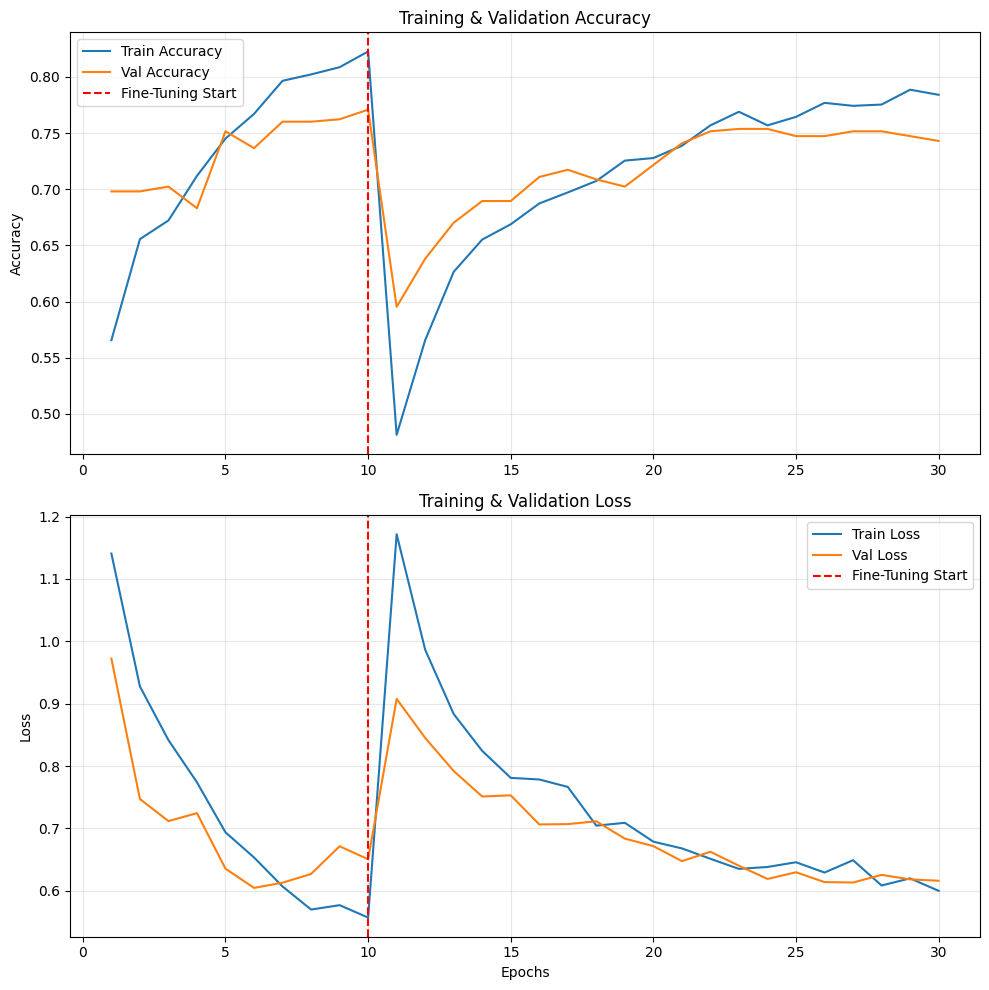

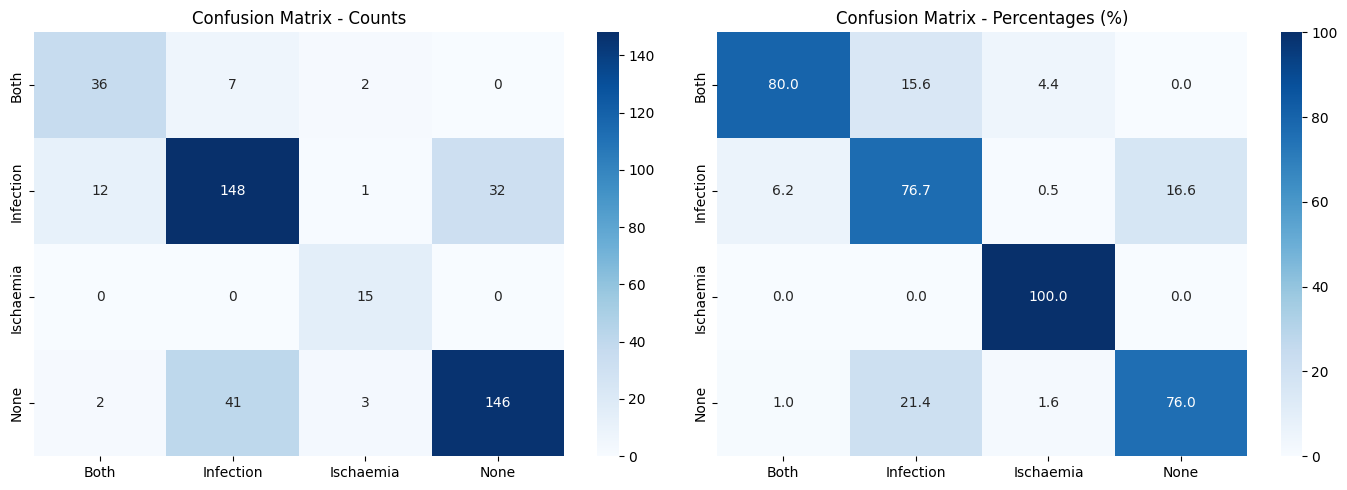

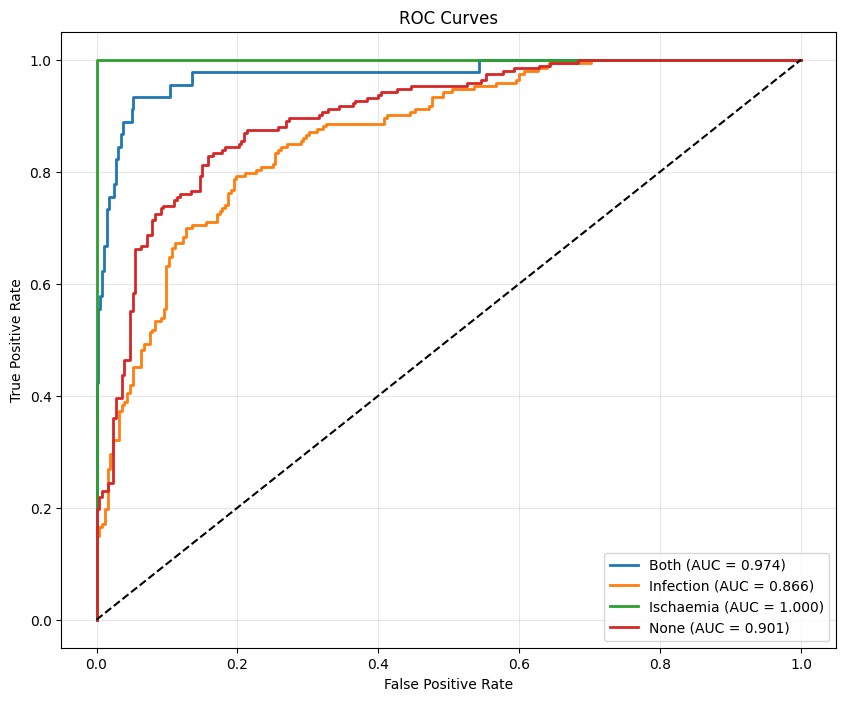

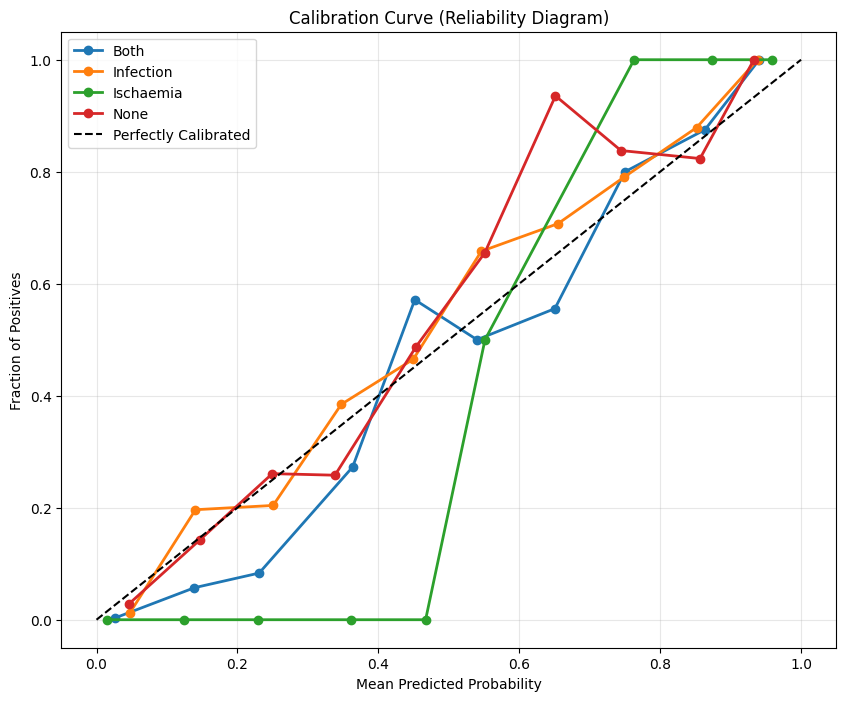

✓ Metrics saved to /kaggle/working/comprehensive_metrics.csv

✓ FINAL MODEL SAVED TO: /kaggle/working/final_dfu_model_weighted.h5


In [1]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# FIXES: Weighted Loss for Imbalance + Final .h5 Export
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, log_loss
)
from sklearn.calibration import calibration_curve
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration"""
    # Paths (Adjust these if needed)
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config
    TRANSFORMER_BLOCKS = 2  
    HEAD_SIZE = 64          
    NUM_HEADS = 4               
    FF_DIM = 256              
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5    
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
    
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model(cfg):
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=cfg.IMG_SIZE + (3,))
    features = backbone(inp)
    
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT)
    
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(cfg.DROPOUT)(x)
    x = Dense(128, activation='swish')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    return model, backbone

# ============================================================================
# TRAINING WITH WEIGHTED LOSS
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'), append=True)
    ]

def train_model_weighted(model, backbone, train_ds, val_ds, cfg, weights_tensor):
    histories = {}
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # --- DEFINING CUSTOM WEIGHTED LOSS ---
    def weighted_loss(y_true, y_pred):
        # 1. Standard CCE with Label Smoothing
        cce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, label_smoothing=cfg.LABEL_SMOOTHING)
        # 2. Get the weight for the true class
        true_ids = tf.argmax(y_true, axis=-1)
        batch_weights = tf.gather(weights_tensor, true_ids)
        # 3. Multiply loss by weight
        return cce * batch_weights
    
    # STAGE 1
    print("\n>>> STAGE 1: Head Training (Weighted)")
    for layer in backbone.layers: layer.trainable = False
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5), loss=weighted_loss, metrics=metrics)
    histories['stage1'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_HEAD, callbacks=get_callbacks(cfg, 'stage1'), verbose=1).history
    
    # STAGE 2
    print("\n>>> STAGE 2: Fine-tuning (Weighted)")
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * len(backbone.layers))
    for i, layer in enumerate(backbone.layers): layer.trainable = (i >= fine_from)
    # Recompile needed to update trainable weights, passing loss again
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5), loss=weighted_loss, metrics=metrics)
    histories['stage2'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_FINE, callbacks=get_callbacks(cfg, 'stage2'), verbose=1).history
    
    return histories

# ============================================================================
# ADVANCED METRICS & EVALUATION
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    all_preds = []
    for r in range(rounds):
        def tta_aug(x, y):
            if r % 2 == 1: x = tf.image.flip_left_right(x)
            if r % 3 == 1: x = tf.image.flip_up_down(x)
            if r % 4 == 1: x = tf.image.adjust_brightness(x, 0.05)
            return x, y
        aug_ds = ds.map(tta_aug, num_parallel_calls=AUTOTUNE)
        all_preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_preds, axis=0)

def compute_detailed_metrics(y_true_idx, y_pred_probs, class_names):
    n_classes = len(class_names)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    
    metrics = {}
    specificities, npvs, fprs, fnrs = [], [], [], []
    
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        sens = tp / (tp + fn + 1e-7)
        spec = tn / (tn + fp + 1e-7)
        metrics[f'{cls}_specificity'] = spec
        specificities.append(spec)
        
        npv = tn / (tn + fn + 1e-7)
        metrics[f'{cls}_npv'] = npv
        npvs.append(npv)
        
        fpr = fp / (fp + tn + 1e-7)
        metrics[f'{cls}_fpr'] = fpr
        fprs.append(fpr)
        
        fnr = fn / (fn + tp + 1e-7)
        metrics[f'{cls}_fnr'] = fnr
        fnrs.append(fnr)
        
        lr_plus = sens / (1 - spec + 1e-7)
        lr_minus = (1 - sens) / (spec + 1e-7)
        metrics[f'{cls}_LR+'] = lr_plus
        metrics[f'{cls}_LR-'] = lr_minus

    metrics['macro_specificity'] = np.mean(specificities)
    metrics['macro_npv'] = np.mean(npvs)
    metrics['macro_fpr'] = np.mean(fprs)
    metrics['macro_fnr'] = np.mean(fnrs)
    metrics['cohen_kappa'] = cohen_kappa_score(y_true_idx, y_pred_idx)
    metrics['mcc'] = matthews_corrcoef(y_true_idx, y_pred_idx)
    metrics['log_loss'] = log_loss(y_true_idx, y_pred_probs)
    
    y_true_tensor = tf.convert_to_tensor(y_true_idx)
    y_pred_tensor = tf.convert_to_tensor(y_pred_probs)
    top2_acc = tf.math.in_top_k(y_true_tensor, y_pred_tensor, k=2)
    metrics['top_2_accuracy'] = np.mean(top2_acc.numpy())
    
    return metrics

def evaluate_model(model, test_ds, cfg, use_tta=True):
    print("\n" + "="*30 + "\nMODEL EVALUATION\n" + "="*30)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    y_true_idx = np.argmax(y_true, axis=1)
    
    if use_tta:
        print(f"Generating TTA Predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_probs = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    else:
        print("Generating Base Predictions...")
        y_pred_probs = model.predict(test_ds, verbose=1)
        
    y_pred_idx = np.argmax(y_pred_probs, axis=1)

    print("\n>>> CLASSIFICATION REPORT:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=cfg.CLASS_NAMES, digits=4))

    metrics = compute_detailed_metrics(y_true_idx, y_pred_probs, cfg.CLASS_NAMES)
    metrics['accuracy'] = accuracy_score(y_true_idx, y_pred_idx)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true_idx, y_pred_idx)
    metrics['macro_f1'] = f1_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_precision'] = precision_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_recall'] = recall_score(y_true_idx, y_pred_idx, average='macro')
    
    print("\n>>> ADDITIONAL CLINICAL METRICS:")
    print(f"MCC: {metrics['mcc']:.4f}")
    print(f"Cohen's Kappa: {metrics['cohen_kappa']:.4f}")
    print(f"Macro Specificity: {metrics['macro_specificity']:.4f}")
    print(f"Macro NPV: {metrics['macro_npv']:.4f}")
    print(f"Top-2 Accuracy: {metrics['top_2_accuracy']:.4f}")
    
    results = {
        'metrics': metrics,
        'y_true': y_true,
        'y_true_idx': y_true_idx,
        'y_pred_probs': y_pred_probs,
        'y_pred_idx': y_pred_idx
    }
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    acc = histories['stage1']['accuracy'] + histories['stage2']['accuracy']
    val_acc = histories['stage1']['val_accuracy'] + histories['stage2']['val_accuracy']
    loss = histories['stage1']['loss'] + histories['stage2']['loss']
    val_loss = histories['stage1']['val_loss'] + histories['stage2']['val_loss']
    
    epochs_range = range(1, len(acc) + 1)
    
    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].axvline(x=len(histories['stage1']['accuracy']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[0].set_title('Training & Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].axvline(x=len(histories['stage1']['loss']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[1].set_title('Training & Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_graphs.png'), bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, cfg):
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix - Counts')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Confusion Matrix - Percentages (%)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'confusion_matrix.png'), bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title('ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'roc_curves.png'), bbox_inches='tight')
    plt.show()

def plot_calibration_curve(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        y_true_bin = (np.argmax(y_true, axis=1) == i).astype(int)
        prob_y = y_pred_probs[:, i]
        prob_true, prob_pred = calibration_curve(y_true_bin, prob_y, n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'{cls}')
        
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Calibration Curve (Reliability Diagram)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'calibration_curve.png'), bbox_inches='tight')
    plt.show()

def generate_visualizations(results, histories, cfg):
    print("\n>>> Generating Visualizations...")
    plot_training_history(histories, cfg)
    plot_confusion_matrix(results['y_true_idx'], results['y_pred_idx'], cfg.CLASS_NAMES, cfg)
    plot_roc_curves(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)
    plot_calibration_curve(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)

def save_metrics_to_csv(results, cfg):
    metrics_df = pd.DataFrame(results['metrics'].items(), columns=['Metric', 'Value'])
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv'), index=False)
    print(f"✓ Metrics saved to {os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv')}")

# ============================================================================
# MAIN
# ============================================================================
def main():
    ensure_dir(cfg.OUTPUT_DIR)
    
    # 1. Load Data
    train_df, val_df, test_df = load_data(cfg)
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    # 2. CALCULATE CLASS WEIGHTS (FIXED)
    print("\n>>> Computing Class Weights...")
    # Get all labels from the training dataframe
    y_train_indices = np.argmax(train_df[cfg.CLASS_NAMES].values, axis=1)
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_indices),
        y=y_train_indices
    )
    # Convert to dictionary and Tensor for the custom loss
    class_weights_dict = dict(enumerate(class_weights))
    print(f"Computed Class Weights: {class_weights_dict}")
    weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    
    # 3. Build Model
    model, backbone = build_model(cfg)
    
    # 4. Train with Weighted Loss (FIXED)
    histories = train_model_weighted(model, backbone, train_ds, val_ds, cfg, weights_tensor)
    
    # 5. Evaluation
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # 6. Visualizations & Saving
    generate_visualizations(results, histories, cfg)
    save_metrics_to_csv(results, cfg)
    
    # 7. SAVE FINAL MODEL FOR WEB DEPLOYMENT (FIXED)
    final_model_path = os.path.join(cfg.OUTPUT_DIR, "final_dfu_model_weighted.h5")
    model.save(final_model_path)
    print(f"\n✓ FINAL MODEL SAVED TO: {final_model_path}")
    
    return model, results

if __name__ == "__main__":
    main()

🔄 Loading model from /kaggle/working/final_dfu_model_weighted.h5...
✅ Model loaded successfully!
📊 Validation Set Size: 467 images


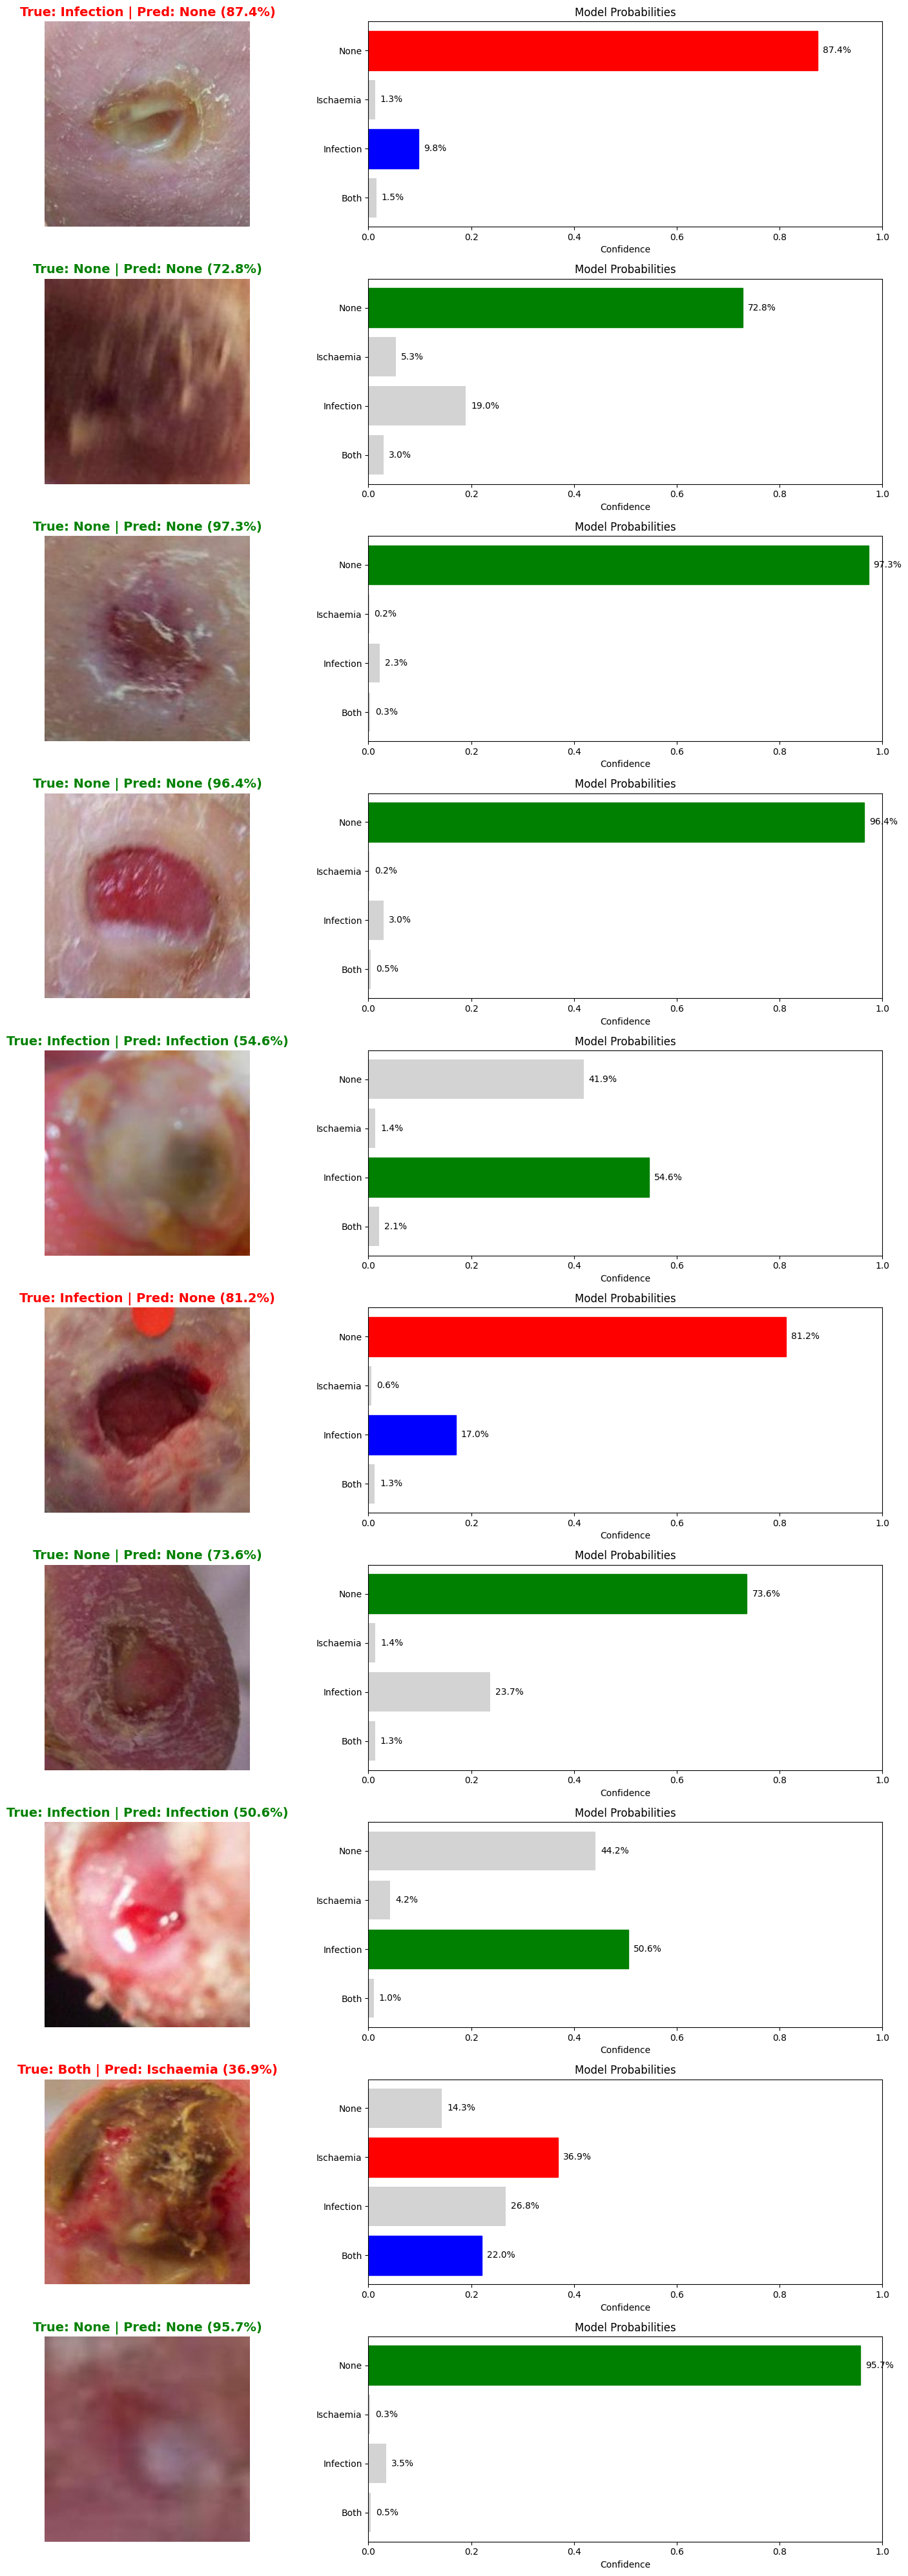

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import cv2

# ==========================================
# CONFIGURATION
# ==========================================
MODEL_PATH = "/kaggle/working/final_dfu_model_weighted.h5"  # Your saved model
NUM_SAMPLES = 10  # How many random images to check
IMG_SIZE = (300, 300)
CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

# ==========================================
# 1. LOAD MODEL
# ==========================================
print(f"🔄 Loading model from {MODEL_PATH}...")
# We need to register the custom weighted loss if we want to compile it, 
# but for inference (prediction), we can load it with compile=False
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ Model loaded successfully!")

# ==========================================
# 2. PREPARE DATA (RECONSTRUCT VALIDATION SPLIT)
# ==========================================
# We assume the standard path from your previous config
base_dir = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
train_csv = os.path.join(base_dir, "_classes_train.csv")
train_img_dir = os.path.join(base_dir, "train")

# Load and split exactly as training did (Seed 42) to get the REAL validation set
df = pd.read_csv(train_csv)
df['filename'] = df['filename'].apply(lambda x: os.path.join(train_img_dir, x))

from sklearn.model_selection import train_test_split
_, val_df = train_test_split(
    df, 
    test_size=0.15, 
    stratify=df[CLASS_NAMES], 
    random_state=42
)

print(f"📊 Validation Set Size: {len(val_df)} images")

# ==========================================
# 3. SAMPLE & PREDICT
# ==========================================
# Sample random rows
samples = val_df.sample(n=NUM_SAMPLES)

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, IMG_SIZE)
    # EfficientNet Preprocessing (0-255 to expected range)
    img_tensor = tf.keras.applications.efficientnet.preprocess_input(img_resized)
    return img, img_tensor

plt.figure(figsize=(16, 4 * NUM_SAMPLES))

for i, (_, row) in enumerate(samples.iterrows()):
    img_path = row['filename']
    
    # Get True Label
    true_probs = row[CLASS_NAMES].values.astype(float)
    true_label_idx = np.argmax(true_probs)
    true_label_str = CLASS_NAMES[true_label_idx]
    
    # Preprocess & Predict
    original_img, img_tensor = preprocess_image(img_path)
    pred_probs = model.predict(np.expand_dims(img_tensor, axis=0), verbose=0)[0]
    pred_label_idx = np.argmax(pred_probs)
    pred_label_str = CLASS_NAMES[pred_label_idx]
    confidence = pred_probs[pred_label_idx]
    
    # Color code title: Green = Correct, Red = Wrong
    color = 'green' if true_label_idx == pred_label_idx else 'red'
    
    # --- PLOT IMAGE ---
    plt.subplot(NUM_SAMPLES, 2, 2*i + 1)
    plt.imshow(original_img)
    plt.axis('off')
    plt.title(f"True: {true_label_str} | Pred: {pred_label_str} ({confidence:.1%})", 
              color=color, fontsize=14, fontweight='bold')
    
    # --- PLOT CONFIDENCE BARS ---
    plt.subplot(NUM_SAMPLES, 2, 2*i + 2)
    bars = plt.barh(CLASS_NAMES, pred_probs, color='lightgray')
    bars[pred_label_idx].set_color(color) # Highlight prediction
    if true_label_idx != pred_label_idx:
        bars[true_label_idx].set_color('blue') # Highlight missed truth in blue
        
    plt.xlim(0, 1.0)
    plt.xlabel("Confidence")
    plt.title("Model Probabilities")
    
    # Add text labels on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Dataset sizes - Train: 2645 | Val: 467 | Test: 445

>>> Computing Class Weights...
Computed Class Weights: {0: 2.4045454545454548, 1: 0.5862145390070922, 2: 7.034574468085107, 3: 0.5760017421602788}

>>> STAGE 1: Head Training (Weighted)
Epoch 1/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5523 - auc: 0.7916 - loss: 1.1538
Epoch 1: val_auc improved from -inf to 0.91339, saving model to /kaggle/working/best_model_stage1.h5
331/331 ━━━━━━━━━━━━━━━━━━━━ 109s 162ms/step - accuracy: 0.5524 - auc: 0.7917 - loss: 1.1536 - val_accuracy: 0.6916 - val_auc: 0.9134 - val_loss: 0.9009 - learning_rate: 1.0000e-04
Epoch 2/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6276 - auc: 0.8376 - loss: 1.0071
Epoch 2: val_auc did not improve from 0.91339
331/331 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.6276 - auc: 0.8376 - loss: 1.0069 - val_accuracy: 0.6981 - val_auc: 0.9060 - val_loss: 0.7694 - learning_rate: 1.0000e-04
Epoch 3/10
330/331 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

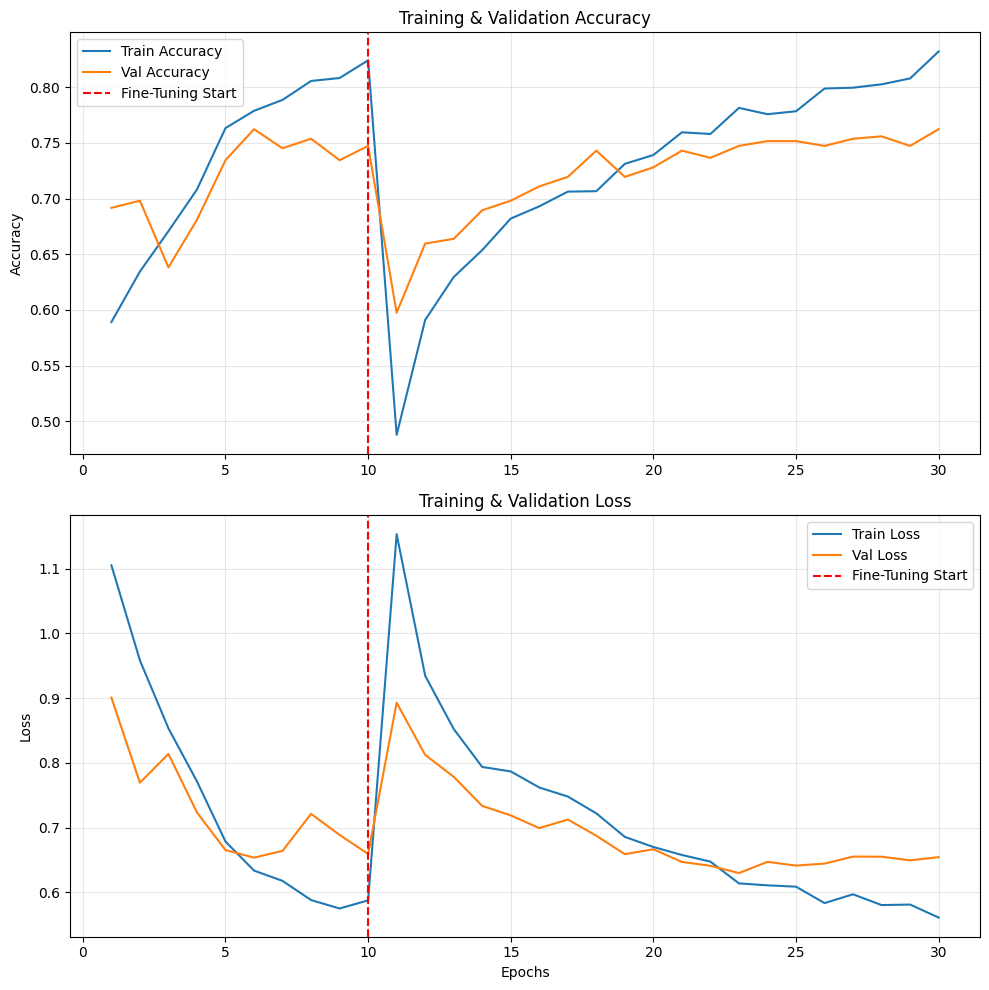

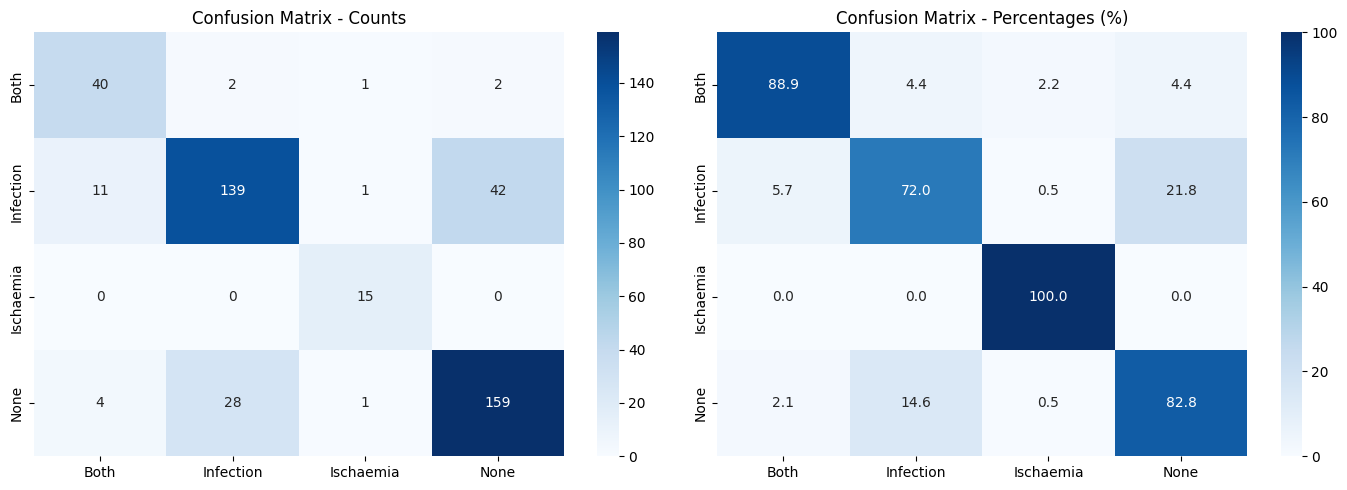

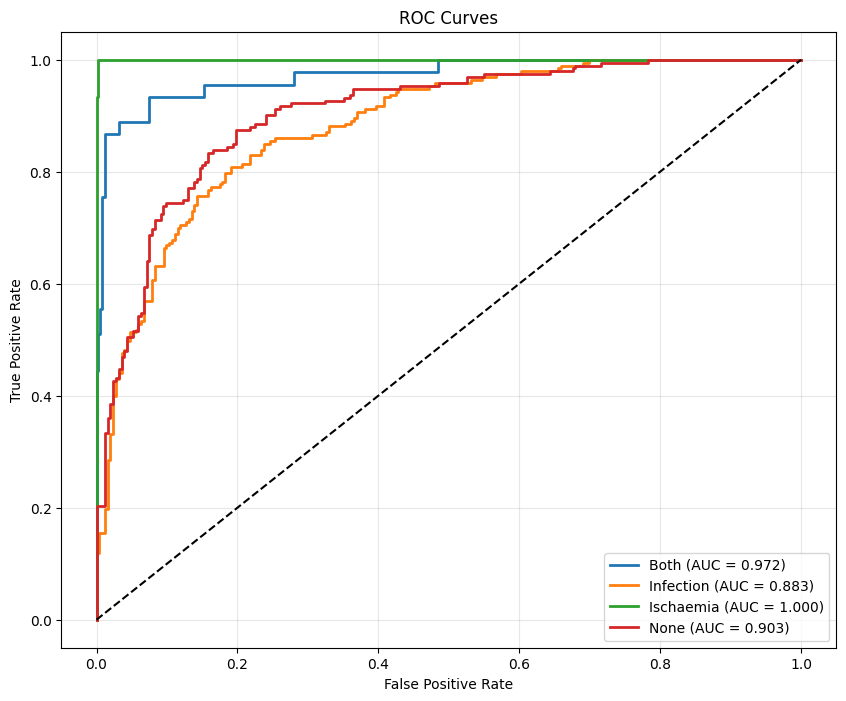

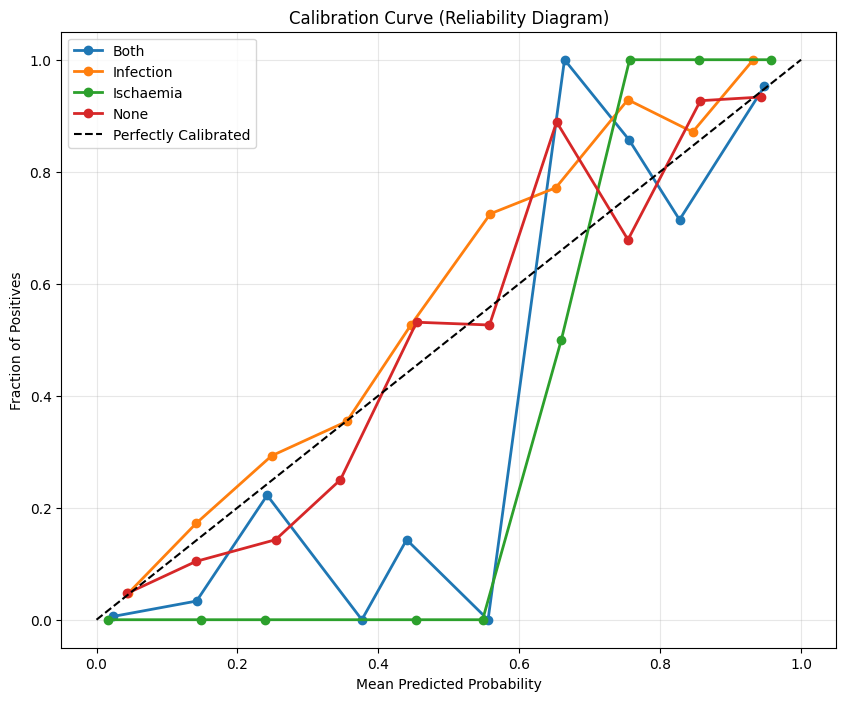

✓ Metrics saved to /kaggle/working/comprehensive_metrics.csv

✓ FINAL MODEL SAVED TO: /kaggle/working/final_dfu_model_weighted.h5


In [2]:
# ==============================
# Optimized Lightweight DFU Classification Script
# EfficientNetB3 + Transformer Head + MixUp + TTA
# FIXES: Weighted Loss for Imbalance + Final .h5 Export
# ==============================

import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, log_loss
)
from sklearn.calibration import calibration_curve
from tensorflow.keras.applications import EfficientNetB3, efficientnet
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

warnings.filterwarnings("ignore")
AUTOTUNE = tf.data.AUTOTUNE
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Centralized configuration"""
    # Paths (Adjust these if needed)
    BASE_DIR = "/kaggle/input/dfu-multiclass/DFUmulticlass/"
    TRAIN_CSV = os.path.join(BASE_DIR, "_classes_train.csv")
    TEST_CSV = os.path.join(BASE_DIR, "_classes_test.csv")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    TEST_DIR = os.path.join(BASE_DIR, "test")
    OUTPUT_DIR = "/kaggle/working/"
    
    # Model parameters
    IMG_SIZE = (300, 300)
    BATCH_SIZE = 8
    EPOCHS_HEAD = 10
    EPOCHS_FINE = 20
    LR_HEAD = 1e-4
    LR_FINE = 1e-5
    
    # Class info
    CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Transformer head config
    TRANSFORMER_BLOCKS = 2  
    HEAD_SIZE = 64          
    NUM_HEADS = 4               
    FF_DIM = 256              
    DROPOUT = 0.25
    
    # Training settings
    LABEL_SMOOTHING = 0.05
    MIXUP_PROB = 0.4
    TTA_ROUNDS = 5
    FINE_TUNE_RATIO = 0.5    
    VAL_SPLIT = 0.15

cfg = Config()

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

# ============================================================================
# DATA LOADING & PREPROCESSING
# ============================================================================
def load_data(cfg):
    train_df = pd.read_csv(cfg.TRAIN_CSV)
    test_df = pd.read_csv(cfg.TEST_CSV)
    
    train_df['filename'] = train_df['filename'].apply(lambda p: os.path.join(cfg.TRAIN_DIR, p))
    test_df['filename'] = test_df['filename'].apply(lambda p: os.path.join(cfg.TEST_DIR, p))
    
    train_df, val_df = train_test_split(
        train_df, test_size=cfg.VAL_SPLIT, 
        stratify=train_df[cfg.CLASS_NAMES], 
        random_state=42
    )
    
    print(f"Dataset sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df, val_df, test_df

def read_and_preprocess(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = efficientnet.preprocess_input(img)
    return img, label

def augment_train(image, label, img_size):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    if tf.random.uniform([]) < 0.2:
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(img_size[0] * scale, tf.int32)
        w = tf.cast(img_size[1] * scale, tf.int32)
        image = tf.image.resize(image, (h, w))
        image = tf.image.resize_with_crop_or_pad(image, img_size[0], img_size[1])
    
    return image, label

def make_dataset(df, cfg, training=False, augment=False):
    paths = df['filename'].values
    labels = df[cfg.CLASS_NAMES].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: read_and_preprocess(p, l, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
    
    if training and augment:
        ds = ds.map(lambda x, y: augment_train(x, y, cfg.IMG_SIZE), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024)
    
    ds = ds.batch(cfg.BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def mixup_batch(x, y, alpha=0.4):
    batch_size = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)
    lam = tf.random.uniform([], 0.0, alpha)
    x_mix = lam * x + (1.0 - lam) * x2
    y_mix = lam * y + (1.0 - lam) * y2
    return x_mix, y_mix

def apply_mixup(ds, prob=0.4):
    def _mixup_fn(x, y):
        apply_mix = tf.random.uniform([]) < prob
        x_m, y_m = mixup_batch(x, y)
        return tf.cond(apply_mix, lambda: (x_m, y_m), lambda: (x, y))
    return ds.map(_mixup_fn, num_parallel_calls=AUTOTUNE)

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
def transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dense(int(x.shape[-1]))(ff)
    ff = Dropout(dropout)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model(cfg):
    inp = Input(shape=cfg.IMG_SIZE + (3,), name='input_image')
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_shape=cfg.IMG_SIZE + (3,))
    features = backbone(inp)
    
    embed_dim = int(features.shape[-1])
    seq = Reshape((-1, embed_dim), name='feature_sequence')(features)
    
    x = seq
    for i in range(cfg.TRANSFORMER_BLOCKS):
        x = transformer_encoder_block(x, cfg.HEAD_SIZE, cfg.NUM_HEADS, cfg.FF_DIM, cfg.DROPOUT)
    
    x = GlobalAveragePooling1D(name='global_pool')(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(cfg.DROPOUT)(x)
    x = Dense(128, activation='swish')(x)
    output = Dense(cfg.NUM_CLASSES, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inp, outputs=output, name='DFU_Classifier')
    return model, backbone

# ============================================================================
# TRAINING WITH WEIGHTED LOSS
# ============================================================================
def get_callbacks(cfg, stage_name=''):
    return [
        EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(cfg.OUTPUT_DIR, f'best_model_{stage_name}.h5'), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.OUTPUT_DIR, f'training_log_{stage_name}.csv'), append=True)
    ]

def train_model_weighted(model, backbone, train_ds, val_ds, cfg, weights_tensor):
    histories = {}
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    
    # --- DEFINING CUSTOM WEIGHTED LOSS ---
    def weighted_loss(y_true, y_pred):
        # 1. Standard CCE with Label Smoothing
        cce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, label_smoothing=cfg.LABEL_SMOOTHING)
        # 2. Get the weight for the true class
        true_ids = tf.argmax(y_true, axis=-1)
        batch_weights = tf.gather(weights_tensor, true_ids)
        # 3. Multiply loss by weight
        return cce * batch_weights
    
    # STAGE 1
    print("\n>>> STAGE 1: Head Training (Weighted)")
    for layer in backbone.layers: layer.trainable = False
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_HEAD, weight_decay=1e-5), loss=weighted_loss, metrics=metrics)
    histories['stage1'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_HEAD, callbacks=get_callbacks(cfg, 'stage1'), verbose=1).history
    
    # STAGE 2
    print("\n>>> STAGE 2: Fine-tuning (Weighted)")
    fine_from = int((1 - cfg.FINE_TUNE_RATIO) * len(backbone.layers))
    for i, layer in enumerate(backbone.layers): layer.trainable = (i >= fine_from)
    # Recompile needed to update trainable weights, passing loss again
    model.compile(optimizer=AdamW(learning_rate=cfg.LR_FINE, weight_decay=1e-5), loss=weighted_loss, metrics=metrics)
    histories['stage2'] = model.fit(train_ds, validation_data=val_ds, epochs=cfg.EPOCHS_FINE, callbacks=get_callbacks(cfg, 'stage2'), verbose=1).history
    
    return histories

# ============================================================================
# ADVANCED METRICS & EVALUATION
# ============================================================================
def tta_predict(model, ds, cfg, rounds=5):
    all_preds = []
    for r in range(rounds):
        def tta_aug(x, y):
            if r % 2 == 1: x = tf.image.flip_left_right(x)
            if r % 3 == 1: x = tf.image.flip_up_down(x)
            if r % 4 == 1: x = tf.image.adjust_brightness(x, 0.05)
            return x, y
        aug_ds = ds.map(tta_aug, num_parallel_calls=AUTOTUNE)
        all_preds.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_preds, axis=0)

def compute_detailed_metrics(y_true_idx, y_pred_probs, class_names):
    n_classes = len(class_names)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    
    metrics = {}
    specificities, npvs, fprs, fnrs = [], [], [], []
    
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        sens = tp / (tp + fn + 1e-7)
        spec = tn / (tn + fp + 1e-7)
        metrics[f'{cls}_specificity'] = spec
        specificities.append(spec)
        
        npv = tn / (tn + fn + 1e-7)
        metrics[f'{cls}_npv'] = npv
        npvs.append(npv)
        
        fpr = fp / (fp + tn + 1e-7)
        metrics[f'{cls}_fpr'] = fpr
        fprs.append(fpr)
        
        fnr = fn / (fn + tp + 1e-7)
        metrics[f'{cls}_fnr'] = fnr
        fnrs.append(fnr)
        
        lr_plus = sens / (1 - spec + 1e-7)
        lr_minus = (1 - sens) / (spec + 1e-7)
        metrics[f'{cls}_LR+'] = lr_plus
        metrics[f'{cls}_LR-'] = lr_minus

    metrics['macro_specificity'] = np.mean(specificities)
    metrics['macro_npv'] = np.mean(npvs)
    metrics['macro_fpr'] = np.mean(fprs)
    metrics['macro_fnr'] = np.mean(fnrs)
    metrics['cohen_kappa'] = cohen_kappa_score(y_true_idx, y_pred_idx)
    metrics['mcc'] = matthews_corrcoef(y_true_idx, y_pred_idx)
    metrics['log_loss'] = log_loss(y_true_idx, y_pred_probs)
    
    y_true_tensor = tf.convert_to_tensor(y_true_idx)
    y_pred_tensor = tf.convert_to_tensor(y_pred_probs)
    top2_acc = tf.math.in_top_k(y_true_tensor, y_pred_tensor, k=2)
    metrics['top_2_accuracy'] = np.mean(top2_acc.numpy())
    
    return metrics

def evaluate_model(model, test_ds, cfg, use_tta=True):
    print("\n" + "="*30 + "\nMODEL EVALUATION\n" + "="*30)
    y_true = np.concatenate([y for _, y in test_ds], axis=0)
    y_true_idx = np.argmax(y_true, axis=1)
    
    if use_tta:
        print(f"Generating TTA Predictions ({cfg.TTA_ROUNDS} rounds)...")
        y_pred_probs = tta_predict(model, test_ds, cfg, rounds=cfg.TTA_ROUNDS)
    else:
        print("Generating Base Predictions...")
        y_pred_probs = model.predict(test_ds, verbose=1)
        
    y_pred_idx = np.argmax(y_pred_probs, axis=1)

    print("\n>>> CLASSIFICATION REPORT:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=cfg.CLASS_NAMES, digits=4))

    metrics = compute_detailed_metrics(y_true_idx, y_pred_probs, cfg.CLASS_NAMES)
    metrics['accuracy'] = accuracy_score(y_true_idx, y_pred_idx)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true_idx, y_pred_idx)
    metrics['macro_f1'] = f1_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_precision'] = precision_score(y_true_idx, y_pred_idx, average='macro')
    metrics['macro_recall'] = recall_score(y_true_idx, y_pred_idx, average='macro')
    
    print("\n>>> ADDITIONAL CLINICAL METRICS:")
    print(f"MCC: {metrics['mcc']:.4f}")
    print(f"Cohen's Kappa: {metrics['cohen_kappa']:.4f}")
    print(f"Macro Specificity: {metrics['macro_specificity']:.4f}")
    print(f"Macro NPV: {metrics['macro_npv']:.4f}")
    print(f"Top-2 Accuracy: {metrics['top_2_accuracy']:.4f}")
    
    results = {
        'metrics': metrics,
        'y_true': y_true,
        'y_true_idx': y_true_idx,
        'y_pred_probs': y_pred_probs,
        'y_pred_idx': y_pred_idx
    }
    return results

# ============================================================================
# VISUALIZATION
# ============================================================================
def plot_training_history(histories, cfg):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    acc = histories['stage1']['accuracy'] + histories['stage2']['accuracy']
    val_acc = histories['stage1']['val_accuracy'] + histories['stage2']['val_accuracy']
    loss = histories['stage1']['loss'] + histories['stage2']['loss']
    val_loss = histories['stage1']['val_loss'] + histories['stage2']['val_loss']
    
    epochs_range = range(1, len(acc) + 1)
    
    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].axvline(x=len(histories['stage1']['accuracy']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[0].set_title('Training & Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].axvline(x=len(histories['stage1']['loss']), color='r', linestyle='--', label='Fine-Tuning Start')
    axes[1].set_title('Training & Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_graphs.png'), bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true_idx, y_pred_idx, class_names, cfg):
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix - Counts')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Confusion Matrix - Percentages (%)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'confusion_matrix.png'), bbox_inches='tight')
    plt.show()

def plot_roc_curves(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title('ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'roc_curves.png'), bbox_inches='tight')
    plt.show()

def plot_calibration_curve(y_true, y_pred_probs, class_names, cfg):
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        y_true_bin = (np.argmax(y_true, axis=1) == i).astype(int)
        prob_y = y_pred_probs[:, i]
        prob_true, prob_pred = calibration_curve(y_true_bin, prob_y, n_bins=10)
        ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'{cls}')
        
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Calibration Curve (Reliability Diagram)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'calibration_curve.png'), bbox_inches='tight')
    plt.show()

def generate_visualizations(results, histories, cfg):
    print("\n>>> Generating Visualizations...")
    plot_training_history(histories, cfg)
    plot_confusion_matrix(results['y_true_idx'], results['y_pred_idx'], cfg.CLASS_NAMES, cfg)
    plot_roc_curves(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)
    plot_calibration_curve(results['y_true'], results['y_pred_probs'], cfg.CLASS_NAMES, cfg)

def save_metrics_to_csv(results, cfg):
    metrics_df = pd.DataFrame(results['metrics'].items(), columns=['Metric', 'Value'])
    metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv'), index=False)
    print(f"✓ Metrics saved to {os.path.join(cfg.OUTPUT_DIR, 'comprehensive_metrics.csv')}")

# ============================================================================
# MAIN
# ============================================================================
def main():
    ensure_dir(cfg.OUTPUT_DIR)
    
    # 1. Load Data
    train_df, val_df, test_df = load_data(cfg)
    train_ds_base = make_dataset(train_df, cfg, training=True, augment=True)
    train_ds = apply_mixup(train_ds_base, prob=cfg.MIXUP_PROB)
    val_ds = make_dataset(val_df, cfg, training=False)
    test_ds = make_dataset(test_df, cfg, training=False)
    
    # 2. CALCULATE CLASS WEIGHTS (FIXED)
    print("\n>>> Computing Class Weights...")
    # Get all labels from the training dataframe
    y_train_indices = np.argmax(train_df[cfg.CLASS_NAMES].values, axis=1)
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_indices),
        y=y_train_indices
    )
    # Convert to dictionary and Tensor for the custom loss
    class_weights_dict = dict(enumerate(class_weights))
    print(f"Computed Class Weights: {class_weights_dict}")
    weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    
    # 3. Build Model
    model, backbone = build_model(cfg)
    
    # 4. Train with Weighted Loss (FIXED)
    histories = train_model_weighted(model, backbone, train_ds, val_ds, cfg, weights_tensor)
    
    # 5. Evaluation
    results = evaluate_model(model, test_ds, cfg, use_tta=True)
    
    # 6. Visualizations & Saving
    generate_visualizations(results, histories, cfg)
    save_metrics_to_csv(results, cfg)
    
    # 7. SAVE FINAL MODEL FOR WEB DEPLOYMENT (FIXED)
    final_model_path = os.path.join(cfg.OUTPUT_DIR, "final_dfu_model_weighted.h5")
    model.save(final_model_path)
    print(f"\n✓ FINAL MODEL SAVED TO: {final_model_path}")
    
    return model, results

if __name__ == "__main__":
    main()